## Code to split Kvasir-seg data into 70% train, 20% val, and 10% test

In [ ]:
import os
import shutil
import random

# Input directories
image_dir = r"C:\Medical_image_analysis\colon_cancer\kvasir-seg\Kvasir-SEG\images"
label_dir = r"C:\Medical_image_analysis\colon_cancer\kvasir-seg\Kvasir-SEG\labels"
mask_dir = r"C:\Medical_image_analysis\colon_cancer\kvasir-seg\Kvasir-SEG\masks"

# Output directories
base_dir = r"C:\Medical_image_analysis\yolov8_kvasir"
splits = ['train', 'val', 'test']

# Create directories for images, labels, and masks
for split in splits:
    os.makedirs(os.path.join(base_dir, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(base_dir, 'labels', split), exist_ok=True)
    os.makedirs(os.path.join(base_dir, 'masks', split), exist_ok=True)

# Get image files (assumes .jpg)
image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]
image_files.sort()

# Shuffle and split
random.seed(42)
random.shuffle(image_files)

total = len(image_files)
train_end = int(0.7 * total)
val_end = int(0.9 * total)

train_files = image_files[:train_end]
val_files = image_files[train_end:val_end]
test_files = image_files[val_end:]

# Function to move files
def move_files(files, split):
    for file in files:
        name = os.path.splitext(file)[0]
        img_src = os.path.join(image_dir, f"{name}.jpg")
        lbl_src = os.path.join(label_dir, f"{name}.txt")
        mask_src = os.path.join(mask_dir, f"{name}.jpg")  # or .png if masks are .png

        img_dst = os.path.join(base_dir, 'images', split, f"{name}.jpg")
        lbl_dst = os.path.join(base_dir, 'labels', split, f"{name}.txt")
        mask_dst = os.path.join(base_dir, 'masks', split, f"{name}.jpg")

        # Copy files if all exist
        if os.path.exists(img_src) and os.path.exists(lbl_src) and os.path.exists(mask_src):
            shutil.copy(img_src, img_dst)
            shutil.copy(lbl_src, lbl_dst)
            shutil.copy(mask_src, mask_dst)

# Move files
move_files(train_files, 'train')
move_files(val_files, 'val')
move_files(test_files, 'test')

print("✅ Dataset split completed:")
print(f"Train: {len(train_files)} images")
print(f"Val:   {len(val_files)} images")
print(f"Test:  {len(test_files)} images")

## Code to perform data augmentation: horizontal flip, vertical flip, horizontal vertical flip

In [ ]:
import os
import cv2
import shutil
import albumentations as A

# Paths
image_dir = r"C:\Medical_image_analysis\yolov8_kvasir\images\train"
mask_dir = r"C:\Medical_image_analysis\yolov8_kvasir\masks\train"
aug_image_dir = r"C:\Medical_image_analysis\yolov8_kvasir\images\train_aug"
aug_mask_dir = r"C:\Medical_image_analysis\yolov8_kvasir\masks\train_aug"

# Create output directories
os.makedirs(aug_image_dir, exist_ok=True)
os.makedirs(aug_mask_dir, exist_ok=True)

# Albumentations transforms
horizontal_flip = A.Compose([A.HorizontalFlip(p=1.0)])
vertical_flip = A.Compose([A.VerticalFlip(p=1.0)])
hv_flip = A.Compose([A.HorizontalFlip(p=1.0), A.VerticalFlip(p=1.0)])

# List of image files
image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.jpg') or f.endswith('.png')])

for img_file in image_files:
    base_name, ext = os.path.splitext(img_file)
    img_path = os.path.join(image_dir, img_file)
    mask_path = os.path.join(mask_dir, base_name + ext)

    # Read image and mask
    image = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if image is None or mask is None:
        print(f"Skipping due to missing image or mask: {img_file}")
        continue

    # === Save original
    shutil.copy(img_path, os.path.join(aug_image_dir, img_file))
    shutil.copy(mask_path, os.path.join(aug_mask_dir, img_file))

    # === Horizontal Flip
    augmented = horizontal_flip(image=image, mask=mask)
    cv2.imwrite(os.path.join(aug_image_dir, f"{base_name}_hf{ext}"), augmented['image'])
    cv2.imwrite(os.path.join(aug_mask_dir, f"{base_name}_hf{ext}"), augmented['mask'])

    # === Vertical Flip
    augmented = vertical_flip(image=image, mask=mask)
    cv2.imwrite(os.path.join(aug_image_dir, f"{base_name}_vf{ext}"), augmented['image'])
    cv2.imwrite(os.path.join(aug_mask_dir, f"{base_name}_vf{ext}"), augmented['mask'])

    # === Horizontal + Vertical Flip
    augmented = hv_flip(image=image, mask=mask)
    cv2.imwrite(os.path.join(aug_image_dir, f"{base_name}_hfvf{ext}"), augmented['image'])
    cv2.imwrite(os.path.join(aug_mask_dir, f"{base_name}_hfvf{ext}"), augmented['mask'])

    print(f"Processed: {img_file}")

## Code for data augmentation: rotation, horizontal flip rotate, vertical flip rotate, horizontal vertical flip rotate

In [ ]:
#code for data augmentation: rotation, horizontal flip rotate, vertical flip rotate, horizontal vertical flip rotate

import os
import cv2
import albumentations as A
from glob import glob

# Input/output directories
image_dir = r"C:\Medical_image_analysis\yolov8_kvasir\images\train_aug"
mask_dir = r"C:\Medical_image_analysis\yolov8_kvasir\masks\train_aug"
output_image_dir = r"C:\Medical_image_analysis\yolov8_kvasir\images\train_aug_rotate"
output_mask_dir = r"C:\Medical_image_analysis\yolov8_kvasir\masks\train_aug_rotate"

# Create output directories
os.makedirs(output_image_dir, exist_ok=True)
os.makedirs(output_mask_dir, exist_ok=True)

# Albumentations 45-degree rotation (fixed)
rotate_45 = A.Compose([
    A.Rotate(limit=(45, 45), p=1, border_mode=cv2.BORDER_CONSTANT)
])

def get_rotated_name(filename):
    base, ext = os.path.splitext(filename)
    if base.endswith('_hfvf'):
        return base.replace('_hfvf', '_hfvfr') + ext
    elif base.endswith('_hf'):
        return base.replace('_hf', '_hfr') + ext
    elif base.endswith('_vf'):
        return base.replace('_vf', '_vfr') + ext
    else:
        return base + '_r' + ext

# Process all images
image_files = glob(os.path.join(image_dir, "*.png")) + glob(os.path.join(image_dir, "*.jpg"))

for img_path in image_files:
    filename = os.path.basename(img_path)
    mask_path = os.path.join(mask_dir, filename)

    if not os.path.exists(mask_path):
        print(f"Mask not found for image: {filename}")
        continue

    # Read image and mask
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        print(f"Failed to read image or mask for: {filename}")
        continue

    # Apply fixed 45-degree rotation using Albumentations
    augmented = rotate_45(image=img, mask=mask)
    rotated_img = augmented['image']
    rotated_mask = augmented['mask']

    # Save rotated image and mask
    new_name = get_rotated_name(filename)
    cv2.imwrite(os.path.join(output_image_dir, new_name), rotated_img)
    cv2.imwrite(os.path.join(output_mask_dir, new_name), rotated_mask)

    print(f"Saved rotated image and mask: {new_name} | Original size: {img.shape} -> Rotated size: {rotated_img.shape}")

## Applied gaussian blur with kernel size 15 to train images and corresponding masks

In [ ]:
import os
import cv2
from glob import glob

# Input directories
image_dir = r"C:\Medical_image_analysis\yolov8_kvasir\images\train"
mask_dir = r"C:\Medical_image_analysis\yolov8_kvasir\masks\train"

# Output directories
output_image_dir = r"C:\Medical_image_analysis\yolov8_kvasir\images\gaussian_blur_kernel_size_14"
output_mask_dir = r"C:\Medical_image_analysis\yolov8_kvasir\masks\gaussian_blur_kernel_size_14"

os.makedirs(output_image_dir, exist_ok=True)
os.makedirs(output_mask_dir, exist_ok=True)

# Kernel size (odd only)
kernel_size = 14
k_odd = kernel_size if kernel_size % 2 == 1 else kernel_size + 1  # → 15

# Get image paths
image_paths = sorted(glob(os.path.join(image_dir, "*.png")) + glob(os.path.join(image_dir, "*.jpg")))

# Process each image-mask pair
for img_path in image_paths:
    filename = os.path.basename(img_path)
    name_no_ext = os.path.splitext(filename)[0]

    # Mask path (assumes same base name)
    mask_path = os.path.join(mask_dir, filename)
    if not os.path.exists(mask_path):
        print(f"Mask not found for: {filename}")
        continue

    # Read image and mask
    image = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  # keep mask as grayscale

    if image is None or mask is None:
        print(f"Could not read image or mask for: {filename}")
        continue

    # Resize both if needed
    image = cv2.resize(image, (128, 128))
    mask = cv2.resize(mask, (128, 128))

    # Apply Gaussian blur
    image_blurred = cv2.GaussianBlur(image, (k_odd, k_odd), 0)
    mask_blurred = cv2.GaussianBlur(mask, (k_odd, k_odd), 0)

    # Save blurred outputs
    cv2.imwrite(os.path.join(output_image_dir, f"{name_no_ext}_blur{k_odd}.png"), image_blurred)
    cv2.imwrite(os.path.join(output_mask_dir, f"{name_no_ext}_blur{k_odd}.png"), mask_blurred)

    print(f"Saved image and mask for: {filename}")


## Data augmentation, gaussian blur with kernel size 15 and rotation 45

In [ ]:
import os
import cv2
import albumentations as A
from glob import glob

# Input Gaussian-blurred directories
image_dir = r"C:\Medical_image_analysis\yolov8_kvasir\images\gaussian_blur_kernel_size_14"
mask_dir = r"C:\Medical_image_analysis\yolov8_kvasir\masks\gaussian_blur_kernel_size_14"

# Output directories after rotation
output_image_dir = r"C:\Medical_image_analysis\yolov8_kvasir\images\gaussian_blur_with_rotation"
output_mask_dir = r"C:\Medical_image_analysis\yolov8_kvasir\masks\gaussian_blur_with_rotation"

# Create output folders if not present
os.makedirs(output_image_dir, exist_ok=True)
os.makedirs(output_mask_dir, exist_ok=True)

# Define fixed 45° rotation using Albumentations
rotate_45 = A.Compose([
    A.Rotate(limit=(45, 45), p=1, border_mode=cv2.BORDER_CONSTANT)
])

# Custom naming logic based on current suffix
def get_rotated_name(filename):
    base, ext = os.path.splitext(filename)
    if base.endswith('_hfvf'):
        return base.replace('_hfvf', '_hfvfr') + ext
    elif base.endswith('_hf'):
        return base.replace('_hf', '_hfr') + ext
    elif base.endswith('_vf'):
        return base.replace('_vf', '_vfr') + ext
    elif base.endswith('_blur15'):  # specifically for blurred images
        return base + '_r' + ext
    else:
        return base + '_r' + ext

# Get all image file paths
image_files = glob(os.path.join(image_dir, "*.png")) + glob(os.path.join(image_dir, "*.jpg"))

# Loop through images
for img_path in image_files:
    filename = os.path.basename(img_path)
    mask_path = os.path.join(mask_dir, filename)

    if not os.path.exists(mask_path):
        print(f"Mask not found for image: {filename}")
        continue

    # Read image and mask
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        print(f"Failed to read image or mask for: {filename}")
        continue

    # Apply 45-degree rotation
    augmented = rotate_45(image=img, mask=mask)
    rotated_img = augmented['image']
    rotated_mask = augmented['mask']

    # Save with new rotated name
    new_name = get_rotated_name(filename)
    cv2.imwrite(os.path.join(output_image_dir, new_name), rotated_img)
    cv2.imwrite(os.path.join(output_mask_dir, new_name), rotated_mask)

    print(f"✅ Saved: {new_name} | Original: {img.shape} -> Rotated: {rotated_img.shape}")

## Code to convert mask into yolo labels

In [ ]:
#code to convert mask into yolo labels

import os
import cv2

# Set up paths
image_dir = r"C:\Medical_image_analysis\yolov8_kvasir\20 percent negative\final_negative"
mask_dir = r"C:\Medical_image_analysis\yolov8_kvasir\20 percent negative\blank_masks"
label_dir = r"C:\Medical_image_analysis\yolov8_kvasir\20 percent negative\labels"

# Create the labels folder if it doesn't exist
os.makedirs(label_dir, exist_ok=True)

# Get all image files
image_files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

# Loop through all images
for file in image_files:
    img_path = os.path.join(image_dir, file)
    mask_path = os.path.join(mask_dir, file)
    label_path = os.path.join(label_dir, os.path.splitext(file)[0] + ".txt")

    # Load image and mask
    image = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    height, width = image.shape[:2]

    # Threshold the mask in case it's not binary
    _, binary_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    # Find all external contours (each polyp)
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    with open(label_path, 'w') as label_file:
        for cnt in contours:
            x, y, w_box, h_box = cv2.boundingRect(cnt)

            # Optional: ignore small bounding boxes (noise)
            if w_box < 5 or h_box < 5:
                continue

            # Convert to YOLO format (normalized)
            x_center = (x + w_box / 2) / width
            y_center = (y + h_box / 2) / height
            norm_w = w_box / width
            norm_h = h_box / height

            # Class ID is 0 (for polyp)
            yolo_line = f"0 {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}"
            label_file.write(yolo_line + "\n")

## Code for creating the empty labels for negative polyp images

In [ ]:
import os
import cv2
import numpy as np

# Paths
mask_dir = r"C:\Users\Admin\Downloads\archive (2)\positive_cropped\seq23\masks"
image_dir = r"C:\Users\Admin\Downloads\archive (2)\positive_cropped\seq23\images"
label_dir = os.path.join(image_dir, "labels")
os.makedirs(label_dir, exist_ok=True)

# Class ID for your object (change if needed)
class_id = 0

for mask_file in os.listdir(mask_dir):
    if mask_file.endswith(".jpg"):
        mask_path = os.path.join(mask_dir, mask_file)
        img_path = os.path.join(image_dir, mask_file)  # Assuming same name for mask and image
        label_path = os.path.join(label_dir, mask_file.replace(".jpg", ".txt"))
        
        # Read mask in grayscale
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        h, w = mask.shape

        # Threshold to binary
        _, binary_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

        # Find contours
        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        with open(label_path, "w") as f:
            for contour in contours:
                # Skip very small contours
                if len(contour) < 3:
                    continue
                
                # Normalize coordinates
                coords = []
                for point in contour:
                    x, y = point[0]
                    coords.append(f"{x / w:.6f} {y / h:.6f}")

                # Write to file (YOLO segmentation format: class + coords)
                f.write(f"{class_id} " + " ".join(coords) + "\n")

print("✅ Conversion completed! YOLO labels are saved in:", label_dir)


## Training the YOLOv8 large, medium, small and nano model variants on Kvasir-seg dataset

In [ ]:
# running yolov8 large for kvasir-seg dataset with 0 negative samples

from ultralytics import YOLO

# Load YOLOv8-L model (pretrained)
model = YOLO('yolov8l.pt')  # or use 'yolov8l.yaml' if training from scratch

# Train the model
model.train(
    data=r"C:\Medical_image_analysis\kvasir-seg\yolo\data.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    name='yolov8_l_kvasir_without_augmentation_28_06',
    project=r"C:\Medical_image_analysis\yolov8_kvasir\results",
    workers=4,
    verbose=True,
    patience=50
)


In [ ]:
New https://pypi.org/project/ultralytics/8.3.160 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.155  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Medical_image_analysis\kvasir-seg\yolo\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_l_kvasir_without_augmentation_28_06, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=C:\Medical_image_analysis\yolov8_kvasir\results, rect=False, resume=False, retina_masks=False, save=True, save_conf=False, save_crop=False, save_dir=C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_l_kvasir_without_augmentation_28_06, save_frames=False, save_json=False, save_period=-1, save_txt=False, scale=0.5, seed=0, shear=0.0, show=False, show_boxes=True, show_conf=True, show_labels=True, simplify=True, single_cls=False, source=None, split=val, stream_buffer=False, task=detect, time=None, tracker=botsort.yaml, translate=0.1, val=True, verbose=True, vid_stride=1, visualize=False, warmup_bias_lr=0.1, warmup_epochs=3.0, warmup_momentum=0.8, weight_decay=0.0005, workers=4, workspace=None
Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  3    279808  ultralytics.nn.modules.block.C2f             [128, 128, 3, True]           
  3                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  4                  -1  6   2101248  ultralytics.nn.modules.block.C2f             [256, 256, 6, True]           
  5                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256, 512, 3, 2]              
  6                  -1  6   8396800  ultralytics.nn.modules.block.C2f             [512, 512, 6, True]           
  7                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  8                  -1  3   4461568  ultralytics.nn.modules.block.C2f             [512, 512, 3, True]           
  9                  -1  1    656896  ultralytics.nn.modules.block.SPPF            [512, 512, 5]                 
 10                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 11             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 12                  -1  3   4723712  ultralytics.nn.modules.block.C2f             [1024, 512, 3]                
 13                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 14             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 15                  -1  3   1247744  ultralytics.nn.modules.block.C2f             [768, 256, 3]                 
 16                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
 17            [-1, 12]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 18                  -1  3   4592640  ultralytics.nn.modules.block.C2f             [768, 512, 3]                 
...
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed 
train: Fast image access  (ping: 0.10.0 ms, read: 240.268.3 MB/s, size: 34.9 KB)
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
train: Scanning C:\Medical_image_analysis\kvasir-seg\yolo\labels\train.cache... 700 images, 0 backgrounds, 0 corrupt: 100%|██████████| 700/700 [00:00<?, ?it/s]
c:\Users\Admin\anaconda3\envs\ultraDet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.20.0 ms, read: 169.531.8 MB/s, size: 34.7 KB)
val: Scanning C:\Medical_image_analysis\kvasir-seg\yolo\labels\val.cache... 200 images, 0 backgrounds, 0 corrupt: 100%|██████████| 200/200 [00:00<?, ?it/s]
Plotting labels to C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_l_kvasir_without_augmentation_28_06\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 97 weight(decay=0.0), 104 weight(decay=0.0005), 103 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_l_kvasir_without_augmentation_28_06
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/200      8.87G      1.253      2.764      1.694         28        640: 100%|██████████| 44/44 [00:15<00:00,  2.77it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.09it/s]
                   all        200        214    0.00236      0.411    0.00182   0.000729


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/200      9.18G      1.589      2.235      1.976         31        640: 100%|██████████| 44/44 [00:15<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.29it/s]
                   all        200        214          0          0          0          0


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/200      9.27G      1.599      2.217      1.937         22        640: 100%|██████████| 44/44 [00:14<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.91it/s]
                   all        200        214    0.00571      0.206    0.00366    0.00157


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/200      9.21G      1.494      2.006      1.864         28        640: 100%|██████████| 44/44 [00:14<00:00,  2.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.92it/s]
                   all        200        214      0.109     0.0561     0.0401     0.0197


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      5/200      9.21G      1.488      1.898      1.822         16        640: 100%|██████████| 44/44 [00:14<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.86it/s]
                   all        200        214      0.132      0.313      0.122     0.0558


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      6/200      9.21G      1.391      1.799      1.778         23        640: 100%|██████████| 44/44 [00:14<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.91it/s]
                   all        200        214      0.515      0.561      0.552       0.32


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      7/200      9.18G      1.349      1.774      1.727         31        640: 100%|██████████| 44/44 [00:15<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.02it/s]
                   all        200        214      0.449      0.486      0.453      0.252


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      8/200      9.51G      1.341      1.728       1.71         28        640: 100%|██████████| 44/44 [00:15<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.81it/s]
                   all        200        214      0.621      0.636      0.654      0.394


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      9/200      9.48G      1.268      1.655      1.659         29        640: 100%|██████████| 44/44 [00:14<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.03it/s]
                   all        200        214      0.638      0.598      0.654      0.389


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     10/200      9.23G       1.25      1.633      1.652         31        640: 100%|██████████| 44/44 [00:14<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.07it/s]
                   all        200        214      0.622      0.569      0.655      0.408


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     11/200      9.49G      1.243      1.565       1.64         19        640: 100%|██████████| 44/44 [00:14<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.95it/s]
                   all        200        214      0.645      0.593      0.618      0.382


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     12/200      9.21G       1.26      1.622      1.667         27        640: 100%|██████████| 44/44 [00:14<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.07it/s]
                   all        200        214      0.538      0.584      0.557      0.367


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     13/200      9.18G      1.187      1.434      1.593         25        640: 100%|██████████| 44/44 [00:14<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.01it/s]
                   all        200        214      0.682      0.743      0.744      0.474


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     14/200      9.22G      1.187      1.485      1.577         26        640: 100%|██████████| 44/44 [00:14<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.93it/s]
                   all        200        214      0.608      0.678      0.678      0.406


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     15/200      9.19G      1.139      1.386      1.559         28        640: 100%|██████████| 44/44 [00:15<00:00,  2.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.96it/s]
                   all        200        214      0.611      0.668      0.664      0.441


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     16/200      9.21G      1.114      1.404       1.55         18        640: 100%|██████████| 44/44 [00:14<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.97it/s]
                   all        200        214      0.735      0.743      0.806      0.539


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     17/200       9.5G      1.157      1.414      1.572         26        640: 100%|██████████| 44/44 [00:14<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.11it/s]
                   all        200        214      0.745      0.678      0.776      0.514


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     18/200      9.21G      1.101      1.319      1.523         27        640: 100%|██████████| 44/44 [00:15<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.95it/s]
                   all        200        214      0.794      0.687        0.8      0.533


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     19/200      9.18G      1.122      1.326      1.559         25        640: 100%|██████████| 44/44 [00:14<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.91it/s]
                   all        200        214      0.774      0.609      0.742      0.485


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     20/200      9.21G      1.053       1.27      1.477         32        640: 100%|██████████| 44/44 [00:15<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.90it/s]
                   all        200        214      0.662      0.752      0.781      0.535


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     21/200      9.22G      1.065      1.264        1.5         25        640: 100%|██████████| 44/44 [00:15<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.94it/s]
                   all        200        214      0.767      0.753      0.808      0.539


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     22/200      9.18G      1.082      1.268      1.502         25        640: 100%|██████████| 44/44 [00:14<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.02it/s]
                   all        200        214      0.753       0.71      0.781      0.568


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     23/200      9.52G      1.061      1.258      1.473         29        640: 100%|██████████| 44/44 [00:14<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.97it/s]
                   all        200        214      0.704      0.678       0.74      0.524


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     24/200      9.18G      1.082      1.259      1.521         28        640: 100%|██████████| 44/44 [00:14<00:00,  2.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.06it/s]
                   all        200        214      0.832      0.706      0.827      0.572


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     25/200      9.21G      1.028      1.163      1.451         25        640: 100%|██████████| 44/44 [00:14<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.10it/s]
                   all        200        214      0.727      0.752      0.805      0.559


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     26/200      9.49G      1.039      1.172      1.467         29        640: 100%|██████████| 44/44 [00:14<00:00,  2.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.04it/s]
                   all        200        214      0.808      0.738      0.844      0.588


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     27/200      9.51G      1.022      1.158      1.487         22        640: 100%|██████████| 44/44 [00:14<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.09it/s]
                   all        200        214       0.81       0.78      0.813      0.545


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     28/200      9.22G      1.064       1.25      1.507         28        640: 100%|██████████| 44/44 [00:14<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.96it/s]
                   all        200        214      0.756       0.78      0.827      0.597


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     29/200      9.52G     0.9799      1.132      1.429         29        640: 100%|██████████| 44/44 [00:14<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.94it/s]
                   all        200        214      0.821      0.813      0.855      0.594


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     30/200      9.18G     0.9786      1.119      1.439         28        640: 100%|██████████| 44/44 [00:14<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.99it/s]
                   all        200        214      0.795      0.814      0.867      0.627


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     31/200      9.51G     0.9715       1.11      1.439         22        640: 100%|██████████| 44/44 [00:15<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.01it/s]
                   all        200        214      0.841      0.813      0.878      0.618


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     32/200      9.48G     0.9938      1.108      1.423         31        640: 100%|██████████| 44/44 [00:14<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.94it/s]
                   all        200        214      0.842      0.799       0.86      0.602


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     33/200      9.23G     0.9498      1.071      1.376         27        640: 100%|██████████| 44/44 [00:15<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.89it/s]
                   all        200        214      0.816      0.771      0.845      0.589


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     34/200      9.18G      1.008      1.115      1.445         27        640: 100%|██████████| 44/44 [00:14<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.88it/s]
                   all        200        214      0.906      0.738      0.875      0.634


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     35/200      9.18G     0.9486      1.034      1.404         25        640: 100%|██████████| 44/44 [00:14<00:00,  2.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.07it/s]
                   all        200        214      0.782      0.785      0.841      0.595


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     36/200      9.21G     0.9495      1.053      1.396         28        640: 100%|██████████| 44/44 [00:14<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.87it/s]
                   all        200        214      0.841      0.776      0.866      0.628


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     37/200      9.19G     0.9452      1.059      1.406         27        640: 100%|██████████| 44/44 [00:14<00:00,  2.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.06it/s]
                   all        200        214      0.824      0.818      0.864      0.648


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     38/200      9.21G     0.9598      1.037      1.404         30        640: 100%|██████████| 44/44 [00:14<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.04it/s]
                   all        200        214      0.815      0.722      0.796       0.59


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     39/200      9.21G     0.9454     0.9909      1.385         21        640: 100%|██████████| 44/44 [00:14<00:00,  2.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.01it/s]
                   all        200        214      0.829      0.888      0.901      0.625


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     40/200      9.19G      0.955      1.032      1.406         22        640: 100%|██████████| 44/44 [00:14<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.02it/s]
                   all        200        214      0.852      0.808      0.883      0.628


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     41/200      9.18G     0.9487       1.03      1.415         24        640: 100%|██████████| 44/44 [00:15<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.00it/s]
                   all        200        214      0.788      0.785      0.846      0.593


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     42/200      9.19G      0.939      1.027      1.395         29        640: 100%|██████████| 44/44 [00:14<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.77it/s]
                   all        200        214      0.843      0.875      0.909      0.655


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     43/200      9.19G     0.9704       1.04      1.426         23        640: 100%|██████████| 44/44 [00:15<00:00,  2.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.98it/s]
                   all        200        214      0.845      0.738      0.853      0.609


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     44/200      9.18G     0.9498      1.021      1.413         35        640: 100%|██████████| 44/44 [00:14<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.93it/s]
                   all        200        214       0.81      0.818      0.866      0.661


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     45/200      9.21G     0.9061     0.9563      1.367         30        640: 100%|██████████| 44/44 [00:14<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.03it/s]
                   all        200        214      0.883      0.864      0.899      0.651


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     46/200      9.21G     0.9409      1.003      1.392         30        640: 100%|██████████| 44/44 [00:14<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.05it/s]
                   all        200        214      0.803      0.859      0.863      0.644


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     47/200      9.19G     0.8966     0.9833      1.353         38        640: 100%|██████████| 44/44 [00:14<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.14it/s]
                   all        200        214      0.866      0.849      0.905      0.683


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     48/200      9.19G     0.9307     0.9981      1.382         27        640: 100%|██████████| 44/44 [00:14<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.09it/s]
                   all        200        214      0.882      0.841      0.912      0.674


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     49/200      9.19G     0.9172     0.9813       1.38         25        640: 100%|██████████| 44/44 [00:14<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.16it/s]
                   all        200        214      0.869      0.806      0.894      0.655


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     50/200      9.18G     0.8535     0.9234      1.346         24        640: 100%|██████████| 44/44 [00:14<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.24it/s]
                   all        200        214      0.901       0.78      0.897       0.65


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     51/200      9.18G     0.8684     0.9081       1.33         32        640: 100%|██████████| 44/44 [00:14<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.23it/s]
                   all        200        214      0.876       0.79      0.888      0.646


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     52/200      9.18G     0.9056     0.9668      1.368         28        640: 100%|██████████| 44/44 [00:14<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.34it/s]
                   all        200        214      0.806      0.795      0.879       0.64


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     53/200      9.21G     0.8892     0.9287      1.358         28        640: 100%|██████████| 44/44 [00:14<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.19it/s]
                   all        200        214      0.847       0.83      0.905      0.679


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     54/200      9.21G     0.8677     0.8899       1.35         23        640: 100%|██████████| 44/44 [00:14<00:00,  2.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.05it/s]
                   all        200        214      0.857       0.85        0.9      0.658


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     55/200      9.21G     0.8395     0.8697      1.306         22        640: 100%|██████████| 44/44 [00:14<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.16it/s]
                   all        200        214       0.91      0.849      0.919      0.675


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     56/200      9.23G     0.8372      0.865      1.305         25        640: 100%|██████████| 44/44 [00:14<00:00,  2.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.09it/s]
                   all        200        214      0.872      0.874      0.925        0.7


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     57/200      9.21G     0.8254     0.8194      1.306         19        640: 100%|██████████| 44/44 [00:14<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.12it/s]
                   all        200        214      0.842      0.796      0.857      0.658


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     58/200      9.21G     0.8698     0.8818      1.345         28        640: 100%|██████████| 44/44 [00:14<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.08it/s]
                   all        200        214      0.865      0.808       0.89      0.663


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     59/200      9.21G     0.8559     0.9108      1.327         18        640: 100%|██████████| 44/44 [00:14<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.96it/s]
                   all        200        214      0.901      0.776      0.887      0.646


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     60/200      9.19G     0.8505     0.8846      1.326         21        640: 100%|██████████| 44/44 [00:14<00:00,  2.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.05it/s]
                   all        200        214      0.859      0.864      0.911      0.696


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     61/200      9.18G     0.8379     0.8651      1.322         28        640: 100%|██████████| 44/44 [00:15<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.88it/s]
                   all        200        214      0.847      0.822      0.903      0.669


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     62/200      9.21G     0.8626     0.8952      1.325         34        640: 100%|██████████| 44/44 [00:14<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.94it/s]
                   all        200        214       0.84      0.812      0.889      0.671


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     63/200      9.19G     0.8268      0.887      1.301         26        640: 100%|██████████| 44/44 [00:14<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.89it/s]
                   all        200        214      0.869      0.833        0.9      0.676


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     64/200      9.21G     0.8106     0.8524      1.295         30        640: 100%|██████████| 44/44 [00:14<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.04it/s]
                   all        200        214      0.866      0.827      0.896      0.679


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     65/200      9.19G     0.8311      0.858      1.302         23        640: 100%|██████████| 44/44 [00:14<00:00,  2.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.11it/s]
                   all        200        214      0.906       0.86      0.923      0.705


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     66/200      9.18G     0.8145     0.8323      1.293         36        640: 100%|██████████| 44/44 [00:15<00:00,  2.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.77it/s]
                   all        200        214      0.906      0.855       0.91      0.679


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     67/200      9.18G     0.7923     0.8166      1.271         28        640: 100%|██████████| 44/44 [00:14<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.10it/s]
                   all        200        214      0.852      0.836      0.891      0.656


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     68/200      9.19G     0.8081      0.786      1.313         23        640: 100%|██████████| 44/44 [00:14<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.93it/s]
                   all        200        214      0.807      0.859      0.876      0.639


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     69/200      9.19G      0.816     0.8278      1.297         24        640: 100%|██████████| 44/44 [00:14<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.95it/s]
                   all        200        214      0.813      0.808      0.868      0.649


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     70/200      9.18G     0.8132     0.8224      1.298         28        640: 100%|██████████| 44/44 [00:14<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.00it/s]
                   all        200        214      0.871      0.874      0.913      0.699


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     71/200      9.19G     0.7854     0.8125      1.279         31        640: 100%|██████████| 44/44 [00:14<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.06it/s]
                   all        200        214      0.898      0.861      0.918      0.702


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     72/200      9.19G     0.7751     0.7797      1.262         25        640: 100%|██████████| 44/44 [00:14<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.04it/s]
                   all        200        214      0.895      0.813      0.908      0.685


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     73/200      9.18G     0.8328     0.8262      1.302         23        640: 100%|██████████| 44/44 [00:14<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.05it/s]
                   all        200        214      0.833      0.813      0.861       0.66


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     74/200      9.18G     0.7917     0.7828       1.29         24        640: 100%|██████████| 44/44 [00:14<00:00,  2.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.04it/s]
                   all        200        214      0.839       0.79      0.857       0.65


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     75/200      9.18G     0.8065      0.818      1.292         18        640: 100%|██████████| 44/44 [00:14<00:00,  2.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.97it/s]
                   all        200        214      0.944      0.866      0.929      0.696


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     76/200      9.18G     0.7821     0.8105      1.262         19        640: 100%|██████████| 44/44 [00:14<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.94it/s]
                   all        200        214      0.854      0.832      0.887      0.677


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     77/200      9.19G     0.7914     0.7916      1.278         33        640: 100%|██████████| 44/44 [00:14<00:00,  2.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.99it/s]
                   all        200        214      0.842      0.819      0.863       0.65


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     78/200      9.21G     0.7966     0.7978      1.275         25        640: 100%|██████████| 44/44 [00:15<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.86it/s]
                   all        200        214      0.876       0.79      0.871      0.678


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     79/200      9.21G       0.79     0.7946      1.265         28        640: 100%|██████████| 44/44 [00:15<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.15it/s]
                   all        200        214      0.835      0.802      0.863      0.651


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     80/200      9.18G      0.763     0.7926       1.26         20        640: 100%|██████████| 44/44 [00:14<00:00,  2.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.03it/s]
                   all        200        214      0.904       0.84      0.912      0.715


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     81/200      9.19G     0.7839     0.7821      1.281         21        640: 100%|██████████| 44/44 [00:14<00:00,  2.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.94it/s]
                   all        200        214      0.898      0.821      0.922      0.691


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     82/200      9.19G     0.7612     0.7467      1.251         24        640: 100%|██████████| 44/44 [00:14<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.11it/s]
                   all        200        214      0.812       0.89      0.902      0.686


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     83/200      9.22G     0.7554     0.7368      1.248         29        640: 100%|██████████| 44/44 [00:15<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.96it/s]
                   all        200        214      0.812      0.893      0.897      0.671


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     84/200      9.19G     0.7494     0.7563      1.254         17        640: 100%|██████████| 44/44 [00:14<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.99it/s]
                   all        200        214      0.911      0.856      0.909      0.696


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     85/200      9.23G     0.7617     0.7443      1.247         25        640: 100%|██████████| 44/44 [00:14<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.96it/s]
                   all        200        214      0.854      0.883      0.924      0.704


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     86/200      9.19G     0.7629     0.7639      1.259         16        640: 100%|██████████| 44/44 [00:14<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.93it/s]
                   all        200        214       0.84      0.836      0.897      0.683


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     87/200      9.21G     0.7335       0.67      1.225         33        640: 100%|██████████| 44/44 [00:14<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.07it/s]
                   all        200        214      0.876       0.85      0.913      0.701


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     88/200      9.21G     0.7312     0.6898      1.226         26        640: 100%|██████████| 44/44 [00:14<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.89it/s]
                   all        200        214      0.877      0.864      0.921      0.705


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     89/200      9.19G      0.765     0.7231      1.253         26        640: 100%|██████████| 44/44 [00:14<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.19it/s]
                   all        200        214      0.907      0.794      0.905       0.69


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     90/200      9.21G     0.7384     0.7046      1.229         30        640: 100%|██████████| 44/44 [00:14<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.01it/s]
                   all        200        214       0.88      0.822        0.9      0.688


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     91/200      9.19G     0.7179     0.7255      1.233         27        640: 100%|██████████| 44/44 [00:14<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.99it/s]
                   all        200        214      0.914      0.841       0.91      0.683


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     92/200      9.19G     0.7246       0.71      1.236         31        640: 100%|██████████| 44/44 [00:14<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.94it/s]
                   all        200        214      0.881      0.863      0.919      0.706


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     93/200      9.21G       0.73     0.6861      1.228         26        640: 100%|██████████| 44/44 [00:15<00:00,  2.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.05it/s]
                   all        200        214      0.901      0.849      0.923      0.706


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     94/200      9.18G     0.7408     0.7125      1.247         26        640: 100%|██████████| 44/44 [00:14<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.00it/s]
                   all        200        214      0.885       0.85      0.921      0.708


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     95/200      9.21G     0.7415     0.6943      1.233         30        640: 100%|██████████| 44/44 [00:14<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.99it/s]
                   all        200        214      0.901      0.832      0.918      0.697


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     96/200      9.18G     0.7181     0.6711      1.219         23        640: 100%|██████████| 44/44 [00:15<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.93it/s]
                   all        200        214      0.919      0.841      0.928      0.725


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     97/200      9.22G     0.7464     0.7021      1.239         24        640: 100%|██████████| 44/44 [00:14<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.99it/s]
                   all        200        214      0.871      0.869      0.914      0.691


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     98/200      9.21G     0.7042     0.6738      1.213         28        640: 100%|██████████| 44/44 [00:14<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.02it/s]
                   all        200        214      0.908      0.879      0.936      0.695


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     99/200      9.18G     0.7214     0.6428      1.224         32        640: 100%|██████████| 44/44 [00:15<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.02it/s]
                   all        200        214      0.907      0.863       0.93      0.715


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    100/200      9.19G     0.6925      0.659       1.21         17        640: 100%|██████████| 44/44 [00:15<00:00,  2.91it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.02it/s]
                   all        200        214      0.892      0.785      0.885      0.683


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    101/200      9.22G       0.71     0.6708      1.225         17        640: 100%|██████████| 44/44 [00:15<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.89it/s]
                   all        200        214      0.947      0.808      0.906      0.702


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    102/200      9.19G     0.7209     0.6918      1.219         25        640: 100%|██████████| 44/44 [00:15<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.04it/s]
                   all        200        214       0.87      0.888      0.922      0.711


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    103/200      9.21G      0.719     0.6841      1.216         25        640: 100%|██████████| 44/44 [00:15<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.95it/s]
                   all        200        214      0.872      0.893      0.926      0.675


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    104/200      9.19G     0.7347     0.6712      1.244         25        640: 100%|██████████| 44/44 [00:14<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.87it/s]
                   all        200        214      0.909      0.841      0.919      0.705


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    105/200      9.24G     0.7099     0.6682      1.223         24        640: 100%|██████████| 44/44 [00:14<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.08it/s]
                   all        200        214      0.892       0.86      0.932      0.716


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    106/200      9.18G     0.6734     0.6366      1.184         17        640: 100%|██████████| 44/44 [00:14<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.01it/s]
                   all        200        214      0.912      0.827       0.91      0.699


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    107/200      9.21G     0.6866     0.6738      1.192         25        640: 100%|██████████| 44/44 [00:15<00:00,  2.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.88it/s]
                   all        200        214      0.871      0.856      0.922      0.711


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    108/200      9.21G     0.6656     0.5982      1.166         28        640: 100%|██████████| 44/44 [00:15<00:00,  2.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.68it/s]
                   all        200        214       0.95      0.855      0.941      0.727


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    109/200      9.19G     0.6776     0.6254      1.188         21        640: 100%|██████████| 44/44 [00:15<00:00,  2.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.82it/s]
                   all        200        214      0.894      0.879      0.928      0.717


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    110/200      9.21G     0.6728     0.6202      1.187         31        640: 100%|██████████| 44/44 [00:15<00:00,  2.91it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.85it/s]
                   all        200        214        0.9      0.845      0.934       0.71


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    111/200      9.21G     0.6608     0.6188      1.175         28        640: 100%|██████████| 44/44 [00:15<00:00,  2.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.98it/s]
                   all        200        214      0.855      0.883      0.923      0.704


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    112/200      9.21G     0.6854     0.6381      1.192         24        640: 100%|██████████| 44/44 [00:14<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.89it/s]
                   all        200        214      0.917      0.828      0.923      0.704


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    113/200      9.19G      0.674      0.629      1.187         21        640: 100%|██████████| 44/44 [00:15<00:00,  2.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.74it/s]
                   all        200        214      0.907      0.879      0.927      0.722


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    114/200      9.21G     0.6691     0.6347      1.179         23        640: 100%|██████████| 44/44 [00:15<00:00,  2.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.09it/s]
                   all        200        214      0.847      0.882      0.914      0.699


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    115/200      9.19G     0.6469     0.5907      1.167         25        640: 100%|██████████| 44/44 [00:15<00:00,  2.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.87it/s]
                   all        200        214      0.873      0.879      0.926      0.726


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    116/200      9.21G     0.6778     0.6374      1.179         22        640: 100%|██████████| 44/44 [00:15<00:00,  2.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.84it/s]
                   all        200        214      0.829      0.861      0.887      0.683


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    117/200      9.18G     0.6623     0.6017      1.179         29        640: 100%|██████████| 44/44 [00:15<00:00,  2.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.89it/s]
                   all        200        214      0.875      0.883       0.93      0.734


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    118/200      9.19G     0.6531     0.5967       1.16         31        640: 100%|██████████| 44/44 [00:15<00:00,  2.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.84it/s]
                   all        200        214      0.932      0.827      0.919      0.699


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    119/200      9.21G     0.6425     0.6171      1.165         20        640: 100%|██████████| 44/44 [00:15<00:00,  2.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.93it/s]
                   all        200        214       0.85      0.822      0.901      0.693


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    120/200      9.18G     0.6452     0.5942      1.172         21        640: 100%|██████████| 44/44 [00:15<00:00,  2.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.93it/s]
                   all        200        214      0.911       0.86      0.927      0.709


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    121/200      9.21G     0.6273     0.5766       1.16         22        640: 100%|██████████| 44/44 [00:15<00:00,  2.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.93it/s]
                   all        200        214      0.902       0.86      0.923       0.72


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    122/200      9.19G      0.662     0.5648      1.174         19        640: 100%|██████████| 44/44 [00:15<00:00,  2.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.81it/s]
                   all        200        214      0.933      0.855       0.94      0.725


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    123/200      9.18G     0.6126     0.5828      1.136         27        640: 100%|██████████| 44/44 [00:15<00:00,  2.91it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.91it/s]
                   all        200        214      0.893      0.855      0.925      0.694


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    124/200      9.18G     0.6476     0.5952      1.177         16        640: 100%|██████████| 44/44 [00:15<00:00,  2.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.97it/s]
                   all        200        214      0.892      0.888      0.929      0.717


In [ ]:
# running yolov8 large for kvasir-seg dataset with 0 negative samples

from ultralytics import YOLO

# Load YOLOv8-L model (pretrained)
model = YOLO('yolov8s.pt')  # or use 'yolov8l.yaml' if training from scratch

# Train the model
model.train(
    data=r"C:\Medical_image_analysis\kvasir-seg\yolo\data.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    name='yolov8_s_kvasir_without_augmentation_28_06',
    project=r"C:\Medical_image_analysis\yolov8_kvasir\results",
    workers=4,
    verbose=True,
    patience=50
)

In [ ]:
New https://pypi.org/project/ultralytics/8.3.160 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.155  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Medical_image_analysis\kvasir-seg\yolo\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_s_kvasir_without_augmentation_28_06, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=C:\Medical_image_analysis\yolov8_kvasir\results, rect=False, resume=False, retina_masks=False, save=True, save_conf=False, save_crop=False, save_dir=C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_s_kvasir_without_augmentation_28_06, save_frames=False, save_json=False, save_period=-1, save_txt=False, scale=0.5, seed=0, shear=0.0, show=False, show_boxes=True, show_conf=True, show_labels=True, simplify=True, single_cls=False, source=None, split=val, stream_buffer=False, task=detect, time=None, tracker=botsort.yaml, translate=0.1, val=True, verbose=True, vid_stride=1, visualize=False, warmup_bias_lr=0.1, warmup_epochs=3.0, warmup_momentum=0.8, weight_decay=0.0005, workers=4, workspace=None
Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256, 512, 3, 2]              
  8                  -1  1   1838080  ultralytics.nn.modules.block.C2f             [512, 512, 1, True]           
  9                  -1  1    656896  ultralytics.nn.modules.block.SPPF            [512, 512, 5]                 
 10                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 11             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 12                  -1  1    591360  ultralytics.nn.modules.block.C2f             [768, 256, 1]                 
 13                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 14             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 15                  -1  1    148224  ultralytics.nn.modules.block.C2f             [384, 128, 1]                 
 16                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
 17            [-1, 12]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 18                  -1  1    493056  ultralytics.nn.modules.block.C2f             [384, 256, 1]                 
...
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed 
train: Fast image access  (ping: 0.10.0 ms, read: 260.458.2 MB/s, size: 34.9 KB)
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
train: Scanning C:\Medical_image_analysis\kvasir-seg\yolo\labels\train.cache... 700 images, 0 backgrounds, 0 corrupt: 100%|██████████| 700/700 [00:00<?, ?it/s]
c:\Users\Admin\anaconda3\envs\ultraDet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.10.0 ms, read: 219.642.7 MB/s, size: 34.7 KB)
val: Scanning C:\Medical_image_analysis\kvasir-seg\yolo\labels\val.cache... 200 images, 0 backgrounds, 0 corrupt: 100%|██████████| 200/200 [00:00<?, ?it/s]
Plotting labels to C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_s_kvasir_without_augmentation_28_06\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_s_kvasir_without_augmentation_28_06
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/200      3.71G      1.041       2.21       1.42         28        640: 100%|██████████| 44/44 [00:07<00:00,  5.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.89it/s]
                   all        200        214      0.371      0.687      0.439      0.212

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/200      5.19G      1.237      1.595      1.533         31        640: 100%|██████████| 44/44 [00:06<00:00,  7.13it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.66it/s]
                   all        200        214     0.0939      0.257     0.0668     0.0191


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/200      5.23G       1.32      1.615      1.613         22        640: 100%|██████████| 44/44 [00:06<00:00,  7.28it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.84it/s]
                   all        200        214      0.361      0.238      0.215      0.105


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/200      5.23G      1.312      1.567       1.61         28        640: 100%|██████████| 44/44 [00:05<00:00,  7.38it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.82it/s]
                   all        200        214      0.406      0.495      0.395      0.201


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      5/200      5.27G      1.289      1.528      1.557         16        640: 100%|██████████| 44/44 [00:05<00:00,  7.35it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.43it/s]
                   all        200        214      0.359      0.364       0.28      0.141


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      6/200      5.27G      1.252      1.461      1.581         23        640: 100%|██████████| 44/44 [00:05<00:00,  7.35it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.62it/s]
                   all        200        214      0.496      0.535      0.475       0.28


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      7/200      5.27G      1.234      1.433      1.527         31        640: 100%|██████████| 44/44 [00:06<00:00,  7.32it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.72it/s]
                   all        200        214      0.542      0.631      0.616      0.309


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      8/200      5.27G      1.208      1.393      1.522         28        640: 100%|██████████| 44/44 [00:06<00:00,  7.29it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.47it/s]
                   all        200        214       0.68      0.603      0.669      0.404


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      9/200      5.27G      1.169      1.343       1.48         29        640: 100%|██████████| 44/44 [00:06<00:00,  7.28it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.43it/s]
                   all        200        214       0.69       0.65      0.719      0.447


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     10/200       5.3G      1.164      1.299      1.495         31        640: 100%|██████████| 44/44 [00:06<00:00,  7.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.57it/s]
                   all        200        214       0.74       0.72      0.764      0.498


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     11/200      5.34G      1.153       1.32      1.479         19        640: 100%|██████████| 44/44 [00:06<00:00,  7.31it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.86it/s]
                   all        200        214       0.77      0.678      0.781      0.529


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     12/200      5.34G      1.116      1.276      1.449         27        640: 100%|██████████| 44/44 [00:06<00:00,  7.27it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.40it/s]
                   all        200        214      0.786       0.71      0.789        0.5


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     13/200      5.34G      1.086      1.161      1.419         25        640: 100%|██████████| 44/44 [00:06<00:00,  7.27it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.49it/s]
                   all        200        214      0.816      0.584      0.746      0.501


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     14/200      5.34G      1.101      1.184      1.421         26        640: 100%|██████████| 44/44 [00:06<00:00,  7.29it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.76it/s]
                   all        200        214      0.744      0.665      0.777      0.515


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     15/200      5.34G      1.085      1.212      1.444         28        640: 100%|██████████| 44/44 [00:06<00:00,  7.33it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.47it/s]
                   all        200        214      0.776      0.715      0.812      0.553


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     16/200      5.34G      1.037      1.148      1.389         18        640: 100%|██████████| 44/44 [00:06<00:00,  7.29it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.64it/s]
                   all        200        214      0.821      0.729       0.84      0.567


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     17/200      5.34G      1.075      1.157      1.426         26        640: 100%|██████████| 44/44 [00:06<00:00,  7.15it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.71it/s]
                   all        200        214      0.775      0.822      0.874      0.607


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     18/200      5.34G      1.048      1.129      1.396         27        640: 100%|██████████| 44/44 [00:06<00:00,  7.32it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.54it/s]
                   all        200        214      0.756      0.748      0.801      0.554


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     19/200      5.34G      1.049      1.108      1.399         25        640: 100%|██████████| 44/44 [00:06<00:00,  7.19it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.68it/s]
                   all        200        214      0.723      0.724      0.804      0.546


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     20/200      5.34G      1.009      1.083       1.36         32        640: 100%|██████████| 44/44 [00:06<00:00,  7.17it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.85it/s]
                   all        200        214      0.756      0.813      0.831      0.567


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     21/200      5.34G      1.001      1.036      1.364         25        640: 100%|██████████| 44/44 [00:06<00:00,  7.29it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.64it/s]
                   all        200        214      0.724      0.645      0.741      0.461


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     22/200      5.34G      1.026       1.04      1.372         25        640: 100%|██████████| 44/44 [00:06<00:00,  7.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.39it/s]
                   all        200        214      0.883       0.79      0.873      0.601


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     23/200      5.34G     0.9907      1.042      1.352         29        640: 100%|██████████| 44/44 [00:06<00:00,  7.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.65it/s]
                   all        200        214      0.834       0.72      0.837      0.592


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     24/200      5.34G      1.033      1.047      1.376         28        640: 100%|██████████| 44/44 [00:06<00:00,  7.29it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.56it/s]
                   all        200        214       0.75      0.755      0.806      0.562


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     25/200      5.34G     0.9568      1.006      1.333         25        640: 100%|██████████| 44/44 [00:06<00:00,  7.21it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.52it/s]
                   all        200        214      0.715      0.785      0.788      0.539


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     26/200      5.34G     0.9955      1.012      1.346         29        640: 100%|██████████| 44/44 [00:06<00:00,  7.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.59it/s]
                   all        200        214      0.788      0.799      0.867      0.615


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     27/200      5.38G     0.9526     0.9803      1.345         22        640: 100%|██████████| 44/44 [00:06<00:00,  7.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.27it/s]
                   all        200        214      0.838      0.772      0.851      0.573


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     28/200      5.38G     0.9708      1.023      1.337         28        640: 100%|██████████| 44/44 [00:06<00:00,  7.13it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.41it/s]
                   all        200        214      0.857      0.743      0.857      0.602


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     29/200      5.38G      0.932     0.9634       1.31         29        640: 100%|██████████| 44/44 [00:06<00:00,  7.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.56it/s]
                   all        200        214       0.85      0.846      0.914      0.667


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     30/200      5.38G     0.9369     0.9749      1.319         28        640: 100%|██████████| 44/44 [00:06<00:00,  7.04it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.61it/s]
                   all        200        214      0.817      0.773      0.853      0.571


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     31/200      5.38G      0.906     0.9564      1.306         22        640: 100%|██████████| 44/44 [00:06<00:00,  7.26it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.84it/s]
                   all        200        214      0.827      0.827      0.896      0.652


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     32/200      5.38G     0.9165     0.9233       1.29         31        640: 100%|██████████| 44/44 [00:06<00:00,  7.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.68it/s]
                   all        200        214      0.831      0.828       0.88      0.619


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     33/200      5.38G     0.8614     0.9037      1.246         27        640: 100%|██████████| 44/44 [00:06<00:00,  7.16it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.50it/s]
                   all        200        214      0.837      0.804      0.883      0.627


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     34/200      5.38G     0.9067     0.9293      1.297         27        640: 100%|██████████| 44/44 [00:06<00:00,  7.12it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.76it/s]
                   all        200        214      0.795      0.781      0.834      0.594


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     35/200      5.38G     0.9013     0.8727      1.275         25        640: 100%|██████████| 44/44 [00:06<00:00,  7.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.73it/s]
                   all        200        214      0.764      0.846       0.87      0.624


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     36/200      5.38G     0.8589     0.8738      1.271         28        640: 100%|██████████| 44/44 [00:06<00:00,  7.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.45it/s]
                   all        200        214      0.853      0.786      0.866      0.609


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     37/200      5.38G     0.8814      0.913      1.275         27        640: 100%|██████████| 44/44 [00:06<00:00,  7.19it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.93it/s]
                   all        200        214      0.788       0.78      0.835      0.623


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     38/200      5.38G     0.8927     0.9058      1.295         30        640: 100%|██████████| 44/44 [00:06<00:00,  7.32it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.61it/s]
                   all        200        214      0.851      0.775      0.876      0.633


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     39/200      5.38G      0.893     0.8673      1.289         21        640: 100%|██████████| 44/44 [00:06<00:00,  7.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.44it/s]
                   all        200        214      0.843      0.841      0.894      0.642


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     40/200      5.38G     0.8764     0.8681      1.257         22        640: 100%|██████████| 44/44 [00:06<00:00,  7.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.63it/s]
                   all        200        214       0.87      0.785      0.887      0.649


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     41/200      5.38G     0.8848     0.9022      1.285         24        640: 100%|██████████| 44/44 [00:06<00:00,  7.19it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.74it/s]
                   all        200        214       0.84      0.752       0.86      0.628


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     42/200      5.38G     0.8399     0.8479      1.255         29        640: 100%|██████████| 44/44 [00:06<00:00,  7.10it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.42it/s]
                   all        200        214      0.831       0.79      0.875      0.644


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     43/200      5.38G     0.8669     0.8453      1.265         23        640: 100%|██████████| 44/44 [00:06<00:00,  7.21it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.88it/s]
                   all        200        214      0.909      0.748      0.889      0.638


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     44/200      5.38G     0.8667     0.8269      1.262         35        640: 100%|██████████| 44/44 [00:06<00:00,  7.17it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.72it/s]
                   all        200        214      0.825      0.836      0.869      0.639


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     45/200      5.38G     0.8577     0.8307      1.259         30        640: 100%|██████████| 44/44 [00:06<00:00,  7.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.48it/s]
                   all        200        214      0.868      0.799      0.872      0.657


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     46/200      5.38G     0.8603     0.8492      1.257         30        640: 100%|██████████| 44/44 [00:06<00:00,  7.19it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.79it/s]
                   all        200        214       0.87      0.808      0.891      0.658


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     47/200      5.38G     0.8471     0.8432      1.252         38        640: 100%|██████████| 44/44 [00:06<00:00,  7.17it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.60it/s]
                   all        200        214      0.848      0.822      0.884      0.647


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     48/200      5.38G     0.8523     0.8201      1.253         27        640: 100%|██████████| 44/44 [00:06<00:00,  7.21it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.76it/s]
                   all        200        214      0.925      0.836        0.9      0.658


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     49/200      5.38G     0.8571     0.8174      1.261         25        640: 100%|██████████| 44/44 [00:06<00:00,  7.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.85it/s]
                   all        200        214      0.902      0.822      0.891      0.661


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     50/200      5.38G     0.8264     0.8054      1.252         24        640: 100%|██████████| 44/44 [00:06<00:00,  7.21it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.08it/s]
                   all        200        214      0.833       0.79      0.868       0.63


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     51/200      5.38G     0.8078     0.7841      1.217         32        640: 100%|██████████| 44/44 [00:06<00:00,  7.30it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.13it/s]
                   all        200        214      0.816      0.786      0.843      0.625


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     52/200      5.38G     0.8212      0.786      1.228         28        640: 100%|██████████| 44/44 [00:06<00:00,  6.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.68it/s]
                   all        200        214      0.823      0.855      0.891      0.665


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     53/200      5.38G      0.834     0.7673      1.228         28        640: 100%|██████████| 44/44 [00:06<00:00,  6.79it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.53it/s]
                   all        200        214      0.898      0.813      0.908      0.663


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     54/200      5.38G     0.8182     0.7766      1.247         23        640: 100%|██████████| 44/44 [00:06<00:00,  7.20it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.72it/s]
                   all        200        214      0.941      0.804       0.91      0.671


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     55/200      5.38G     0.7769      0.734      1.195         22        640: 100%|██████████| 44/44 [00:06<00:00,  7.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.46it/s]
                   all        200        214      0.796      0.846      0.873      0.654


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     56/200      5.38G     0.7904     0.7518      1.194         25        640: 100%|██████████| 44/44 [00:06<00:00,  7.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.49it/s]
                   all        200        214      0.875      0.818      0.901      0.637


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     57/200      5.38G     0.7779     0.7201      1.204         19        640: 100%|██████████| 44/44 [00:05<00:00,  7.36it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.70it/s]
                   all        200        214      0.854      0.847      0.896      0.655


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     58/200      5.38G     0.8002     0.7582      1.231         28        640: 100%|██████████| 44/44 [00:06<00:00,  7.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.62it/s]
                   all        200        214      0.862      0.879      0.917      0.671


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     59/200      5.38G      0.806     0.7675      1.225         18        640: 100%|██████████| 44/44 [00:06<00:00,  7.08it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.51it/s]
                   all        200        214      0.839      0.852      0.885      0.629


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     60/200      5.38G     0.7984     0.7405      1.216         21        640: 100%|██████████| 44/44 [00:06<00:00,  7.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.53it/s]
                   all        200        214      0.847      0.776      0.862      0.634


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     61/200      5.38G     0.7959     0.7346      1.218         28        640: 100%|██████████| 44/44 [00:06<00:00,  7.24it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.59it/s]
                   all        200        214      0.894      0.831      0.907      0.682


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     62/200      5.38G      0.787     0.7178      1.195         34        640: 100%|██████████| 44/44 [00:06<00:00,  7.06it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.26it/s]
                   all        200        214      0.917      0.818      0.904      0.661


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     63/200      5.38G     0.7704     0.7211      1.183         26        640: 100%|██████████| 44/44 [00:06<00:00,  6.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.60it/s]
                   all        200        214      0.909      0.836      0.908      0.684


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     64/200      5.38G     0.7567     0.7092       1.19         30        640: 100%|██████████| 44/44 [00:06<00:00,  7.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.80it/s]
                   all        200        214      0.838      0.846      0.891      0.669


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     65/200      5.38G     0.7903     0.7241      1.203         23        640: 100%|██████████| 44/44 [00:06<00:00,  7.26it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.62it/s]
                   all        200        214      0.852      0.831      0.892      0.649


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     66/200      5.38G     0.7722     0.7243      1.192         36        640: 100%|██████████| 44/44 [00:06<00:00,  7.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.91it/s]
                   all        200        214       0.86      0.841      0.906      0.656


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     67/200      5.38G     0.7411     0.6896      1.166         28        640: 100%|██████████| 44/44 [00:06<00:00,  7.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.82it/s]
                   all        200        214       0.81      0.897      0.893       0.68


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     68/200      5.38G      0.748     0.6797      1.195         23        640: 100%|██████████| 44/44 [00:06<00:00,  7.08it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.75it/s]
                   all        200        214      0.898      0.818      0.906      0.656


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     69/200      5.38G     0.7674     0.6846      1.182         24        640: 100%|██████████| 44/44 [00:06<00:00,  6.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.67it/s]
                   all        200        214       0.88      0.832      0.901      0.677


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     70/200      5.38G     0.7609     0.6958      1.193         28        640: 100%|██████████| 44/44 [00:05<00:00,  7.35it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.93it/s]
                   all        200        214      0.826      0.799      0.858      0.641


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     71/200      5.38G     0.7587     0.6992      1.203         31        640: 100%|██████████| 44/44 [00:06<00:00,  7.33it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.48it/s]
                   all        200        214       0.91      0.808      0.896      0.675


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     72/200      5.38G     0.7162     0.6443      1.158         25        640: 100%|██████████| 44/44 [00:06<00:00,  7.21it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.61it/s]
                   all        200        214      0.864      0.888      0.904      0.667


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     73/200      5.38G     0.7511     0.6891      1.188         23        640: 100%|██████████| 44/44 [00:06<00:00,  7.30it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.83it/s]
                   all        200        214      0.847       0.86      0.911      0.683


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     74/200      5.38G     0.7405     0.6661      1.197         24        640: 100%|██████████| 44/44 [00:06<00:00,  7.33it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.94it/s]
                   all        200        214      0.861      0.841      0.895      0.657


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     75/200      5.38G     0.7559     0.6945      1.193         18        640: 100%|██████████| 44/44 [00:06<00:00,  7.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.58it/s]
                   all        200        214      0.899      0.794      0.894       0.67


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     76/200      5.38G     0.7272     0.6886      1.172         19        640: 100%|██████████| 44/44 [00:06<00:00,  7.06it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.76it/s]
                   all        200        214      0.895      0.837      0.899      0.668


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     77/200      5.38G     0.7397     0.6546      1.171         33        640: 100%|██████████| 44/44 [00:06<00:00,  7.28it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.85it/s]
                   all        200        214      0.822      0.827      0.868      0.649


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     78/200      5.38G     0.7312     0.6606       1.16         25        640: 100%|██████████| 44/44 [00:06<00:00,  7.29it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.95it/s]
                   all        200        214      0.882      0.841      0.907      0.677


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     79/200      5.38G     0.7318     0.6745      1.168         28        640: 100%|██████████| 44/44 [00:06<00:00,  7.26it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.83it/s]
                   all        200        214      0.906       0.85      0.901       0.67


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     80/200      5.38G     0.7231     0.6752      1.175         20        640: 100%|██████████| 44/44 [00:06<00:00,  7.31it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.79it/s]
                   all        200        214       0.95      0.797      0.916      0.692


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     81/200      5.38G     0.7268     0.6555      1.179         21        640: 100%|██████████| 44/44 [00:05<00:00,  7.35it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.65it/s]
                   all        200        214      0.848       0.85      0.906      0.672


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     82/200      5.38G     0.7126     0.6232      1.162         24        640: 100%|██████████| 44/44 [00:06<00:00,  7.30it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.98it/s]
                   all        200        214      0.859      0.854      0.918      0.684


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     83/200      5.38G     0.7088      0.638       1.16         29        640: 100%|██████████| 44/44 [00:06<00:00,  7.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.85it/s]
                   all        200        214       0.86      0.836      0.901      0.683


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     84/200      5.38G     0.6898     0.6398       1.15         17        640: 100%|██████████| 44/44 [00:06<00:00,  7.30it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.65it/s]
                   all        200        214      0.858      0.879      0.907      0.678


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     85/200      5.38G     0.7096     0.6342      1.139         25        640: 100%|██████████| 44/44 [00:05<00:00,  7.33it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.87it/s]
                   all        200        214      0.867      0.836      0.905      0.692


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     86/200      5.38G     0.7138     0.6661       1.15         16        640: 100%|██████████| 44/44 [00:06<00:00,  7.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.84it/s]
                   all        200        214       0.88       0.86       0.92      0.697


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     87/200      5.38G     0.6981     0.6157      1.144         33        640: 100%|██████████| 44/44 [00:06<00:00,  7.31it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.84it/s]
                   all        200        214        0.9      0.881      0.938      0.714


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     88/200      5.38G     0.7022     0.6115      1.145         26        640: 100%|██████████| 44/44 [00:06<00:00,  7.05it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.62it/s]
                   all        200        214      0.943       0.85      0.932      0.677


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     89/200      5.38G     0.7034     0.6144      1.144         26        640: 100%|██████████| 44/44 [00:06<00:00,  7.26it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.03it/s]
                   all        200        214      0.893      0.818      0.898      0.665


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     90/200      5.38G     0.6713     0.5761      1.117         30        640: 100%|██████████| 44/44 [00:06<00:00,  7.13it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.76it/s]
                   all        200        214      0.927       0.83      0.909      0.696


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     91/200      5.38G     0.6863     0.6177      1.147         27        640: 100%|██████████| 44/44 [00:06<00:00,  7.16it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.69it/s]
                   all        200        214      0.908      0.841      0.898      0.697


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     92/200      5.38G     0.6851     0.6099      1.144         31        640: 100%|██████████| 44/44 [00:06<00:00,  7.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.99it/s]
                   all        200        214      0.867      0.856      0.902      0.697


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     93/200      5.38G     0.6728     0.5966      1.136         26        640: 100%|██████████| 44/44 [00:06<00:00,  7.12it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.66it/s]
                   all        200        214      0.894      0.824      0.896      0.686


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     94/200      5.38G     0.6885        0.6      1.136         26        640: 100%|██████████| 44/44 [00:06<00:00,  7.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.23it/s]
                   all        200        214      0.919      0.836      0.918      0.706


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     95/200      5.38G      0.682     0.5921       1.13         30        640: 100%|██████████| 44/44 [00:06<00:00,  7.27it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.68it/s]
                   all        200        214      0.844      0.855      0.904        0.7


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     96/200      5.38G     0.6775     0.5819      1.135         23        640: 100%|██████████| 44/44 [00:06<00:00,  7.11it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.76it/s]
                   all        200        214      0.873      0.866      0.907      0.694


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     97/200      5.38G     0.6675     0.5803      1.129         24        640: 100%|██████████| 44/44 [00:06<00:00,  7.29it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.02it/s]
                   all        200        214       0.92      0.864      0.926      0.712


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     98/200      5.38G     0.6644     0.6044      1.129         28        640: 100%|██████████| 44/44 [00:06<00:00,  7.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.88it/s]
                   all        200        214      0.892      0.874      0.922      0.714


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     99/200      5.38G     0.6629     0.5568      1.114         32        640: 100%|██████████| 44/44 [00:06<00:00,  7.19it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.83it/s]
                   all        200        214      0.897       0.86      0.932      0.712


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    100/200      5.38G     0.6473     0.5384      1.117         17        640: 100%|██████████| 44/44 [00:06<00:00,  7.15it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.61it/s]
                   all        200        214      0.884      0.855      0.901      0.715


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    101/200      5.38G     0.6589     0.5698      1.133         17        640: 100%|██████████| 44/44 [00:06<00:00,  7.30it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.56it/s]
                   all        200        214      0.854      0.876      0.914      0.712


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    102/200      5.38G     0.6556     0.5705      1.119         25        640: 100%|██████████| 44/44 [00:06<00:00,  7.14it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.72it/s]
                   all        200        214       0.91      0.869      0.931       0.72


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    103/200      5.38G     0.6603     0.5699      1.128         25        640: 100%|██████████| 44/44 [00:06<00:00,  7.15it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.88it/s]
                   all        200        214      0.932      0.828      0.924      0.718


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    104/200      5.38G     0.6559     0.5594      1.125         25        640: 100%|██████████| 44/44 [00:06<00:00,  7.24it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.61it/s]
                   all        200        214      0.916      0.855      0.926      0.707


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    105/200      5.38G     0.6655     0.5559      1.127         24        640: 100%|██████████| 44/44 [00:06<00:00,  7.31it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.61it/s]
                   all        200        214      0.884      0.897       0.92      0.706


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    106/200      5.38G     0.6383     0.5461      1.104         17        640: 100%|██████████| 44/44 [00:06<00:00,  7.31it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.60it/s]
                   all        200        214      0.859      0.836      0.896      0.692


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    107/200      5.38G     0.6401     0.5586      1.103         25        640: 100%|██████████| 44/44 [00:06<00:00,  7.11it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.91it/s]
                   all        200        214      0.897      0.855      0.907       0.71


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    108/200      5.38G     0.6138     0.5048      1.084         28        640: 100%|██████████| 44/44 [00:06<00:00,  7.27it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.81it/s]
                   all        200        214      0.882      0.877       0.92       0.72


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    109/200      5.38G     0.6434     0.5538      1.108         21        640: 100%|██████████| 44/44 [00:06<00:00,  7.24it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.88it/s]
                   all        200        214       0.88      0.893      0.912      0.707


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    110/200      5.38G      0.617     0.5339      1.092         31        640: 100%|██████████| 44/44 [00:06<00:00,  7.31it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.67it/s]
                   all        200        214      0.885       0.86      0.929      0.732


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    111/200      5.38G     0.6357     0.5613      1.109         28        640: 100%|██████████| 44/44 [00:05<00:00,  7.38it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.79it/s]
                   all        200        214      0.898      0.869      0.913        0.7


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    112/200      5.38G     0.6472     0.5462      1.114         24        640: 100%|██████████| 44/44 [00:05<00:00,  7.36it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.84it/s]
                   all        200        214      0.912      0.846      0.918      0.707


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    113/200      5.38G     0.6281     0.5316      1.104         21        640: 100%|██████████| 44/44 [00:06<00:00,  7.28it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.56it/s]
                   all        200        214      0.895      0.855      0.917      0.704


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    114/200      5.38G     0.6221     0.5226      1.098         23        640: 100%|██████████| 44/44 [00:06<00:00,  7.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.73it/s]
                   all        200        214      0.904       0.86      0.924      0.713


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    115/200      5.38G     0.5984     0.5044      1.079         25        640: 100%|██████████| 44/44 [00:05<00:00,  7.35it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.83it/s]
                   all        200        214      0.915      0.832      0.917      0.722


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    116/200      5.38G     0.6312     0.5448      1.099         22        640: 100%|██████████| 44/44 [00:06<00:00,  7.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.53it/s]
                   all        200        214      0.895      0.879      0.921      0.706


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    117/200      5.38G     0.6289     0.5134      1.097         29        640: 100%|██████████| 44/44 [00:06<00:00,  7.33it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.35it/s]
                   all        200        214       0.87      0.874       0.91      0.708


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    118/200      5.38G      0.632     0.5201      1.108         31        640: 100%|██████████| 44/44 [00:05<00:00,  7.34it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.18it/s]
                   all        200        214      0.868       0.86      0.893      0.686


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    119/200      5.38G     0.6106     0.5231      1.098         20        640: 100%|██████████| 44/44 [00:06<00:00,  7.32it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.58it/s]
                   all        200        214      0.873      0.903      0.918      0.713


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    120/200      5.38G     0.6098     0.5296      1.089         21        640: 100%|██████████| 44/44 [00:06<00:00,  7.31it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.37it/s]
                   all        200        214      0.901      0.851      0.919      0.722


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    121/200      5.38G     0.6126      0.512        1.1         22        640: 100%|██████████| 44/44 [00:06<00:00,  7.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.28it/s]
                   all        200        214      0.877      0.827      0.902      0.703


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    122/200      5.38G     0.6235     0.4994        1.1         19        640: 100%|██████████| 44/44 [00:06<00:00,  7.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.76it/s]
                   all        200        214      0.908      0.893      0.929      0.719


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    123/200      5.38G     0.5861      0.501       1.08         27        640: 100%|██████████| 44/44 [00:06<00:00,  7.30it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.84it/s]
                   all        200        214      0.948      0.827      0.926      0.722


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    124/200      5.38G     0.5958     0.4978      1.087         16        640: 100%|██████████| 44/44 [00:06<00:00,  7.31it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.61it/s]
                   all        200        214      0.912      0.871      0.934      0.731


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    125/200      5.38G     0.6028     0.4816      1.082         20        640: 100%|██████████| 44/44 [00:06<00:00,  7.24it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.77it/s]

In [ ]:
#running yolov8 large for kvasir seg dataset with 0 nehative samples

from ultralytics import YOLO

# Load YOLOv8-L model (pretrained or new)
model = YOLO('yolov8n.pt')  # use 'yolov8l.yaml' if training from scratch

# Train the model
model.train(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\data.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    name='yolov8_n_kvasir_28_06',
    project=r"C:\Medical_image_analysis\yolov8_kvasir\results",
    workers=4,
    verbose=True,
    patience=50
)

In [ ]:
New https://pypi.org/project/ultralytics/8.3.160 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.155  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Medical_image_analysis\yolov8_kvasir\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_n_kvasir_28_06, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=C:\Medical_image_analysis\yolov8_kvasir\results, rect=False, resume=False, retina_masks=False, save=True, save_conf=False, save_crop=False, save_dir=C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_n_kvasir_28_06, save_frames=False, save_json=False, save_period=-1, save_txt=False, scale=0.5, seed=0, shear=0.0, show=False, show_boxes=True, show_conf=True, show_labels=True, simplify=True, single_cls=False, source=None, split=val, stream_buffer=False, task=detect, time=None, tracker=botsort.yaml, translate=0.1, val=True, verbose=True, vid_stride=1, visualize=False, warmup_bias_lr=0.1, warmup_epochs=3.0, warmup_momentum=0.8, weight_decay=0.0005, workers=4, workspace=None
Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  8                  -1  1    460288  ultralytics.nn.modules.block.C2f             [256, 256, 1, True]           
  9                  -1  1    164608  ultralytics.nn.modules.block.SPPF            [256, 256, 5]                 
 10                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 11             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 12                  -1  1    148224  ultralytics.nn.modules.block.C2f             [384, 128, 1]                 
 13                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 14             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 15                  -1  1     37248  ultralytics.nn.modules.block.C2f             [192, 64, 1]                  
 16                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
 17            [-1, 12]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 18                  -1  1    123648  ultralytics.nn.modules.block.C2f             [192, 128, 1]                 
...
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed 
train: Fast image access  (ping: 0.10.0 ms, read: 254.3117.0 MB/s, size: 67.9 KB)
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
train: Scanning C:\Medical_image_analysis\yolov8_kvasir\labels\train11.cache... 7000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7000/7000 [00:00<?, ?it/s]
c:\Users\Admin\anaconda3\envs\ultraDet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.20.0 ms, read: 110.210.3 MB/s, size: 35.0 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\labels\val11.cache... 200 images, 0 backgrounds, 0 corrupt: 100%|██████████| 200/200 [00:00<?, ?it/s]
Plotting labels to C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_n_kvasir_28_06\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_n_kvasir_28_06
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/200      1.99G      1.045      2.135      1.374         17        640: 100%|██████████| 438/438 [00:52<00:00,  8.28it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.09it/s]
                   all        200        214      0.811      0.757      0.821      0.587


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/200      2.59G       1.01      1.482      1.339         17        640: 100%|██████████| 438/438 [00:47<00:00,  9.17it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.02it/s]
                   all        200        214       0.75       0.65      0.741      0.533


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/200      2.59G      1.096       1.36       1.39         13        640: 100%|██████████| 438/438 [00:46<00:00,  9.41it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.94it/s]
                   all        200        214      0.678      0.748      0.761      0.496


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/200      2.59G      1.154      1.317      1.435         20        640: 100%|██████████| 438/438 [00:46<00:00,  9.42it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.01it/s]
                   all        200        214      0.816      0.766      0.847      0.577


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      5/200       2.6G      1.119      1.227      1.408         17        640: 100%|██████████| 438/438 [00:45<00:00,  9.65it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.21it/s]
                   all        200        214      0.803      0.804      0.852      0.595


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      6/200       2.6G      1.078      1.158      1.391         16        640: 100%|██████████| 438/438 [00:46<00:00,  9.50it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.83it/s]
                   all        200        214      0.798      0.869      0.897      0.645


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      7/200       2.6G      1.042      1.088      1.356         15        640: 100%|██████████| 438/438 [00:48<00:00,  9.06it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.14it/s]
                   all        200        214      0.796      0.855      0.873      0.664


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      8/200       2.6G      1.028      1.072      1.352         15        640: 100%|██████████| 438/438 [00:46<00:00,  9.44it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.27it/s]
                   all        200        214      0.894       0.83      0.896      0.656


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      9/200      2.61G      1.009      1.029      1.337         19        640: 100%|██████████| 438/438 [00:48<00:00,  8.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.97it/s]
                   all        200        214      0.874      0.836      0.912      0.678


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     10/200      2.61G     0.9913     0.9981      1.329         17        640: 100%|██████████| 438/438 [00:46<00:00,  9.45it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.28it/s]
                   all        200        214      0.835      0.855      0.889      0.649


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     11/200      2.62G     0.9832     0.9787      1.317         15        640: 100%|██████████| 438/438 [00:46<00:00,  9.45it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.65it/s]
                   all        200        214      0.868      0.828      0.896      0.681


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     12/200      2.62G     0.9659     0.9531      1.312         19        640: 100%|██████████| 438/438 [00:46<00:00,  9.52it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.37it/s]
                   all        200        214      0.863      0.869      0.908      0.698


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     13/200      2.62G      0.954      0.936      1.297         15        640: 100%|██████████| 438/438 [00:45<00:00,  9.57it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.71it/s]
                   all        200        214      0.861      0.837       0.91      0.673


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     14/200      2.62G      0.931     0.9012       1.28         19        640: 100%|██████████| 438/438 [00:45<00:00,  9.56it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.57it/s]
                   all        200        214      0.888      0.883      0.927      0.701


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     15/200      2.62G     0.9382     0.8966      1.285         18        640: 100%|██████████| 438/438 [00:45<00:00,  9.63it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.23it/s]
                   all        200        214      0.896      0.888      0.929      0.721


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     16/200      2.62G     0.9236     0.8706       1.27         19        640: 100%|██████████| 438/438 [00:48<00:00,  9.08it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.31it/s]
                   all        200        214      0.945      0.832      0.931      0.722


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     17/200      2.62G      0.926     0.8776      1.278         16        640: 100%|██████████| 438/438 [00:46<00:00,  9.40it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.12it/s]
                   all        200        214      0.845      0.865      0.918       0.69


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     18/200      2.62G     0.9109     0.8485      1.265         18        640: 100%|██████████| 438/438 [00:49<00:00,  8.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.61it/s]
                   all        200        214      0.882      0.875      0.928      0.731


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     19/200      2.62G     0.8992     0.8379      1.253         16        640: 100%|██████████| 438/438 [00:46<00:00,  9.35it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.80it/s]
                   all        200        214      0.866      0.908      0.936      0.703


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     20/200      2.62G     0.8902     0.8282      1.255         17        640: 100%|██████████| 438/438 [00:46<00:00,  9.47it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.41it/s]
                   all        200        214       0.92      0.874      0.933      0.723


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     21/200      2.62G     0.8886     0.8183      1.247         23        640: 100%|██████████| 438/438 [00:46<00:00,  9.35it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.25it/s]
                   all        200        214      0.969      0.869      0.957      0.743


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     22/200      2.62G     0.8916     0.8208      1.251         28        640: 100%|██████████| 438/438 [00:46<00:00,  9.52it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.83it/s]
                   all        200        214      0.944      0.864      0.952      0.735


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     23/200      2.62G     0.8654     0.7892      1.236         17        640: 100%|██████████| 438/438 [00:46<00:00,  9.51it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.49it/s]
                   all        200        214       0.91      0.896      0.947      0.727


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     24/200      2.62G     0.8601     0.7902      1.235         14        640: 100%|██████████| 438/438 [00:46<00:00,  9.52it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.89it/s]
                   all        200        214      0.893      0.846      0.925       0.71


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     25/200      2.62G     0.8583     0.7833      1.231         16        640: 100%|██████████| 438/438 [00:45<00:00,  9.53it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.38it/s]
                   all        200        214      0.928      0.888      0.938      0.739


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     26/200      2.62G     0.8485      0.756      1.222         13        640: 100%|██████████| 438/438 [00:46<00:00,  9.52it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.32it/s]
                   all        200        214      0.905      0.886      0.938      0.733


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     27/200      2.62G     0.8575     0.7617      1.226         16        640: 100%|██████████| 438/438 [00:45<00:00,  9.67it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.90it/s]
                   all        200        214      0.894      0.865      0.927      0.733


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     28/200      2.62G     0.8557     0.7597      1.229          9        640: 100%|██████████| 438/438 [00:45<00:00,  9.52it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.34it/s]
                   all        200        214       0.92      0.863      0.934      0.741


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     29/200      2.62G     0.8468     0.7507       1.22         20        640: 100%|██████████| 438/438 [00:45<00:00,  9.62it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.53it/s]
                   all        200        214       0.95      0.888      0.939       0.75


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     30/200      2.62G     0.8354     0.7392      1.216         16        640: 100%|██████████| 438/438 [00:44<00:00,  9.75it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.57it/s]
                   all        200        214      0.939      0.911      0.955      0.756


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     31/200      2.62G     0.8287     0.7398      1.206         13        640: 100%|██████████| 438/438 [00:45<00:00,  9.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.37it/s]
                   all        200        214      0.883      0.883      0.941      0.714


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     32/200      2.62G     0.8315     0.7352      1.213         20        640: 100%|██████████| 438/438 [00:44<00:00,  9.75it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.39it/s]
                   all        200        214      0.958      0.845      0.946      0.747


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     33/200      2.62G     0.8309      0.717      1.203         16        640: 100%|██████████| 438/438 [00:45<00:00,  9.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.42it/s]
                   all        200        214      0.901      0.897      0.936      0.742


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     34/200      2.62G     0.8208     0.7108      1.203         17        640: 100%|██████████| 438/438 [00:44<00:00,  9.77it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.52it/s]
                   all        200        214      0.909      0.885      0.928      0.727


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     35/200      2.62G     0.8161     0.7054      1.196         18        640: 100%|██████████| 438/438 [00:44<00:00,  9.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.46it/s]
                   all        200        214      0.912      0.869      0.933      0.751


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     36/200      2.62G     0.8133     0.7013      1.195         19        640: 100%|██████████| 438/438 [00:44<00:00,  9.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.98it/s]
                   all        200        214      0.919      0.916      0.957      0.757


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     37/200      2.62G     0.8154     0.6975      1.201         16        640: 100%|██████████| 438/438 [00:44<00:00,  9.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.27it/s]
                   all        200        214      0.955      0.892       0.95      0.752


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     38/200      2.62G     0.8028     0.6911      1.192         13        640: 100%|██████████| 438/438 [00:44<00:00,  9.78it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.27it/s]
                   all        200        214      0.942      0.888      0.945       0.74


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     39/200      2.62G     0.8088     0.6857      1.191         20        640: 100%|██████████| 438/438 [00:45<00:00,  9.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.12it/s]
                   all        200        214      0.916      0.907       0.95      0.749


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     40/200      2.62G     0.8003     0.6714      1.185         19        640: 100%|██████████| 438/438 [00:46<00:00,  9.44it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.96it/s]
                   all        200        214      0.946      0.869      0.943      0.749


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     41/200      2.62G     0.7983     0.6837      1.181         15        640: 100%|██████████| 438/438 [00:46<00:00,  9.44it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.24it/s]
                   all        200        214      0.924      0.869      0.933      0.739


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     42/200      2.62G     0.7837     0.6672      1.174         12        640: 100%|██████████| 438/438 [00:46<00:00,  9.45it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.29it/s]
                   all        200        214      0.898      0.907      0.946      0.749


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     43/200      2.62G     0.7989     0.6768       1.18         21        640: 100%|██████████| 438/438 [00:46<00:00,  9.40it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.07it/s]
                   all        200        214      0.916      0.888      0.944      0.747


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     44/200      2.62G       0.78     0.6532      1.172         19        640: 100%|██████████| 438/438 [00:46<00:00,  9.42it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.84it/s]
                   all        200        214       0.89      0.904      0.942      0.756


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     45/200      2.62G     0.7817     0.6555      1.173         19        640: 100%|██████████| 438/438 [00:46<00:00,  9.45it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.97it/s]
                   all        200        214      0.934      0.862      0.944      0.759


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     46/200      2.62G     0.7752     0.6439      1.167         17        640: 100%|██████████| 438/438 [00:46<00:00,  9.43it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.30it/s]
                   all        200        214      0.924      0.883      0.946      0.751


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     47/200      2.62G     0.7796     0.6461      1.169         18        640: 100%|██████████| 438/438 [00:46<00:00,  9.47it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.12it/s]
                   all        200        214      0.933      0.874      0.947      0.766


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     48/200      2.62G     0.7727     0.6381      1.163         23        640: 100%|██████████| 438/438 [00:46<00:00,  9.45it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.99it/s]
                   all        200        214      0.922      0.881      0.948      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     49/200      2.62G     0.7644     0.6297      1.154         16        640: 100%|██████████| 438/438 [00:46<00:00,  9.45it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.39it/s]
                   all        200        214      0.923       0.89      0.954      0.776


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     50/200      2.62G     0.7603     0.6204      1.154         22        640: 100%|██████████| 438/438 [00:46<00:00,  9.50it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.13it/s]
                   all        200        214      0.931      0.902       0.95      0.751


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     51/200      2.63G     0.7618     0.6209      1.158         13        640: 100%|██████████| 438/438 [00:46<00:00,  9.43it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.05it/s]
                   all        200        214      0.896      0.929      0.963      0.774


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     52/200      2.64G     0.7587     0.6094      1.148         13        640: 100%|██████████| 438/438 [00:46<00:00,  9.35it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.06it/s]
                   all        200        214      0.908      0.911      0.947      0.774


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     53/200      2.64G     0.7597     0.6143      1.153         15        640: 100%|██████████| 438/438 [00:46<00:00,  9.43it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.02it/s]
                   all        200        214      0.929      0.883      0.956      0.772


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     54/200      2.64G      0.757     0.6082      1.153         17        640: 100%|██████████| 438/438 [00:46<00:00,  9.46it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.17it/s]
                   all        200        214      0.931      0.869      0.948      0.767


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     55/200      2.64G     0.7647     0.6094      1.154         12        640: 100%|██████████| 438/438 [00:46<00:00,  9.38it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.03it/s]
                   all        200        214      0.946      0.888      0.948      0.764


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     56/200      2.64G     0.7466      0.607      1.144         13        640: 100%|██████████| 438/438 [00:47<00:00,  9.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.10it/s]
                   all        200        214      0.925      0.902      0.948      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     57/200      2.64G     0.7388     0.5878      1.138         13        640: 100%|██████████| 438/438 [00:47<00:00,  9.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.79it/s]
                   all        200        214      0.927      0.893      0.948      0.767


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     58/200      2.64G      0.746     0.5945      1.144         24        640: 100%|██████████| 438/438 [00:46<00:00,  9.40it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.79it/s]
                   all        200        214      0.938      0.919      0.957       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     59/200      2.64G     0.7432     0.5953      1.137         13        640: 100%|██████████| 438/438 [00:46<00:00,  9.35it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.79it/s]
                   all        200        214      0.939      0.883      0.948       0.77


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     60/200      2.64G     0.7348     0.5839       1.13         16        640: 100%|██████████| 438/438 [00:47<00:00,  9.28it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.83it/s]
                   all        200        214      0.907       0.87      0.936      0.768


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     61/200      2.64G     0.7338     0.5784      1.131         14        640: 100%|██████████| 438/438 [00:47<00:00,  9.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.94it/s]
                   all        200        214      0.919      0.869      0.945      0.778


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     62/200      2.64G     0.7309     0.5855      1.136         21        640: 100%|██████████| 438/438 [00:48<00:00,  9.08it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.04it/s]
                   all        200        214      0.907      0.902      0.943      0.778


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     63/200      2.64G     0.7316     0.5867       1.13         16        640: 100%|██████████| 438/438 [00:46<00:00,  9.41it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.11it/s]
                   all        200        214      0.902      0.921      0.945      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     64/200      2.64G     0.7244     0.5716      1.131         18        640: 100%|██████████| 438/438 [00:46<00:00,  9.35it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.70it/s]
                   all        200        214      0.942      0.879      0.958      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     65/200      2.64G     0.7261     0.5742      1.129         13        640: 100%|██████████| 438/438 [00:46<00:00,  9.41it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.80it/s]
                   all        200        214      0.932      0.902      0.955      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     66/200      2.64G     0.7275     0.5761      1.128         18        640: 100%|██████████| 438/438 [00:46<00:00,  9.47it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.57it/s]
                   all        200        214      0.936      0.888      0.951      0.779


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     67/200      2.64G     0.7199     0.5679      1.123         19        640: 100%|██████████| 438/438 [00:46<00:00,  9.49it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.82it/s]
                   all        200        214      0.905      0.888      0.944       0.77


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     68/200      2.64G     0.7183     0.5592      1.127         18        640: 100%|██████████| 438/438 [00:46<00:00,  9.47it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.88it/s]
                   all        200        214      0.936      0.888      0.945       0.76


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     69/200      2.64G     0.7106     0.5647      1.118         20        640: 100%|██████████| 438/438 [00:46<00:00,  9.38it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.85it/s]
                   all        200        214      0.926      0.907      0.952      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     70/200      2.64G     0.7162      0.558      1.121         16        640: 100%|██████████| 438/438 [00:46<00:00,  9.40it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.93it/s]
                   all        200        214      0.947      0.874      0.956      0.773


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     71/200      2.64G     0.7106     0.5479      1.117         16        640: 100%|██████████| 438/438 [00:45<00:00,  9.58it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.83it/s]
                   all        200        214      0.921      0.924      0.958      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     72/200      2.64G     0.7083     0.5459      1.111         17        640: 100%|██████████| 438/438 [00:46<00:00,  9.47it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.68it/s]
                   all        200        214      0.923      0.896      0.948      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     73/200      2.64G     0.7049     0.5507      1.111         17        640: 100%|██████████| 438/438 [00:46<00:00,  9.51it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.92it/s]
                   all        200        214      0.963      0.869       0.95      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     74/200      2.64G     0.7005     0.5437      1.112         17        640: 100%|██████████| 438/438 [00:46<00:00,  9.44it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.06it/s]
                   all        200        214      0.949      0.876      0.952      0.775


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     75/200      2.64G     0.6979     0.5422      1.107         16        640: 100%|██████████| 438/438 [00:46<00:00,  9.48it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.44it/s]
                   all        200        214       0.95      0.883      0.954      0.777


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     76/200      2.64G     0.6962      0.533      1.109         18        640: 100%|██████████| 438/438 [00:45<00:00,  9.53it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.88it/s]
                   all        200        214       0.95       0.86      0.941      0.782


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     77/200      2.64G     0.6972     0.5295      1.108         19        640: 100%|██████████| 438/438 [00:46<00:00,  9.48it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.07it/s]
                   all        200        214      0.936      0.888      0.942      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     78/200      2.64G      0.685     0.5272      1.101         22        640: 100%|██████████| 438/438 [00:46<00:00,  9.49it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.89it/s]
                   all        200        214      0.932      0.895      0.947      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     79/200      2.64G     0.6956     0.5346       1.11         23        640: 100%|██████████| 438/438 [00:46<00:00,  9.48it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.01it/s]
                   all        200        214      0.942      0.905      0.953       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     80/200      2.64G     0.6907     0.5296      1.105         18        640: 100%|██████████| 438/438 [00:46<00:00,  9.51it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.93it/s]
                   all        200        214      0.918       0.89      0.947      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     81/200      2.64G     0.6857     0.5293      1.101         18        640: 100%|██████████| 438/438 [00:46<00:00,  9.50it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.63it/s]
                   all        200        214      0.932      0.899      0.947      0.773


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     82/200      2.64G     0.6886     0.5267      1.103         23        640: 100%|██████████| 438/438 [00:46<00:00,  9.51it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.71it/s]
                   all        200        214      0.956      0.897      0.956       0.78


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     83/200      2.64G     0.6815     0.5225      1.097         20        640: 100%|██████████| 438/438 [00:45<00:00,  9.53it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.33it/s]
                   all        200        214      0.944      0.897      0.954      0.785


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     84/200      2.64G       0.68     0.5144      1.095         17        640: 100%|██████████| 438/438 [00:46<00:00,  9.50it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.04it/s]
                   all        200        214      0.945      0.916      0.955      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     85/200      2.64G     0.6872     0.5259      1.103         28        640: 100%|██████████| 438/438 [00:45<00:00,  9.55it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.83it/s]
                   all        200        214      0.969      0.868      0.953      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     86/200      2.64G     0.6775     0.5192      1.097         14        640: 100%|██████████| 438/438 [00:46<00:00,  9.48it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.83it/s]
                   all        200        214      0.938      0.893      0.957      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     87/200      2.64G     0.6726     0.5105      1.091         14        640: 100%|██████████| 438/438 [00:45<00:00,  9.53it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.96it/s]
                   all        200        214      0.951      0.874      0.952      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     88/200      2.64G     0.6711     0.5148       1.09         14        640: 100%|██████████| 438/438 [00:46<00:00,  9.51it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.07it/s]
                   all        200        214      0.945      0.883      0.951      0.784


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     89/200      2.64G     0.6739     0.5126      1.091         13        640: 100%|██████████| 438/438 [00:46<00:00,  9.43it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.93it/s]
                   all        200        214       0.94      0.907      0.959      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     90/200      2.64G     0.6563     0.5029      1.081         12        640: 100%|██████████| 438/438 [00:45<00:00,  9.54it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.80it/s]
                   all        200        214      0.952      0.883      0.953      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     91/200      2.64G     0.6637     0.5019      1.088         15        640: 100%|██████████| 438/438 [00:46<00:00,  9.52it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.57it/s]
                   all        200        214      0.958      0.893      0.959      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     92/200      2.64G     0.6637     0.5034      1.087         15        640: 100%|██████████| 438/438 [00:46<00:00,  9.46it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.25it/s]
                   all        200        214      0.942      0.897      0.957      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     93/200      2.64G     0.6621     0.4988      1.092         19        640: 100%|██████████| 438/438 [00:45<00:00,  9.54it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.93it/s]
                   all        200        214      0.955      0.883      0.953      0.785


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     94/200      2.64G     0.6646     0.4983      1.085         21        640: 100%|██████████| 438/438 [00:45<00:00,  9.58it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.99it/s]
                   all        200        214       0.96      0.874      0.951      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     95/200      2.64G      0.656     0.4962      1.086         14        640: 100%|██████████| 438/438 [00:45<00:00,  9.53it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.89it/s]
                   all        200        214      0.924      0.905       0.95      0.782


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     96/200      2.64G     0.6527     0.4944      1.083         14        640: 100%|██████████| 438/438 [00:46<00:00,  9.48it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.52it/s]
                   all        200        214      0.919      0.898      0.949      0.785


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     97/200      2.64G     0.6549     0.4947      1.086         17        640: 100%|██████████| 438/438 [00:45<00:00,  9.53it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.90it/s]
                   all        200        214      0.927      0.897      0.948      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     98/200      2.64G     0.6505     0.4888      1.081         24        640: 100%|██████████| 438/438 [00:46<00:00,  9.51it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.00it/s]
                   all        200        214      0.947      0.883      0.955      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     99/200      2.64G     0.6473     0.4816      1.076         18        640: 100%|██████████| 438/438 [00:46<00:00,  9.49it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.73it/s]
                   all        200        214      0.942      0.893      0.953      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    100/200      2.64G     0.6453     0.4825      1.074         28        640: 100%|██████████| 438/438 [00:46<00:00,  9.42it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.89it/s]
                   all        200        214      0.952      0.911       0.95      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    101/200      2.64G     0.6448     0.4805      1.073         13        640: 100%|██████████| 438/438 [00:46<00:00,  9.46it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.84it/s]
                   all        200        214      0.942      0.904      0.949      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    102/200      2.64G     0.6471     0.4876      1.077         19        640: 100%|██████████| 438/438 [00:46<00:00,  9.51it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.95it/s]
                   all        200        214      0.947      0.911      0.949       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    103/200      2.64G     0.6394     0.4829      1.071         14        640: 100%|██████████| 438/438 [00:45<00:00,  9.55it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.81it/s]
                   all        200        214      0.942      0.903      0.951      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    104/200      2.64G     0.6423     0.4729      1.074         27        640: 100%|██████████| 438/438 [00:46<00:00,  9.44it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.79it/s]
                   all        200        214      0.951      0.901      0.951      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    105/200      2.64G      0.631     0.4699       1.07         15        640: 100%|██████████| 438/438 [00:46<00:00,  9.50it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.73it/s]
                   all        200        214      0.929       0.91      0.953      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    106/200      2.64G      0.642     0.4776       1.08         22        640: 100%|██████████| 438/438 [00:46<00:00,  9.51it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.93it/s]
                   all        200        214       0.94      0.897      0.953      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    107/200      2.64G     0.6352      0.465      1.072         19        640: 100%|██████████| 438/438 [00:45<00:00,  9.54it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.64it/s]
                   all        200        214      0.941       0.89      0.951      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    108/200      2.64G     0.6344     0.4681      1.072         17        640: 100%|██████████| 438/438 [00:45<00:00,  9.53it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.89it/s]
                   all        200        214      0.928      0.907      0.951       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    109/200      2.64G      0.627     0.4657      1.065         27        640: 100%|██████████| 438/438 [00:46<00:00,  9.51it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.52it/s]
                   all        200        214      0.937      0.893      0.954      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    110/200      2.64G     0.6345     0.4711       1.07         13        640: 100%|██████████| 438/438 [00:46<00:00,  9.49it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.79it/s]
                   all        200        214       0.95       0.88      0.956      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    111/200      2.64G     0.6308     0.4605      1.069         27        640: 100%|██████████| 438/438 [00:46<00:00,  9.51it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.84it/s]
                   all        200        214      0.941      0.883      0.951      0.785


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    112/200      2.64G      0.627     0.4638      1.071         18        640: 100%|██████████| 438/438 [00:46<00:00,  9.52it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.84it/s]
                   all        200        214      0.945      0.877      0.947      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    113/200      2.64G     0.6215     0.4588      1.064         10        640: 100%|██████████| 438/438 [00:46<00:00,  9.49it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.52it/s]
                   all        200        214       0.94      0.883      0.954      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    114/200      2.64G     0.6199     0.4536      1.061         18        640: 100%|██████████| 438/438 [00:46<00:00,  9.51it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.68it/s]
                   all        200        214      0.925      0.897      0.954       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    115/200      2.64G     0.6175     0.4495      1.057         18        640: 100%|██████████| 438/438 [00:46<00:00,  9.51it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.88it/s]
                   all        200        214      0.924      0.907      0.952      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    116/200      2.64G     0.6192     0.4585       1.06         19        640: 100%|██████████| 438/438 [00:46<00:00,  9.50it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.83it/s]
                   all        200        214      0.903      0.921      0.951      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    117/200      2.64G     0.6185     0.4557      1.068         12        640: 100%|██████████| 438/438 [00:46<00:00,  9.50it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.60it/s]
                   all        200        214      0.912      0.916      0.951       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    118/200      2.64G     0.6195     0.4497       1.06         16        640: 100%|██████████| 438/438 [00:46<00:00,  9.44it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.52it/s]
                   all        200        214      0.933      0.902      0.952      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    119/200      2.64G     0.6106     0.4427      1.053         14        640: 100%|██████████| 438/438 [00:46<00:00,  9.47it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.86it/s]
                   all        200        214      0.924      0.906       0.95      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    120/200      2.64G     0.6118     0.4444      1.054         18        640: 100%|██████████| 438/438 [00:46<00:00,  9.49it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.90it/s]
                   all        200        214      0.922      0.907      0.949      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    121/200      2.64G     0.6165     0.4395      1.058         17        640: 100%|██████████| 438/438 [00:46<00:00,  9.50it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.61it/s]
                   all        200        214      0.933      0.902       0.95      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    122/200      2.64G     0.6129     0.4434      1.058         21        640: 100%|██████████| 438/438 [00:45<00:00,  9.56it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.92it/s]
                   all        200        214      0.946      0.894      0.949      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    123/200      2.64G     0.5985     0.4302      1.047         16        640: 100%|██████████| 438/438 [00:45<00:00,  9.54it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.82it/s]
                   all        200        214      0.938      0.897      0.948       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    124/200      2.64G     0.6113     0.4436      1.058         20        640: 100%|██████████| 438/438 [00:46<00:00,  9.50it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.83it/s]
                   all        200        214      0.928      0.907       0.95      0.792


## Training the YOLOv8 large, medium, small and nano model variants on Kvasir-seg dataset with 20% negative samples added to original images

In [ ]:
from ultralytics import YOLO

# Load YOLOv8-Large model (pretrained)
model = YOLO('yolov8l.pt')  # use 'yolov8l.yaml' if training from scratch

# Train the model
model.train(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\2_neg\polyp_data.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    name='yolov8_l_kvasir_30_06',  # updated to reflect large model and today's date
    project=r"C:\Medical_image_analysis\yolov8_kvasir\results",
    workers=4,
    verbose=True,
    patience=50
)

In [ ]:
New https://pypi.org/project/ultralytics/8.3.161 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.155  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Medical_image_analysis\yolov8_kvasir\2_neg\polyp_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_l_kvasir_30_06, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=C:\Medical_image_analysis\yolov8_kvasir\results, rect=False, resume=False, retina_masks=False, save=True, save_conf=False, save_crop=False, save_dir=C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_l_kvasir_30_06, save_frames=False, save_json=False, save_period=-1, save_txt=False, scale=0.5, seed=0, shear=0.0, show=False, show_boxes=True, show_conf=True, show_labels=True, simplify=True, single_cls=False, source=None, split=val, stream_buffer=False, task=detect, time=None, tracker=botsort.yaml, translate=0.1, val=True, verbose=True, vid_stride=1, visualize=False, warmup_bias_lr=0.1, warmup_epochs=3.0, warmup_momentum=0.8, weight_decay=0.0005, workers=4, workspace=None
Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  3    279808  ultralytics.nn.modules.block.C2f             [128, 128, 3, True]           
  3                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  4                  -1  6   2101248  ultralytics.nn.modules.block.C2f             [256, 256, 6, True]           
  5                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256, 512, 3, 2]              
  6                  -1  6   8396800  ultralytics.nn.modules.block.C2f             [512, 512, 6, True]           
  7                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  8                  -1  3   4461568  ultralytics.nn.modules.block.C2f             [512, 512, 3, True]           
  9                  -1  1    656896  ultralytics.nn.modules.block.SPPF            [512, 512, 5]                 
 10                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 11             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 12                  -1  3   4723712  ultralytics.nn.modules.block.C2f             [1024, 512, 3]                
 13                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 14             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 15                  -1  3   1247744  ultralytics.nn.modules.block.C2f             [768, 256, 3]                 
 16                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
 17            [-1, 12]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 18                  -1  3   4592640  ultralytics.nn.modules.block.C2f             [768, 512, 3]                 
...
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed 
train: Fast image access  (ping: 0.30.1 ms, read: 91.795.0 MB/s, size: 80.7 KB)
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
train: Scanning C:\Medical_image_analysis\yolov8_kvasir\2_neg\labels\train.cache... 8440 images, 1440 backgrounds, 0 corrupt: 100%|██████████| 8440/8440 [00:00<?, ?it/s]
c:\Users\Admin\anaconda3\envs\ultraDet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.30.1 ms, read: 202.8154.2 MB/s, size: 134.3 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\2_neg\labels\val.cache... 241 images, 41 backgrounds, 0 corrupt: 100%|██████████| 241/241 [00:00<?, ?it/s]
Plotting labels to C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_l_kvasir_30_06\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 97 weight(decay=0.0), 104 weight(decay=0.0005), 103 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_l_kvasir_30_06
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/200      8.85G     0.9282      1.429      1.408          9        640: 100%|██████████| 528/528 [03:23<00:00,  2.60it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.60it/s]
                   all        241        214      0.843      0.776      0.857      0.669


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/200         9G      0.971      1.116       1.41         19        640: 100%|██████████| 528/528 [03:11<00:00,  2.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214       0.75      0.776      0.818      0.578


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/200      9.04G      1.096      1.283      1.505         15        640: 100%|██████████| 528/528 [03:07<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214      0.753      0.768      0.811      0.559


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/200      9.03G      1.167      1.361      1.563         15        640: 100%|██████████| 528/528 [03:06<00:00,  2.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.70it/s]
                   all        241        214      0.825      0.715      0.801      0.587


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      5/200      9.04G      1.115      1.244      1.521         21        640: 100%|██████████| 528/528 [03:06<00:00,  2.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.71it/s]
                   all        241        214      0.848      0.841      0.905      0.672


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      6/200      9.04G      1.065       1.16      1.481         11        640: 100%|██████████| 528/528 [03:06<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.68it/s]
                   all        241        214      0.886      0.841      0.908      0.676


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      7/200      9.04G      1.024      1.106      1.457         14        640: 100%|██████████| 528/528 [03:06<00:00,  2.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.62it/s]
                   all        241        214       0.85      0.771      0.854      0.647


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      8/200      9.04G          1       1.06      1.429         11        640: 100%|██████████| 528/528 [03:06<00:00,  2.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214       0.78      0.822      0.846      0.629


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      9/200      9.04G     0.9865       1.03      1.415         18        640: 100%|██████████| 528/528 [03:06<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.84it/s]
                   all        241        214      0.903      0.832      0.922      0.705


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     10/200      9.04G     0.9517     0.9833        1.4         21        640: 100%|██████████| 528/528 [03:05<00:00,  2.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.62it/s]
                   all        241        214      0.909      0.791      0.908      0.699


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     11/200      9.04G     0.9492     0.9608      1.391          9        640: 100%|██████████| 528/528 [03:06<00:00,  2.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.56it/s]
                   all        241        214      0.857      0.871      0.917      0.718


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     12/200      9.02G     0.9235      0.913      1.369         20        640: 100%|██████████| 528/528 [03:07<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.912      0.821      0.913      0.703


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     13/200      9.02G     0.9112     0.8984      1.366         11        640: 100%|██████████| 528/528 [03:06<00:00,  2.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.72it/s]
                   all        241        214      0.885      0.898      0.946      0.728


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     14/200      9.04G     0.9043     0.8749      1.352         17        640: 100%|██████████| 528/528 [03:06<00:00,  2.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.83it/s]
                   all        241        214      0.848      0.879      0.913      0.719


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     15/200      9.05G      0.881     0.8439      1.326         13        640: 100%|██████████| 528/528 [03:06<00:00,  2.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.89it/s]
                   all        241        214      0.899      0.869      0.935      0.751


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     16/200      9.04G     0.8745     0.8336      1.317         16        640: 100%|██████████| 528/528 [03:06<00:00,  2.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.82it/s]
                   all        241        214      0.911      0.902      0.953      0.737


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     17/200      9.04G     0.8696     0.8241      1.329         15        640: 100%|██████████| 528/528 [03:06<00:00,  2.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.63it/s]
                   all        241        214       0.91      0.856      0.935      0.753


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     18/200      9.04G     0.8593      0.801      1.324         18        640: 100%|██████████| 528/528 [03:07<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.84it/s]
                   all        241        214      0.904      0.833      0.918      0.719


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     19/200      9.04G     0.8444     0.7883      1.306         12        640: 100%|██████████| 528/528 [03:06<00:00,  2.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.85it/s]
                   all        241        214      0.915      0.901      0.949      0.752


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     20/200      9.04G     0.8404     0.7699      1.304         14        640: 100%|██████████| 528/528 [03:10<00:00,  2.77it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.884      0.887      0.927      0.746


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     21/200      9.02G     0.8285      0.742      1.291         13        640: 100%|██████████| 528/528 [03:07<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.69it/s]
                   all        241        214      0.935      0.879      0.959      0.765


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     22/200         9G     0.8255     0.7449      1.283         19        640: 100%|██████████| 528/528 [03:07<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.77it/s]
                   all        241        214      0.909      0.888      0.943      0.752


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     23/200      9.33G     0.8171     0.7405       1.28         12        640: 100%|██████████| 528/528 [03:07<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.64it/s]
                   all        241        214      0.884      0.897      0.944      0.764


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     24/200      9.33G     0.8173     0.7204      1.279         15        640: 100%|██████████| 528/528 [03:07<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.907       0.87       0.95      0.769


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     25/200      9.04G     0.8032      0.715      1.277         15        640: 100%|██████████| 528/528 [03:06<00:00,  2.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.882      0.902      0.952      0.772


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     26/200      9.33G      0.797     0.6957      1.269         14        640: 100%|██████████| 528/528 [03:06<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.63it/s]
                   all        241        214      0.914      0.888      0.949      0.771


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     27/200      9.35G     0.7864     0.6981      1.261         16        640: 100%|██████████| 528/528 [03:06<00:00,  2.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.65it/s]
                   all        241        214      0.917      0.877      0.945      0.777


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     28/200      9.04G     0.7788     0.6778      1.255         14        640: 100%|██████████| 528/528 [03:07<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.67it/s]
                   all        241        214      0.916       0.85      0.939      0.767


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     29/200      9.31G     0.7888     0.6787      1.267         24        640: 100%|██████████| 528/528 [03:07<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214      0.956      0.904      0.953      0.778


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     30/200      9.31G     0.7811     0.6833      1.259         10        640: 100%|██████████| 528/528 [03:06<00:00,  2.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.79it/s]
                   all        241        214      0.934      0.867      0.952      0.771


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     31/200      9.01G     0.7722     0.6619      1.243         19        640: 100%|██████████| 528/528 [03:07<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.925      0.883      0.957      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     32/200      9.01G     0.7571     0.6425      1.239         17        640: 100%|██████████| 528/528 [03:07<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.86it/s]
                   all        241        214      0.961      0.855      0.953      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     33/200      9.31G     0.7578     0.6321      1.233         11        640: 100%|██████████| 528/528 [03:07<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214       0.92      0.883      0.947      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     34/200      9.04G       0.75     0.6259       1.23         13        640: 100%|██████████| 528/528 [03:07<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.70it/s]
                   all        241        214       0.94      0.902      0.951      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     35/200      9.05G     0.7487     0.6233      1.221         12        640: 100%|██████████| 528/528 [03:08<00:00,  2.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.66it/s]
                   all        241        214      0.939      0.874      0.951      0.778


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     36/200      9.01G     0.7369     0.6053      1.208         15        640: 100%|██████████| 528/528 [03:08<00:00,  2.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.62it/s]
                   all        241        214      0.907      0.893      0.943      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     37/200      9.04G     0.7331     0.6078       1.21         18        640: 100%|██████████| 528/528 [03:08<00:00,  2.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.39it/s]
                   all        241        214      0.926      0.873      0.945      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     38/200      9.04G     0.7352      0.602      1.214         14        640: 100%|██████████| 528/528 [03:09<00:00,  2.78it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.70it/s]
                   all        241        214      0.899      0.902      0.945      0.782


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     39/200      9.05G     0.7333     0.6007       1.21         13        640: 100%|██████████| 528/528 [03:08<00:00,  2.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.72it/s]
                   all        241        214      0.933      0.874      0.954      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     40/200      9.01G     0.7272     0.5948      1.209         15        640: 100%|██████████| 528/528 [03:08<00:00,  2.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.55it/s]
                   all        241        214       0.92      0.897      0.952      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     41/200      9.04G     0.7245     0.5862      1.208         19        640: 100%|██████████| 528/528 [03:07<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.67it/s]
                   all        241        214      0.907      0.921      0.956      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     42/200      9.01G     0.7178     0.5744      1.193         15        640: 100%|██████████| 528/528 [03:07<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.78it/s]
                   all        241        214      0.945      0.888      0.946        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     43/200      9.01G     0.7162     0.5715      1.196         12        640: 100%|██████████| 528/528 [03:10<00:00,  2.77it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.58it/s]
                   all        241        214      0.895      0.915      0.956      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     44/200      9.04G     0.7089     0.5703      1.197         15        640: 100%|██████████| 528/528 [03:11<00:00,  2.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.41it/s]
                   all        241        214      0.898      0.908       0.96      0.811


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     45/200      9.04G     0.6978     0.5663      1.182         13        640: 100%|██████████| 528/528 [03:11<00:00,  2.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.54it/s]
                   all        241        214      0.924      0.904      0.961      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     46/200      9.04G     0.6952     0.5572      1.189         16        640: 100%|██████████| 528/528 [03:10<00:00,  2.78it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.56it/s]
                   all        241        214      0.933      0.902       0.96      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     47/200      9.01G     0.7039      0.555      1.191         13        640: 100%|██████████| 528/528 [03:09<00:00,  2.78it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.68it/s]
                   all        241        214      0.908      0.907      0.957      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     48/200      9.04G     0.6954     0.5514      1.183         15        640: 100%|██████████| 528/528 [03:07<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.66it/s]
                   all        241        214      0.875       0.93      0.959      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     49/200      9.04G     0.6839     0.5361      1.171         21        640: 100%|██████████| 528/528 [03:11<00:00,  2.75it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.79it/s]
                   all        241        214      0.893      0.907      0.963      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     50/200      9.33G     0.6763     0.5384      1.172         12        640: 100%|██████████| 528/528 [03:07<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.61it/s]
                   all        241        214      0.911      0.893       0.96      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     51/200      9.05G     0.6818     0.5387      1.178         17        640: 100%|██████████| 528/528 [03:07<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.80it/s]
                   all        241        214      0.951       0.86      0.956      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     52/200      9.01G     0.6729     0.5207      1.162         15        640: 100%|██████████| 528/528 [03:07<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.61it/s]
                   all        241        214      0.922      0.893      0.952      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     53/200      9.04G     0.6687     0.5125      1.162          9        640: 100%|██████████| 528/528 [03:07<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.48it/s]
                   all        241        214      0.899      0.916      0.957      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     54/200      9.05G     0.6575      0.511      1.158         18        640: 100%|██████████| 528/528 [03:07<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.67it/s]
                   all        241        214      0.936      0.897      0.957      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     55/200      9.05G     0.6686     0.5132      1.162         20        640: 100%|██████████| 528/528 [03:07<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.71it/s]
                   all        241        214      0.917      0.902      0.952      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     56/200      9.04G     0.6526     0.5119      1.154         22        640: 100%|██████████| 528/528 [03:06<00:00,  2.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.64it/s]
                   all        241        214      0.954      0.867      0.944      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     57/200      9.34G     0.6582     0.5085      1.146         17        640: 100%|██████████| 528/528 [03:07<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.60it/s]
                   all        241        214      0.923      0.883      0.951      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     58/200      9.04G     0.6608     0.5038      1.141         14        640: 100%|██████████| 528/528 [03:07<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.72it/s]
                   all        241        214      0.951      0.883      0.954      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     59/200      9.04G     0.6409     0.4937      1.137         14        640: 100%|██████████| 528/528 [03:07<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.65it/s]
                   all        241        214       0.94      0.869      0.955      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     60/200      9.34G     0.6478     0.4972      1.145         12        640: 100%|██████████| 528/528 [03:06<00:00,  2.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.78it/s]
                   all        241        214      0.904      0.907      0.953      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     61/200      9.04G     0.6498     0.5021      1.146         11        640: 100%|██████████| 528/528 [03:06<00:00,  2.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.66it/s]
                   all        241        214      0.936      0.885      0.954      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     62/200      9.05G      0.646     0.4905      1.142         20        640: 100%|██████████| 528/528 [03:07<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.962      0.836      0.951      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     63/200      9.35G     0.6376     0.4877      1.135         11        640: 100%|██████████| 528/528 [03:10<00:00,  2.77it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.77it/s]
                   all        241        214      0.923      0.896      0.954      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     64/200      9.04G     0.6271     0.4711      1.129         12        640: 100%|██████████| 528/528 [03:06<00:00,  2.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.70it/s]
                   all        241        214      0.895      0.914      0.958      0.814


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     65/200      9.04G     0.6315     0.4799      1.128         19        640: 100%|██████████| 528/528 [03:06<00:00,  2.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.69it/s]
                   all        241        214       0.92      0.888      0.951      0.818


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     66/200      9.01G     0.6302     0.4729      1.129         10        640: 100%|██████████| 528/528 [03:07<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.70it/s]
                   all        241        214      0.936      0.893      0.952       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     67/200      9.04G     0.6206     0.4722       1.13          9        640: 100%|██████████| 528/528 [03:06<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.933      0.893      0.954       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     68/200      9.01G     0.6241     0.4768      1.135         13        640: 100%|██████████| 528/528 [03:06<00:00,  2.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.61it/s]
                   all        241        214      0.923      0.902      0.953       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     69/200      9.31G     0.6213     0.4619      1.121         11        640: 100%|██████████| 528/528 [03:07<00:00,  2.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.79it/s]
                   all        241        214      0.927       0.89      0.954      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     70/200         9G     0.6121       0.46      1.117         12        640: 100%|██████████| 528/528 [03:07<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.70it/s]
                   all        241        214      0.949      0.855      0.949       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     71/200      9.01G     0.6046     0.4462      1.115         14        640: 100%|██████████| 528/528 [03:07<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.69it/s]
                   all        241        214      0.955      0.886      0.946      0.809


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     72/200      9.05G     0.6068     0.4456      1.115         19        640: 100%|██████████| 528/528 [03:07<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.81it/s]
                   all        241        214      0.953      0.879      0.951      0.809


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     73/200      9.04G     0.6082     0.4448      1.114         13        640: 100%|██████████| 528/528 [03:08<00:00,  2.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.59it/s]
                   all        241        214      0.928      0.897       0.95      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     74/200      9.31G      0.602     0.4536       1.11         13        640: 100%|██████████| 528/528 [03:07<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.45it/s]
                   all        241        214      0.947      0.874      0.943      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     75/200      9.31G     0.5954       0.44      1.102         15        640: 100%|██████████| 528/528 [03:08<00:00,  2.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.70it/s]
                   all        241        214      0.953      0.861      0.936      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     76/200      9.31G     0.5907     0.4367      1.103         11        640: 100%|██████████| 528/528 [03:08<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.64it/s]
                   all        241        214      0.945      0.886      0.943      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     77/200      9.33G     0.5888     0.4431      1.103         16        640: 100%|██████████| 528/528 [03:08<00:00,  2.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.64it/s]
                   all        241        214      0.914      0.911      0.949      0.806


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     78/200      9.31G     0.5908     0.4332      1.099         11        640: 100%|██████████| 528/528 [03:10<00:00,  2.77it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.38it/s]
                   all        241        214      0.927      0.907      0.952      0.808


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     79/200      9.05G     0.5943     0.4317      1.101         23        640: 100%|██████████| 528/528 [03:12<00:00,  2.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.89it/s]
                   all        241        214      0.937      0.897      0.954      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     80/200      9.02G     0.5827     0.4275      1.096         12        640: 100%|██████████| 528/528 [03:08<00:00,  2.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.66it/s]
                   all        241        214       0.92      0.908      0.949      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     81/200      9.36G     0.5789     0.4282      1.091         10        640: 100%|██████████| 528/528 [03:08<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.79it/s]
                   all        241        214      0.939      0.911      0.949      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     82/200      9.01G      0.581     0.4281      1.094         14        640: 100%|██████████| 528/528 [03:08<00:00,  2.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.952      0.879      0.946      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     83/200      9.01G     0.5724     0.4175      1.082         21        640: 100%|██████████| 528/528 [03:08<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.50it/s]
                   all        241        214      0.916      0.907      0.947      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     84/200      9.04G     0.5704     0.4205      1.082         17        640: 100%|██████████| 528/528 [03:08<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.78it/s]
                   all        241        214      0.941      0.891      0.949      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     85/200      9.01G     0.5664     0.4238      1.083         22        640: 100%|██████████| 528/528 [03:08<00:00,  2.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.59it/s]
                   all        241        214      0.923        0.9      0.944      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     86/200      9.05G     0.5733      0.416      1.085         20        640: 100%|██████████| 528/528 [03:08<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.93it/s]
                   all        241        214      0.949      0.911      0.947      0.806


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     87/200      9.05G      0.569     0.4159      1.085         24        640: 100%|██████████| 528/528 [03:07<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214       0.94      0.907      0.947      0.808


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     88/200      9.01G     0.5748     0.4202      1.089         15        640: 100%|██████████| 528/528 [03:08<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.75it/s]
                   all        241        214      0.944      0.897      0.947      0.812


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     89/200      9.04G     0.5569     0.4081      1.075         14        640: 100%|██████████| 528/528 [03:07<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.65it/s]
                   all        241        214      0.941      0.911      0.947      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     90/200      9.01G     0.5582     0.4064      1.077         13        640: 100%|██████████| 528/528 [03:07<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.63it/s]
                   all        241        214      0.928      0.897      0.948       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     91/200      9.01G     0.5516     0.3996      1.071         20        640: 100%|██████████| 528/528 [03:08<00:00,  2.79it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.36it/s]
                   all        241        214       0.94      0.885      0.944       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     92/200      9.01G     0.5483     0.3973      1.076         15        640: 100%|██████████| 528/528 [03:07<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214      0.936      0.891      0.945      0.809


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     93/200      9.04G       0.54     0.3899      1.067         14        640: 100%|██████████| 528/528 [03:08<00:00,  2.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214      0.946      0.888      0.945      0.811


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     94/200      9.04G     0.5485      0.401      1.071         11        640: 100%|██████████| 528/528 [03:08<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.53it/s]
                   all        241        214      0.955      0.892      0.946      0.811


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     95/200      9.01G     0.5508     0.3947      1.072         15        640: 100%|██████████| 528/528 [03:09<00:00,  2.78it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.70it/s]
                   all        241        214       0.95      0.897      0.942      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     96/200      9.04G     0.5445     0.3866      1.063         18        640: 100%|██████████| 528/528 [03:08<00:00,  2.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.64it/s]
                   all        241        214      0.948      0.883      0.942      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     97/200      9.04G     0.5395     0.3912      1.063         18        640: 100%|██████████| 528/528 [03:08<00:00,  2.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.59it/s]
                   all        241        214      0.936      0.897      0.943        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     98/200      9.01G     0.5388     0.3878      1.063         10        640: 100%|██████████| 528/528 [03:07<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.58it/s]
                   all        241        214      0.945      0.897      0.943      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     99/200      9.04G     0.5303     0.3845      1.061         15        640: 100%|██████████| 528/528 [03:08<00:00,  2.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.77it/s]
                   all        241        214      0.946      0.893      0.943      0.808


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    100/200      9.04G     0.5331     0.3799      1.056         17        640: 100%|██████████| 528/528 [03:08<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.54it/s]
                   all        241        214      0.939      0.897      0.942      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    101/200      9.01G     0.5293     0.3758      1.055          8        640: 100%|██████████| 528/528 [03:08<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.65it/s]
                   all        241        214      0.932      0.897      0.943      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    102/200      9.04G     0.5235     0.3739      1.054         18        640: 100%|██████████| 528/528 [03:08<00:00,  2.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.78it/s]
                   all        241        214       0.95      0.883      0.943      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    103/200      9.05G     0.5255     0.3778      1.053         12        640: 100%|██████████| 528/528 [03:08<00:00,  2.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.70it/s]
                   all        241        214      0.946      0.883      0.944      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    104/200      9.01G       0.53     0.3761      1.053         14        640: 100%|██████████| 528/528 [03:08<00:00,  2.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.953      0.874      0.944      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    105/200      9.05G     0.5158     0.3648      1.049         16        640: 100%|██████████| 528/528 [03:08<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.67it/s]
                   all        241        214      0.892      0.931      0.944      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    106/200      9.06G     0.5211     0.3719      1.055         13        640: 100%|██████████| 528/528 [03:08<00:00,  2.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.68it/s]
                   all        241        214      0.923      0.899      0.945      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    107/200      9.01G     0.5184     0.3692      1.053         13        640: 100%|██████████| 528/528 [03:07<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.77it/s]
                   all        241        214      0.927      0.902      0.945      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    108/200      9.05G     0.5112     0.3694      1.056         25        640: 100%|██████████| 528/528 [03:07<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.82it/s]
                   all        241        214      0.924      0.915      0.948      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    109/200      9.04G      0.508     0.3584      1.053         12        640: 100%|██████████| 528/528 [03:07<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.42it/s]
                   all        241        214      0.922      0.911       0.95      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    110/200      9.04G     0.5103     0.3571      1.054         17        640: 100%|██████████| 528/528 [03:08<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.58it/s]
                   all        241        214      0.925      0.916       0.95      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    111/200      9.05G     0.4952     0.3497       1.04         10        640: 100%|██████████| 528/528 [03:08<00:00,  2.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.79it/s]
                   all        241        214      0.924      0.913      0.951      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    112/200      9.04G     0.5036     0.3517      1.046         14        640: 100%|██████████| 528/528 [03:08<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.89it/s]
                   all        241        214       0.92      0.914      0.951      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    113/200      9.03G     0.4966     0.3473      1.036         14        640: 100%|██████████| 528/528 [03:11<00:00,  2.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214       0.92      0.916      0.951      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    114/200      9.05G     0.5035     0.3559      1.041         12        640: 100%|██████████| 528/528 [03:07<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.54it/s]
                   all        241        214      0.918      0.916      0.953      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    115/200      9.04G     0.4931     0.3533      1.041         17        640: 100%|██████████| 528/528 [03:08<00:00,  2.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.79it/s]
                   all        241        214      0.915      0.916      0.952      0.805
EarlyStopping: Training stopped early as no improvement observed in last 50 epochs. Best results observed at epoch 65, best model saved as best.pt.
To update EarlyStopping(patience=50) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.


115 epochs completed in 6.160 hours.
Optimizer stripped from C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_l_kvasir_30_06\weights\last.pt, 87.7MB
Optimizer stripped from C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_l_kvasir_30_06\weights\best.pt, 87.7MB

Validating C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_l_kvasir_30_06\weights\best.pt...
Ultralytics 8.3.155  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 112 layers, 43,607,379 parameters, 0 gradients, 164.8 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.13it/s]
                   all        241        214       0.92      0.888      0.951      0.818
Speed: 0.2ms preprocess, 5.7ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_l_kvasir_30_06

In [ ]:
from ultralytics import YOLO

# Load YOLOv8-Large model (pretrained)
model = YOLO('yolov8m.pt')  # use 'yolov8l.yaml' if training from scratch

# Train the model
model.train(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\2_neg\polyp_data.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    name='yolov8_m_kvasir_30_06',  # updated to reflect large model and today's date
    project=r"C:\Medical_image_analysis\yolov8_kvasir\results",
    workers=4,
    verbose=True,
    patience=50
)

In [ ]:
New https://pypi.org/project/ultralytics/8.3.160 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.155  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Medical_image_analysis\yolov8_kvasir\2_neg\polyp_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_m_kvasir_30_06, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=C:\Medical_image_analysis\yolov8_kvasir\results, rect=False, resume=False, retina_masks=False, save=True, save_conf=False, save_crop=False, save_dir=C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_m_kvasir_30_06, save_frames=False, save_json=False, save_period=-1, save_txt=False, scale=0.5, seed=0, shear=0.0, show=False, show_boxes=True, show_conf=True, show_labels=True, simplify=True, single_cls=False, source=None, split=val, stream_buffer=False, task=detect, time=None, tracker=botsort.yaml, translate=0.1, val=True, verbose=True, vid_stride=1, visualize=False, warmup_bias_lr=0.1, warmup_epochs=3.0, warmup_momentum=0.8, weight_decay=0.0005, workers=4, workspace=None
Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics.nn.modules.conv.Conv             [384, 576, 3, 2]              
  8                  -1  2   3985920  ultralytics.nn.modules.block.C2f             [576, 576, 2, True]           
  9                  -1  1    831168  ultralytics.nn.modules.block.SPPF            [576, 576, 5]                 
 10                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 11             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 12                  -1  2   1993728  ultralytics.nn.modules.block.C2f             [960, 384, 2]                 
 13                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 14             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 15                  -1  2    517632  ultralytics.nn.modules.block.C2f             [576, 192, 2]                 
 16                  -1  1    332160  ultralytics.nn.modules.conv.Conv             [192, 192, 3, 2]              
 17            [-1, 12]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 18                  -1  2   1846272  ultralytics.nn.modules.block.C2f             [576, 384, 2]                 
...
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed 
train: Fast image access  (ping: 0.10.0 ms, read: 457.7471.0 MB/s, size: 80.7 KB)
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
train: Scanning C:\Medical_image_analysis\yolov8_kvasir\2_neg\labels\train.cache... 8440 images, 1440 backgrounds, 0 corrupt: 100%|██████████| 8440/8440 [00:00<?, ?it/s]
c:\Users\Admin\anaconda3\envs\ultraDet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.30.0 ms, read: 304.4230.2 MB/s, size: 134.3 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\2_neg\labels\val.cache... 241 images, 41 backgrounds, 0 corrupt: 100%|██████████| 241/241 [00:00<?, ?it/s]
Plotting labels to C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_m_kvasir_30_06\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 77 weight(decay=0.0), 84 weight(decay=0.0005), 83 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_m_kvasir_30_06
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/200      6.21G     0.9651      1.423      1.414          9        640: 100%|██████████| 528/528 [02:21<00:00,  3.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.13it/s]
                   all        241        214      0.796      0.731       0.81      0.605


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/200      8.77G     0.9474      1.062      1.341         19        640: 100%|██████████| 528/528 [02:15<00:00,  3.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.37it/s]
                   all        241        214      0.781      0.785      0.852      0.613


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/200      8.81G      1.066      1.212      1.427         15        640: 100%|██████████| 528/528 [02:13<00:00,  3.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.23it/s]
                   all        241        214      0.683      0.575      0.636      0.438


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/200      8.81G      1.153      1.316      1.496         15        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.91it/s]
                   all        241        214       0.81      0.797      0.865      0.632


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      5/200      8.81G      1.102      1.212       1.46         21        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.29it/s]
                   all        241        214      0.757      0.785       0.84      0.603


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      6/200      8.81G      1.054      1.145      1.439         11        640: 100%|██████████| 528/528 [02:15<00:00,  3.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.47it/s]
                   all        241        214      0.823      0.738      0.834      0.616


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      7/200      8.81G      1.021      1.072      1.416         14        640: 100%|██████████| 528/528 [02:16<00:00,  3.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.39it/s]
                   all        241        214      0.853      0.836      0.899       0.68


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      8/200      8.81G     0.9981      1.051      1.399         11        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.51it/s]
                   all        241        214      0.839      0.807      0.881      0.664


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      9/200      8.81G     0.9746      1.012      1.374         18        640: 100%|██████████| 528/528 [02:11<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.27it/s]
                   all        241        214      0.847      0.851      0.903      0.698

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     10/200      8.81G     0.9436     0.9613      1.355         21        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.00it/s]
                   all        241        214      0.888      0.869      0.936      0.711


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     11/200      8.81G     0.9459     0.9523       1.36          9        640: 100%|██████████| 528/528 [02:11<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.41it/s]
                   all        241        214      0.863      0.874      0.912      0.702


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     12/200      8.81G     0.9208     0.9085      1.334         20        640: 100%|██████████| 528/528 [02:12<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.44it/s]
                   all        241        214       0.91      0.855      0.934      0.717


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     13/200      8.81G     0.9166     0.9035      1.332         11        640: 100%|██████████| 528/528 [02:17<00:00,  3.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.26it/s]
                   all        241        214      0.893        0.9      0.938      0.732


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     14/200      8.81G     0.9036     0.8773      1.321         17        640: 100%|██████████| 528/528 [02:12<00:00,  3.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.32it/s]
                   all        241        214      0.925       0.85      0.947      0.752


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     15/200      8.81G     0.8809     0.8457        1.3         13        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.04it/s]
                   all        241        214      0.932      0.864      0.929      0.724


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     16/200      8.81G     0.8751     0.8256      1.299         16        640: 100%|██████████| 528/528 [02:11<00:00,  4.01it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.40it/s]
                   all        241        214      0.896      0.888      0.933      0.729

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     17/200      8.81G     0.8765      0.828      1.303         15        640: 100%|██████████| 528/528 [02:11<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.40it/s]
                   all        241        214      0.919      0.893      0.947      0.762


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     18/200      8.81G     0.8639     0.8044      1.291         18        640: 100%|██████████| 528/528 [02:12<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.44it/s]
                   all        241        214      0.935      0.878      0.942      0.756

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     19/200      8.86G     0.8577     0.7817      1.285         12        640: 100%|██████████| 528/528 [02:11<00:00,  4.01it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.40it/s]
                   all        241        214      0.891      0.915      0.951      0.759


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     20/200      8.86G     0.8512     0.7637      1.279         14        640: 100%|██████████| 528/528 [02:11<00:00,  4.01it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.50it/s]
                   all        241        214      0.895      0.875      0.937      0.763


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     21/200      8.86G     0.8396     0.7391       1.27         13        640: 100%|██████████| 528/528 [02:16<00:00,  3.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.31it/s]
                   all        241        214      0.919      0.904       0.95      0.751


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     22/200      8.86G     0.8238     0.7392      1.259         19        640: 100%|██████████| 528/528 [02:10<00:00,  4.04it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.38it/s]
                   all        241        214      0.932      0.838      0.933      0.736


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     23/200      8.86G      0.815     0.7348      1.253         12        640: 100%|██████████| 528/528 [02:11<00:00,  4.01it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.44it/s]
                   all        241        214      0.936      0.846      0.933       0.75


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     24/200      8.86G     0.8234     0.7153      1.256         15        640: 100%|██████████| 528/528 [02:12<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.33it/s]
                   all        241        214      0.961      0.869      0.951      0.778


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     25/200      8.86G     0.8058     0.7155      1.244         15        640: 100%|██████████| 528/528 [02:11<00:00,  4.02it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.32it/s]
                   all        241        214      0.917      0.878      0.939      0.764


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     26/200      8.86G     0.7949     0.6908      1.234         14        640: 100%|██████████| 528/528 [02:11<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.55it/s]
                   all        241        214      0.917      0.881      0.937      0.761


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     27/200      8.86G     0.7934     0.6925      1.236         16        640: 100%|██████████| 528/528 [02:11<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.39it/s]
                   all        241        214      0.901      0.907      0.949       0.76


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     28/200      8.86G     0.7829     0.6758      1.234         14        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.32it/s]
                   all        241        214       0.93      0.865      0.949      0.767


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     29/200      8.86G     0.7877     0.6799      1.233         24        640: 100%|██████████| 528/528 [02:11<00:00,  4.01it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.45it/s]
                   all        241        214      0.917      0.882      0.947      0.769


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     30/200      8.86G     0.7798     0.6751      1.226         10        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.68it/s]
                   all        241        214      0.952      0.869      0.941      0.759


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     31/200      8.86G     0.7783     0.6613      1.219         19        640: 100%|██████████| 528/528 [02:13<00:00,  3.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.07it/s]
                   all        241        214      0.942      0.918      0.951      0.763


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     32/200      8.86G     0.7661     0.6431      1.211         17        640: 100%|██████████| 528/528 [02:11<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.62it/s]
                   all        241        214      0.945      0.891      0.954      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     33/200      8.86G     0.7551     0.6257        1.2         11        640: 100%|██████████| 528/528 [02:17<00:00,  3.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.51it/s]
                   all        241        214      0.936      0.885      0.935      0.759


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     34/200      8.86G     0.7528     0.6179      1.206         13        640: 100%|██████████| 528/528 [02:14<00:00,  3.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.26it/s]
                   all        241        214      0.941      0.897      0.954      0.773


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     35/200      8.86G     0.7476     0.6167      1.199         12        640: 100%|██████████| 528/528 [02:14<00:00,  3.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.38it/s]
                   all        241        214      0.896      0.916      0.952      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     36/200      8.86G     0.7379     0.6026      1.181         15        640: 100%|██████████| 528/528 [02:15<00:00,  3.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.30it/s]
                   all        241        214      0.917      0.882      0.948       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     37/200      8.86G     0.7337     0.6017      1.189         18        640: 100%|██████████| 528/528 [02:15<00:00,  3.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.28it/s]
                   all        241        214       0.94      0.885      0.949      0.786

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     38/200      8.86G     0.7377     0.6017      1.192         14        640: 100%|██████████| 528/528 [02:13<00:00,  3.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.51it/s]
                   all        241        214      0.933      0.911      0.951      0.779


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     39/200      8.86G     0.7303     0.5929      1.183         13        640: 100%|██████████| 528/528 [02:13<00:00,  3.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.32it/s]
                   all        241        214      0.924      0.914      0.964      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     40/200      8.86G     0.7283     0.5983      1.189         15        640: 100%|██████████| 528/528 [02:16<00:00,  3.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.47it/s]
                   all        241        214      0.896      0.923      0.943      0.782


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     41/200      8.86G     0.7211     0.5828      1.177         19        640: 100%|██████████| 528/528 [02:12<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.52it/s]
                   all        241        214      0.917      0.902      0.947      0.771


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     42/200      8.86G     0.7193     0.5709      1.173         15        640: 100%|██████████| 528/528 [02:14<00:00,  3.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.27it/s]
                   all        241        214      0.908      0.923      0.946      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     43/200      8.86G     0.7177     0.5675      1.175         12        640: 100%|██████████| 528/528 [02:15<00:00,  3.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.55it/s]
                   all        241        214       0.95      0.916      0.945      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     44/200      8.86G      0.711     0.5672      1.174         15        640: 100%|██████████| 528/528 [02:15<00:00,  3.91it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.46it/s]
                   all        241        214      0.932      0.916      0.964       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     45/200      8.86G     0.6939     0.5582      1.159         13        640: 100%|██████████| 528/528 [02:13<00:00,  3.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.41it/s]
                   all        241        214      0.918      0.907       0.95      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     46/200      8.86G     0.7028     0.5543       1.16         16        640: 100%|██████████| 528/528 [02:13<00:00,  3.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.44it/s]
                   all        241        214      0.927      0.893       0.95      0.806


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     47/200      8.86G     0.7059     0.5516      1.156         13        640: 100%|██████████| 528/528 [02:12<00:00,  3.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.14it/s]
                   all        241        214      0.956      0.888      0.947      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     48/200      8.86G     0.6961     0.5436      1.156         15        640: 100%|██████████| 528/528 [02:21<00:00,  3.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.53it/s]
                   all        241        214      0.945      0.888      0.956      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     49/200      8.86G     0.6808     0.5276      1.142         21        640: 100%|██████████| 528/528 [02:11<00:00,  4.01it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.53it/s]
                   all        241        214      0.923      0.921      0.957      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     50/200      8.86G     0.6812     0.5279      1.145         12        640: 100%|██████████| 528/528 [02:12<00:00,  3.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.30it/s]
                   all        241        214      0.928      0.906      0.946      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     51/200      8.86G     0.6843     0.5413       1.15         17        640: 100%|██████████| 528/528 [02:11<00:00,  4.01it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.24it/s]
                   all        241        214      0.916      0.921      0.956        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     52/200      8.86G     0.6763     0.5217      1.137         15        640: 100%|██████████| 528/528 [02:12<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.42it/s]
                   all        241        214      0.934      0.866      0.951      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     53/200      8.86G     0.6709     0.5163      1.133          9        640: 100%|██████████| 528/528 [02:11<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.40it/s]
                   all        241        214      0.915      0.903      0.944      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     54/200      8.86G     0.6605     0.5192      1.132         18        640: 100%|██████████| 528/528 [02:12<00:00,  3.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.26it/s]
                   all        241        214      0.949      0.897      0.954        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     55/200      8.86G     0.6737     0.5194      1.134         20        640: 100%|██████████| 528/528 [02:11<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.35it/s]
                   all        241        214      0.905      0.911      0.951      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     56/200      8.86G     0.6553     0.5056       1.13         22        640: 100%|██████████| 528/528 [02:11<00:00,  4.01it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.28it/s]
                   all        241        214      0.928      0.907      0.948      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     57/200      8.86G     0.6579     0.5068      1.126         17        640: 100%|██████████| 528/528 [02:11<00:00,  4.01it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.48it/s]
                   all        241        214      0.936      0.885      0.945      0.803

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     58/200      8.86G     0.6583     0.4968      1.127         14        640: 100%|██████████| 528/528 [02:12<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.23it/s]
                   all        241        214      0.904       0.92      0.941      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     59/200      8.86G     0.6428      0.491      1.125         14        640: 100%|██████████| 528/528 [02:16<00:00,  3.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.40it/s]
                   all        241        214      0.917      0.873      0.941      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     60/200      8.86G     0.6501     0.4961      1.121         12        640: 100%|██████████| 528/528 [02:12<00:00,  3.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.26it/s]
                   all        241        214      0.914      0.888      0.935      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     61/200      8.86G     0.6536     0.4924      1.124         11        640: 100%|██████████| 528/528 [02:12<00:00,  3.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.40it/s]
                   all        241        214      0.942      0.869      0.943      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     62/200      8.86G     0.6469     0.4832      1.118         20        640: 100%|██████████| 528/528 [02:13<00:00,  3.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.26it/s]
                   all        241        214      0.929      0.897      0.948      0.812


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     63/200      8.86G     0.6359     0.4808      1.111         11        640: 100%|██████████| 528/528 [02:11<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.51it/s]
                   all        241        214      0.923        0.9      0.947      0.804

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     64/200      8.86G      0.631     0.4719      1.112         12        640: 100%|██████████| 528/528 [02:11<00:00,  4.02it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.24it/s]
                   all        241        214      0.922      0.888      0.944      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     65/200      8.86G     0.6287     0.4833      1.108         19        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.33it/s]
                   all        241        214      0.903      0.913      0.946      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     66/200      8.86G     0.6323     0.4748      1.108         10        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.28it/s]
                   all        241        214      0.902      0.907      0.943      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     67/200      8.86G     0.6236     0.4715      1.107          9        640: 100%|██████████| 528/528 [02:12<00:00,  3.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.49it/s]
                   all        241        214      0.907       0.91      0.941      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     68/200      8.86G     0.6229     0.4776      1.112         13        640: 100%|██████████| 528/528 [02:12<00:00,  3.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.41it/s]
                   all        241        214      0.927      0.916      0.949      0.801

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     69/200      8.86G     0.6204     0.4647      1.103         11        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.25it/s]
                   all        241        214      0.935      0.893      0.948      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     70/200      8.86G     0.6133      0.464        1.1         12        640: 100%|██████████| 528/528 [02:13<00:00,  3.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.31it/s]
                   all        241        214       0.96       0.85      0.944      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     71/200      8.86G     0.6056     0.4493      1.092         14        640: 100%|██████████| 528/528 [02:12<00:00,  3.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.44it/s]
                   all        241        214      0.932      0.893       0.95      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     72/200      8.86G     0.6069     0.4472      1.091         19        640: 100%|██████████| 528/528 [02:12<00:00,  3.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.36it/s]
                   all        241        214      0.921      0.888      0.945      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     73/200      8.86G     0.6059      0.443      1.089         13        640: 100%|██████████| 528/528 [02:12<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.49it/s]
                   all        241        214      0.942      0.888      0.945      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     74/200      8.86G     0.6079     0.4569      1.089         13        640: 100%|██████████| 528/528 [02:12<00:00,  3.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.48it/s]
                   all        241        214      0.943       0.86      0.936      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     75/200      8.86G     0.5978       0.44      1.079         15        640: 100%|██████████| 528/528 [02:12<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.24it/s]
                   all        241        214      0.906      0.906      0.944      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     76/200      8.86G     0.5948     0.4446      1.085         11        640: 100%|██████████| 528/528 [02:12<00:00,  3.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.50it/s]
                   all        241        214      0.935      0.879      0.952        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     77/200      8.86G     0.5901     0.4425       1.08         16        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.37it/s]
                   all        241        214      0.944      0.888      0.954      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     78/200      8.86G     0.5887     0.4346      1.087         11        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.48it/s]
                   all        241        214      0.931       0.88      0.954      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     79/200      8.86G     0.5935     0.4351      1.083         23        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.03it/s]
                   all        241        214      0.952      0.855      0.946      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     80/200      8.86G     0.5839     0.4294      1.085         12        640: 100%|██████████| 528/528 [02:11<00:00,  4.01it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.56it/s]
                   all        241        214       0.89       0.91      0.948      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     81/200      8.86G     0.5793     0.4274      1.073         10        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.35it/s]
                   all        241        214      0.881      0.921      0.948      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     82/200      8.86G     0.5807     0.4241      1.077         14        640: 100%|██████████| 528/528 [02:16<00:00,  3.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.23it/s]
                   all        241        214      0.937      0.864      0.952      0.812


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     83/200      8.86G      0.569     0.4176      1.073         21        640: 100%|██████████| 528/528 [02:12<00:00,  3.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.30it/s]
                   all        241        214      0.895      0.917      0.957      0.808


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     84/200      8.86G     0.5674     0.4193      1.072         17        640: 100%|██████████| 528/528 [02:12<00:00,  3.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.39it/s]
                   all        241        214      0.916      0.897      0.951      0.813


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     85/200      8.86G     0.5739     0.4224       1.07         22        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.53it/s]
                   all        241        214      0.939      0.879      0.946      0.811


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     86/200      8.86G     0.5694      0.419      1.067         20        640: 100%|██████████| 528/528 [02:12<00:00,  3.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.40it/s]
                   all        241        214       0.94      0.888      0.945      0.808


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     87/200      8.86G     0.5701     0.4165      1.071         24        640: 100%|██████████| 528/528 [02:12<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.66it/s]
                   all        241        214       0.95      0.874      0.951      0.811


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     88/200      8.86G     0.5739     0.4203      1.072         15        640: 100%|██████████| 528/528 [02:12<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.68it/s]
                   all        241        214      0.896      0.929      0.951       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     89/200      8.86G     0.5598     0.4072      1.059         14        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.30it/s]
                   all        241        214       0.91      0.897      0.952      0.813


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     90/200      8.86G      0.559     0.4098      1.054         13        640: 100%|██████████| 528/528 [02:12<00:00,  3.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.56it/s]
                   all        241        214       0.94      0.871      0.952      0.818


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     91/200      8.86G     0.5537     0.4005      1.053         20        640: 100%|██████████| 528/528 [02:12<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.44it/s]
                   all        241        214      0.958       0.86       0.95      0.815


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     92/200      8.86G     0.5502     0.3964      1.053         15        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.30it/s]
                   all        241        214      0.958       0.86      0.952      0.813


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     93/200      8.86G     0.5432     0.3887      1.048         14        640: 100%|██████████| 528/528 [02:11<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.22it/s]
                   all        241        214      0.951      0.855      0.952       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     94/200      8.86G     0.5508     0.3985      1.047         11        640: 100%|██████████| 528/528 [02:12<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.44it/s]
                   all        241        214      0.938      0.855       0.95      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     95/200      8.86G     0.5506     0.3976      1.057         15        640: 100%|██████████| 528/528 [02:12<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.20it/s]
                   all        241        214      0.937      0.874      0.954      0.808


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     96/200      8.86G     0.5451     0.3929      1.055         18        640: 100%|██████████| 528/528 [02:15<00:00,  3.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.22it/s]
                   all        241        214      0.945      0.883      0.956       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     97/200      8.86G     0.5419     0.3913      1.051         18        640: 100%|██████████| 528/528 [02:11<00:00,  4.01it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.61it/s]
                   all        241        214      0.944      0.879      0.957       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     98/200      8.86G     0.5426     0.3875      1.043         10        640: 100%|██████████| 528/528 [02:12<00:00,  3.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.22it/s]
                   all        241        214      0.947      0.874      0.958      0.808


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     99/200      8.86G     0.5364     0.3905      1.041         15        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.45it/s]
                   all        241        214      0.959      0.867      0.955       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    100/200      8.86G     0.5327     0.3804      1.046         17        640: 100%|██████████| 528/528 [02:11<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.45it/s]
                   all        241        214      0.954      0.869      0.955      0.813


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    101/200      8.86G     0.5286     0.3777      1.039          8        640: 100%|██████████| 528/528 [02:11<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.45it/s]
                   all        241        214      0.949      0.883      0.952       0.81

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    102/200      8.86G     0.5258     0.3799      1.041         18        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.56it/s]
                   all        241        214       0.95       0.88      0.952      0.809


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    103/200      8.86G     0.5266     0.3785      1.042         12        640: 100%|██████████| 528/528 [02:12<00:00,  3.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.41it/s]
                   all        241        214       0.95      0.879      0.952      0.809


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    104/200      8.86G      0.535     0.3788       1.04         14        640: 100%|██████████| 528/528 [02:11<00:00,  4.01it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.32it/s]
                   all        241        214      0.935      0.888      0.952      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    105/200      8.86G     0.5216     0.3723       1.03         16        640: 100%|██████████| 528/528 [02:12<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.51it/s]
                   all        241        214      0.941      0.887      0.955      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    106/200      8.86G     0.5279     0.3764       1.04         13        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.37it/s]
                   all        241        214      0.945      0.887      0.954      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    107/200      8.86G     0.5218     0.3732       1.03         13        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.56it/s]
                   all        241        214      0.943      0.888      0.951      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    108/200      8.86G     0.5182      0.369       1.03         25        640: 100%|██████████| 528/528 [02:17<00:00,  3.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.21it/s]
                   all        241        214      0.952      0.893      0.958      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    109/200      8.86G     0.5139     0.3625      1.028         12        640: 100%|██████████| 528/528 [02:16<00:00,  3.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.63it/s]
                   all        241        214      0.954      0.893      0.959      0.809

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    110/200      8.86G     0.5063     0.3586      1.028         17        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.19it/s]
                   all        241        214      0.958      0.888      0.958      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    111/200      8.86G     0.4977     0.3566      1.022         10        640: 100%|██████████| 528/528 [02:13<00:00,  3.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.58it/s]
                   all        241        214      0.958      0.883      0.954      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    112/200      8.86G     0.5026     0.3561      1.023         14        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.41it/s]
                   all        241        214      0.959      0.884      0.954      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    113/200      8.86G     0.4997      0.346      1.023         14        640: 100%|██████████| 528/528 [02:12<00:00,  3.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.54it/s]
                   all        241        214      0.958      0.888      0.954      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    114/200      8.86G     0.5032     0.3565      1.023         12        640: 100%|██████████| 528/528 [02:12<00:00,  3.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.46it/s]
                   all        241        214      0.961      0.888      0.955      0.808


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    115/200      8.86G     0.4988     0.3558      1.024         17        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.33it/s]
                   all        241        214      0.963      0.888      0.955      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    116/200      8.86G     0.5007      0.356      1.024         12        640: 100%|██████████| 528/528 [02:12<00:00,  3.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.46it/s]
                   all        241        214       0.96      0.879      0.955      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    117/200      8.86G     0.4947     0.3545      1.026         17        640: 100%|██████████| 528/528 [02:12<00:00,  3.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.47it/s]
                   all        241        214      0.939      0.902      0.955      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    118/200      8.86G     0.4902      0.348      1.027          8        640: 100%|██████████| 528/528 [02:12<00:00,  3.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.30it/s]
                   all        241        214       0.95      0.897      0.955      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    119/200      8.86G     0.4874     0.3478      1.021         12        640: 100%|██████████| 528/528 [02:11<00:00,  4.01it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.43it/s]
                   all        241        214       0.95      0.896      0.954      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    120/200      8.86G     0.4878     0.3449      1.016         18        640: 100%|██████████| 528/528 [02:11<00:00,  4.01it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.34it/s]
                   all        241        214      0.933       0.91      0.953      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    121/200      8.86G     0.4833     0.3449      1.017         18        640: 100%|██████████| 528/528 [02:12<00:00,  3.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.51it/s]
                   all        241        214      0.946        0.9      0.954        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    122/200      8.86G     0.4739      0.328      1.007         16        640: 100%|██████████| 528/528 [02:16<00:00,  3.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.69it/s]
                   all        241        214      0.945      0.902      0.954        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    123/200      8.86G     0.4746      0.336      1.014          8        640: 100%|██████████| 528/528 [02:16<00:00,  3.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.22it/s]
                   all        241        214      0.945      0.902      0.953        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    124/200      8.86G     0.4748     0.3339      1.006         12        640: 100%|██████████| 528/528 [02:12<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.52it/s]
                   all        241        214      0.946        0.9      0.954      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    125/200      8.86G     0.4788     0.3385      1.017         12        640: 100%|██████████| 528/528 [02:11<00:00,  4.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.34it/s]
                   all        241        214      0.952      0.893      0.954      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    126/200      8.86G     0.4659     0.3267      1.006         17        640: 100%|██████████| 528/528 [02:12<00:00,  3.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.51it/s]
                   all        241        214      0.952      0.893      0.953      0.801

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    127/200      8.86G     0.4676     0.3253      1.009          8        640: 100%|██████████| 528/528 [02:12<00:00,  3.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.24it/s]
                   all        241        214      0.953      0.893      0.953      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    128/200      8.86G     0.4754     0.3283      1.009         17        640: 100%|██████████| 528/528 [02:14<00:00,  3.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.49it/s]
                   all        241        214      0.955      0.896      0.954      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    129/200      8.86G     0.4672     0.3255      1.007         11        640: 100%|██████████| 528/528 [02:13<00:00,  3.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.45it/s]
                   all        241        214      0.955      0.897      0.953      0.801


In [ ]:
from ultralytics import YOLO

# Load YOLOv8-Large model (pretrained)
model = YOLO('yolov8s.pt')  # use 'yolov8l.yaml' if training from scratch

# Train the model
model.train(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\2_neg\polyp_data.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    name='yolov8_s_kvasir_30_06',  # updated to reflect large model and today's date
    project=r"C:\Medical_image_analysis\yolov8_kvasir\results",
    workers=4,
    verbose=True,
    patience=50
)


In [ ]:
New https://pypi.org/project/ultralytics/8.3.160 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.155  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Medical_image_analysis\yolov8_kvasir\2_neg\polyp_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_s_kvasir_30_062, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=C:\Medical_image_analysis\yolov8_kvasir\results, rect=False, resume=False, retina_masks=False, save=True, save_conf=False, save_crop=False, save_dir=C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_s_kvasir_30_062, save_frames=False, save_json=False, save_period=-1, save_txt=False, scale=0.5, seed=0, shear=0.0, show=False, show_boxes=True, show_conf=True, show_labels=True, simplify=True, single_cls=False, source=None, split=val, stream_buffer=False, task=detect, time=None, tracker=botsort.yaml, translate=0.1, val=True, verbose=True, vid_stride=1, visualize=False, warmup_bias_lr=0.1, warmup_epochs=3.0, warmup_momentum=0.8, weight_decay=0.0005, workers=4, workspace=None
Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256, 512, 3, 2]              
  8                  -1  1   1838080  ultralytics.nn.modules.block.C2f             [512, 512, 1, True]           
  9                  -1  1    656896  ultralytics.nn.modules.block.SPPF            [512, 512, 5]                 
 10                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 11             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 12                  -1  1    591360  ultralytics.nn.modules.block.C2f             [768, 256, 1]                 
 13                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 14             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 15                  -1  1    148224  ultralytics.nn.modules.block.C2f             [384, 128, 1]                 
 16                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
 17            [-1, 12]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 18                  -1  1    493056  ultralytics.nn.modules.block.C2f             [384, 256, 1]                 
...
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed 
train: Fast image access  (ping: 0.20.1 ms, read: 563.3603.1 MB/s, size: 80.7 KB)
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
train: Scanning C:\Medical_image_analysis\yolov8_kvasir\2_neg\labels\train... 8440 images, 1440 backgrounds, 0 corrupt: 100%|██████████| 8440/8440 [00:15<00:00, 551.03it/s]
train: New cache created: C:\Medical_image_analysis\yolov8_kvasir\2_neg\labels\train.cache
c:\Users\Admin\anaconda3\envs\ultraDet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.30.0 ms, read: 392.8294.0 MB/s, size: 134.3 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\2_neg\labels\val... 241 images, 41 backgrounds, 0 corrupt: 100%|██████████| 241/241 [00:00<00:00, 551.73it/s]
val: New cache created: C:\Medical_image_analysis\yolov8_kvasir\2_neg\labels\val.cache
Plotting labels to C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_s_kvasir_30_062\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_s_kvasir_30_062
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/200      3.71G      1.038      1.568      1.415          9        640: 100%|██████████| 528/528 [01:35<00:00,  5.51it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.76it/s]
                   all        241        214      0.808      0.752      0.838      0.655


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/200      5.41G     0.9757      1.107      1.327         19        640: 100%|██████████| 528/528 [01:27<00:00,  6.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.10it/s]
                   all        241        214      0.848       0.81      0.881      0.644


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/200      5.43G      1.077      1.213      1.387         15        640: 100%|██████████| 528/528 [01:24<00:00,  6.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.85it/s]
                   all        241        214      0.595      0.585      0.594      0.392


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/200      5.46G      1.154        1.3      1.447         15        640: 100%|██████████| 528/528 [01:24<00:00,  6.21it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.96it/s]
                   all        241        214      0.817      0.794      0.847       0.61


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      5/200      5.48G      1.114      1.213      1.415         21        640: 100%|██████████| 528/528 [01:24<00:00,  6.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.07it/s]
                   all        241        214      0.817      0.762      0.832      0.594


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      6/200      5.51G      1.072      1.139      1.392         11        640: 100%|██████████| 528/528 [01:26<00:00,  6.10it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.43it/s]
                   all        241        214      0.869      0.836      0.887      0.637


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      7/200      5.53G      1.041      1.078      1.371         14        640: 100%|██████████| 528/528 [01:24<00:00,  6.28it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.01it/s]
                   all        241        214      0.847      0.828      0.878      0.652


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      8/200      5.55G      1.018      1.065      1.355         11        640: 100%|██████████| 528/528 [01:24<00:00,  6.26it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.69it/s]
                   all        241        214      0.852      0.779      0.882      0.657


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      9/200      5.58G     0.9943      1.016      1.344         18        640: 100%|██████████| 528/528 [01:24<00:00,  6.21it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.05it/s]
                   all        241        214      0.876      0.825      0.886      0.683


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     10/200       5.6G     0.9688     0.9809      1.324         21        640: 100%|██████████| 528/528 [01:24<00:00,  6.24it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.92it/s]
                   all        241        214       0.88      0.879      0.926      0.694


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     11/200      5.63G     0.9707      0.963      1.324          9        640: 100%|██████████| 528/528 [01:24<00:00,  6.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.98it/s]
                   all        241        214      0.889      0.818      0.907      0.702


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     12/200      5.65G     0.9378     0.9184        1.3         20        640: 100%|██████████| 528/528 [01:24<00:00,  6.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.10it/s]
                   all        241        214      0.868       0.86      0.923      0.689


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     13/200      5.68G     0.9345     0.9121      1.301         11        640: 100%|██████████| 528/528 [01:24<00:00,  6.24it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.05it/s]
                   all        241        214      0.915      0.859      0.916      0.705


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     14/200       5.7G     0.9294     0.8982      1.292         17        640: 100%|██████████| 528/528 [01:24<00:00,  6.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.77it/s]
                   all        241        214      0.893      0.832       0.92      0.705


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     15/200      5.72G     0.9067      0.867      1.276         13        640: 100%|██████████| 528/528 [01:24<00:00,  6.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.35it/s]
                   all        241        214      0.861      0.879      0.902      0.691


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     16/200      5.75G     0.9025      0.863      1.268         16        640: 100%|██████████| 528/528 [01:35<00:00,  5.51it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.31it/s]
                   all        241        214      0.856      0.915      0.938      0.735


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     17/200      5.77G     0.9007     0.8449      1.277         15        640: 100%|██████████| 528/528 [01:35<00:00,  5.50it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.55it/s]
                   all        241        214      0.942      0.841      0.934      0.729


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     18/200       5.8G     0.8893     0.8254      1.264         18        640: 100%|██████████| 528/528 [01:36<00:00,  5.49it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.53it/s]
                   all        241        214      0.918      0.839      0.926      0.725


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     19/200      5.83G     0.8768     0.8081      1.247         12        640: 100%|██████████| 528/528 [01:36<00:00,  5.48it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.27it/s]
                   all        241        214      0.896      0.884      0.923      0.735


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     20/200      5.85G     0.8726     0.8007      1.248         14        640: 100%|██████████| 528/528 [01:24<00:00,  6.26it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  4.00it/s]
                   all        241        214      0.866      0.879      0.916      0.721


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     21/200      5.87G     0.8616      0.772      1.241         13        640: 100%|██████████| 528/528 [01:24<00:00,  6.27it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.13it/s]
                   all        241        214      0.877      0.874      0.924      0.752


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     22/200      5.89G     0.8516     0.7649      1.235         19        640: 100%|██████████| 528/528 [01:24<00:00,  6.28it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.14it/s]
                   all        241        214      0.884      0.893      0.932      0.741


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     23/200      5.92G     0.8439     0.7628      1.234         12        640: 100%|██████████| 528/528 [01:24<00:00,  6.24it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.14it/s]
                   all        241        214      0.887       0.86      0.923       0.73


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     24/200      5.94G     0.8465     0.7439      1.228         15        640: 100%|██████████| 528/528 [01:24<00:00,  6.27it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.56it/s]
                   all        241        214      0.895      0.893      0.927      0.741


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     25/200      5.97G     0.8334     0.7416      1.223         15        640: 100%|██████████| 528/528 [01:24<00:00,  6.28it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  4.00it/s]
                   all        241        214      0.912      0.873      0.947       0.76


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     26/200      5.99G      0.822       0.72      1.214         14        640: 100%|██████████| 528/528 [01:25<00:00,  6.15it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.72it/s]
                   all        241        214      0.918      0.891      0.942      0.756


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     27/200      6.02G     0.8132     0.7251      1.213         16        640: 100%|██████████| 528/528 [01:26<00:00,  6.08it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.10it/s]
                   all        241        214      0.893      0.861      0.925       0.74


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     28/200      6.04G     0.8135     0.7113      1.208         14        640: 100%|██████████| 528/528 [01:26<00:00,  6.09it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.70it/s]
                   all        241        214      0.948      0.883      0.947       0.78


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     29/200      6.06G     0.8193     0.7073      1.208         24        640: 100%|██████████| 528/528 [01:26<00:00,  6.09it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.14it/s]
                   all        241        214      0.896      0.923      0.933      0.749


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     30/200      6.09G     0.8085     0.7082      1.207         10        640: 100%|██████████| 528/528 [01:27<00:00,  6.02it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.99it/s]
                   all        241        214      0.917      0.876      0.935      0.739


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     31/200      6.11G     0.8058      0.683      1.196         19        640: 100%|██████████| 528/528 [01:26<00:00,  6.11it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.03it/s]
                   all        241        214      0.902      0.901      0.931      0.749


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     32/200      6.14G     0.7928     0.6802      1.194         17        640: 100%|██████████| 528/528 [01:26<00:00,  6.11it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.62it/s]
                   all        241        214      0.863      0.916      0.933      0.753


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     33/200      6.16G     0.7846     0.6639      1.185         11        640: 100%|██████████| 528/528 [01:26<00:00,  6.12it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.97it/s]
                   all        241        214      0.944      0.864      0.939      0.757

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     34/200      6.19G      0.779     0.6592      1.183         13        640: 100%|██████████| 528/528 [01:25<00:00,  6.16it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.68it/s]
                   all        241        214      0.918      0.888      0.941      0.757


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     35/200      6.21G     0.7827     0.6554      1.182         12        640: 100%|██████████| 528/528 [01:27<00:00,  6.04it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.28it/s]
                   all        241        214       0.95       0.86      0.943      0.757


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     36/200      6.23G     0.7661     0.6394      1.166         15        640: 100%|██████████| 528/528 [01:24<00:00,  6.27it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.34it/s]
                   all        241        214      0.938      0.874      0.939       0.77


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     37/200      6.26G     0.7667      0.643      1.173         18        640: 100%|██████████| 528/528 [01:24<00:00,  6.28it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.25it/s]
                   all        241        214      0.922      0.897      0.945      0.765


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     38/200      6.29G     0.7677     0.6316      1.169         14        640: 100%|██████████| 528/528 [01:25<00:00,  6.20it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.13it/s]
                   all        241        214      0.959      0.864      0.947      0.776


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     39/200      6.31G     0.7674     0.6262      1.169         13        640: 100%|██████████| 528/528 [01:24<00:00,  6.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.25it/s]
                   all        241        214      0.882      0.897       0.93       0.76


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     40/200      6.33G      0.761     0.6251      1.172         15        640: 100%|██████████| 528/528 [01:36<00:00,  5.45it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.56it/s]
                   all        241        214      0.924      0.879      0.942      0.776


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     41/200      6.35G     0.7532     0.6114      1.157         19        640: 100%|██████████| 528/528 [01:35<00:00,  5.51it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.86it/s]
                   all        241        214      0.929      0.902      0.934      0.766


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     42/200      6.38G     0.7463     0.6069      1.153         15        640: 100%|██████████| 528/528 [01:25<00:00,  6.19it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.04it/s]
                   all        241        214      0.906      0.921      0.942      0.759


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     43/200      6.41G     0.7527     0.5993      1.158         12        640: 100%|██████████| 528/528 [01:24<00:00,  6.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.12it/s]
                   all        241        214      0.955      0.888      0.938      0.769


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     44/200      6.43G     0.7452     0.6008      1.157         15        640: 100%|██████████| 528/528 [01:24<00:00,  6.24it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.10it/s]
                   all        241        214      0.934      0.897      0.951      0.776

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     45/200      6.46G     0.7255     0.5915      1.139         13        640: 100%|██████████| 528/528 [01:25<00:00,  6.18it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.04it/s]
                   all        241        214      0.955      0.869      0.943      0.764


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     46/200      6.47G      0.735     0.5899      1.154         16        640: 100%|██████████| 528/528 [01:24<00:00,  6.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.06it/s]
                   all        241        214      0.904      0.893      0.935      0.763


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     47/200       6.5G     0.7369     0.5863      1.148         13        640: 100%|██████████| 528/528 [01:24<00:00,  6.24it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.65it/s]
                   all        241        214       0.95      0.882      0.951      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     48/200      6.52G     0.7334     0.5845      1.145         15        640: 100%|██████████| 528/528 [01:24<00:00,  6.24it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.98it/s]
                   all        241        214      0.929      0.852      0.946      0.769


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     49/200      6.55G     0.7218     0.5737      1.134         21        640: 100%|██████████| 528/528 [01:24<00:00,  6.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.98it/s]
                   all        241        214      0.932      0.883      0.939      0.768


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     50/200      6.57G     0.7136     0.5701      1.133         12        640: 100%|██████████| 528/528 [01:24<00:00,  6.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.02it/s]
                   all        241        214      0.912      0.893      0.942      0.772


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     51/200       6.6G     0.7258     0.5776      1.139         17        640: 100%|██████████| 528/528 [01:25<00:00,  6.21it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.96it/s]
                   all        241        214      0.899      0.902      0.938      0.768


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     52/200      6.62G     0.7124     0.5524      1.122         15        640: 100%|██████████| 528/528 [01:24<00:00,  6.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.86it/s]
                   all        241        214      0.934      0.869      0.946      0.775


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     53/200      6.65G     0.7034     0.5501      1.117          9        640: 100%|██████████| 528/528 [01:24<00:00,  6.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.31it/s]
                   all        241        214      0.915      0.893      0.946      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     54/200      6.67G     0.6974      0.559      1.123         18        640: 100%|██████████| 528/528 [01:25<00:00,  6.19it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.39it/s]
                   all        241        214      0.944      0.873      0.948      0.785


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     55/200      6.69G     0.7034     0.5493      1.121         20        640: 100%|██████████| 528/528 [01:24<00:00,  6.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.29it/s]
                   all        241        214      0.901      0.892      0.943      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     56/200      6.72G     0.6947     0.5473       1.12         22        640: 100%|██████████| 528/528 [01:24<00:00,  6.24it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.88it/s]
                   all        241        214      0.918       0.89      0.948      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     57/200      6.75G     0.6916     0.5428      1.115         17        640: 100%|██████████| 528/528 [01:24<00:00,  6.24it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.99it/s]
                   all        241        214      0.919      0.901      0.946      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     58/200      6.77G      0.695     0.5344      1.115         14        640: 100%|██████████| 528/528 [01:24<00:00,  6.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.19it/s]
                   all        241        214      0.931      0.888      0.942      0.773


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     59/200      6.79G     0.6776     0.5272      1.106         14        640: 100%|██████████| 528/528 [01:24<00:00,  6.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.07it/s]
                   all        241        214      0.907      0.893      0.941      0.776


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     60/200      6.82G     0.6901     0.5371      1.116         12        640: 100%|██████████| 528/528 [01:24<00:00,  6.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.96it/s]
                   all        241        214       0.94      0.883      0.942      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     61/200      6.84G     0.6877      0.538      1.112         11        640: 100%|██████████| 528/528 [01:24<00:00,  6.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.37it/s]
                   all        241        214      0.959      0.883      0.944      0.785


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     62/200      6.86G     0.6851     0.5228      1.105         20        640: 100%|██████████| 528/528 [01:24<00:00,  6.24it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.97it/s]
                   all        241        214      0.897      0.897      0.936      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     63/200      6.89G     0.6756     0.5189      1.104         11        640: 100%|██████████| 528/528 [01:24<00:00,  6.27it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.16it/s]
                   all        241        214      0.917      0.879      0.938      0.784


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     64/200      6.92G     0.6708     0.5028      1.098         12        640: 100%|██████████| 528/528 [01:24<00:00,  6.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.38it/s]
                   all        241        214      0.925      0.864      0.934      0.782


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     65/200      6.94G     0.6717     0.5152      1.101         19        640: 100%|██████████| 528/528 [01:23<00:00,  6.29it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.81it/s]
                   all        241        214      0.919      0.895      0.937      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     66/200      6.96G     0.6709     0.5111        1.1         10        640: 100%|██████████| 528/528 [01:24<00:00,  6.27it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.21it/s]
                   all        241        214      0.899      0.916      0.942      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     67/200      6.99G     0.6644     0.5087      1.094          9        640: 100%|██████████| 528/528 [01:24<00:00,  6.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.27it/s]
                   all        241        214      0.907      0.907      0.939      0.779


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     68/200      7.01G     0.6649     0.5203      1.104         13        640: 100%|██████████| 528/528 [01:24<00:00,  6.21it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.28it/s]
                   all        241        214      0.949       0.85       0.94      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     69/200      7.04G     0.6627     0.5003      1.092         11        640: 100%|██████████| 528/528 [01:24<00:00,  6.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.12it/s]
                   all        241        214      0.939      0.866      0.935       0.78


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     70/200      7.06G     0.6515     0.4923      1.083         12        640: 100%|██████████| 528/528 [01:24<00:00,  6.27it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.19it/s]
                   all        241        214      0.944      0.874      0.936      0.784


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     71/200      7.09G     0.6432      0.481      1.076         14        640: 100%|██████████| 528/528 [01:36<00:00,  5.48it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.87it/s]
                   all        241        214      0.915      0.901      0.945      0.785


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     72/200      7.11G     0.6485     0.4852      1.083         19        640: 100%|██████████| 528/528 [01:24<00:00,  6.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.00it/s]
                   all        241        214      0.925      0.897       0.95      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     73/200      7.13G      0.647     0.4835       1.08         13        640: 100%|██████████| 528/528 [01:24<00:00,  6.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.08it/s]
                   all        241        214      0.932      0.879      0.944      0.778


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     74/200      7.15G     0.6495     0.4905      1.079         13        640: 100%|██████████| 528/528 [01:24<00:00,  6.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.23it/s]
                   all        241        214      0.933      0.874      0.943       0.78


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     75/200      7.18G       0.64     0.4756      1.076         15        640: 100%|██████████| 528/528 [01:24<00:00,  6.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.29it/s]
                   all        241        214      0.954      0.864      0.945      0.771


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     76/200      7.21G     0.6374     0.4784      1.078         11        640: 100%|██████████| 528/528 [01:23<00:00,  6.31it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.20it/s]
                   all        241        214      0.945      0.869       0.94      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     77/200      7.23G     0.6339      0.481      1.076         16        640: 100%|██████████| 528/528 [01:23<00:00,  6.30it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.82it/s]
                   all        241        214      0.958      0.858      0.945      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     78/200      7.25G     0.6274     0.4753      1.074         11        640: 100%|██████████| 528/528 [01:23<00:00,  6.33it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.04it/s]
                   all        241        214      0.944      0.874      0.947      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     79/200      7.28G      0.636     0.4739      1.075         23        640: 100%|██████████| 528/528 [01:23<00:00,  6.29it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.00it/s]
                   all        241        214       0.94      0.874      0.941      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     80/200       7.3G     0.6264     0.4674      1.071         12        640: 100%|██████████| 528/528 [01:23<00:00,  6.33it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.04it/s]
                   all        241        214      0.921      0.869      0.945      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     81/200      7.33G     0.6238     0.4664      1.069         10        640: 100%|██████████| 528/528 [01:23<00:00,  6.32it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.92it/s]
                   all        241        214      0.919      0.883      0.939      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     82/200      7.35G     0.6236     0.4662      1.071         14        640: 100%|██████████| 528/528 [01:23<00:00,  6.31it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.25it/s]
                   all        241        214      0.934      0.879      0.942       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     83/200      7.37G     0.6116     0.4533      1.067         21        640: 100%|██████████| 528/528 [01:23<00:00,  6.30it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.26it/s]
                   all        241        214       0.95      0.864      0.946      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     84/200       7.4G     0.6106     0.4579      1.069         17        640: 100%|██████████| 528/528 [01:24<00:00,  6.28it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.17it/s]
                   all        241        214      0.938      0.874      0.944      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     85/200      7.42G     0.6125     0.4556      1.063         22        640: 100%|██████████| 528/528 [01:24<00:00,  6.26it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.25it/s]
                   all        241        214      0.935       0.88      0.943      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     86/200      7.45G      0.615     0.4536      1.064         20        640: 100%|██████████| 528/528 [01:23<00:00,  6.30it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.21it/s]
                   all        241        214      0.933      0.893      0.949      0.795

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     87/200      7.47G     0.6111      0.454      1.065         24        640: 100%|██████████| 528/528 [01:32<00:00,  5.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.79it/s]
                   all        241        214      0.928      0.888      0.949      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     88/200      7.49G     0.6162     0.4558      1.065         15        640: 100%|██████████| 528/528 [01:32<00:00,  5.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.61it/s]
                   all        241        214      0.922      0.884      0.942      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     89/200      7.52G     0.6012     0.4413      1.054         14        640: 100%|██████████| 528/528 [01:32<00:00,  5.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.97it/s]
                   all        241        214      0.934      0.869      0.946      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     90/200      7.54G     0.6013     0.4423      1.055         13        640: 100%|██████████| 528/528 [01:32<00:00,  5.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.54it/s]
                   all        241        214      0.929      0.883      0.941      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     91/200      7.57G     0.6005     0.4399      1.058         20        640: 100%|██████████| 528/528 [01:32<00:00,  5.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.75it/s]
                   all        241        214      0.961      0.855      0.943      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     92/200      7.59G     0.5957     0.4357      1.056         15        640: 100%|██████████| 528/528 [01:31<00:00,  5.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.76it/s]
                   all        241        214      0.954      0.855      0.942        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     93/200      7.62G     0.5853     0.4326      1.049         14        640: 100%|██████████| 528/528 [01:33<00:00,  5.66it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.60it/s]
                   all        241        214      0.968      0.861       0.95      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     94/200      7.64G     0.5943     0.4369      1.051         11        640: 100%|██████████| 528/528 [01:22<00:00,  6.37it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.37it/s]
                   all        241        214      0.936      0.883      0.947      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     95/200      7.67G     0.5958      0.438      1.059         15        640: 100%|██████████| 528/528 [01:23<00:00,  6.31it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.43it/s]
                   all        241        214      0.913      0.897      0.943      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     96/200      7.69G     0.5897     0.4349      1.046         18        640: 100%|██████████| 528/528 [01:24<00:00,  6.27it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.10it/s]
                   all        241        214      0.963       0.86      0.945      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     97/200      7.71G     0.5883     0.4289      1.048         18        640: 100%|██████████| 528/528 [01:23<00:00,  6.32it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.22it/s]
                   all        241        214       0.94      0.874      0.948      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     98/200      7.74G     0.5843     0.4302      1.041         10        640: 100%|██████████| 528/528 [01:24<00:00,  6.24it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.45it/s]
                   all        241        214      0.948      0.874      0.947      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     99/200      7.76G     0.5806     0.4227      1.042         15        640: 100%|██████████| 528/528 [01:23<00:00,  6.34it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.10it/s]
                   all        241        214      0.947      0.874      0.942      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    100/200      7.79G     0.5769     0.4146      1.043         17        640: 100%|██████████| 528/528 [01:32<00:00,  5.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.43it/s]
                   all        241        214      0.948      0.874      0.944      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    101/200      7.81G     0.5725      0.417       1.04          8        640: 100%|██████████| 528/528 [01:31<00:00,  5.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.52it/s]
                   all        241        214      0.954      0.864      0.945      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    102/200      7.83G     0.5678     0.4146      1.038         18        640: 100%|██████████| 528/528 [01:32<00:00,  5.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.45it/s]
                   all        241        214      0.963      0.855      0.946      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    103/200      7.86G     0.5742     0.4159      1.042         12        640: 100%|██████████| 528/528 [01:23<00:00,  6.34it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.21it/s]
                   all        241        214      0.949      0.866       0.95        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    104/200      7.88G     0.5771     0.4145       1.04         14        640: 100%|██████████| 528/528 [01:23<00:00,  6.30it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.30it/s]
                   all        241        214      0.945      0.875      0.954      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    105/200      7.91G     0.5663     0.4049      1.029         16        640: 100%|██████████| 528/528 [01:23<00:00,  6.34it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.42it/s]
                   all        241        214      0.954      0.871      0.954      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    106/200      7.93G     0.5705     0.4125       1.04         13        640: 100%|██████████| 528/528 [01:23<00:00,  6.30it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.23it/s]
                   all        241        214      0.944      0.873      0.955      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    107/200      7.96G     0.5692      0.414      1.037         13        640: 100%|██████████| 528/528 [01:23<00:00,  6.29it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.25it/s]
                   all        241        214      0.944      0.873      0.954        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    108/200      7.98G     0.5643     0.4134      1.042         25        640: 100%|██████████| 528/528 [01:24<00:00,  6.26it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.91it/s]
                   all        241        214      0.944      0.873      0.953      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    109/200         8G     0.5574     0.4036       1.03         12        640: 100%|██████████| 528/528 [01:23<00:00,  6.29it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.19it/s]
                   all        241        214      0.932      0.888      0.953      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    110/200      8.06G     0.5537     0.3962      1.029         17        640: 100%|██████████| 528/528 [01:23<00:00,  6.31it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.54it/s]
                   all        241        214      0.931      0.883      0.951      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    111/200      8.12G     0.5472     0.3932       1.02         10        640: 100%|██████████| 528/528 [01:23<00:00,  6.29it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.04it/s]
                   all        241        214      0.936      0.879      0.952      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    112/200      8.14G     0.5509     0.3958      1.026         14        640: 100%|██████████| 528/528 [01:23<00:00,  6.31it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.19it/s]
                   all        241        214      0.939      0.879      0.951      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    113/200       8.2G     0.5463     0.3872      1.024         14        640: 100%|██████████| 528/528 [01:23<00:00,  6.30it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.40it/s]
                   all        241        214      0.932      0.874      0.946      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    114/200      8.23G     0.5541     0.3985      1.028         12        640: 100%|██████████| 528/528 [01:23<00:00,  6.32it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.26it/s]
                   all        241        214       0.93      0.875      0.948      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    115/200      8.28G     0.5423     0.3951      1.026         17        640: 100%|██████████| 528/528 [01:24<00:00,  6.26it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.15it/s]
                   all        241        214      0.944      0.863      0.949      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    116/200       8.3G     0.5454     0.3912       1.03         12        640: 100%|██████████| 528/528 [01:24<00:00,  6.28it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.18it/s]
                   all        241        214      0.944      0.855       0.95      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    117/200      8.36G     0.5416     0.3944      1.028         17        640: 100%|██████████| 528/528 [01:23<00:00,  6.32it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.31it/s]
                   all        241        214      0.953      0.858       0.95      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    118/200      8.42G     0.5385     0.3852      1.027          8        640: 100%|██████████| 528/528 [01:23<00:00,  6.29it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.35it/s]
                   all        241        214      0.945       0.86       0.95       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    119/200      8.45G     0.5396     0.3886      1.027         12        640: 100%|██████████| 528/528 [01:23<00:00,  6.33it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.13it/s]
                   all        241        214      0.947       0.86       0.95      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    120/200      8.51G     0.5382     0.3864      1.021         18        640: 100%|██████████| 528/528 [01:23<00:00,  6.31it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.14it/s]
                   all        241        214      0.947       0.86      0.949       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    121/200      8.53G     0.5322     0.3776      1.016         18        640: 100%|██████████| 528/528 [01:23<00:00,  6.29it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.22it/s]
                   all        241        214      0.948      0.856      0.949       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    122/200      8.58G     0.5243     0.3675       1.01         16        640: 100%|██████████| 528/528 [01:23<00:00,  6.31it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.01it/s]
                   all        241        214      0.948      0.857      0.951       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    123/200      8.64G      0.523     0.3739      1.012          8        640: 100%|██████████| 528/528 [01:23<00:00,  6.33it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.02it/s]
                   all        241        214      0.947      0.855      0.952      0.792

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    124/200      8.67G     0.5256     0.3742      1.014         12        640: 100%|██████████| 528/528 [01:24<00:00,  6.28it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.27it/s]
                   all        241        214      0.954      0.855      0.951       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    125/200      8.73G     0.5271     0.3747      1.016         12        640: 100%|██████████| 528/528 [01:23<00:00,  6.33it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.51it/s]
                   all        241        214      0.956      0.855      0.946       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    126/200      8.75G      0.515     0.3616      1.009         17        640: 100%|██████████| 528/528 [01:24<00:00,  6.28it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.23it/s]

In [ ]:
from ultralytics import YOLO

# Load YOLOv8-Large model (pretrained)
model = YOLO('yolov8n.pt')  # use 'yolov8l.yaml' if training from scratch

# Train the model
model.train(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\2_neg\polyp_data.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    name='yolov8_n_kvasir_30_06',  # updated to reflect large model and today's date
    project=r"C:\Medical_image_analysis\yolov8_kvasir\results",
    workers=4,
    verbose=True,
    patience=50
)

In [ ]:
New https://pypi.org/project/ultralytics/8.3.161 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.155  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Medical_image_analysis\yolov8_kvasir\2_neg\polyp_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_n_kvasir_30_06, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=C:\Medical_image_analysis\yolov8_kvasir\results, rect=False, resume=False, retina_masks=False, save=True, save_conf=False, save_crop=False, save_dir=C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_n_kvasir_30_06, save_frames=False, save_json=False, save_period=-1, save_txt=False, scale=0.5, seed=0, shear=0.0, show=False, show_boxes=True, show_conf=True, show_labels=True, simplify=True, single_cls=False, source=None, split=val, stream_buffer=False, task=detect, time=None, tracker=botsort.yaml, translate=0.1, val=True, verbose=True, vid_stride=1, visualize=False, warmup_bias_lr=0.1, warmup_epochs=3.0, warmup_momentum=0.8, weight_decay=0.0005, workers=4, workspace=None
Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  8                  -1  1    460288  ultralytics.nn.modules.block.C2f             [256, 256, 1, True]           
  9                  -1  1    164608  ultralytics.nn.modules.block.SPPF            [256, 256, 5]                 
 10                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 11             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 12                  -1  1    148224  ultralytics.nn.modules.block.C2f             [384, 128, 1]                 
 13                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 14             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 15                  -1  1     37248  ultralytics.nn.modules.block.C2f             [192, 64, 1]                  
 16                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
 17            [-1, 12]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 18                  -1  1    123648  ultralytics.nn.modules.block.C2f             [192, 128, 1]                 
...
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed 
train: Fast image access  (ping: 0.20.0 ms, read: 225.0263.2 MB/s, size: 80.7 KB)
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
train: Scanning C:\Medical_image_analysis\yolov8_kvasir\2_neg\labels\train.cache... 8440 images, 1440 backgrounds, 0 corrupt: 100%|██████████| 8440/8440 [00:00<?, ?it/s]
c:\Users\Admin\anaconda3\envs\ultraDet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.20.2 ms, read: 375.7310.9 MB/s, size: 134.3 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\2_neg\labels\val.cache... 241 images, 41 backgrounds, 0 corrupt: 100%|██████████| 241/241 [00:00<?, ?it/s]
Plotting labels to C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_n_kvasir_30_06\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_n_kvasir_30_06
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/200         2G      1.031      2.206      1.359          9        640: 100%|██████████| 528/528 [01:28<00:00,  6.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.56it/s]
                   all        241        214      0.664       0.71      0.725      0.513


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/200      2.68G      1.028      1.542      1.345         19        640: 100%|██████████| 528/528 [01:21<00:00,  6.50it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.84it/s]
                   all        241        214      0.801      0.762      0.826       0.57


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/200      2.69G      1.131      1.437      1.411         15        640: 100%|██████████| 528/528 [01:18<00:00,  6.75it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.64it/s]
                   all        241        214      0.725      0.664      0.748      0.504


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/200       2.7G      1.187       1.41      1.459         15        640: 100%|██████████| 528/528 [01:18<00:00,  6.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.55it/s]
                   all        241        214      0.667      0.752      0.756      0.504


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      5/200      2.71G       1.13      1.281      1.413         21        640: 100%|██████████| 528/528 [01:17<00:00,  6.79it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.10it/s]
                   all        241        214      0.751      0.815      0.843      0.597


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      6/200      2.71G      1.097       1.22        1.4         11        640: 100%|██████████| 528/528 [01:17<00:00,  6.77it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.91it/s]
                   all        241        214      0.806      0.794      0.856      0.623


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      7/200      2.71G      1.056       1.14      1.377         14        640: 100%|██████████| 528/528 [01:18<00:00,  6.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.60it/s]
                   all        241        214      0.852      0.836      0.889      0.665


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      8/200      2.71G      1.031      1.118      1.356         11        640: 100%|██████████| 528/528 [01:17<00:00,  6.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.26it/s]
                   all        241        214      0.869      0.832      0.922      0.686


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      9/200      2.71G      1.014      1.071      1.342         18        640: 100%|██████████| 528/528 [01:17<00:00,  6.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.57it/s]
                   all        241        214      0.846      0.798      0.874      0.646


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     10/200      2.71G     0.9965      1.037      1.332         21        640: 100%|██████████| 528/528 [01:16<00:00,  6.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.59it/s]
                   all        241        214      0.866      0.785      0.873      0.637


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     11/200      2.71G     0.9946      1.023       1.33          9        640: 100%|██████████| 528/528 [01:17<00:00,  6.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.30it/s]
                   all        241        214      0.886      0.797      0.899      0.674


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     12/200      2.71G     0.9669     0.9728      1.304         20        640: 100%|██████████| 528/528 [01:18<00:00,  6.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.45it/s]
                   all        241        214       0.84      0.902      0.918      0.694


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     13/200      2.71G      0.962     0.9766      1.307         11        640: 100%|██████████| 528/528 [01:18<00:00,  6.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.17it/s]
                   all        241        214      0.855      0.824      0.888      0.667


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     14/200      2.71G     0.9479     0.9529      1.302         17        640: 100%|██████████| 528/528 [01:17<00:00,  6.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.17it/s]
                   all        241        214      0.896      0.804      0.894      0.695


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     15/200      2.71G     0.9348     0.9239      1.283         13        640: 100%|██████████| 528/528 [01:17<00:00,  6.79it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.04it/s]
                   all        241        214      0.904      0.874      0.924      0.704


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     16/200      2.71G     0.9234     0.9102      1.268         16        640: 100%|██████████| 528/528 [01:17<00:00,  6.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.35it/s]
                   all        241        214      0.858      0.883      0.917      0.697


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     17/200      2.71G      0.934     0.9061      1.286         15        640: 100%|██████████| 528/528 [01:17<00:00,  6.78it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.70it/s]
                   all        241        214      0.901      0.879      0.929      0.719


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     18/200      2.71G     0.9195     0.8911      1.272         18        640: 100%|██████████| 528/528 [01:17<00:00,  6.77it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.44it/s]
                   all        241        214      0.916      0.868      0.919      0.721


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     19/200      2.71G     0.9111      0.869      1.263         12        640: 100%|██████████| 528/528 [01:18<00:00,  6.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.09it/s]
                   all        241        214      0.892      0.855      0.919      0.708


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     20/200      2.71G     0.9063     0.8599      1.263         14        640: 100%|██████████| 528/528 [01:16<00:00,  6.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.35it/s]
                   all        241        214      0.893       0.86      0.914      0.702


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     21/200      2.71G     0.8955     0.8344      1.252         13        640: 100%|██████████| 528/528 [01:17<00:00,  6.77it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.90it/s]
                   all        241        214       0.92      0.855      0.936      0.725


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     22/200      2.71G     0.8859     0.8354      1.246         19        640: 100%|██████████| 528/528 [01:17<00:00,  6.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.94it/s]
                   all        241        214      0.871      0.897       0.92       0.71


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     23/200      2.71G     0.8819     0.8319      1.247         12        640: 100%|██████████| 528/528 [01:18<00:00,  6.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.05it/s]
                   all        241        214      0.872      0.893       0.91      0.702


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     24/200      2.71G      0.875     0.8081      1.244         15        640: 100%|██████████| 528/528 [01:17<00:00,  6.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.48it/s]
                   all        241        214      0.886      0.874      0.912      0.723


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     25/200      2.71G     0.8693     0.8184      1.241         15        640: 100%|██████████| 528/528 [01:16<00:00,  6.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  5.06it/s]
                   all        241        214      0.916      0.879      0.936      0.741


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     26/200      2.71G     0.8592     0.7879      1.229         14        640: 100%|██████████| 528/528 [01:16<00:00,  6.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.16it/s]
                   all        241        214      0.887      0.874      0.922      0.736


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     27/200      2.71G     0.8563     0.7904      1.232         16        640: 100%|██████████| 528/528 [01:18<00:00,  6.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.87it/s]
                   all        241        214      0.903      0.871       0.93      0.736


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     28/200      2.71G     0.8532     0.7745      1.224         14        640: 100%|██████████| 528/528 [01:17<00:00,  6.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.54it/s]
                   all        241        214      0.913      0.877      0.937      0.741


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     29/200      2.71G     0.8547     0.7746      1.223         24        640: 100%|██████████| 528/528 [01:17<00:00,  6.77it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.46it/s]
                   all        241        214      0.943      0.846      0.937      0.739


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     30/200      2.71G     0.8505     0.7795      1.226         10        640: 100%|██████████| 528/528 [01:18<00:00,  6.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.97it/s]
                   all        241        214      0.905      0.874      0.932      0.744


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     31/200      2.71G     0.8506     0.7543      1.214         19        640: 100%|██████████| 528/528 [01:17<00:00,  6.77it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.02it/s]
                   all        241        214      0.926      0.897      0.946      0.752


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     32/200      2.71G     0.8344     0.7453      1.216         17        640: 100%|██████████| 528/528 [01:17<00:00,  6.79it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.21it/s]
                   all        241        214      0.892      0.889      0.936      0.747


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     33/200      2.72G      0.827     0.7348      1.206         11        640: 100%|██████████| 528/528 [01:25<00:00,  6.17it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.27it/s]
                   all        241        214      0.876      0.894      0.928      0.747


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     34/200      2.72G     0.8249     0.7261      1.204         13        640: 100%|██████████| 528/528 [01:26<00:00,  6.14it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.33it/s]
                   all        241        214      0.944      0.864      0.939      0.759


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     35/200      2.72G     0.8266     0.7247        1.2         12        640: 100%|██████████| 528/528 [01:18<00:00,  6.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.60it/s]
                   all        241        214      0.935      0.869      0.942      0.754


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     36/200      2.72G     0.8086     0.7167      1.183         15        640: 100%|██████████| 528/528 [01:17<00:00,  6.77it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.47it/s]
                   all        241        214      0.876      0.925      0.946      0.772

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     37/200      2.72G     0.8149     0.7163      1.193         18        640: 100%|██████████| 528/528 [01:18<00:00,  6.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.20it/s]
                   all        241        214      0.896      0.886      0.943      0.774


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     38/200      2.72G     0.8155     0.7106      1.195         14        640: 100%|██████████| 528/528 [01:19<00:00,  6.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.31it/s]
                   all        241        214      0.945      0.879      0.933       0.75


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     39/200      2.72G     0.8156     0.6961       1.19         13        640: 100%|██████████| 528/528 [01:18<00:00,  6.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.39it/s]
                   all        241        214       0.93      0.874      0.941      0.766


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     40/200      2.72G     0.8096     0.6992       1.19         15        640: 100%|██████████| 528/528 [01:17<00:00,  6.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.03it/s]
                   all        241        214      0.905      0.888       0.94      0.761


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     41/200      2.72G     0.8084     0.6955      1.189         19        640: 100%|██████████| 528/528 [01:19<00:00,  6.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.34it/s]
                   all        241        214      0.936      0.869      0.941      0.749


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     42/200      2.72G     0.7931     0.6857      1.181         15        640: 100%|██████████| 528/528 [01:19<00:00,  6.61it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.84it/s]
                   all        241        214      0.897      0.893      0.933      0.754


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     43/200      2.72G      0.801     0.6766      1.185         12        640: 100%|██████████| 528/528 [01:19<00:00,  6.66it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.69it/s]
                   all        241        214      0.936       0.85      0.937      0.763


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     44/200      2.72G     0.7948     0.6744      1.181         15        640: 100%|██████████| 528/528 [01:16<00:00,  6.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.04it/s]
                   all        241        214      0.918      0.885      0.946      0.772


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     45/200      2.72G      0.776     0.6672      1.167         13        640: 100%|██████████| 528/528 [01:16<00:00,  6.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.72it/s]
                   all        241        214      0.905      0.902      0.941      0.755


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     46/200      2.72G     0.7812     0.6628      1.176         16        640: 100%|██████████| 528/528 [01:17<00:00,  6.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.85it/s]
                   all        241        214      0.896      0.911      0.948      0.769


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     47/200      2.72G     0.7908     0.6618      1.173         13        640: 100%|██████████| 528/528 [01:17<00:00,  6.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.36it/s]
                   all        241        214      0.944      0.871       0.95      0.769


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     48/200      2.72G     0.7839     0.6627      1.166         15        640: 100%|██████████| 528/528 [01:16<00:00,  6.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.39it/s]
                   all        241        214      0.917      0.877      0.928      0.753


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     49/200      2.72G     0.7749     0.6452      1.164         21        640: 100%|██████████| 528/528 [01:17<00:00,  6.78it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.50it/s]
                   all        241        214      0.939      0.879      0.939      0.764


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     50/200      2.72G     0.7697     0.6449      1.159         12        640: 100%|██████████| 528/528 [01:17<00:00,  6.79it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.18it/s]
                   all        241        214      0.901      0.893      0.941      0.764


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     51/200      2.72G      0.772     0.6515      1.169         17        640: 100%|██████████| 528/528 [01:16<00:00,  6.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  5.12it/s]
                   all        241        214      0.909      0.888      0.943      0.762


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     52/200      2.72G     0.7664     0.6375      1.152         15        640: 100%|██████████| 528/528 [01:17<00:00,  6.78it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.44it/s]
                   all        241        214      0.909      0.889      0.946      0.762


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     53/200      2.72G     0.7584     0.6287      1.154          9        640: 100%|██████████| 528/528 [01:16<00:00,  6.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.84it/s]
                   all        241        214      0.946       0.86      0.943      0.773


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     54/200      2.72G     0.7532     0.6284      1.155         18        640: 100%|██████████| 528/528 [01:17<00:00,  6.77it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.31it/s]
                   all        241        214      0.964      0.846      0.948      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     55/200      2.72G     0.7659     0.6291      1.163         20        640: 100%|██████████| 528/528 [01:17<00:00,  6.79it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.41it/s]
                   all        241        214      0.964      0.883      0.948      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     56/200      2.72G     0.7525     0.6228      1.155         22        640: 100%|██████████| 528/528 [01:17<00:00,  6.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.02it/s]
                   all        241        214      0.915      0.893      0.946      0.778


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     57/200      2.72G      0.752     0.6195      1.145         17        640: 100%|██████████| 528/528 [01:17<00:00,  6.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.40it/s]
                   all        241        214      0.969      0.841      0.944      0.768


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     58/200      2.72G     0.7545     0.6126      1.148         14        640: 100%|██████████| 528/528 [01:18<00:00,  6.75it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.86it/s]
                   all        241        214      0.942      0.843      0.945      0.772


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     59/200      2.72G     0.7369     0.6107      1.139         14        640: 100%|██████████| 528/528 [01:17<00:00,  6.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.56it/s]
                   all        241        214      0.931       0.86       0.94      0.772


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     60/200      2.72G     0.7425     0.6149      1.144         12        640: 100%|██████████| 528/528 [01:16<00:00,  6.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.32it/s]
                   all        241        214      0.922      0.885       0.95      0.778


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     61/200      2.72G     0.7482     0.6132      1.146         11        640: 100%|██████████| 528/528 [01:17<00:00,  6.79it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.44it/s]
                   all        241        214      0.968      0.846       0.95      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     62/200      2.72G      0.748     0.6011      1.145         20        640: 100%|██████████| 528/528 [01:18<00:00,  6.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.44it/s]
                   all        241        214      0.932      0.901      0.947      0.779


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     63/200      2.72G     0.7326     0.5961      1.137         11        640: 100%|██████████| 528/528 [01:18<00:00,  6.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.08it/s]
                   all        241        214      0.918      0.888      0.943       0.77


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     64/200      2.72G     0.7287     0.5823      1.131         12        640: 100%|██████████| 528/528 [01:19<00:00,  6.60it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.06it/s]
                   all        241        214      0.913      0.869      0.938      0.776

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     65/200      2.72G     0.7284     0.5946      1.133         19        640: 100%|██████████| 528/528 [01:17<00:00,  6.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.05it/s]
                   all        241        214      0.919       0.86      0.936      0.774


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     66/200      2.72G     0.7324     0.5889      1.132         10        640: 100%|██████████| 528/528 [01:17<00:00,  6.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.30it/s]
                   all        241        214       0.91      0.879      0.941      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     67/200      2.72G     0.7263     0.5891      1.131          9        640: 100%|██████████| 528/528 [01:17<00:00,  6.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.88it/s]
                   all        241        214      0.908      0.873      0.925      0.768


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     68/200      2.72G     0.7288     0.5923      1.133         13        640: 100%|██████████| 528/528 [01:18<00:00,  6.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.38it/s]
                   all        241        214      0.942      0.822      0.934       0.77


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     69/200      2.72G     0.7268     0.5838      1.124         11        640: 100%|██████████| 528/528 [01:18<00:00,  6.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.91it/s]
                   all        241        214      0.961      0.822      0.929      0.769


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     70/200      2.72G     0.7154     0.5731       1.12         12        640: 100%|██████████| 528/528 [01:19<00:00,  6.66it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.70it/s]
                   all        241        214      0.881      0.898      0.933      0.777


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     71/200      2.72G     0.7114     0.5579      1.122         14        640: 100%|██████████| 528/528 [01:17<00:00,  6.78it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.81it/s]
                   all        241        214       0.94      0.872      0.931       0.78


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     72/200      2.72G     0.7143     0.5547      1.118         19        640: 100%|██████████| 528/528 [01:17<00:00,  6.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.59it/s]
                   all        241        214      0.926      0.873      0.935      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     73/200      2.72G     0.7206     0.5616      1.121         13        640: 100%|██████████| 528/528 [01:16<00:00,  6.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.32it/s]
                   all        241        214      0.939      0.863      0.936      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     74/200      2.72G     0.7157     0.5639      1.116         13        640: 100%|██████████| 528/528 [01:16<00:00,  6.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.79it/s]
                   all        241        214       0.94      0.875      0.939      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     75/200      2.72G     0.7071     0.5492       1.11         15        640: 100%|██████████| 528/528 [01:27<00:00,  6.06it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.57it/s]
                   all        241        214      0.921      0.888      0.942      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     76/200      2.72G      0.699     0.5558      1.111         11        640: 100%|██████████| 528/528 [01:17<00:00,  6.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.99it/s]
                   all        241        214       0.93      0.883       0.94      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     77/200      2.72G     0.6988     0.5507      1.109         16        640: 100%|██████████| 528/528 [01:16<00:00,  6.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.56it/s]
                   all        241        214      0.946       0.86      0.941      0.785


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     78/200      2.72G     0.7036     0.5516      1.113         11        640: 100%|██████████| 528/528 [01:17<00:00,  6.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.35it/s]
                   all        241        214      0.953       0.86      0.933      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     79/200      2.72G     0.7064     0.5454      1.115         23        640: 100%|██████████| 528/528 [01:17<00:00,  6.79it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.93it/s]
                   all        241        214      0.926       0.86      0.935      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     80/200      2.72G     0.6927     0.5494      1.107         12        640: 100%|██████████| 528/528 [01:17<00:00,  6.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.14it/s]
                   all        241        214      0.935      0.869       0.93      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     81/200      2.72G     0.6898     0.5388      1.105         10        640: 100%|██████████| 528/528 [01:17<00:00,  6.79it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.42it/s]
                   all        241        214      0.926      0.869      0.937      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     82/200      2.72G     0.6941     0.5411      1.104         14        640: 100%|██████████| 528/528 [01:16<00:00,  6.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.45it/s]
                   all        241        214       0.93      0.879      0.944      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     83/200      2.72G     0.6816     0.5264      1.097         21        640: 100%|██████████| 528/528 [01:16<00:00,  6.91it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.42it/s]
                   all        241        214      0.954       0.86       0.94      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     84/200      2.72G     0.6787     0.5317      1.098         17        640: 100%|██████████| 528/528 [01:18<00:00,  6.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.34it/s]
                   all        241        214       0.94      0.864      0.938      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     85/200      2.72G     0.6827     0.5415      1.102         22        640: 100%|██████████| 528/528 [01:17<00:00,  6.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.55it/s]
                   all        241        214       0.94       0.86       0.94      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     86/200      2.72G     0.6879     0.5309      1.102         20        640: 100%|██████████| 528/528 [01:16<00:00,  6.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.93it/s]
                   all        241        214      0.945      0.864      0.942      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     87/200      2.72G       0.68     0.5301      1.097         24        640: 100%|██████████| 528/528 [01:17<00:00,  6.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.26it/s]
                   all        241        214      0.942      0.874      0.939      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     88/200      2.72G     0.6897     0.5266      1.099         15        640: 100%|██████████| 528/528 [01:17<00:00,  6.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.96it/s]
                   all        241        214       0.96       0.86      0.937      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     89/200      2.72G     0.6722      0.516       1.09         14        640: 100%|██████████| 528/528 [01:17<00:00,  6.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.40it/s]
                   all        241        214      0.959      0.874      0.942      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     90/200      2.72G     0.6738      0.523      1.091         13        640: 100%|██████████| 528/528 [01:17<00:00,  6.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.30it/s]
                   all        241        214      0.927      0.886      0.941      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     91/200      2.72G     0.6657     0.5153      1.087         20        640: 100%|██████████| 528/528 [01:17<00:00,  6.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.15it/s]
                   all        241        214       0.94      0.883       0.94       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     92/200      2.72G      0.672      0.511      1.094         15        640: 100%|██████████| 528/528 [01:17<00:00,  6.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.39it/s]
                   all        241        214      0.939      0.883      0.939      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     93/200      2.72G     0.6636     0.5105      1.087         14        640: 100%|██████████| 528/528 [01:17<00:00,  6.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.42it/s]
                   all        241        214      0.938      0.879       0.94      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     94/200      2.72G     0.6698     0.5162      1.092         11        640: 100%|██████████| 528/528 [01:17<00:00,  6.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.49it/s]
                   all        241        214      0.943      0.879      0.946        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     95/200      2.72G     0.6709     0.5163      1.094         15        640: 100%|██████████| 528/528 [01:17<00:00,  6.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.57it/s]
                   all        241        214      0.936      0.879      0.945      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     96/200      2.72G     0.6705     0.5124      1.088         18        640: 100%|██████████| 528/528 [01:17<00:00,  6.79it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.34it/s]
                   all        241        214      0.944      0.874      0.944      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     97/200      2.72G     0.6655      0.514      1.094         18        640: 100%|██████████| 528/528 [01:16<00:00,  6.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.60it/s]
                   all        241        214      0.941      0.874      0.943      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     98/200      2.72G     0.6647     0.5018      1.087         10        640: 100%|██████████| 528/528 [01:17<00:00,  6.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.29it/s]
                   all        241        214       0.94      0.875      0.944      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     99/200      2.72G     0.6557     0.5039      1.087         15        640: 100%|██████████| 528/528 [01:17<00:00,  6.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.68it/s]
                   all        241        214      0.943      0.879      0.944      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    100/200      2.72G     0.6544      0.498      1.082         17        640: 100%|██████████| 528/528 [01:17<00:00,  6.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.33it/s]
                   all        241        214       0.94      0.879      0.944      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    101/200      2.72G     0.6529     0.5001      1.081          8        640: 100%|██████████| 528/528 [01:17<00:00,  6.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.53it/s]
                   all        241        214      0.945      0.874      0.942      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    102/200      2.72G     0.6462     0.4894      1.078         18        640: 100%|██████████| 528/528 [01:17<00:00,  6.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.27it/s]
                   all        241        214      0.949      0.879      0.941      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    103/200      2.72G     0.6496     0.4917      1.081         12        640: 100%|██████████| 528/528 [01:17<00:00,  6.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.92it/s]
                   all        241        214      0.947      0.879       0.94      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    104/200      2.72G     0.6544     0.4948      1.081         14        640: 100%|██████████| 528/528 [01:17<00:00,  6.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.66it/s]
                   all        241        214      0.949      0.877      0.943      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    105/200      2.72G     0.6484     0.4891      1.076         16        640: 100%|██████████| 528/528 [01:17<00:00,  6.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.79it/s]
                   all        241        214      0.944      0.883      0.943      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    106/200      2.72G     0.6509      0.495      1.082         13        640: 100%|██████████| 528/528 [01:16<00:00,  6.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.30it/s]
                   all        241        214      0.941      0.883      0.943      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    107/200      2.72G     0.6462     0.4958      1.079         13        640: 100%|██████████| 528/528 [01:16<00:00,  6.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.57it/s]
                   all        241        214      0.934      0.883      0.942      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    108/200      2.72G     0.6474     0.4923      1.083         25        640: 100%|██████████| 528/528 [01:16<00:00,  6.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.55it/s]
                   all        241        214      0.925      0.883       0.94      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    109/200      2.72G     0.6358     0.4794       1.07         12        640: 100%|██████████| 528/528 [01:16<00:00,  6.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.64it/s]
                   all        241        214      0.931      0.883      0.941      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    110/200      2.73G     0.6403     0.4782      1.074         17        640: 100%|██████████| 528/528 [01:17<00:00,  6.79it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.12it/s]
                   all        241        214      0.931      0.883      0.941      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    111/200      2.74G     0.6286     0.4714      1.062         10        640: 100%|██████████| 528/528 [01:17<00:00,  6.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.36it/s]
                   all        241        214      0.931      0.879      0.941      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    112/200      2.75G     0.6322     0.4713      1.067         14        640: 100%|██████████| 528/528 [01:17<00:00,  6.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.34it/s]
                   all        241        214      0.926      0.882       0.94      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    113/200      2.75G     0.6222     0.4629      1.059         14        640: 100%|██████████| 528/528 [01:17<00:00,  6.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.49it/s]
                   all        241        214      0.931      0.882      0.941      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    114/200      2.75G     0.6351     0.4752      1.066         12        640: 100%|██████████| 528/528 [01:17<00:00,  6.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.41it/s]
                   all        241        214      0.931      0.879       0.94      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    115/200      2.75G      0.626     0.4679      1.064         17        640: 100%|██████████| 528/528 [01:17<00:00,  6.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.39it/s]
                   all        241        214      0.921      0.874      0.939      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    116/200      2.75G     0.6323     0.4685      1.066         12        640: 100%|██████████| 528/528 [01:17<00:00,  6.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.48it/s]
                   all        241        214      0.946      0.855      0.938      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    117/200      2.75G     0.6256     0.4648      1.062         17        640: 100%|██████████| 528/528 [01:16<00:00,  6.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.74it/s]
                   all        241        214      0.943      0.856      0.938      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    118/200      2.75G     0.6201     0.4613      1.065          8        640: 100%|██████████| 528/528 [01:16<00:00,  6.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.46it/s]
                   all        241        214      0.948      0.855      0.936      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    119/200      2.75G     0.6213     0.4623      1.065         12        640: 100%|██████████| 528/528 [01:17<00:00,  6.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.34it/s]
                   all        241        214      0.948      0.853      0.936      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    120/200      2.75G     0.6202     0.4643      1.064         18        640: 100%|██████████| 528/528 [01:16<00:00,  6.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.50it/s]
                   all        241        214      0.944      0.855      0.936      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    121/200      2.75G      0.617     0.4552      1.058         18        640: 100%|██████████| 528/528 [01:17<00:00,  6.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.20it/s]
                   all        241        214      0.948      0.855      0.936      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    122/200      2.75G     0.6073     0.4455      1.052         16        640: 100%|██████████| 528/528 [01:17<00:00,  6.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.07it/s]
                   all        241        214      0.943       0.86      0.937      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    123/200      2.75G     0.6071     0.4493      1.052          8        640: 100%|██████████| 528/528 [01:16<00:00,  6.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.37it/s]
                   all        241        214      0.946       0.86      0.936      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    124/200      2.75G     0.6163     0.4493      1.057         12        640: 100%|██████████| 528/528 [01:17<00:00,  6.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.64it/s]
                   all        241        214      0.943       0.86      0.936      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    125/200      2.75G     0.6079      0.457      1.056         12        640: 100%|██████████| 528/528 [01:17<00:00,  6.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.67it/s]
                   all        241        214      0.941      0.855      0.936      0.792


## Training the YOLOv8 large, medium, small and nano model variants on Kvasir-seg dataset with 20% negative samples added to original images (with applied CLAHE pre-processing)

In [ ]:
from ultralytics import YOLO

# Load YOLOv8-Large model (pretrained)
model = YOLO(r"C:\Medical_image_analysis\colon_cancer\yolo12l.pt")  # use 'yolov8l.yaml' if training from scratch

# Train the model
model.train(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\data_kvasir.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    name='yolov12_l_20_aug_clahe_5_07',  # updated to reflect large model and today's date
    project=r"C:\Medical_image_analysis\yolov8_kvasir\results",
    workers=4,
    verbose=True,
    patience=50
)

In [ ]:
New https://pypi.org/project/ultralytics/8.3.162 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.155  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\data_kvasir.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Medical_image_analysis\colon_cancer\yolo12l.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov12_l_20_aug_clahe_5_07, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=C:\Medical_image_analysis\yolov8_kvasir\results, rect=False, resume=False, retina_masks=False, save=True, save_conf=False, save_crop=False, save_dir=C:\Medical_image_analysis\yolov8_kvasir\results\yolov12_l_20_aug_clahe_5_07, save_frames=False, save_json=False, save_period=-1, save_txt=False, scale=0.5, seed=0, shear=0.0, show=False, show_boxes=True, show_conf=True, show_labels=True, simplify=True, single_cls=False, source=None, split=val, stream_buffer=False, task=detect, time=None, tracker=botsort.yaml, translate=0.1, val=True, verbose=True, vid_stride=1, visualize=False, warmup_bias_lr=0.1, warmup_epochs=3.0, warmup_momentum=0.8, weight_decay=0.0005, workers=4, workspace=None
Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  2    173824  ultralytics.nn.modules.block.C3k2            [128, 256, 2, True, 0.25]     
  3                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  4                  -1  2    691712  ultralytics.nn.modules.block.C3k2            [256, 512, 2, True, 0.25]     
  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  4   4272944  ultralytics.nn.modules.block.A2C2f           [512, 512, 4, True, 4, True, 1.2]
  7                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  8                  -1  4   4272944  ultralytics.nn.modules.block.A2C2f           [512, 512, 4, True, 1, True, 1.2]
  9                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 10             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 11                  -1  2   2102784  ultralytics.nn.modules.block.A2C2f           [1024, 512, 2, False, -1, True, 1.2]
 12                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 13             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 14                  -1  2    592640  ultralytics.nn.modules.block.A2C2f           [1024, 256, 2, False, -1, True, 1.2]
 15                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
 16            [-1, 11]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 17                  -1  2   2037248  ultralytics.nn.modules.block.A2C2f           [768, 512, 2, False, -1, True, 1.2]
 18                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
...
Freezing layer 'model.21.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed 
train: Fast image access  (ping: 0.10.0 ms, read: 580.2530.0 MB/s, size: 115.1 KB)
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
train: Scanning C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\labels\train.cache... 8440 images, 1440 backgrounds, 0 corrupt: 100%|██████████| 8440/8440 [00:00<?, ?it/s]
c:\Users\Admin\anaconda3\envs\ultraDet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.10.0 ms, read: 818.3526.8 MB/s, size: 184.8 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\labels\val.cache... 241 images, 41 backgrounds, 0 corrupt: 100%|██████████| 241/241 [00:00<?, ?it/s]
Plotting labels to C:\Medical_image_analysis\yolov8_kvasir\results\yolov12_l_20_aug_clahe_5_07\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 205 weight(decay=0.0), 214 weight(decay=0.0005), 211 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to C:\Medical_image_analysis\yolov8_kvasir\results\yolov12_l_20_aug_clahe_5_07
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/200        16G     0.9221      1.345      1.437          9        640: 100%|██████████| 528/528 [11:41<00:00,  1.33s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.43it/s]
                   all        241        214      0.764      0.711       0.79      0.576


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/200      16.2G      1.053      1.221      1.501         19        640: 100%|██████████| 528/528 [22:47<00:00,  2.59s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.43it/s]
                   all        241        214      0.701       0.71      0.755      0.441


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/200      16.2G      1.175      1.405      1.594         15        640: 100%|██████████| 528/528 [22:47<00:00,  2.59s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.50it/s]
                   all        241        214      0.595      0.611      0.596      0.377


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/200      16.2G      1.225      1.443      1.638         15        640: 100%|██████████| 528/528 [22:34<00:00,  2.56s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.51it/s]
                   all        241        214      0.736       0.77      0.818      0.572


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      5/200      16.2G      1.154      1.322       1.58         21        640: 100%|██████████| 528/528 [20:57<00:00,  2.38s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.47it/s]
                   all        241        214      0.773       0.86      0.869        0.6


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      6/200      16.1G      1.087      1.232      1.529         11        640: 100%|██████████| 528/528 [19:00<00:00,  2.16s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.55it/s]
                   all        241        214      0.839       0.78      0.857      0.602


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      7/200      16.2G      1.063      1.166      1.519         14        640: 100%|██████████| 528/528 [22:07<00:00,  2.51s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.71it/s]
                   all        241        214      0.819       0.79       0.86      0.635


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      8/200      16.2G       1.03      1.125      1.488         11        640: 100%|██████████| 528/528 [21:56<00:00,  2.49s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.50it/s]
                   all        241        214      0.861      0.813      0.877      0.609


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      9/200      16.1G       1.01      1.092      1.469         18        640: 100%|██████████| 528/528 [18:25<00:00,  2.09s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.52it/s]
                   all        241        214      0.906      0.815      0.901      0.695


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     10/200      16.1G     0.9805      1.042      1.444         21        640: 100%|██████████| 528/528 [18:08<00:00,  2.06s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.55it/s]
                   all        241        214       0.87       0.85      0.914      0.688


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     11/200      16.1G     0.9752      1.013      1.443          9        640: 100%|██████████| 528/528 [16:37<00:00,  1.89s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.41it/s]
                   all        241        214      0.834      0.797      0.878      0.662


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     12/200      16.2G     0.9532     0.9759       1.42         20        640: 100%|██████████| 528/528 [22:15<00:00,  2.53s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.49it/s]
                   all        241        214      0.893      0.864      0.918      0.695


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     13/200      16.2G     0.9378     0.9601      1.417         11        640: 100%|██████████| 528/528 [22:08<00:00,  2.52s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.70it/s]
                   all        241        214      0.901      0.808      0.902      0.696


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     14/200      16.2G      0.929     0.9323      1.409         17        640: 100%|██████████| 528/528 [20:44<00:00,  2.36s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.40it/s]
                   all        241        214      0.841      0.887      0.927      0.731


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     15/200      16.1G     0.9105     0.9236      1.386         13        640: 100%|██████████| 528/528 [17:09<00:00,  1.95s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.51it/s]
                   all        241        214      0.829      0.907      0.928       0.73


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     16/200      16.2G     0.9043     0.9012      1.378         16        640: 100%|██████████| 528/528 [20:39<00:00,  2.35s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.54it/s]
                   all        241        214      0.901      0.889      0.939      0.734


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     17/200      16.2G     0.9011     0.8844      1.376         15        640: 100%|██████████| 528/528 [20:58<00:00,  2.38s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.56it/s]
                   all        241        214      0.903      0.828      0.919      0.731


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     18/200      16.2G     0.8832     0.8684      1.361         18        640: 100%|██████████| 528/528 [21:21<00:00,  2.43s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.50it/s]
                   all        241        214      0.884      0.854      0.918      0.733


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     19/200      16.2G     0.8763     0.8489      1.359         12        640: 100%|██████████| 528/528 [19:16<00:00,  2.19s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.55it/s]
                   all        241        214      0.853      0.898      0.936      0.745


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     20/200      16.1G     0.8729     0.8316      1.351         14        640: 100%|██████████| 528/528 [15:45<00:00,  1.79s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.71it/s]
                   all        241        214      0.894      0.865       0.93      0.754


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     21/200      16.1G     0.8655     0.8116      1.353         13        640: 100%|██████████| 528/528 [14:53<00:00,  1.69s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.61it/s]
                   all        241        214      0.944      0.863      0.943      0.745


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     22/200      16.1G      0.848     0.8108      1.342         19        640: 100%|██████████| 528/528 [14:51<00:00,  1.69s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.46it/s]
                   all        241        214      0.855      0.893      0.944       0.75


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     23/200      16.2G     0.8502     0.8056      1.337         12        640: 100%|██████████| 528/528 [19:44<00:00,  2.24s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.44it/s]
                   all        241        214      0.882      0.875      0.934      0.748


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     24/200      16.1G     0.8487     0.7843      1.337         15        640: 100%|██████████| 528/528 [15:41<00:00,  1.78s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.46it/s]
                   all        241        214      0.898      0.906      0.939      0.764


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     25/200      16.2G     0.8364     0.7866      1.323         15        640: 100%|██████████| 528/528 [18:28<00:00,  2.10s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.46it/s]
                   all        241        214      0.938      0.846      0.953      0.785


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     26/200      16.2G      0.832     0.7685      1.315         14        640: 100%|██████████| 528/528 [19:26<00:00,  2.21s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.49it/s]
                   all        241        214      0.943      0.879      0.952      0.774


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     27/200      16.1G     0.8136     0.7707      1.302         16        640: 100%|██████████| 528/528 [14:43<00:00,  1.67s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.45it/s]
                   all        241        214      0.918      0.879      0.946      0.762


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     28/200      16.1G     0.8089     0.7536      1.302         14        640: 100%|██████████| 528/528 [15:53<00:00,  1.81s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.49it/s]
                   all        241        214      0.875      0.897      0.938      0.766


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     29/200      16.1G     0.8131     0.7502      1.312         24        640: 100%|██████████| 528/528 [14:39<00:00,  1.66s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.35it/s]
                   all        241        214      0.919      0.864      0.951      0.778


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     30/200      16.1G     0.8089     0.7509       1.31         10        640: 100%|██████████| 528/528 [15:33<00:00,  1.77s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.48it/s]
                   all        241        214      0.897      0.883      0.946      0.766


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     31/200      16.1G     0.8043     0.7261      1.295         19        640: 100%|██████████| 528/528 [14:41<00:00,  1.67s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.35it/s]
                   all        241        214      0.907      0.879      0.946      0.758


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     32/200      16.1G     0.7956     0.7272      1.292         17        640: 100%|██████████| 528/528 [15:36<00:00,  1.77s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.41it/s]
                   all        241        214      0.913      0.879      0.949      0.776


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     33/200      16.1G     0.7867     0.7113      1.285         11        640: 100%|██████████| 528/528 [15:36<00:00,  1.77s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.57it/s]
                   all        241        214      0.912      0.864      0.938      0.769


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     34/200      16.2G     0.7867     0.7037      1.285         13        640: 100%|██████████| 528/528 [19:38<00:00,  2.23s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.54it/s]
                   all        241        214      0.921      0.874      0.935      0.774


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     35/200      16.1G     0.7924     0.7039      1.287         12        640: 100%|██████████| 528/528 [15:53<00:00,  1.80s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.50it/s]
                   all        241        214       0.94      0.879      0.951      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     36/200      16.1G     0.7717     0.6839      1.265         15        640: 100%|██████████| 528/528 [14:04<00:00,  1.60s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.70it/s]
                   all        241        214      0.895      0.912      0.951      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     37/200      16.1G     0.7685     0.6826      1.267         18        640: 100%|██████████| 528/528 [15:46<00:00,  1.79s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.55it/s]
                   all        241        214      0.913      0.902       0.95      0.785


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     38/200      16.1G      0.775     0.6685      1.274         14        640: 100%|██████████| 528/528 [15:28<00:00,  1.76s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.48it/s]
                   all        241        214      0.928      0.903      0.949      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     39/200      16.2G     0.7617     0.6703      1.258         13        640: 100%|██████████| 528/528 [19:25<00:00,  2.21s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.47it/s]
                   all        241        214      0.948      0.874      0.948      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     40/200      16.1G     0.7603     0.6615      1.251         15        640: 100%|██████████| 528/528 [15:41<00:00,  1.78s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.69it/s]
                   all        241        214      0.928      0.897      0.948      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     41/200      16.1G       0.76     0.6505      1.258         19        640: 100%|██████████| 528/528 [14:10<00:00,  1.61s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.51it/s]
                   all        241        214      0.918      0.892      0.949      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     42/200      16.1G     0.7564     0.6508      1.258         15        640: 100%|██████████| 528/528 [14:35<00:00,  1.66s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.46it/s]
                   all        241        214      0.939       0.86       0.95      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     43/200      16.1G     0.7626     0.6478      1.258         12        640: 100%|██████████| 528/528 [14:35<00:00,  1.66s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.49it/s]
                   all        241        214      0.911      0.897      0.954      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     44/200      16.1G     0.7523     0.6401      1.245         15        640: 100%|██████████| 528/528 [14:54<00:00,  1.69s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.51it/s]
                   all        241        214      0.932      0.901      0.956      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     45/200      16.2G     0.7389     0.6315      1.236         13        640: 100%|██████████| 528/528 [18:09<00:00,  2.06s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.46it/s]
                   all        241        214      0.907      0.908      0.961      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     46/200      16.1G      0.742     0.6304      1.242         16        640: 100%|██████████| 528/528 [15:41<00:00,  1.78s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.44it/s]
                   all        241        214        0.9      0.885      0.949      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     47/200      16.1G     0.7498     0.6351      1.248         13        640: 100%|██████████| 528/528 [14:31<00:00,  1.65s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.48it/s]
                   all        241        214      0.902      0.902      0.954      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     48/200      16.1G     0.7422     0.6268      1.242         15        640: 100%|██████████| 528/528 [14:44<00:00,  1.68s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.49it/s]
                   all        241        214      0.949      0.868      0.941      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     49/200      16.1G     0.7313     0.6092      1.232         21        640: 100%|██████████| 528/528 [14:11<00:00,  1.61s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.47it/s]
                   all        241        214      0.953      0.853      0.953      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     50/200      16.1G     0.7299     0.6091      1.232         12        640: 100%|██████████| 528/528 [15:47<00:00,  1.79s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.65it/s]
                   all        241        214      0.954      0.864      0.954      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     51/200      16.2G     0.7278     0.6135      1.236         17        640: 100%|██████████| 528/528 [19:34<00:00,  2.22s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.39it/s]
                   all        241        214       0.91      0.893      0.951      0.773


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     52/200      16.1G      0.725     0.5955      1.224         15        640: 100%|██████████| 528/528 [15:40<00:00,  1.78s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.46it/s]
                   all        241        214       0.92      0.893      0.954      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     53/200      16.1G      0.716     0.5904      1.222          9        640: 100%|██████████| 528/528 [15:47<00:00,  1.79s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.50it/s]
                   all        241        214      0.908      0.878       0.95      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     54/200      16.1G     0.7132     0.5889      1.219         18        640: 100%|██████████| 528/528 [14:44<00:00,  1.68s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.45it/s]
                   all        241        214      0.892      0.926      0.958      0.806


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     55/200      16.1G     0.7192      0.593       1.22         20        640: 100%|██████████| 528/528 [14:00<00:00,  1.59s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.64it/s]
                   all        241        214      0.946      0.874      0.948      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     56/200      16.2G     0.7071     0.5776      1.215         22        640: 100%|██████████| 528/528 [18:21<00:00,  2.09s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.49it/s]
                   all        241        214      0.935      0.897      0.953      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     57/200      16.1G     0.7068     0.5765      1.207         17        640: 100%|██████████| 528/528 [15:26<00:00,  1.75s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.49it/s]
                   all        241        214      0.914      0.893      0.958      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     58/200      16.1G     0.7042      0.576      1.209         14        640: 100%|██████████| 528/528 [14:14<00:00,  1.62s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.45it/s]
                   all        241        214      0.957      0.855      0.953      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     59/200      16.1G     0.7018     0.5667      1.209         14        640: 100%|██████████| 528/528 [14:51<00:00,  1.69s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.40it/s]
                   all        241        214      0.948      0.893      0.963        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     60/200      16.2G     0.7024     0.5768      1.205         12        640: 100%|██████████| 528/528 [18:24<00:00,  2.09s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.56it/s]
                   all        241        214      0.891      0.907      0.945      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     61/200      16.1G     0.7089     0.5745      1.207         11        640: 100%|██████████| 528/528 [13:44<00:00,  1.56s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.52it/s]
                   all        241        214      0.911      0.905      0.951      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     62/200      16.2G     0.6949     0.5608      1.202         20        640: 100%|██████████| 528/528 [16:18<00:00,  1.85s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.55it/s]
                   all        241        214      0.926      0.877      0.953      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     63/200      16.1G     0.6888     0.5526      1.194         11        640: 100%|██████████| 528/528 [14:18<00:00,  1.63s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.49it/s]
                   all        241        214      0.944       0.86      0.947      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     64/200      16.1G     0.6854     0.5377       1.19         12        640: 100%|██████████| 528/528 [13:04<00:00,  1.49s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.50it/s]
                   all        241        214      0.954      0.841      0.945      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     65/200      16.1G     0.6791     0.5492      1.193         19        640: 100%|██████████| 528/528 [12:57<00:00,  1.47s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.45it/s]
                   all        241        214      0.918      0.891      0.942      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     66/200      16.2G     0.6865     0.5451      1.192         10        640: 100%|██████████| 528/528 [17:06<00:00,  1.94s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.48it/s]
                   all        241        214      0.935      0.875      0.948      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     67/200      16.1G     0.6827     0.5432      1.193          9        640: 100%|██████████| 528/528 [13:12<00:00,  1.50s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.51it/s]
                   all        241        214      0.954      0.878      0.946       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     68/200      16.2G     0.6789     0.5476      1.187         13        640: 100%|██████████| 528/528 [15:38<00:00,  1.78s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.53it/s]
                   all        241        214      0.951      0.879      0.952      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     69/200      16.2G     0.6749     0.5328       1.19         11        640: 100%|██████████| 528/528 [16:31<00:00,  1.88s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.46it/s]
                   all        241        214      0.925      0.868      0.951      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     70/200      16.2G     0.6696     0.5336      1.187         12        640: 100%|██████████| 528/528 [14:16<00:00,  1.62s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.52it/s]
                   all        241        214      0.927      0.889      0.946      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     71/200      16.1G     0.6642     0.5246      1.176         14        640: 100%|██████████| 528/528 [14:18<00:00,  1.63s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.57it/s]
                   all        241        214       0.92      0.893       0.95        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     72/200      16.2G     0.6645     0.5163      1.175         19        640: 100%|██████████| 528/528 [14:55<00:00,  1.70s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.41it/s]
                   all        241        214       0.93      0.872      0.953      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     73/200      16.2G       0.66     0.5192      1.176         13        640: 100%|██████████| 528/528 [17:32<00:00,  1.99s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.45it/s]
                   all        241        214       0.93      0.874      0.952      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     74/200      16.1G     0.6642     0.5215      1.179         13        640: 100%|██████████| 528/528 [12:28<00:00,  1.42s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.50it/s]
                   all        241        214      0.925      0.888      0.955      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     75/200      16.1G     0.6567     0.5148      1.172         15        640: 100%|██████████| 528/528 [13:08<00:00,  1.49s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.53it/s]
                   all        241        214      0.953      0.855      0.954      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     76/200      16.2G     0.6534     0.5103       1.17         11        640: 100%|██████████| 528/528 [15:04<00:00,  1.71s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.52it/s]
                   all        241        214       0.97       0.85      0.955      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     77/200      16.1G     0.6553     0.5141      1.169         16        640: 100%|██████████| 528/528 [13:05<00:00,  1.49s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.49it/s]
                   all        241        214       0.96       0.85      0.953      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     78/200      16.1G      0.648     0.5101      1.165         11        640: 100%|██████████| 528/528 [12:21<00:00,  1.41s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.67it/s]
                   all        241        214      0.957       0.85      0.954      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     79/200      16.1G     0.6487     0.5043      1.167         23        640: 100%|██████████| 528/528 [11:59<00:00,  1.36s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.51it/s]
                   all        241        214       0.92      0.869      0.951      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     80/200      16.1G     0.6441     0.5035      1.167         12        640: 100%|██████████| 528/528 [12:19<00:00,  1.40s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.41it/s]
                   all        241        214      0.922      0.902      0.954       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     81/200      16.2G     0.6412        0.5      1.157         10        640: 100%|██████████| 528/528 [13:28<00:00,  1.53s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.62it/s]
                   all        241        214      0.884      0.929      0.953      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     82/200      16.1G     0.6437     0.4982      1.155         14        640: 100%|██████████| 528/528 [11:59<00:00,  1.36s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.53it/s]
                   all        241        214      0.937      0.879      0.954      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     83/200      16.2G     0.6318     0.4848      1.137         21        640: 100%|██████████| 528/528 [17:00<00:00,  1.93s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.45it/s]
                   all        241        214      0.941      0.879      0.957      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     84/200      16.2G     0.6273     0.4835      1.145         17        640: 100%|██████████| 528/528 [15:30<00:00,  1.76s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.71it/s]
                   all        241        214      0.945      0.881      0.956      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     85/200      16.1G     0.6305     0.4809      1.139         22        640: 100%|██████████| 528/528 [12:18<00:00,  1.40s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.44it/s]
                   all        241        214      0.939      0.879      0.955      0.808


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     86/200      16.1G     0.6336     0.4881       1.14         20        640: 100%|██████████| 528/528 [12:19<00:00,  1.40s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.50it/s]
                   all        241        214      0.933      0.879      0.952      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     87/200      16.2G     0.6318     0.4849      1.138         24        640: 100%|██████████| 528/528 [16:13<00:00,  1.84s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.45it/s]
                   all        241        214      0.939      0.874      0.953      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     88/200      16.2G     0.6367     0.4767      1.144         15        640: 100%|██████████| 528/528 [13:22<00:00,  1.52s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.52it/s]
                   all        241        214      0.951      0.869      0.952      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     89/200      16.1G     0.6204     0.4743      1.134         14        640: 100%|██████████| 528/528 [12:23<00:00,  1.41s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.52it/s]
                   all        241        214       0.95      0.874      0.953      0.808


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     90/200      16.1G       0.62     0.4684      1.138         13        640: 100%|██████████| 528/528 [11:59<00:00,  1.36s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.46it/s]
                   all        241        214      0.945      0.877      0.954      0.813


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     91/200      16.1G     0.6162     0.4636      1.138         20        640: 100%|██████████| 528/528 [12:01<00:00,  1.37s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.45it/s]
                   all        241        214      0.927      0.893      0.955        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     92/200      16.1G     0.6122     0.4588      1.139         15        640: 100%|██████████| 528/528 [12:00<00:00,  1.36s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.47it/s]
                   all        241        214      0.947      0.874      0.955      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     93/200      16.1G     0.6042     0.4566      1.133         14        640: 100%|██████████| 528/528 [12:19<00:00,  1.40s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.48it/s]
                   all        241        214      0.954      0.867      0.952      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     94/200      16.1G     0.6147      0.467      1.133         11        640: 100%|██████████| 528/528 [11:59<00:00,  1.36s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.49it/s]
                   all        241        214      0.938      0.879      0.951      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     95/200      16.2G     0.6176     0.4632       1.14         15        640: 100%|██████████| 528/528 [13:26<00:00,  1.53s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.45it/s]
                   all        241        214      0.938      0.883       0.95       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     96/200      16.1G     0.6087     0.4601      1.132         18        640: 100%|██████████| 528/528 [12:00<00:00,  1.36s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.43it/s]
                   all        241        214      0.931      0.879       0.95      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     97/200      16.1G      0.606     0.4547      1.129         18        640: 100%|██████████| 528/528 [11:59<00:00,  1.36s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.47it/s]
                   all        241        214      0.936      0.888      0.952      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     98/200      16.2G      0.604     0.4483      1.114         10        640: 100%|██████████| 528/528 [15:38<00:00,  1.78s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.54it/s]
                   all        241        214      0.941      0.887      0.954      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     99/200      16.2G     0.5986     0.4411      1.112         15        640: 100%|██████████| 528/528 [13:39<00:00,  1.55s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.49it/s]
                   all        241        214      0.935      0.883      0.951      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    100/200      16.2G     0.5974     0.4399      1.117         17        640: 100%|██████████| 528/528 [15:36<00:00,  1.77s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.67it/s]
                   all        241        214      0.954      0.876      0.954      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    101/200      16.1G     0.5929     0.4415      1.124          8        640: 100%|██████████| 528/528 [12:19<00:00,  1.40s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.45it/s]
                   all        241        214      0.939      0.888      0.954      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    102/200      16.2G     0.5827     0.4338      1.115         18        640: 100%|██████████| 528/528 [13:04<00:00,  1.49s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.939      0.888      0.955      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    103/200      16.1G     0.5892     0.4368       1.12         12        640: 100%|██████████| 528/528 [12:18<00:00,  1.40s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.47it/s]
                   all        241        214      0.941      0.883      0.955      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    104/200      16.1G     0.6011     0.4366      1.116         14        640: 100%|██████████| 528/528 [12:24<00:00,  1.41s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.57it/s]
                   all        241        214      0.949      0.883      0.955      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    105/200      16.1G     0.5869     0.4229      1.112         16        640: 100%|██████████| 528/528 [12:19<00:00,  1.40s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.48it/s]
                   all        241        214      0.945      0.887      0.955      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    106/200      16.2G     0.5853     0.4426      1.118         13        640: 100%|██████████| 528/528 [15:38<00:00,  1.78s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.49it/s]
                   all        241        214      0.946      0.883      0.955      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    107/200      16.1G     0.5832      0.431      1.113         13        640: 100%|██████████| 528/528 [12:01<00:00,  1.37s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.51it/s]
                   all        241        214      0.948      0.883      0.955      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    108/200      16.1G     0.5782     0.4317      1.112         25        640: 100%|██████████| 528/528 [12:19<00:00,  1.40s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.48it/s]
                   all        241        214       0.95      0.881      0.956        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    109/200      16.1G      0.575     0.4236      1.107         12        640: 100%|██████████| 528/528 [12:19<00:00,  1.40s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.50it/s]
                   all        241        214      0.943      0.879      0.956      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    110/200      16.2G     0.5725     0.4194      1.106         17        640: 100%|██████████| 528/528 [16:17<00:00,  1.85s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.54it/s]
                   all        241        214      0.932      0.883      0.956      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    111/200      16.1G     0.5614     0.4139        1.1         10        640: 100%|██████████| 528/528 [12:18<00:00,  1.40s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.50it/s]
                   all        241        214       0.94      0.884      0.954      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    112/200      16.1G     0.5674     0.4154      1.101         14        640: 100%|██████████| 528/528 [12:00<00:00,  1.37s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.48it/s]
                   all        241        214      0.941      0.887      0.954      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    113/200      16.2G     0.5569     0.4006      1.094         14        640: 100%|██████████| 528/528 [13:22<00:00,  1.52s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.51it/s]
                   all        241        214      0.954      0.871      0.956      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    114/200      16.2G     0.5713     0.4127      1.099         12        640: 100%|██████████| 528/528 [14:05<00:00,  1.60s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.46it/s]
                   all        241        214      0.936      0.887      0.955      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    115/200      16.2G     0.5594     0.4044      1.094         17        640: 100%|██████████| 528/528 [14:35<00:00,  1.66s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.56it/s]
                   all        241        214      0.934      0.888      0.956      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    116/200      16.1G      0.563     0.4102       1.09         12        640: 100%|██████████| 528/528 [12:24<00:00,  1.41s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.55it/s]
                   all        241        214      0.935      0.881      0.956      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    117/200      16.1G     0.5619     0.4084      1.094         17        640: 100%|██████████| 528/528 [12:18<00:00,  1.40s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.48it/s]
                   all        241        214      0.931       0.88      0.955      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    118/200      16.1G     0.5513     0.3992      1.094          8        640: 100%|██████████| 528/528 [11:59<00:00,  1.36s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.53it/s]
                   all        241        214      0.927      0.888      0.953      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    119/200      16.2G     0.5543      0.403      1.093         12        640: 100%|██████████| 528/528 [15:11<00:00,  1.73s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.54it/s]
                   all        241        214      0.927      0.889      0.954      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    120/200      16.1G     0.5567     0.4002      1.092         18        640: 100%|██████████| 528/528 [12:18<00:00,  1.40s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.54it/s]
                   all        241        214      0.926      0.893      0.954      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    121/200      16.1G     0.5516     0.3954      1.089         18        640: 100%|██████████| 528/528 [11:59<00:00,  1.36s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.52it/s]
                   all        241        214      0.939       0.87      0.954      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    122/200      16.1G      0.538     0.3832      1.079         16        640: 100%|██████████| 528/528 [11:59<00:00,  1.36s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.48it/s]
                   all        241        214      0.923      0.888      0.954      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    123/200      16.1G     0.5376     0.3913      1.084          8        640: 100%|██████████| 528/528 [12:23<00:00,  1.41s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.41it/s]
                   all        241        214      0.935      0.881      0.953      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    124/200      16.2G     0.5365     0.3894      1.077         12        640: 100%|██████████| 528/528 [15:09<00:00,  1.72s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.49it/s]
                   all        241        214      0.927      0.886      0.954      0.791


In [ ]:
from ultralytics import YOLO

# Load YOLOv8-Large model (pretrained)
model = YOLO(r"C:\Medical_image_analysis\colon_cancer\yolo12m.pt")  # use 'yolov8l.yaml' if training from scratch

# Train the model
model.train(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\data_kvasir.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    name='yolov12_m_20_aug_clahe_5_07',  # updated to reflect large model and today's date
    project=r"C:\Medical_image_analysis\yolov8_kvasir\results",
    workers=4,
    verbose=True,
    patience=50
)

In [ ]:
New https://pypi.org/project/ultralytics/8.3.162 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.155  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\data_kvasir.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Medical_image_analysis\colon_cancer\yolo12m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov12_m_20_aug_clahe_5_07, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=C:\Medical_image_analysis\yolov8_kvasir\results, rect=False, resume=False, retina_masks=False, save=True, save_conf=False, save_crop=False, save_dir=C:\Medical_image_analysis\yolov8_kvasir\results\yolov12_m_20_aug_clahe_5_07, save_frames=False, save_json=False, save_period=-1, save_txt=False, scale=0.5, seed=0, shear=0.0, show=False, show_boxes=True, show_conf=True, show_labels=True, simplify=True, single_cls=False, source=None, split=val, stream_buffer=False, task=detect, time=None, tracker=botsort.yaml, translate=0.1, val=True, verbose=True, vid_stride=1, visualize=False, warmup_bias_lr=0.1, warmup_epochs=3.0, warmup_momentum=0.8, weight_decay=0.0005, workers=4, workspace=None
Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  1    111872  ultralytics.nn.modules.block.C3k2            [128, 256, 1, True, 0.25]     
  3                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  4                  -1  1    444928  ultralytics.nn.modules.block.C3k2            [256, 512, 1, True, 0.25]     
  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  2   2689536  ultralytics.nn.modules.block.A2C2f           [512, 512, 2, True, 4]        
  7                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  8                  -1  2   2689536  ultralytics.nn.modules.block.A2C2f           [512, 512, 2, True, 1]        
  9                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 10             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 11                  -1  1   1248768  ultralytics.nn.modules.block.A2C2f           [1024, 512, 1, False, -1]     
 12                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 13             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 14                  -1  1    378624  ultralytics.nn.modules.block.A2C2f           [1024, 256, 1, False, -1]     
 15                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
 16            [-1, 11]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 17                  -1  1   1183232  ultralytics.nn.modules.block.A2C2f           [768, 512, 1, False, -1]      
 18                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
...
Freezing layer 'model.21.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed 
train: Fast image access  (ping: 0.20.1 ms, read: 376.6406.0 MB/s, size: 115.1 KB)
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
train: Scanning C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\labels\train.cache... 8440 images, 1440 backgrounds, 0 corrupt: 100%|██████████| 8440/8440 [00:00<?, ?it/s]
c:\Users\Admin\anaconda3\envs\ultraDet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.20.0 ms, read: 512.8352.2 MB/s, size: 184.8 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\labels\val.cache... 241 images, 41 backgrounds, 0 corrupt: 100%|██████████| 241/241 [00:00<?, ?it/s]
Plotting labels to C:\Medical_image_analysis\yolov8_kvasir\results\yolov12_m_20_aug_clahe_5_07\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 123 weight(decay=0.0), 130 weight(decay=0.0005), 129 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to C:\Medical_image_analysis\yolov8_kvasir\results\yolov12_m_20_aug_clahe_5_07
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/200      11.2G     0.9231      1.351      1.377          9        640: 100%|██████████| 528/528 [03:12<00:00,  2.75it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.95it/s]
                   all        241        214      0.703      0.692      0.734      0.535


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/200        11G      1.052      1.195      1.441         19        640: 100%|██████████| 528/528 [03:03<00:00,  2.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.06it/s]
                   all        241        214      0.696      0.664      0.726      0.435


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/200        11G      1.194      1.402      1.552         15        640: 100%|██████████| 528/528 [03:00<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.00it/s]
                   all        241        214       0.56      0.621      0.632      0.405


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/200        11G       1.23      1.443      1.577         15        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.98it/s]
                   all        241        214      0.837      0.743      0.824      0.564


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      5/200      11.3G      1.159      1.311       1.52         21        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.03it/s]
                   all        241        214      0.809      0.804      0.873      0.628


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      6/200        11G      1.106      1.234      1.495         11        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.04it/s]
                   all        241        214      0.847      0.802      0.865       0.64


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      7/200      11.1G      1.069      1.154      1.468         14        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.16it/s]
                   all        241        214      0.858      0.819        0.9       0.67


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      8/200      11.1G      1.044       1.12      1.438         11        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.06it/s]
                   all        241        214      0.843      0.818      0.892      0.638


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      9/200      11.1G       1.01      1.078      1.416         18        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.93it/s]
                   all        241        214      0.841       0.84      0.906      0.677


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     10/200      11.1G     0.9935      1.044      1.404         21        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.06it/s]
                   all        241        214      0.875      0.822      0.918      0.701


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     11/200      11.1G     0.9932      1.025      1.399          9        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.06it/s]
                   all        241        214      0.894      0.846      0.914      0.703


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     12/200      11.1G     0.9659     0.9908      1.378         20        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.16it/s]
                   all        241        214       0.84      0.888      0.911      0.677


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     13/200      11.1G     0.9585     0.9757      1.378         11        640: 100%|██████████| 528/528 [02:58<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.18it/s]
                   all        241        214      0.885      0.824      0.926      0.702


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     14/200      11.1G     0.9416     0.9472      1.367         17        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.16it/s]
                   all        241        214      0.869      0.874      0.925      0.717


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     15/200      11.1G      0.929     0.9249      1.349         13        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.16it/s]
                   all        241        214      0.901      0.894      0.945      0.752


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     16/200      11.1G     0.9124     0.9088      1.336         16        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.93it/s]
                   all        241        214      0.885      0.883      0.933      0.719


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     17/200      11.1G     0.9148     0.8978      1.346         15        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.00it/s]
                   all        241        214      0.927       0.86      0.928      0.732


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     18/200      11.1G     0.9031     0.8765      1.334         18        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.11it/s]
                   all        241        214      0.861        0.9      0.923      0.726


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     19/200      11.1G     0.8863     0.8582      1.319         12        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.18it/s]
                   all        241        214      0.897      0.888      0.936      0.747


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     20/200      11.1G      0.887     0.8449      1.317         14        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.98it/s]
                   all        241        214      0.863      0.916      0.935      0.761


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     21/200      11.1G     0.8754     0.8296      1.313         13        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.01it/s]
                   all        241        214      0.938      0.856      0.943      0.746


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     22/200      11.1G     0.8717     0.8297      1.306         19        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.08it/s]
                   all        241        214      0.925      0.863      0.939      0.752


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     23/200      11.1G     0.8607     0.8136      1.299         12        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.98it/s]
                   all        241        214      0.893      0.888      0.915      0.728


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     24/200      11.1G     0.8625     0.7997      1.292         15        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.22it/s]
                   all        241        214      0.923      0.891      0.945      0.747


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     25/200      11.1G     0.8496     0.7926      1.285         15        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.08it/s]
                   all        241        214      0.912      0.874      0.942      0.752


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     26/200      11.1G     0.8428     0.7727       1.28         14        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.17it/s]
                   all        241        214      0.927       0.89      0.947      0.769


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     27/200      11.1G     0.8348     0.7871      1.275         16        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.13it/s]
                   all        241        214      0.851      0.911      0.938      0.749


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     28/200      11.1G     0.8353     0.7665      1.278         14        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.07it/s]
                   all        241        214      0.902      0.879      0.939      0.763


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     29/200      11.1G     0.8267     0.7608      1.274         24        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.03it/s]
                   all        241        214      0.912      0.875      0.943       0.78


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     30/200      11.1G     0.8282     0.7582      1.279         10        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.05it/s]
                   all        241        214      0.937      0.874      0.948      0.768


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     31/200      11.1G     0.8222     0.7423      1.265         19        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.19it/s]
                   all        241        214      0.947      0.874      0.951      0.777


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     32/200      11.1G     0.8104     0.7375      1.266         17        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.50it/s]
                   all        241        214      0.886      0.904      0.945      0.778


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     33/200      11.1G     0.7996     0.7212      1.256         11        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.13it/s]
                   all        241        214      0.917      0.864      0.931       0.76


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     34/200      11.1G     0.8031     0.7101      1.257         13        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.13it/s]
                   all        241        214      0.959      0.882      0.953      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     35/200      11.1G     0.8035       0.71       1.25         12        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.09it/s]
                   all        241        214      0.902      0.908      0.949      0.766


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     36/200      11.1G     0.7879     0.6984      1.238         15        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.13it/s]
                   all        241        214      0.924      0.903       0.95      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     37/200      11.1G     0.7845     0.6953      1.241         18        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.15it/s]
                   all        241        214      0.917      0.902      0.956      0.776


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     38/200      11.1G     0.7939     0.6853      1.249         14        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.20it/s]
                   all        241        214      0.916      0.888      0.939      0.774


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     39/200      11.1G     0.7838     0.6817      1.228         13        640: 100%|██████████| 528/528 [02:58<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.15it/s]
                   all        241        214      0.892      0.888      0.944      0.776


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     40/200      11.1G     0.7772     0.6801      1.231         15        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.94it/s]
                   all        241        214      0.928      0.874      0.951      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     41/200      11.1G     0.7842     0.6622      1.232         19        640: 100%|██████████| 528/528 [02:58<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.37it/s]
                   all        241        214      0.945      0.869      0.939      0.777


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     42/200      11.1G     0.7725     0.6657      1.221         15        640: 100%|██████████| 528/528 [02:58<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.13it/s]
                   all        241        214      0.904      0.897      0.949      0.773


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     43/200      11.1G     0.7758     0.6617      1.228         12        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.08it/s]
                   all        241        214      0.909      0.893      0.952      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     44/200      11.1G     0.7644     0.6541       1.22         15        640: 100%|██████████| 528/528 [02:58<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.12it/s]
                   all        241        214      0.932      0.879      0.948      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     45/200      11.1G     0.7497     0.6461      1.206         13        640: 100%|██████████| 528/528 [02:58<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.25it/s]
                   all        241        214      0.886      0.911      0.951      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     46/200      11.1G     0.7596     0.6386      1.213         16        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.10it/s]
                   all        241        214      0.905      0.911      0.949      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     47/200      11.1G     0.7629     0.6411      1.219         13        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.20it/s]
                   all        241        214      0.923      0.921      0.947      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     48/200      11.1G     0.7555     0.6381      1.215         15        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.14it/s]
                   all        241        214      0.908      0.921      0.956      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     49/200      11.1G     0.7519     0.6266      1.206         21        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.18it/s]
                   all        241        214       0.93      0.911       0.96      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     50/200      11.1G     0.7457      0.621      1.203         12        640: 100%|██████████| 528/528 [02:58<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.04it/s]
                   all        241        214      0.938      0.918      0.956      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     51/200      11.1G     0.7461     0.6339      1.207         17        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.04it/s]
                   all        241        214      0.892      0.926      0.949      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     52/200      11.1G     0.7353     0.6142      1.194         15        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.09it/s]
                   all        241        214      0.922      0.907      0.948      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     53/200      11.1G     0.7301     0.6079      1.197          9        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.11it/s]
                   all        241        214      0.956      0.888      0.948      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     54/200      11.1G     0.7239     0.6067      1.191         18        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.42it/s]
                   all        241        214      0.963      0.916      0.961      0.814


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     55/200      11.1G     0.7331     0.6031      1.196         20        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.12it/s]
                   all        241        214      0.941      0.893      0.955      0.806


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     56/200      11.1G     0.7263     0.5938      1.193         22        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.11it/s]
                   all        241        214      0.903      0.915      0.955      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     57/200      11.1G     0.7221     0.5904      1.185         17        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.11it/s]
                   all        241        214      0.888      0.935       0.95      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     58/200      11.1G     0.7241     0.5867      1.183         14        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.17it/s]
                   all        241        214      0.933      0.911      0.952      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     59/200      11.1G     0.7108     0.5787       1.18         14        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.05it/s]
                   all        241        214      0.934      0.907      0.957      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     60/200      11.1G     0.7158     0.5877      1.184         12        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.20it/s]
                   all        241        214      0.919      0.905      0.948      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     61/200      11.1G     0.7281     0.5857      1.186         11        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.11it/s]
                   all        241        214      0.921      0.888      0.943      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     62/200      11.1G     0.7164     0.5706      1.177         20        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.05it/s]
                   all        241        214      0.919      0.897      0.945      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     63/200      11.1G      0.702     0.5737      1.177         11        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.15it/s]
                   all        241        214      0.937      0.888      0.948      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     64/200      11.1G     0.6958     0.5566      1.168         12        640: 100%|██████████| 528/528 [03:00<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.08it/s]
                   all        241        214      0.936      0.885      0.949      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     65/200      11.1G     0.7006     0.5639      1.172         19        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.13it/s]
                   all        241        214       0.93      0.897      0.949      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     66/200      11.1G     0.6997     0.5594      1.165         10        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.18it/s]
                   all        241        214      0.924      0.897      0.949      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     67/200      11.1G     0.6987     0.5606      1.173          9        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.12it/s]
                   all        241        214      0.941      0.897       0.95      0.808


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     68/200      11.1G     0.6965     0.5616      1.172         13        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.05it/s]
                   all        241        214      0.937      0.902      0.953      0.808


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     69/200      11.1G     0.6944     0.5438      1.163         11        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.14it/s]
                   all        241        214      0.951      0.883      0.946      0.806


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     70/200      11.1G     0.6866     0.5484      1.163         12        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.13it/s]
                   all        241        214      0.924      0.911      0.954      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     71/200      11.1G     0.6771     0.5357       1.15         14        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.11it/s]
                   all        241        214      0.917      0.928      0.952      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     72/200      11.1G     0.6826     0.5324      1.148         19        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.13it/s]
                   all        241        214      0.921      0.922      0.951      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     73/200      11.1G     0.6788     0.5359      1.156         13        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.18it/s]
                   all        241        214      0.923      0.921      0.947      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     74/200      11.1G     0.6801     0.5338      1.152         13        640: 100%|██████████| 528/528 [02:59<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.23it/s]
                   all        241        214      0.922      0.907      0.946      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     75/200      11.1G     0.6716     0.5203      1.147         15        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.18it/s]
                   all        241        214      0.915      0.902      0.945      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     76/200      11.1G     0.6644     0.5185      1.141         11        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.13it/s]
                   all        241        214      0.924      0.912      0.946      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     77/200      11.1G     0.6652     0.5167       1.14         16        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.14it/s]
                   all        241        214      0.885      0.931      0.942      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     78/200      11.1G     0.6678     0.5258      1.144         11        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.26it/s]
                   all        241        214      0.888       0.93      0.944      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     79/200      11.1G     0.6675     0.5203      1.141         23        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.15it/s]
                   all        241        214      0.912      0.917      0.948        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     80/200      11.1G     0.6626     0.5196      1.142         12        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.26it/s]
                   all        241        214       0.91       0.93       0.95      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     81/200      11.1G      0.658     0.5193      1.138         10        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.41it/s]
                   all        241        214      0.923      0.901      0.949      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     82/200      11.1G     0.6565     0.5135      1.137         14        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.49it/s]
                   all        241        214      0.898      0.907      0.946      0.809


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     83/200      11.1G     0.6438     0.4999      1.122         21        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.21it/s]
                   all        241        214      0.899      0.913      0.945      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     84/200      11.1G     0.6385     0.5035      1.125         17        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.20it/s]
                   all        241        214      0.914      0.893       0.94      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     85/200      11.1G     0.6476      0.494       1.13         22        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.05it/s]
                   all        241        214      0.927      0.883      0.941      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     86/200      11.1G     0.6509      0.499      1.131         20        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.23it/s]
                   all        241        214      0.924      0.883      0.943      0.808


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     87/200      11.1G     0.6436     0.4912      1.124         24        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.44it/s]
                   all        241        214      0.892      0.916      0.946      0.812


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     88/200      11.1G     0.6524      0.498      1.134         15        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.45it/s]
                   all        241        214      0.915        0.9      0.948      0.813


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     89/200      11.1G     0.6312     0.4828      1.119         14        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.15it/s]
                   all        241        214      0.919      0.896      0.948      0.813


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     90/200      11.1G     0.6398     0.4888      1.125         13        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.08it/s]
                   all        241        214      0.936      0.892      0.947      0.815


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     91/200      11.1G     0.6326     0.4728      1.121         20        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.08it/s]
                   all        241        214      0.924      0.897      0.946      0.814


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     92/200      11.1G      0.627      0.471      1.111         15        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.47it/s]
                   all        241        214       0.92      0.911      0.946      0.813


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     93/200      11.1G     0.6179     0.4783      1.111         14        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.38it/s]
                   all        241        214      0.912      0.915      0.948      0.815


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     94/200      11.1G     0.6281     0.4811      1.117         11        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.12it/s]
                   all        241        214      0.914      0.911      0.949      0.817


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     95/200      11.1G     0.6312     0.4797       1.12         15        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.23it/s]
                   all        241        214      0.907      0.912      0.949      0.816


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     96/200      11.1G      0.627     0.4755      1.113         18        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.13it/s]
                   all        241        214      0.924      0.906       0.95      0.814


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     97/200      11.1G     0.6209     0.4678      1.107         18        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.13it/s]
                   all        241        214      0.946      0.892      0.949       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     98/200      11.1G     0.6197     0.4661      1.104         10        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.09it/s]
                   all        241        214        0.9      0.925      0.949      0.809


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     99/200      11.1G     0.6151     0.4548      1.102         15        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.17it/s]
                   all        241        214      0.932      0.897      0.948      0.809


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    100/200      11.1G     0.6103     0.4509        1.1         17        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.16it/s]
                   all        241        214      0.941      0.902      0.949       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    101/200      11.1G     0.6109     0.4615      1.101          8        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.19it/s]
                   all        241        214      0.936      0.895      0.948       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    102/200      11.1G     0.6015     0.4493      1.094         18        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.03it/s]
                   all        241        214      0.907      0.911      0.948      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    103/200      11.1G     0.6076     0.4489        1.1         12        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.44it/s]
                   all        241        214      0.901      0.911      0.947      0.806


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    104/200      11.1G     0.6095     0.4515      1.099         14        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.16it/s]
                   all        241        214      0.898      0.907      0.947      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    105/200      11.1G     0.6054     0.4491      1.097         16        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.19it/s]
                   all        241        214      0.898      0.907      0.947      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    106/200      11.1G     0.6005     0.4496      1.101         13        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.13it/s]
                   all        241        214      0.888      0.924      0.946      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    107/200      11.1G     0.6002     0.4516      1.093         13        640: 100%|██████████| 528/528 [02:58<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.09it/s]
                   all        241        214      0.876      0.928      0.944      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    108/200      11.1G      0.601     0.4428      1.097         25        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.07it/s]
                   all        241        214       0.88       0.93      0.944        0.8

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    109/200      11.1G     0.5918     0.4341      1.089         12        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.10it/s]
                   all        241        214       0.88      0.928      0.945      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    110/200      11.1G     0.5934     0.4348      1.089         17        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.18it/s]
                   all        241        214       0.88      0.927      0.947      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    111/200      11.1G     0.5807     0.4318      1.078         10        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.19it/s]
                   all        241        214      0.884      0.929      0.949      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    112/200      11.1G     0.5808     0.4289      1.075         14        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.16it/s]
                   all        241        214      0.896      0.929       0.95      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    113/200      11.1G     0.5741     0.4251      1.076         14        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.20it/s]
                   all        241        214       0.89      0.925      0.949      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    114/200      11.1G     0.5846     0.4334      1.082         12        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.10it/s]
                   all        241        214      0.895       0.93      0.949        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    115/200      11.1G     0.5764     0.4218      1.073         17        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.09it/s]
                   all        241        214      0.892       0.93       0.95      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    116/200      11.1G     0.5789     0.4203      1.075         12        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.17it/s]
                   all        241        214      0.892       0.93      0.951      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    117/200      11.1G     0.5772     0.4207      1.068         17        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.28it/s]
                   all        241        214      0.889      0.925      0.949        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    118/200      11.1G     0.5765      0.415      1.071          8        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.31it/s]
                   all        241        214      0.884       0.93      0.949      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    119/200      11.1G     0.5713     0.4179      1.068         12        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.24it/s]
                   all        241        214      0.937      0.874       0.95      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    120/200      11.1G     0.5716     0.4145      1.071         18        640: 100%|██████████| 528/528 [02:59<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.05it/s]
                   all        241        214      0.903      0.913      0.951      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    121/200      11.1G     0.5669     0.4093      1.068         18        640: 100%|██████████| 528/528 [02:59<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.25it/s]
                   all        241        214      0.899      0.919       0.95      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    122/200      11.1G      0.559     0.3973      1.059         16        640: 100%|██████████| 528/528 [03:00<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.12it/s]
                   all        241        214      0.899      0.912      0.952      0.806

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    123/200      11.1G     0.5583     0.4058      1.067          8        640: 100%|██████████| 528/528 [03:00<00:00,  2.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.14it/s]
                   all        241        214      0.889      0.921      0.952      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    124/200      11.1G     0.5555     0.4085      1.066         12        640: 100%|██████████| 528/528 [03:01<00:00,  2.91it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.44it/s]
                   all        241        214      0.892      0.921      0.952      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    125/200      11.1G      0.561     0.4076      1.071         12        640: 100%|██████████| 528/528 [03:00<00:00,  2.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.03it/s]
                   all        241        214        0.9      0.923      0.953      0.807


In [ ]:
from ultralytics import YOLO

# Load YOLOv8-Large model (pretrained)
model = YOLO(r"C:\Medical_image_analysis\colon_cancer\yolo12n.pt")  # use 'yolov8l.yaml' if training from scratch

# Train the model
model.train(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\data_kvasir.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    name='yolov12_n_20_aug_clahe_3_07',  # updated to reflect large model and today's date
    project=r"C:\Medical_image_analysis\yolov8_kvasir\results",
    workers=4,
    verbose=True,
    patience=50
)

In [ ]:
New https://pypi.org/project/ultralytics/8.3.162 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.155  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\data_kvasir.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Medical_image_analysis\colon_cancer\yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov12_n_20_aug_clahe_3_07, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=C:\Medical_image_analysis\yolov8_kvasir\results, rect=False, resume=False, retina_masks=False, save=True, save_conf=False, save_crop=False, save_dir=C:\Medical_image_analysis\yolov8_kvasir\results\yolov12_n_20_aug_clahe_3_07, save_frames=False, save_json=False, save_period=-1, save_txt=False, scale=0.5, seed=0, shear=0.0, show=False, show_boxes=True, show_conf=True, show_labels=True, simplify=True, single_cls=False, source=None, split=val, stream_buffer=False, task=detect, time=None, tracker=botsort.yaml, translate=0.1, val=True, verbose=True, vid_stride=1, visualize=False, warmup_bias_lr=0.1, warmup_epochs=3.0, warmup_momentum=0.8, weight_decay=0.0005, workers=4, workspace=None
Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  2    180864  ultralytics.nn.modules.block.A2C2f           [128, 128, 2, True, 4]        
  7                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  8                  -1  2    689408  ultralytics.nn.modules.block.A2C2f           [256, 256, 2, True, 1]        
  9                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 10             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 11                  -1  1     86912  ultralytics.nn.modules.block.A2C2f           [384, 128, 1, False, -1]      
 12                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 13             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 14                  -1  1     24000  ultralytics.nn.modules.block.A2C2f           [256, 64, 1, False, -1]       
 15                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
 16            [-1, 11]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 17                  -1  1     74624  ultralytics.nn.modules.block.A2C2f           [192, 128, 1, False, -1]      
 18                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
...
Freezing layer 'model.21.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed 
train: Fast image access  (ping: 0.20.0 ms, read: 515.5430.1 MB/s, size: 115.1 KB)
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
train: Scanning C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\labels\train.cache... 8440 images, 1440 backgrounds, 0 corrupt: 100%|██████████| 8440/8440 [00:00<?, ?it/s]
c:\Users\Admin\anaconda3\envs\ultraDet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.20.0 ms, read: 599.4396.1 MB/s, size: 184.8 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\labels\val.cache... 241 images, 41 backgrounds, 0 corrupt: 100%|██████████| 241/241 [00:00<?, ?it/s]
Plotting labels to C:\Medical_image_analysis\yolov8_kvasir\results\yolov12_n_20_aug_clahe_3_07\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 113 weight(decay=0.0), 120 weight(decay=0.0005), 119 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to C:\Medical_image_analysis\yolov8_kvasir\results\yolov12_n_20_aug_clahe_3_07
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/200      3.27G     0.9778      2.131      1.346          9        640: 100%|██████████| 528/528 [01:43<00:00,  5.10it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.60it/s]
                   all        241        214      0.541      0.589      0.593      0.419


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/200      3.75G      1.054       1.57      1.387         19        640: 100%|██████████| 528/528 [01:34<00:00,  5.59it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.28it/s]
                   all        241        214      0.669      0.692      0.729      0.493


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/200      3.75G      1.177       1.52      1.484         15        640: 100%|██████████| 528/528 [01:30<00:00,  5.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.90it/s]
                   all        241        214      0.679      0.715      0.744      0.497


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/200      3.75G      1.224      1.488      1.533         15        640: 100%|██████████| 528/528 [01:28<00:00,  5.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.26it/s]
                   all        241        214      0.778      0.752      0.836      0.567


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      5/200      3.75G      1.158      1.346      1.485         21        640: 100%|██████████| 528/528 [01:30<00:00,  5.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.78it/s]
                   all        241        214      0.713      0.762      0.813      0.566


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      6/200      3.75G      1.115      1.257      1.454         11        640: 100%|██████████| 528/528 [01:30<00:00,  5.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.90it/s]
                   all        241        214      0.758      0.775      0.802      0.588


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      7/200      3.75G      1.078       1.18      1.432         14        640: 100%|██████████| 528/528 [01:29<00:00,  5.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.96it/s]
                   all        241        214       0.87      0.813      0.894      0.657


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      8/200      3.75G      1.055      1.148      1.412         11        640: 100%|██████████| 528/528 [01:29<00:00,  5.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.99it/s]
                   all        241        214      0.874       0.85      0.916      0.678


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      9/200      3.75G      1.032      1.098      1.395         18        640: 100%|██████████| 528/528 [01:30<00:00,  5.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.82it/s]
                   all        241        214      0.894      0.789      0.886      0.671


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     10/200      3.75G      1.004       1.07      1.375         21        640: 100%|██████████| 528/528 [01:29<00:00,  5.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.15it/s]
                   all        241        214      0.857      0.782      0.861       0.66


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     11/200      3.76G      1.009      1.049      1.377          9        640: 100%|██████████| 528/528 [01:28<00:00,  5.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.13it/s]
                   all        241        214       0.87      0.848        0.9      0.678


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     12/200      3.76G     0.9844      1.015      1.355         20        640: 100%|██████████| 528/528 [01:29<00:00,  5.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.93it/s]
                   all        241        214      0.876      0.824      0.907      0.688


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     13/200      3.76G     0.9741      1.007      1.356         11        640: 100%|██████████| 528/528 [01:29<00:00,  5.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.44it/s]
                   all        241        214      0.894      0.826      0.908      0.675


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     14/200      3.76G     0.9655     0.9767      1.353         17        640: 100%|██████████| 528/528 [01:29<00:00,  5.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.47it/s]
                   all        241        214      0.906      0.836      0.921      0.714


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     15/200      3.76G      0.943     0.9469      1.329         13        640: 100%|██████████| 528/528 [01:29<00:00,  5.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.44it/s]
                   all        241        214      0.939      0.822      0.921      0.715


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     16/200      3.76G       0.94     0.9385       1.32         16        640: 100%|██████████| 528/528 [01:30<00:00,  5.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.52it/s]
                   all        241        214      0.823      0.902      0.915      0.704


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     17/200      3.76G     0.9438     0.9234       1.33         15        640: 100%|██████████| 528/528 [01:30<00:00,  5.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.65it/s]
                   all        241        214      0.891      0.846       0.92      0.726


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     18/200      3.76G     0.9258     0.9191      1.316         18        640: 100%|██████████| 528/528 [01:30<00:00,  5.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.40it/s]
                   all        241        214      0.925       0.85      0.923      0.737


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     19/200      3.76G     0.9166     0.8966       1.31         12        640: 100%|██████████| 528/528 [01:29<00:00,  5.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.25it/s]
                   all        241        214       0.94      0.799      0.923      0.733


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     20/200      3.76G     0.9188     0.8962      1.302         14        640: 100%|██████████| 528/528 [01:30<00:00,  5.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  5.06it/s]
                   all        241        214      0.881      0.868      0.927       0.72


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     21/200      3.76G     0.9066     0.8661      1.296         13        640: 100%|██████████| 528/528 [01:30<00:00,  5.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.94it/s]
                   all        241        214      0.903      0.888      0.933      0.736


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     22/200      3.76G     0.9064     0.8662      1.294         19        640: 100%|██████████| 528/528 [01:30<00:00,  5.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.40it/s]
                   all        241        214      0.944      0.827       0.93      0.736


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     23/200      3.76G      0.894     0.8516      1.287         12        640: 100%|██████████| 528/528 [01:29<00:00,  5.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.67it/s]
                   all        241        214       0.89      0.865      0.923      0.732


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     24/200      3.76G     0.8899     0.8293      1.281         15        640: 100%|██████████| 528/528 [01:29<00:00,  5.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.31it/s]
                   all        241        214      0.919      0.855      0.927      0.745


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     25/200      3.76G     0.8746     0.8402      1.275         15        640: 100%|██████████| 528/528 [01:29<00:00,  5.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.89it/s]
                   all        241        214      0.901      0.864      0.922      0.755


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     26/200      3.76G     0.8706     0.8206      1.269         14        640: 100%|██████████| 528/528 [01:29<00:00,  5.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  5.00it/s]
                   all        241        214      0.922       0.86      0.926      0.743


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     27/200      3.76G     0.8709     0.8245      1.275         16        640: 100%|██████████| 528/528 [01:29<00:00,  5.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.50it/s]
                   all        241        214      0.914      0.879      0.934      0.739


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     28/200      3.77G     0.8615     0.8087      1.269         14        640: 100%|██████████| 528/528 [01:30<00:00,  5.81it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.44it/s]
                   all        241        214      0.846      0.875      0.914      0.741


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     29/200      3.77G     0.8663     0.8115      1.275         24        640: 100%|██████████| 528/528 [01:29<00:00,  5.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.42it/s]
                   all        241        214      0.925      0.874      0.938       0.76


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     30/200      3.77G     0.8565      0.811      1.266         10        640: 100%|██████████| 528/528 [01:30<00:00,  5.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.58it/s]
                   all        241        214      0.892      0.884      0.927      0.751


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     31/200      3.77G     0.8526     0.7887      1.257         19        640: 100%|██████████| 528/528 [01:29<00:00,  5.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.32it/s]
                   all        241        214      0.901       0.89      0.937      0.746


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     32/200      3.77G     0.8463     0.7739      1.256         17        640: 100%|██████████| 528/528 [01:29<00:00,  5.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.34it/s]
                   all        241        214      0.913      0.878      0.934      0.749


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     33/200      3.77G      0.839     0.7625      1.247         11        640: 100%|██████████| 528/528 [01:29<00:00,  5.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.90it/s]
                   all        241        214       0.91      0.869      0.929      0.743


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     34/200      3.77G     0.8347     0.7597      1.247         13        640: 100%|██████████| 528/528 [01:29<00:00,  5.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.74it/s]
                   all        241        214      0.888      0.891      0.929      0.753


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     35/200      3.77G     0.8433     0.7618       1.25         12        640: 100%|██████████| 528/528 [01:29<00:00,  5.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.56it/s]
                   all        241        214      0.936      0.864      0.941      0.762


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     36/200      3.77G     0.8311     0.7477      1.235         15        640: 100%|██████████| 528/528 [01:29<00:00,  5.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.60it/s]
                   all        241        214      0.938      0.852      0.939      0.753


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     37/200      3.77G     0.8282     0.7489      1.236         18        640: 100%|██████████| 528/528 [01:29<00:00,  5.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.73it/s]
                   all        241        214      0.908      0.883      0.938      0.777


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     38/200      3.77G     0.8284     0.7325       1.24         14        640: 100%|██████████| 528/528 [01:28<00:00,  5.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.35it/s]
                   all        241        214      0.901      0.883      0.934      0.763


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     39/200      3.77G      0.821      0.727       1.23         13        640: 100%|██████████| 528/528 [01:29<00:00,  5.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.05it/s]
                   all        241        214       0.95      0.874      0.939       0.75


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     40/200      3.77G     0.8137      0.728      1.226         15        640: 100%|██████████| 528/528 [01:29<00:00,  5.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  5.04it/s]
                   all        241        214      0.913      0.883      0.945      0.762


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     41/200      3.77G     0.8206     0.7161      1.223         19        640: 100%|██████████| 528/528 [01:29<00:00,  5.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.10it/s]
                   all        241        214      0.928      0.874      0.929      0.755


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     42/200      3.77G     0.8134     0.7213      1.226         15        640: 100%|██████████| 528/528 [01:29<00:00,  5.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.84it/s]
                   all        241        214      0.952      0.879      0.947      0.779


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     43/200      3.77G     0.8167     0.7129      1.224         12        640: 100%|██████████| 528/528 [01:29<00:00,  5.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.25it/s]
                   all        241        214      0.937      0.874      0.949      0.779


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     44/200      3.77G     0.8053     0.7085      1.223         15        640: 100%|██████████| 528/528 [01:29<00:00,  5.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.67it/s]
                   all        241        214      0.919      0.897      0.941      0.771


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     45/200      3.77G     0.7938     0.7044       1.21         13        640: 100%|██████████| 528/528 [01:28<00:00,  5.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.30it/s]
                   all        241        214      0.945      0.846      0.946      0.778


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     46/200      3.77G      0.798     0.6972      1.222         16        640: 100%|██████████| 528/528 [01:29<00:00,  5.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.46it/s]
                   all        241        214       0.95      0.881      0.948      0.767


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     47/200      3.77G     0.8039     0.6994      1.222         13        640: 100%|██████████| 528/528 [01:29<00:00,  5.91it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.79it/s]
                   all        241        214      0.952      0.846      0.942      0.759


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     48/200      3.77G      0.806     0.6875      1.215         15        640: 100%|██████████| 528/528 [01:29<00:00,  5.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.19it/s]
                   all        241        214      0.881      0.883      0.939      0.784


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     49/200      3.77G      0.799     0.6899      1.212         21        640: 100%|██████████| 528/528 [01:29<00:00,  5.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.62it/s]
                   all        241        214      0.922      0.888      0.951      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     50/200      3.77G     0.7871      0.674      1.207         12        640: 100%|██████████| 528/528 [01:29<00:00,  5.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.27it/s]
                   all        241        214      0.897      0.888       0.95      0.782


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     51/200      3.77G     0.7913     0.6824      1.216         17        640: 100%|██████████| 528/528 [01:29<00:00,  5.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.79it/s]
                   all        241        214      0.934      0.859       0.95       0.78


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     52/200      3.77G     0.7826     0.6645      1.198         15        640: 100%|██████████| 528/528 [01:29<00:00,  5.91it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.17it/s]
                   all        241        214      0.901      0.891      0.944      0.777


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     53/200      3.77G     0.7758     0.6602      1.196          9        640: 100%|██████████| 528/528 [01:29<00:00,  5.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.35it/s]
                   all        241        214      0.885      0.911      0.946      0.768


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     54/200      3.77G     0.7725     0.6631      1.194         18        640: 100%|██████████| 528/528 [01:29<00:00,  5.91it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.38it/s]
                   all        241        214      0.902      0.883      0.946      0.772


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     55/200      3.77G     0.7797     0.6605      1.199         20        640: 100%|██████████| 528/528 [01:28<00:00,  5.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.83it/s]
                   all        241        214      0.905      0.902      0.946      0.762


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     56/200      3.77G     0.7693     0.6611      1.197         22        640: 100%|██████████| 528/528 [01:29<00:00,  5.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.37it/s]
                   all        241        214      0.928      0.901      0.951      0.778


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     57/200      3.77G     0.7668     0.6473      1.191         17        640: 100%|██████████| 528/528 [01:29<00:00,  5.91it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.55it/s]
                   all        241        214      0.917      0.893      0.951      0.773


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     58/200      3.77G     0.7725     0.6433      1.195         14        640: 100%|██████████| 528/528 [01:29<00:00,  5.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.10it/s]
                   all        241        214      0.947      0.893      0.955      0.779


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     59/200      3.77G      0.761     0.6428      1.188         14        640: 100%|██████████| 528/528 [01:29<00:00,  5.91it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.38it/s]
                   all        241        214      0.923      0.902      0.951       0.78


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     60/200      3.77G      0.766     0.6459       1.19         12        640: 100%|██████████| 528/528 [01:28<00:00,  5.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.65it/s]
                   all        241        214      0.906      0.888      0.947      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     61/200      3.77G     0.7623     0.6413       1.19         11        640: 100%|██████████| 528/528 [01:28<00:00,  5.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.41it/s]
                   all        241        214      0.915      0.897      0.952      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     62/200      3.77G      0.763     0.6347      1.188         20        640: 100%|██████████| 528/528 [01:29<00:00,  5.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.12it/s]
                   all        241        214      0.937      0.898       0.95      0.785


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     63/200      3.77G     0.7573     0.6336      1.188         11        640: 100%|██████████| 528/528 [01:28<00:00,  5.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.31it/s]
                   all        241        214      0.906      0.898      0.941      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     64/200      3.77G     0.7473      0.608      1.175         12        640: 100%|██████████| 528/528 [01:27<00:00,  6.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.60it/s]
                   all        241        214      0.925      0.888      0.939      0.776


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     65/200      3.77G     0.7466     0.6205      1.173         19        640: 100%|██████████| 528/528 [01:28<00:00,  5.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.64it/s]
                   all        241        214      0.922      0.897      0.936      0.772


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     66/200      3.77G     0.7511     0.6294      1.185         10        640: 100%|██████████| 528/528 [01:28<00:00,  5.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.41it/s]
                   all        241        214      0.901      0.892      0.939      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     67/200      3.77G     0.7468     0.6205       1.18          9        640: 100%|██████████| 528/528 [01:27<00:00,  6.04it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.56it/s]
                   all        241        214      0.923      0.883      0.942      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     68/200      3.77G     0.7413     0.6224      1.178         13        640: 100%|██████████| 528/528 [01:29<00:00,  5.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.48it/s]
                   all        241        214      0.925      0.879      0.948      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     69/200      3.77G     0.7439     0.6121      1.171         11        640: 100%|██████████| 528/528 [01:30<00:00,  5.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.72it/s]
                   all        241        214      0.894      0.902      0.936      0.777


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     70/200      3.77G     0.7342     0.6097      1.172         12        640: 100%|██████████| 528/528 [01:28<00:00,  5.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.31it/s]
                   all        241        214      0.921      0.868      0.944      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     71/200      3.77G     0.7303     0.5902      1.171         14        640: 100%|██████████| 528/528 [01:30<00:00,  5.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.68it/s]
                   all        241        214      0.904      0.878      0.947       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     72/200      3.77G      0.735     0.5933      1.163         19        640: 100%|██████████| 528/528 [01:29<00:00,  5.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.68it/s]
                   all        241        214      0.932      0.864      0.947      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     73/200      3.77G     0.7338     0.5886      1.164         13        640: 100%|██████████| 528/528 [01:29<00:00,  5.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.42it/s]
                   all        241        214      0.914      0.874      0.942      0.782


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     74/200      3.77G     0.7321     0.5953      1.158         13        640: 100%|██████████| 528/528 [01:29<00:00,  5.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.22it/s]
                   all        241        214      0.905      0.911      0.945      0.779


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     75/200      3.77G     0.7312      0.582      1.163         15        640: 100%|██████████| 528/528 [01:28<00:00,  5.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.55it/s]
                   all        241        214      0.927      0.902      0.945      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     76/200      3.77G     0.7175     0.5826      1.159         11        640: 100%|██████████| 528/528 [01:30<00:00,  5.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.67it/s]
                   all        241        214       0.92      0.888      0.941      0.771


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     77/200      3.77G     0.7184     0.5814      1.161         16        640: 100%|██████████| 528/528 [01:29<00:00,  5.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.09it/s]
                   all        241        214      0.939      0.869      0.941      0.774


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     78/200      3.77G     0.7241     0.5896      1.158         11        640: 100%|██████████| 528/528 [01:29<00:00,  5.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.56it/s]
                   all        241        214      0.914      0.897      0.939      0.774


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     79/200      3.77G     0.7281     0.5792      1.162         23        640: 100%|██████████| 528/528 [01:29<00:00,  5.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.38it/s]
                   all        241        214      0.914      0.907      0.942      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     80/200      3.77G     0.7139     0.5715      1.152         12        640: 100%|██████████| 528/528 [01:29<00:00,  5.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.18it/s]
                   all        241        214      0.925      0.897      0.941      0.778


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     81/200      3.77G     0.7144     0.5724       1.15         10        640: 100%|██████████| 528/528 [01:29<00:00,  5.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.59it/s]
                   all        241        214      0.922      0.884      0.942      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     82/200      3.77G     0.7124     0.5668       1.15         14        640: 100%|██████████| 528/528 [01:28<00:00,  5.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.32it/s]
                   all        241        214      0.925      0.879      0.942      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     83/200      3.77G     0.7022     0.5524      1.144         21        640: 100%|██████████| 528/528 [01:28<00:00,  5.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.62it/s]
                   all        241        214      0.932      0.869      0.944      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     84/200      3.77G     0.6972     0.5566      1.138         17        640: 100%|██████████| 528/528 [01:28<00:00,  5.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.48it/s]
                   all        241        214      0.912      0.897      0.946      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     85/200      3.77G     0.7003      0.562      1.141         22        640: 100%|██████████| 528/528 [01:29<00:00,  5.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.76it/s]
                   all        241        214      0.901      0.916      0.942      0.784


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     86/200      3.77G     0.7131      0.566      1.152         20        640: 100%|██████████| 528/528 [01:29<00:00,  5.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.86it/s]
                   all        241        214      0.919      0.898      0.942       0.78


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     87/200      3.77G     0.7044     0.5543      1.141         24        640: 100%|██████████| 528/528 [01:29<00:00,  5.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.65it/s]
                   all        241        214      0.909      0.902      0.942      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     88/200      3.77G     0.7083     0.5544       1.14         15        640: 100%|██████████| 528/528 [01:29<00:00,  5.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.39it/s]
                   all        241        214      0.918      0.889      0.943      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     89/200      3.77G     0.6993     0.5468      1.134         14        640: 100%|██████████| 528/528 [01:29<00:00,  5.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.62it/s]
                   all        241        214      0.923      0.901      0.947      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     90/200      3.77G     0.6996     0.5467      1.133         13        640: 100%|██████████| 528/528 [01:29<00:00,  5.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.75it/s]
                   all        241        214      0.941      0.879       0.95      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     91/200      3.77G     0.6983      0.531      1.133         20        640: 100%|██████████| 528/528 [01:29<00:00,  5.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.69it/s]
                   all        241        214      0.935      0.893      0.952      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     92/200      3.77G     0.6899     0.5299      1.132         15        640: 100%|██████████| 528/528 [01:29<00:00,  5.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.86it/s]
                   all        241        214      0.941       0.89      0.952      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     93/200      3.77G     0.6822     0.5278      1.129         14        640: 100%|██████████| 528/528 [01:29<00:00,  5.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.58it/s]
                   all        241        214      0.911      0.907      0.953      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     94/200      3.77G     0.6892     0.5387      1.132         11        640: 100%|██████████| 528/528 [01:30<00:00,  5.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.41it/s]
                   all        241        214      0.918      0.916      0.956      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     95/200      3.77G      0.694     0.5364      1.135         15        640: 100%|██████████| 528/528 [01:29<00:00,  5.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.59it/s]
                   all        241        214      0.912      0.911      0.955      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     96/200      3.77G     0.6865     0.5387      1.131         18        640: 100%|██████████| 528/528 [01:29<00:00,  5.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.87it/s]
                   all        241        214      0.911      0.907      0.954      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     97/200      3.77G     0.6821     0.5318       1.13         18        640: 100%|██████████| 528/528 [01:29<00:00,  5.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.66it/s]
                   all        241        214      0.929      0.888      0.951       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     98/200      3.77G     0.6799     0.5234      1.126         10        640: 100%|██████████| 528/528 [01:29<00:00,  5.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.56it/s]
                   all        241        214      0.932      0.879      0.945      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     99/200      3.77G     0.6736     0.5218      1.117         15        640: 100%|██████████| 528/528 [01:29<00:00,  5.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.57it/s]
                   all        241        214      0.924      0.897       0.95      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    100/200      3.77G     0.6705     0.5137      1.114         17        640: 100%|██████████| 528/528 [01:29<00:00,  5.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.76it/s]
                   all        241        214      0.895      0.919      0.944      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    101/200      3.77G     0.6749     0.5147      1.118          8        640: 100%|██████████| 528/528 [01:29<00:00,  5.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.65it/s]
                   all        241        214      0.894      0.921      0.943      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    102/200      3.77G     0.6669     0.5066      1.118         18        640: 100%|██████████| 528/528 [01:29<00:00,  5.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.77it/s]
                   all        241        214      0.895      0.911      0.942       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    103/200      3.77G     0.6676     0.5076      1.119         12        640: 100%|██████████| 528/528 [01:29<00:00,  5.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.79it/s]
                   all        241        214      0.903      0.908      0.944      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    104/200      3.77G     0.6776     0.5111      1.114         14        640: 100%|██████████| 528/528 [01:29<00:00,  5.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.30it/s]
                   all        241        214      0.889      0.911      0.941      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    105/200      3.77G      0.664     0.4983      1.106         16        640: 100%|██████████| 528/528 [01:30<00:00,  5.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.91it/s]
                   all        241        214      0.895      0.893       0.94      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    106/200      3.77G     0.6625     0.5084      1.115         13        640: 100%|██████████| 528/528 [01:30<00:00,  5.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.72it/s]
                   all        241        214      0.904      0.897      0.946      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    107/200      3.77G      0.663     0.5129      1.114         13        640: 100%|██████████| 528/528 [01:30<00:00,  5.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  5.17it/s]
                   all        241        214      0.925      0.866      0.942      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    108/200      3.77G     0.6657     0.5059      1.114         25        640: 100%|██████████| 528/528 [01:29<00:00,  5.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.48it/s]
                   all        241        214      0.899      0.897      0.943      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    109/200      3.77G     0.6581     0.4972      1.102         12        640: 100%|██████████| 528/528 [01:30<00:00,  5.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.93it/s]
                   all        241        214      0.897      0.897      0.943      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    110/200      3.77G     0.6548     0.5006      1.102         17        640: 100%|██████████| 528/528 [01:29<00:00,  5.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.73it/s]
                   all        241        214      0.934      0.865      0.948      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    111/200      3.77G      0.647     0.4812      1.096         10        640: 100%|██████████| 528/528 [01:30<00:00,  5.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.79it/s]
                   all        241        214      0.935       0.87      0.947      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    112/200      3.77G       0.65     0.4809      1.096         14        640: 100%|██████████| 528/528 [01:29<00:00,  5.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.63it/s]
                   all        241        214      0.949      0.863      0.948      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    113/200      3.77G     0.6427     0.4833      1.096         14        640: 100%|██████████| 528/528 [01:30<00:00,  5.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.97it/s]
                   all        241        214      0.931      0.876      0.946      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    114/200      3.77G     0.6516     0.4936      1.099         12        640: 100%|██████████| 528/528 [01:29<00:00,  5.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.86it/s]
                   all        241        214      0.945      0.855      0.945      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    115/200      3.77G     0.6438     0.4855      1.093         17        640: 100%|██████████| 528/528 [01:30<00:00,  5.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.48it/s]
                   all        241        214       0.89      0.911      0.944      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    116/200      3.77G     0.6493      0.484      1.099         12        640: 100%|██████████| 528/528 [01:29<00:00,  5.89it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.73it/s]
                   all        241        214      0.894      0.907      0.944      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    117/200      3.77G     0.6444     0.4825      1.095         17        640: 100%|██████████| 528/528 [01:30<00:00,  5.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.89it/s]
                   all        241        214      0.902      0.902      0.944      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    118/200      3.77G     0.6377     0.4689      1.096          8        640: 100%|██████████| 528/528 [01:29<00:00,  5.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.93it/s]
                   all        241        214      0.914      0.883      0.943       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    119/200      3.77G     0.6391     0.4784      1.096         12        640: 100%|██████████| 528/528 [01:30<00:00,  5.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  5.06it/s]
                   all        241        214      0.918      0.887      0.943      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    120/200      3.77G     0.6404     0.4796      1.092         18        640: 100%|██████████| 528/528 [01:30<00:00,  5.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.70it/s]
                   all        241        214      0.911      0.888      0.943      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    121/200      3.77G     0.6308     0.4692      1.084         18        640: 100%|██████████| 528/528 [01:29<00:00,  5.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.98it/s]
                   all        241        214      0.922      0.879      0.946      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    122/200      3.77G     0.6277     0.4591      1.082         16        640: 100%|██████████| 528/528 [01:29<00:00,  5.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.57it/s]
                   all        241        214      0.918      0.879      0.946      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    123/200      3.77G     0.6244     0.4655      1.082          8        640: 100%|██████████| 528/528 [01:29<00:00,  5.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.31it/s]
                   all        241        214      0.917      0.879      0.946       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    124/200      3.77G     0.6252     0.4627      1.084         12        640: 100%|██████████| 528/528 [01:29<00:00,  5.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.92it/s]
                   all        241        214      0.934       0.86      0.946       0.79


In [ ]:
from ultralytics import YOLO

# Load YOLOv8-Large model (pretrained)
model = YOLO('yolov8s.pt')  # use 'yolov8l.yaml' if training from scratch

# Train the model
model.train(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\data_kvasir.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    name='yolov8_s_20_aug_clahe_3_07',  # updated to reflect large model and today's date
    project=r"C:\Medical_image_analysis\yolov8_kvasir\results",
    workers=4,
    verbose=True,
    patience=50
)

In [ ]:
Ultralytics 8.3.155  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\data_kvasir.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_s_20_aug_clahe_3_07, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=C:\Medical_image_analysis\yolov8_kvasir\results, rect=False, resume=False, retina_masks=False, save=True, save_conf=False, save_crop=False, save_dir=C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_s_20_aug_clahe_3_07, save_frames=False, save_json=False, save_period=-1, save_txt=False, scale=0.5, seed=0, shear=0.0, show=False, show_boxes=True, show_conf=True, show_labels=True, simplify=True, single_cls=False, source=None, split=val, stream_buffer=False, task=detect, time=None, tracker=botsort.yaml, translate=0.1, val=True, verbose=True, vid_stride=1, visualize=False, warmup_bias_lr=0.1, warmup_epochs=3.0, warmup_momentum=0.8, weight_decay=0.0005, workers=4, workspace=None
Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics.nn.modules.conv.Conv             [256, 512, 3, 2]              
  8                  -1  1   1838080  ultralytics.nn.modules.block.C2f             [512, 512, 1, True]           
  9                  -1  1    656896  ultralytics.nn.modules.block.SPPF            [512, 512, 5]                 
 10                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 11             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 12                  -1  1    591360  ultralytics.nn.modules.block.C2f             [768, 256, 1]                 
 13                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 14             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 15                  -1  1    148224  ultralytics.nn.modules.block.C2f             [384, 128, 1]                 
 16                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
 17            [-1, 12]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 18                  -1  1    493056  ultralytics.nn.modules.block.C2f             [384, 256, 1]                 
 19                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
...
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed 
train: Fast image access  (ping: 0.60.2 ms, read: 16.014.2 MB/s, size: 115.1 KB)
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
train: Scanning C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\labels\train... 8440 images, 1440 backgrounds, 0 corrupt: 100%|██████████| 8440/8440 [00:14<00:00, 574.93it/s]
train: New cache created: C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\labels\train.cache
c:\Users\Admin\anaconda3\envs\ultraDet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.30.2 ms, read: 17.914.6 MB/s, size: 184.8 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\labels\val... 241 images, 41 backgrounds, 0 corrupt: 100%|██████████| 241/241 [00:00<00:00, 395.52it/s]
val: New cache created: C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\labels\val.cache

Plotting labels to C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_s_20_aug_clahe_3_07\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to C:\Medical_image_analysis\yolov8_kvasir\results\yolov8_s_20_aug_clahe_3_07
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/200      3.71G      1.009      1.526      1.394          9        640: 100%|██████████| 528/528 [01:34<00:00,  5.60it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.61it/s]
                   all        241        214      0.715      0.749      0.775      0.588


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/200      5.41G      0.961      1.077      1.313         19        640: 100%|██████████| 528/528 [01:26<00:00,  6.08it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.55it/s]
                   all        241        214      0.799      0.799      0.852      0.637


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/200      5.43G      1.064      1.203      1.386         15        640: 100%|██████████| 528/528 [01:25<00:00,  6.16it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.04it/s]
                   all        241        214      0.734      0.766      0.806      0.572


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/200      5.46G      1.139      1.288      1.441         15        640: 100%|██████████| 528/528 [01:25<00:00,  6.21it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.00it/s]
                   all        241        214      0.822      0.714      0.803      0.574


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      5/200      5.48G      1.103      1.186      1.413         21        640: 100%|██████████| 528/528 [01:25<00:00,  6.20it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.99it/s]
                   all        241        214      0.849       0.78      0.883      0.649


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      6/200      5.51G      1.062      1.131      1.387         11        640: 100%|██████████| 528/528 [01:25<00:00,  6.19it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.28it/s]
                   all        241        214      0.808      0.813      0.868      0.637


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      7/200      5.53G      1.033      1.061      1.363         14        640: 100%|██████████| 528/528 [01:24<00:00,  6.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.00it/s]
                   all        241        214      0.873      0.832      0.894      0.667


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      8/200      5.55G      1.004      1.037      1.348         11        640: 100%|██████████| 528/528 [01:25<00:00,  6.17it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.12it/s]
                   all        241        214       0.84      0.808      0.867      0.659


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      9/200      5.58G     0.9849     0.9973       1.33         18        640: 100%|██████████| 528/528 [01:25<00:00,  6.20it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.45it/s]
                   all        241        214      0.841      0.818      0.886       0.67


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     10/200       5.6G     0.9645      0.962      1.318         21        640: 100%|██████████| 528/528 [01:24<00:00,  6.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.29it/s]
                   all        241        214      0.831      0.818      0.898      0.677


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     11/200      5.63G     0.9604      0.941      1.312          9        640: 100%|██████████| 528/528 [01:24<00:00,  6.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.32it/s]
                   all        241        214      0.828      0.879      0.912      0.695


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     12/200      5.65G     0.9299     0.9119      1.287         20        640: 100%|██████████| 528/528 [01:24<00:00,  6.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.88it/s]
                   all        241        214      0.907      0.862      0.927      0.699


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     13/200      5.68G     0.9259     0.8939      1.285         11        640: 100%|██████████| 528/528 [01:25<00:00,  6.19it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.89it/s]
                   all        241        214      0.872      0.799      0.895      0.675


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     14/200       5.7G     0.9219     0.8756      1.285         17        640: 100%|██████████| 528/528 [01:24<00:00,  6.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.72it/s]
                   all        241        214       0.89      0.841      0.904      0.707


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     15/200      5.72G     0.9039     0.8532      1.274         13        640: 100%|██████████| 528/528 [01:25<00:00,  6.20it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.20it/s]
                   all        241        214      0.869      0.871      0.906      0.696


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     16/200      5.75G     0.8885     0.8375       1.26         16        640: 100%|██████████| 528/528 [01:25<00:00,  6.18it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.83it/s]
                   all        241        214        0.9      0.883      0.929      0.719


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     17/200      5.77G     0.8911     0.8258      1.266         15        640: 100%|██████████| 528/528 [01:25<00:00,  6.19it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.08it/s]
                   all        241        214      0.905       0.85      0.933      0.736


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     18/200       5.8G     0.8761     0.8119      1.255         18        640: 100%|██████████| 528/528 [01:25<00:00,  6.18it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.02it/s]
                   all        241        214      0.845       0.89      0.921      0.711


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     19/200      5.82G     0.8619     0.7992      1.239         12        640: 100%|██████████| 528/528 [01:25<00:00,  6.20it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.09it/s]
                   all        241        214      0.902      0.883       0.93      0.731


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     20/200      5.85G     0.8623     0.7835      1.238         14        640: 100%|██████████| 528/528 [01:25<00:00,  6.16it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.24it/s]
                   all        241        214      0.852      0.874      0.921      0.715


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     21/200      5.87G     0.8505     0.7674      1.231         13        640: 100%|██████████| 528/528 [01:25<00:00,  6.20it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.06it/s]
                   all        241        214      0.864      0.921      0.932      0.725


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     22/200      5.89G     0.8357     0.7563      1.223         19        640: 100%|██████████| 528/528 [01:24<00:00,  6.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.08it/s]
                   all        241        214        0.9       0.85      0.938      0.723


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     23/200      5.92G     0.8304     0.7525      1.214         12        640: 100%|██████████| 528/528 [01:25<00:00,  6.19it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.32it/s]
                   all        241        214      0.936      0.817      0.911      0.726


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     24/200      5.94G      0.838     0.7266      1.224         15        640: 100%|██████████| 528/528 [01:24<00:00,  6.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.85it/s]
                   all        241        214       0.92      0.879      0.929      0.734


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     25/200      5.97G     0.8185     0.7319      1.208         15        640: 100%|██████████| 528/528 [01:25<00:00,  6.17it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.45it/s]
                   all        241        214      0.935       0.85      0.934      0.734


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     26/200      5.99G     0.8175     0.7078      1.203         14        640: 100%|██████████| 528/528 [01:25<00:00,  6.17it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.91it/s]
                   all        241        214        0.9      0.902      0.931      0.754


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     27/200      6.02G     0.8071     0.7099      1.196         16        640: 100%|██████████| 528/528 [01:25<00:00,  6.20it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.09it/s]
                   all        241        214      0.888      0.891      0.942      0.743


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     28/200      6.04G     0.8028     0.6985        1.2         14        640: 100%|██████████| 528/528 [01:25<00:00,  6.21it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.93it/s]
                   all        241        214      0.952      0.835      0.935      0.758


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     29/200      6.06G     0.8006     0.6875        1.2         24        640: 100%|██████████| 528/528 [01:25<00:00,  6.20it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.85it/s]
                   all        241        214      0.907      0.908      0.943      0.747


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     30/200      6.09G     0.7939     0.6905      1.194         10        640: 100%|██████████| 528/528 [01:25<00:00,  6.20it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.22it/s]
                   all        241        214      0.913      0.832      0.921      0.723


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     31/200      6.11G     0.7944     0.6675      1.188         19        640: 100%|██████████| 528/528 [01:25<00:00,  6.20it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.97it/s]
                   all        241        214        0.9      0.883      0.932      0.742


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     32/200      6.14G     0.7763     0.6732      1.185         17        640: 100%|██████████| 528/528 [01:25<00:00,  6.19it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.60it/s]
                   all        241        214      0.915      0.883      0.933      0.741


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     33/200      6.16G     0.7722       0.65      1.173         11        640: 100%|██████████| 528/528 [01:24<00:00,  6.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.40it/s]
                   all        241        214      0.911      0.888      0.933      0.754


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     34/200      6.19G      0.769     0.6506      1.178         13        640: 100%|██████████| 528/528 [01:25<00:00,  6.20it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.47it/s]
                   all        241        214      0.933      0.883      0.925      0.757


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     35/200      6.21G     0.7686     0.6425      1.173         12        640: 100%|██████████| 528/528 [01:25<00:00,  6.20it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.66it/s]
                   all        241        214      0.909      0.884      0.935      0.765


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     36/200      6.23G     0.7547     0.6276      1.154         15        640: 100%|██████████| 528/528 [01:25<00:00,  6.18it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.83it/s]
                   all        241        214      0.902      0.865      0.937      0.764


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     37/200      6.26G     0.7538     0.6283      1.158         18        640: 100%|██████████| 528/528 [01:25<00:00,  6.17it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.04it/s]
                   all        241        214       0.93      0.869      0.935      0.762


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     38/200      6.29G     0.7518     0.6192      1.161         14        640: 100%|██████████| 528/528 [01:25<00:00,  6.17it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.16it/s]
                   all        241        214      0.915      0.903      0.939      0.755


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     39/200      6.31G     0.7471     0.6191      1.156         13        640: 100%|██████████| 528/528 [01:25<00:00,  6.20it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.28it/s]
                   all        241        214      0.895      0.893      0.936      0.763


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     40/200      6.33G     0.7438     0.6202      1.164         15        640: 100%|██████████| 528/528 [01:25<00:00,  6.20it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.15it/s]
                   all        241        214      0.913      0.882      0.938      0.756


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     41/200      6.36G     0.7417     0.6027      1.152         19        640: 100%|██████████| 528/528 [01:24<00:00,  6.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.33it/s]
                   all        241        214      0.863      0.912      0.933      0.756


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     42/200      6.38G     0.7303     0.5886      1.147         15        640: 100%|██████████| 528/528 [01:25<00:00,  6.16it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.66it/s]
                   all        241        214      0.917      0.877      0.937      0.743


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     43/200      6.41G     0.7396     0.5927      1.147         12        640: 100%|██████████| 528/528 [01:24<00:00,  6.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.09it/s]
                   all        241        214      0.933      0.845      0.933      0.753


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     44/200      6.43G     0.7296     0.5892       1.15         15        640: 100%|██████████| 528/528 [01:24<00:00,  6.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.79it/s]
                   all        241        214      0.948      0.869      0.946      0.765


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     45/200      6.46G      0.715     0.5804      1.129         13        640: 100%|██████████| 528/528 [01:25<00:00,  6.21it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.11it/s]
                   all        241        214      0.968      0.849      0.936      0.758


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     46/200      6.48G      0.721     0.5738      1.139         16        640: 100%|██████████| 528/528 [01:24<00:00,  6.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.31it/s]
                   all        241        214      0.894      0.893      0.936       0.76


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     47/200       6.5G     0.7241     0.5847      1.146         13        640: 100%|██████████| 528/528 [01:24<00:00,  6.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.19it/s]
                   all        241        214      0.914       0.89      0.945       0.77


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     48/200      6.52G     0.7154      0.574      1.135         15        640: 100%|██████████| 528/528 [01:25<00:00,  6.21it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.18it/s]
                   all        241        214      0.893      0.907      0.944      0.776


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     49/200      6.55G     0.7077     0.5577      1.122         21        640: 100%|██████████| 528/528 [01:25<00:00,  6.18it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.16it/s]
                   all        241        214      0.939      0.863      0.933      0.765


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     50/200      6.57G     0.7002      0.555       1.12         12        640: 100%|██████████| 528/528 [01:24<00:00,  6.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.55it/s]
                   all        241        214      0.911      0.897      0.942      0.764


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     51/200       6.6G     0.7084     0.5632      1.133         17        640: 100%|██████████| 528/528 [01:24<00:00,  6.26it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.28it/s]
                   all        241        214      0.927      0.894      0.935       0.77


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     52/200      6.62G     0.6938     0.5502       1.12         15        640: 100%|██████████| 528/528 [01:25<00:00,  6.20it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.04it/s]
                   all        241        214      0.931      0.884       0.95      0.771


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     53/200      6.65G     0.6831     0.5418      1.111          9        640: 100%|██████████| 528/528 [01:24<00:00,  6.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.10it/s]
                   all        241        214      0.949      0.871      0.946      0.779


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     54/200      6.67G      0.685     0.5406      1.117         18        640: 100%|██████████| 528/528 [01:24<00:00,  6.24it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.30it/s]
                   all        241        214      0.907      0.897       0.95      0.769


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     55/200       6.7G     0.6889     0.5419      1.118         20        640: 100%|██████████| 528/528 [01:23<00:00,  6.29it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.38it/s]
                   all        241        214      0.963      0.861      0.949      0.776


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     56/200      6.72G      0.684     0.5405      1.117         22        640: 100%|██████████| 528/528 [01:24<00:00,  6.24it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.33it/s]
                   all        241        214      0.946      0.905      0.954      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     57/200      6.75G     0.6802      0.534      1.109         17        640: 100%|██████████| 528/528 [01:24<00:00,  6.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.28it/s]
                   all        241        214      0.933       0.91      0.947      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     58/200      6.77G     0.6762     0.5221      1.107         14        640: 100%|██████████| 528/528 [01:24<00:00,  6.26it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.29it/s]
                   all        241        214      0.941      0.902      0.946      0.778


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     59/200      6.79G     0.6605     0.5214        1.1         14        640: 100%|██████████| 528/528 [01:24<00:00,  6.28it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.26it/s]
                   all        241        214      0.919      0.883      0.938      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     60/200      6.82G     0.6734     0.5241      1.097         12        640: 100%|██████████| 528/528 [01:23<00:00,  6.32it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.17it/s]
                   all        241        214      0.927      0.893      0.947      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     61/200      6.84G     0.6736     0.5289      1.107         11        640: 100%|██████████| 528/528 [01:24<00:00,  6.27it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.27it/s]
                   all        241        214      0.917      0.916       0.95      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     62/200      6.86G     0.6701     0.5127      1.102         20        640: 100%|██████████| 528/528 [01:24<00:00,  6.28it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.80it/s]
                   all        241        214      0.915        0.9      0.941      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     63/200      6.89G     0.6592     0.5084      1.097         11        640: 100%|██████████| 528/528 [01:24<00:00,  6.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.22it/s]
                   all        241        214      0.949       0.87      0.931      0.775


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     64/200      6.92G     0.6508     0.5024      1.092         12        640: 100%|██████████| 528/528 [01:23<00:00,  6.29it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.92it/s]
                   all        241        214      0.933       0.86      0.942      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     65/200      6.94G     0.6545      0.507      1.097         19        640: 100%|██████████| 528/528 [01:24<00:00,  6.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.82it/s]
                   all        241        214      0.944       0.86      0.937      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     66/200      6.96G     0.6535     0.4953      1.092         10        640: 100%|██████████| 528/528 [01:25<00:00,  6.19it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.86it/s]
                   all        241        214      0.928      0.902      0.944       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     67/200      6.99G      0.645     0.4967      1.089          9        640: 100%|██████████| 528/528 [01:26<00:00,  6.13it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.64it/s]
                   all        241        214      0.927      0.879      0.937      0.785


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     68/200      7.01G     0.6503     0.5047      1.096         13        640: 100%|██████████| 528/528 [01:25<00:00,  6.19it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.55it/s]
                   all        241        214      0.933      0.874      0.939      0.777


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     69/200      7.04G     0.6423     0.4846      1.084         11        640: 100%|██████████| 528/528 [01:25<00:00,  6.18it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.45it/s]
                   all        241        214      0.931      0.874       0.94      0.777


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     70/200      7.06G     0.6321     0.4854      1.081         12        640: 100%|██████████| 528/528 [01:24<00:00,  6.24it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.36it/s]
                   all        241        214      0.896      0.916      0.937      0.768


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     71/200      7.09G     0.6319     0.4789       1.08         14        640: 100%|██████████| 528/528 [01:24<00:00,  6.27it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.49it/s]
                   all        241        214      0.935      0.875      0.942      0.778


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     72/200      7.11G     0.6351      0.474      1.077         19        640: 100%|██████████| 528/528 [01:24<00:00,  6.26it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.48it/s]
                   all        241        214      0.926      0.881       0.94      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     73/200      7.13G     0.6331      0.476      1.078         13        640: 100%|██████████| 528/528 [01:24<00:00,  6.26it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.24it/s]
                   all        241        214      0.935      0.878      0.949      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     74/200      7.15G     0.6323     0.4767      1.073         13        640: 100%|██████████| 528/528 [01:23<00:00,  6.30it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.03it/s]
                   all        241        214      0.954      0.877      0.953      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     75/200      7.18G     0.6279     0.4726      1.071         15        640: 100%|██████████| 528/528 [01:24<00:00,  6.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.16it/s]
                   all        241        214      0.926      0.893      0.944      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     76/200      7.21G     0.6179     0.4714      1.072         11        640: 100%|██████████| 528/528 [01:24<00:00,  6.24it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.08it/s]
                   all        241        214      0.915      0.883      0.944      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     77/200      7.23G      0.614     0.4683      1.066         16        640: 100%|██████████| 528/528 [01:24<00:00,  6.26it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.42it/s]
                   all        241        214      0.954      0.855      0.942      0.785


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     78/200      7.26G     0.6149     0.4695      1.067         11        640: 100%|██████████| 528/528 [01:24<00:00,  6.27it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.34it/s]
                   all        241        214      0.918      0.888      0.939      0.782


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     79/200      7.28G     0.6191     0.4604      1.067         23        640: 100%|██████████| 528/528 [01:23<00:00,  6.31it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.14it/s]
                   all        241        214      0.918      0.893      0.938      0.785


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     80/200       7.3G     0.6121     0.4583      1.066         12        640: 100%|██████████| 528/528 [01:24<00:00,  6.28it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.21it/s]
                   all        241        214      0.913      0.888      0.939      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     81/200      7.33G     0.6077     0.4635      1.064         10        640: 100%|██████████| 528/528 [01:23<00:00,  6.29it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.46it/s]
                   all        241        214      0.941      0.864      0.939      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     82/200      7.35G     0.6039     0.4504      1.059         14        640: 100%|██████████| 528/528 [01:24<00:00,  6.24it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.34it/s]
                   all        241        214      0.943      0.874      0.942      0.785

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     83/200      7.37G     0.5956     0.4448      1.051         21        640: 100%|██████████| 528/528 [01:24<00:00,  6.26it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.29it/s]
                   all        241        214      0.944      0.874      0.938      0.784


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     84/200       7.4G     0.5929     0.4546      1.062         17        640: 100%|██████████| 528/528 [01:24<00:00,  6.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.23it/s]
                   all        241        214       0.93      0.879      0.943      0.782


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     85/200      7.42G     0.5956     0.4498      1.055         22        640: 100%|██████████| 528/528 [01:23<00:00,  6.29it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.47it/s]
                   all        241        214      0.933      0.879      0.942       0.78


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     86/200      7.45G     0.6021     0.4481       1.06         20        640: 100%|██████████| 528/528 [01:24<00:00,  6.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.28it/s]
                   all        241        214      0.959      0.864      0.946      0.782


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     87/200      7.47G      0.598      0.446      1.057         24        640: 100%|██████████| 528/528 [01:24<00:00,  6.24it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.21it/s]
                   all        241        214      0.924      0.905      0.946      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     88/200      7.49G     0.6019     0.4468      1.057         15        640: 100%|██████████| 528/528 [01:24<00:00,  6.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.92it/s]
                   all        241        214      0.912      0.919      0.944      0.785


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     89/200      7.52G     0.5846     0.4321       1.05         14        640: 100%|██████████| 528/528 [01:24<00:00,  6.22it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.07it/s]
                   all        241        214      0.923      0.894      0.939      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     90/200      7.54G     0.5893     0.4347      1.049         13        640: 100%|██████████| 528/528 [01:24<00:00,  6.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.37it/s]
                   all        241        214      0.931      0.886      0.938      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     91/200      7.57G     0.5865     0.4283      1.044         20        640: 100%|██████████| 528/528 [01:25<00:00,  6.18it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.32it/s]
                   all        241        214       0.94      0.877      0.938      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     92/200      7.59G     0.5796     0.4273      1.044         15        640: 100%|██████████| 528/528 [01:24<00:00,  6.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.99it/s]
                   all        241        214      0.927      0.885      0.939      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     93/200      7.62G     0.5692     0.4252      1.036         14        640: 100%|██████████| 528/528 [01:24<00:00,  6.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.95it/s]
                   all        241        214      0.949      0.868       0.94      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     94/200      7.64G     0.5798     0.4288      1.044         11        640: 100%|██████████| 528/528 [01:24<00:00,  6.25it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.20it/s]
                   all        241        214      0.949      0.869       0.94      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     95/200      7.67G     0.5824     0.4249      1.054         15        640: 100%|██████████| 528/528 [01:24<00:00,  6.24it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.14it/s]
                   all        241        214      0.956       0.86      0.938       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     96/200      7.69G      0.578     0.4248      1.046         18        640: 100%|██████████| 528/528 [01:24<00:00,  6.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.29it/s]
                   all        241        214      0.948       0.86      0.936      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     97/200      7.71G     0.5696      0.421       1.04         18        640: 100%|██████████| 528/528 [01:24<00:00,  6.23it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.16it/s]
                   all        241        214      0.914      0.893      0.938      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     98/200      7.74G     0.5731     0.4245      1.037         10        640: 100%|██████████| 528/528 [01:26<00:00,  6.10it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.33it/s]
                   all        241        214      0.914      0.896      0.937      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     99/200      7.77G     0.5629     0.4149      1.039         15        640: 100%|██████████| 528/528 [01:26<00:00,  6.11it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.47it/s]
                   all        241        214      0.919      0.888      0.938      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    100/200      7.79G     0.5594     0.4095      1.038         17        640: 100%|██████████| 528/528 [01:26<00:00,  6.08it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.14it/s]
                   all        241        214      0.927      0.888      0.939      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    101/200      7.81G     0.5602     0.4131      1.036          8        640: 100%|██████████| 528/528 [01:26<00:00,  6.11it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.33it/s]
                   all        241        214      0.914      0.899      0.941      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    102/200      7.83G     0.5542     0.4037      1.033         18        640: 100%|██████████| 528/528 [01:26<00:00,  6.13it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.37it/s]
                   all        241        214      0.917      0.893      0.939      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    103/200      7.86G      0.558     0.4053      1.039         12        640: 100%|██████████| 528/528 [01:26<00:00,  6.12it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.22it/s]
                   all        241        214      0.918      0.886      0.937      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    104/200      7.88G     0.5587     0.4101      1.033         14        640: 100%|██████████| 528/528 [01:26<00:00,  6.09it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.46it/s]
                   all        241        214      0.917      0.883      0.935      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    105/200      7.91G     0.5535     0.4055      1.032         16        640: 100%|██████████| 528/528 [01:26<00:00,  6.09it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.26it/s]
                   all        241        214      0.918      0.897      0.935      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    106/200      7.94G      0.553     0.4025      1.035         13        640: 100%|██████████| 528/528 [01:27<00:00,  6.05it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.24it/s]
                   all        241        214      0.921      0.888      0.937      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    107/200      7.96G     0.5538     0.4024       1.03         13        640: 100%|██████████| 528/528 [01:26<00:00,  6.10it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  4.00it/s]
                   all        241        214       0.94      0.869      0.935      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    108/200      7.98G     0.5526     0.4027      1.034         25        640: 100%|██████████| 528/528 [01:26<00:00,  6.13it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.24it/s]
                   all        241        214      0.953      0.858      0.936      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    109/200         8G     0.5445     0.3984      1.027         12        640: 100%|██████████| 528/528 [01:26<00:00,  6.12it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.04it/s]
                   all        241        214      0.951      0.864      0.934      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    110/200      8.06G       0.54     0.3917      1.025         17        640: 100%|██████████| 528/528 [01:26<00:00,  6.09it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.15it/s]
                   all        241        214       0.94      0.876      0.939      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    111/200      8.12G     0.5325     0.3847      1.018         10        640: 100%|██████████| 528/528 [01:26<00:00,  6.08it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.94it/s]
                   all        241        214      0.931      0.883      0.939      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    112/200      8.14G      0.538     0.3819       1.02         14        640: 100%|██████████| 528/528 [01:26<00:00,  6.11it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.25it/s]
                   all        241        214      0.928      0.883      0.941      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    113/200       8.2G     0.5289     0.3804      1.016         14        640: 100%|██████████| 528/528 [01:26<00:00,  6.10it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.02it/s]
                   all        241        214      0.918      0.893      0.941      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    114/200      8.23G      0.537     0.3905      1.018         12        640: 100%|██████████| 528/528 [01:26<00:00,  6.11it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.04it/s]
                   all        241        214      0.922      0.893      0.939      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    115/200      8.28G     0.5299     0.3803      1.018         17        640: 100%|██████████| 528/528 [01:26<00:00,  6.11it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.28it/s]
                   all        241        214       0.92      0.893       0.94      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    116/200      8.31G     0.5332     0.3818      1.016         12        640: 100%|██████████| 528/528 [01:27<00:00,  6.07it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.12it/s]
                   all        241        214      0.917      0.888      0.939      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    117/200      8.36G     0.5318     0.3828      1.019         17        640: 100%|██████████| 528/528 [01:26<00:00,  6.13it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.15it/s]
                   all        241        214      0.939       0.87      0.941      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    118/200      8.43G     0.5244     0.3798      1.018          8        640: 100%|██████████| 528/528 [01:27<00:00,  6.06it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.26it/s]
                   all        241        214       0.94      0.873      0.942      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    119/200      8.45G     0.5243       0.38      1.013         12        640: 100%|██████████| 528/528 [01:26<00:00,  6.09it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.88it/s]
                   all        241        214       0.94      0.874       0.94      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    120/200      8.51G     0.5222     0.3763      1.011         18        640: 100%|██████████| 528/528 [01:26<00:00,  6.09it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.57it/s]
                   all        241        214       0.94      0.877      0.939      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    121/200      8.53G     0.5191     0.3721      1.009         18        640: 100%|██████████| 528/528 [01:26<00:00,  6.11it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.98it/s]
                   all        241        214       0.94      0.879      0.939       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    122/200      8.58G     0.5085     0.3604      1.002         16        640: 100%|██████████| 528/528 [01:26<00:00,  6.12it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.97it/s]
                   all        241        214      0.938      0.879      0.939      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    123/200      8.65G     0.5086     0.3656      1.002          8        640: 100%|██████████| 528/528 [01:26<00:00,  6.08it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  3.87it/s]
                   all        241        214       0.94      0.883      0.939      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    124/200      8.67G     0.5109     0.3633      1.006         12        640: 100%|██████████| 528/528 [01:26<00:00,  6.08it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:01<00:00,  4.23it/s]

## Training the YOLOv8 large, medium, small and nano model variants on Kvasir-seg dataset with 10% negative samples added to original images

In [ ]:
#training with dataset bkai with clahe only no augmentation no negative

from ultralytics import YOLO

# Load YOLOv8-Large model (pretrained)
model = YOLO(r"C:\Medical_image_analysis\colon_cancer\yolo12n.pt")  # use 'yolov8l.yaml' if training from scratch

# Train the model
model.train(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\kvasir.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    name='yolov12_n_augmentation_M2IoU',  # updated to reflect large model and today's date
    project=r"C:\Medical_image_analysis\yolov8_kvasir\results",
    workers=4,
    verbose=True,
    patience=50
)

In [ ]:
New https://pypi.org/project/ultralytics/8.3.168 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.162  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Medical_image_analysis\yolov8_kvasir\kvasir.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Medical_image_analysis\colon_cancer\yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov12_n_augmentation_M2IoU, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=C:\Medical_image_analysis\yolov8_kvasir\results, rect=False, resume=False, retina_masks=False, save=True, save_conf=False, save_crop=False, save_dir=C:\Medical_image_analysis\yolov8_kvasir\results\yolov12_n_augmentation_M2IoU, save_frames=False, save_json=False, save_period=-1, save_txt=False, scale=0.5, seed=0, shear=0.0, show=False, show_boxes=True, show_conf=True, show_labels=True, simplify=True, single_cls=False, source=None, split=val, stream_buffer=False, task=detect, time=None, tracker=botsort.yaml, translate=0.1, val=True, verbose=True, vid_stride=1, visualize=False, warmup_bias_lr=0.1, warmup_epochs=3.0, warmup_momentum=0.8, weight_decay=0.0005, workers=4, workspace=None
Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  2    180864  ultralytics.nn.modules.block.A2C2f           [128, 128, 2, True, 4]        
  7                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  8                  -1  2    689408  ultralytics.nn.modules.block.A2C2f           [256, 256, 2, True, 1]        
  9                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 10             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 11                  -1  1     86912  ultralytics.nn.modules.block.A2C2f           [384, 128, 1, False, -1]      
 12                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 13             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 14                  -1  1     24000  ultralytics.nn.modules.block.A2C2f           [256, 64, 1, False, -1]       
 15                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
 16            [-1, 11]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 17                  -1  1     74624  ultralytics.nn.modules.block.A2C2f           [192, 128, 1, False, -1]      
 18                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
...
Freezing layer 'model.21.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed 
train: Fast image access  (ping: 0.10.0 ms, read: 213.796.8 MB/s, size: 67.6 KB)
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
train: Scanning C:\Medical_image_analysis\yolov8_kvasir\labels\train.cache... 7700 images, 700 backgrounds, 0 corrupt: 100%|██████████| 7700/7700 [00:00<?, ?it/s]
c:\Users\Admin\anaconda3\envs\ultraDet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.20.0 ms, read: 93.88.9 MB/s, size: 37.3 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\labels\val.cache... 200 images, 20 backgrounds, 0 corrupt: 100%|██████████| 220/220 [00:00<?, ?it/s]
Plotting labels to C:\Medical_image_analysis\yolov8_kvasir\results\yolov12_n_augmentation_M2IoU\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 113 weight(decay=0.0), 120 weight(decay=0.0005), 119 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to C:\Medical_image_analysis\yolov8_kvasir\results\yolov12_n_augmentation_M2IoU
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/200      3.32G      1.002      2.137      1.379         11        640: 100%|██████████| 482/482 [01:58<00:00,  4.08it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.08it/s]
                   all        220        214      0.796      0.837      0.869      0.622


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/200       3.7G      1.069      1.591      1.389          6        640: 100%|██████████| 482/482 [01:52<00:00,  4.29it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.52it/s]
                   all        220        214      0.746      0.741       0.81      0.556


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/200       3.7G      1.181      1.511       1.48          4        640: 100%|██████████| 482/482 [01:49<00:00,  4.39it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.58it/s]
                   all        220        214      0.852      0.647      0.787      0.498


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/200       3.7G      1.223      1.468      1.521          8        640: 100%|██████████| 482/482 [01:49<00:00,  4.41it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.89it/s]
                   all        220        214      0.779       0.71       0.78      0.558


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      5/200       3.7G      1.168      1.348      1.485          9        640: 100%|██████████| 482/482 [01:43<00:00,  4.66it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.86it/s]
                   all        220        214      0.747      0.854      0.855      0.619


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      6/200       3.7G      1.116      1.249      1.447          9        640: 100%|██████████| 482/482 [01:42<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.63it/s]
                   all        220        214      0.855      0.772      0.869      0.643


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      7/200       3.7G      1.081      1.176      1.422          5        640: 100%|██████████| 482/482 [01:41<00:00,  4.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.46it/s]
                   all        220        214      0.839      0.822      0.886      0.659


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      8/200       3.7G      1.062       1.15      1.416          5        640: 100%|██████████| 482/482 [01:41<00:00,  4.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.64it/s]
                   all        220        214      0.792      0.821      0.879      0.655


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      9/200       3.7G      1.036      1.104      1.396          3        640: 100%|██████████| 482/482 [01:42<00:00,  4.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.26it/s]
                   all        220        214      0.883      0.841      0.912      0.674


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     10/200       3.7G      1.026      1.082      1.388          2        640: 100%|██████████| 482/482 [01:42<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.80it/s]
                   all        220        214      0.826      0.874      0.896      0.676


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     11/200       3.7G      1.001      1.043      1.368          6        640: 100%|██████████| 482/482 [01:42<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.55it/s]
                   all        220        214      0.862      0.888      0.925      0.697


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     12/200      3.71G     0.9898      1.012      1.366          5        640: 100%|██████████| 482/482 [01:41<00:00,  4.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.92it/s]
                   all        220        214      0.874       0.81      0.899      0.678


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     13/200      3.71G     0.9695     0.9991      1.342         12        640: 100%|██████████| 482/482 [01:43<00:00,  4.67it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.59it/s]
                   all        220        214      0.902      0.832      0.908      0.715


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     14/200      3.71G     0.9651     0.9716      1.353         15        640: 100%|██████████| 482/482 [01:42<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.48it/s]
                   all        220        214      0.864      0.897      0.934      0.734


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     15/200      3.71G     0.9523     0.9672      1.334         10        640: 100%|██████████| 482/482 [01:42<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.66it/s]
                   all        220        214      0.896      0.822      0.914      0.706


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     16/200      3.71G     0.9488     0.9419       1.33          8        640: 100%|██████████| 482/482 [01:43<00:00,  4.65it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.18it/s]
                   all        220        214      0.863      0.818      0.877      0.686


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     17/200      3.71G     0.9351     0.9109      1.316          8        640: 100%|██████████| 482/482 [01:42<00:00,  4.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.60it/s]
                   all        220        214      0.927      0.864      0.932      0.727


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     18/200      3.71G     0.9258     0.9023      1.308          7        640: 100%|██████████| 482/482 [01:42<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.04it/s]
                   all        220        214      0.926      0.893      0.945      0.756


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     19/200      3.71G     0.9201     0.8894      1.307          5        640: 100%|██████████| 482/482 [01:42<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.60it/s]
                   all        220        214      0.934      0.893       0.94      0.732


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     20/200      3.71G     0.9129     0.8855      1.304         10        640: 100%|██████████| 482/482 [01:42<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.90it/s]
                   all        220        214      0.909      0.883      0.934      0.738


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     21/200      3.71G     0.9149     0.8786      1.301         11        640: 100%|██████████| 482/482 [01:42<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.35it/s]
                   all        220        214      0.899       0.87      0.932      0.731


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     22/200      3.71G     0.8982     0.8569      1.292          7        640: 100%|██████████| 482/482 [01:42<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.91it/s]
                   all        220        214      0.913      0.888      0.938      0.749


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     23/200      3.71G     0.8872     0.8491       1.28          6        640: 100%|██████████| 482/482 [01:42<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.78it/s]
                   all        220        214      0.937      0.835      0.926       0.74


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     24/200      3.71G     0.8857     0.8348      1.283          6        640: 100%|██████████| 482/482 [01:42<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.98it/s]
                   all        220        214      0.892      0.889      0.934      0.736


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     25/200      3.71G      0.884     0.8355      1.283         13        640: 100%|██████████| 482/482 [01:41<00:00,  4.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.13it/s]
                   all        220        214      0.881      0.869      0.928      0.728


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     26/200      3.71G     0.8874     0.8312      1.283          9        640: 100%|██████████| 482/482 [01:43<00:00,  4.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.57it/s]
                   all        220        214      0.916      0.865      0.943      0.751


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     27/200      3.71G     0.8776     0.8158      1.271          7        640: 100%|██████████| 482/482 [01:42<00:00,  4.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.71it/s]
                   all        220        214      0.903      0.874      0.928      0.739


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     28/200      3.71G     0.8601     0.8021      1.263          7        640: 100%|██████████| 482/482 [01:42<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.77it/s]
                   all        220        214        0.9      0.884      0.935      0.756


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     29/200      3.71G     0.8591     0.8069      1.261          7        640: 100%|██████████| 482/482 [01:41<00:00,  4.75it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.49it/s]
                   all        220        214      0.906      0.846      0.932      0.744


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     30/200      3.71G     0.8615     0.8013      1.252          6        640: 100%|██████████| 482/482 [01:42<00:00,  4.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.62it/s]
                   all        220        214      0.907      0.897      0.938      0.749


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     31/200      3.71G     0.8552     0.7921      1.256          9        640: 100%|██████████| 482/482 [01:42<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.76it/s]
                   all        220        214      0.923      0.893       0.95      0.764


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     32/200      3.71G     0.8518     0.7749      1.252         12        640: 100%|██████████| 482/482 [01:42<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.76it/s]
                   all        220        214      0.902      0.902      0.946      0.766


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     33/200      3.71G     0.8554      0.777       1.26         12        640: 100%|██████████| 482/482 [01:42<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.72it/s]
                   all        220        214      0.912      0.879      0.951      0.762


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     34/200      3.71G     0.8461     0.7549      1.252          9        640: 100%|██████████| 482/482 [01:41<00:00,  4.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.52it/s]
                   all        220        214      0.893      0.907      0.941      0.769


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     35/200      3.71G     0.8388     0.7693      1.241          9        640: 100%|██████████| 482/482 [01:42<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.57it/s]
                   all        220        214      0.936      0.869      0.944      0.769


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     36/200      3.71G     0.8442     0.7569      1.248          7        640: 100%|██████████| 482/482 [01:42<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.58it/s]
                   all        220        214      0.912      0.869      0.937      0.763


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     37/200      3.71G     0.8275     0.7385      1.234          8        640: 100%|██████████| 482/482 [01:42<00:00,  4.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.29it/s]
                   all        220        214      0.901      0.889       0.94       0.76


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     38/200      3.71G     0.8378     0.7325      1.234          7        640: 100%|██████████| 482/482 [01:42<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.76it/s]
                   all        220        214      0.924      0.907      0.945      0.762


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     39/200      3.71G     0.8217     0.7387      1.224          9        640: 100%|██████████| 482/482 [01:41<00:00,  4.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.67it/s]
                   all        220        214      0.901      0.897      0.926      0.768


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     40/200      3.71G     0.8247     0.7272      1.236         11        640: 100%|██████████| 482/482 [01:42<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.41it/s]
                   all        220        214      0.909      0.889      0.945      0.764


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     41/200      3.71G     0.8167     0.7171       1.23          7        640: 100%|██████████| 482/482 [01:42<00:00,  4.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.49it/s]
                   all        220        214      0.919      0.897      0.937      0.758


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     42/200      3.71G      0.821      0.723      1.229          4        640: 100%|██████████| 482/482 [01:41<00:00,  4.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.61it/s]
                   all        220        214      0.909      0.888      0.948       0.78


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     43/200      3.71G     0.8188     0.7167      1.231          5        640: 100%|██████████| 482/482 [01:43<00:00,  4.64it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.63it/s]
                   all        220        214      0.948      0.853      0.944      0.768


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     44/200      3.71G     0.8108     0.7009       1.22          6        640: 100%|██████████| 482/482 [01:44<00:00,  4.60it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.40it/s]
                   all        220        214       0.94      0.885      0.949      0.774


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     45/200      3.71G     0.8106     0.6996      1.217         10        640: 100%|██████████| 482/482 [01:42<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.80it/s]
                   all        220        214      0.931      0.881      0.954       0.78


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     46/200      3.71G     0.8055     0.6993      1.216          8        640: 100%|██████████| 482/482 [01:42<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.68it/s]
                   all        220        214      0.899      0.911       0.95      0.773


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     47/200      3.71G     0.7959      0.688       1.21          9        640: 100%|██████████| 482/482 [01:44<00:00,  4.60it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.69it/s]
                   all        220        214      0.912      0.893      0.943      0.778


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     48/200      3.71G     0.8112     0.7008      1.229         11        640: 100%|██████████| 482/482 [01:44<00:00,  4.62it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.87it/s]
                   all        220        214       0.95      0.882      0.953      0.768


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     49/200      3.71G     0.7932     0.6759      1.211          8        640: 100%|██████████| 482/482 [01:43<00:00,  4.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.92it/s]
                   all        220        214      0.908      0.925      0.945      0.763


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     50/200      3.71G      0.794     0.6822       1.21          9        640: 100%|██████████| 482/482 [01:42<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.89it/s]
                   all        220        214      0.928      0.902       0.95      0.777


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     51/200      3.71G     0.7987      0.673      1.209          8        640: 100%|██████████| 482/482 [01:41<00:00,  4.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.89it/s]
                   all        220        214      0.941      0.895      0.954      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     52/200      3.71G      0.787     0.6711      1.203          7        640: 100%|██████████| 482/482 [01:42<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.51it/s]
                   all        220        214      0.923      0.894      0.952      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     53/200      3.71G     0.7919     0.6695      1.205         10        640: 100%|██████████| 482/482 [01:43<00:00,  4.66it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.61it/s]
                   all        220        214      0.936      0.902      0.948      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     54/200      3.71G     0.7808     0.6422      1.198          8        640: 100%|██████████| 482/482 [01:42<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.05it/s]
                   all        220        214      0.915      0.902      0.945      0.775


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     55/200      3.71G     0.7804     0.6505      1.198          9        640: 100%|██████████| 482/482 [01:42<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.66it/s]
                   all        220        214       0.94      0.893      0.954      0.771


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     56/200      3.71G     0.7807     0.6476      1.194          3        640: 100%|██████████| 482/482 [01:40<00:00,  4.77it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.96it/s]
                   all        220        214      0.937      0.905      0.957       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     57/200      3.71G     0.7699      0.646      1.189         17        640: 100%|██████████| 482/482 [01:41<00:00,  4.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.71it/s]
                   all        220        214      0.892      0.916      0.943      0.782


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     58/200      3.71G      0.768     0.6505       1.19          8        640: 100%|██████████| 482/482 [01:42<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.92it/s]
                   all        220        214      0.959      0.877       0.95      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     59/200      3.71G     0.7647     0.6534      1.185          9        640: 100%|██████████| 482/482 [01:42<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.58it/s]
                   all        220        214      0.922      0.897      0.948      0.774


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     60/200      3.71G     0.7648      0.631      1.188          9        640: 100%|██████████| 482/482 [01:42<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.86it/s]
                   all        220        214      0.931      0.882      0.943      0.771


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     61/200      3.71G     0.7599     0.6394      1.189          9        640: 100%|██████████| 482/482 [01:41<00:00,  4.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.89it/s]
                   all        220        214      0.934      0.897      0.944      0.785


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     62/200      3.71G     0.7527     0.6246       1.18          7        640: 100%|██████████| 482/482 [01:42<00:00,  4.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.54it/s]
                   all        220        214      0.964      0.875       0.95      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     63/200      3.71G     0.7516     0.6226      1.176          9        640: 100%|██████████| 482/482 [01:41<00:00,  4.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.61it/s]
                   all        220        214      0.914      0.896       0.94      0.778


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     64/200      3.71G     0.7566     0.6178      1.183          6        640: 100%|██████████| 482/482 [01:42<00:00,  4.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.74it/s]
                   all        220        214      0.924      0.905      0.955      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     65/200      3.71G     0.7501     0.6089      1.175          7        640: 100%|██████████| 482/482 [01:43<00:00,  4.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.63it/s]
                   all        220        214      0.963      0.879      0.949      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     66/200      3.71G     0.7527     0.6112      1.182         11        640: 100%|██████████| 482/482 [01:42<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.89it/s]
                   all        220        214      0.928      0.897      0.946      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     67/200      3.71G     0.7565     0.6194      1.176          5        640: 100%|██████████| 482/482 [01:43<00:00,  4.67it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.69it/s]
                   all        220        214      0.909       0.93      0.955      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     68/200      3.71G     0.7524      0.619      1.177          7        640: 100%|██████████| 482/482 [01:42<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.85it/s]
                   all        220        214      0.921      0.924      0.953      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     69/200      3.71G     0.7443     0.6114      1.177          6        640: 100%|██████████| 482/482 [01:42<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.54it/s]
                   all        220        214      0.933      0.911      0.956      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     70/200      3.71G     0.7371     0.5969       1.17         11        640: 100%|██████████| 482/482 [01:43<00:00,  4.64it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.83it/s]
                   all        220        214      0.913      0.935       0.95      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     71/200      3.71G      0.735     0.5977      1.165          5        640: 100%|██████████| 482/482 [01:43<00:00,  4.64it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.92it/s]
                   all        220        214       0.92      0.921      0.952      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     72/200      3.71G     0.7413     0.6036      1.171          6        640: 100%|██████████| 482/482 [01:43<00:00,  4.67it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.44it/s]
                   all        220        214      0.885      0.931      0.958      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     73/200      3.71G     0.7466     0.5985       1.17          6        640: 100%|██████████| 482/482 [01:43<00:00,  4.66it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.56it/s]
                   all        220        214      0.908      0.911      0.952      0.775


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     74/200      3.71G     0.7387     0.5829      1.163         14        640: 100%|██████████| 482/482 [01:42<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.34it/s]
                   all        220        214      0.916      0.907      0.954      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     75/200      3.71G      0.735     0.5929      1.163          7        640: 100%|██████████| 482/482 [01:42<00:00,  4.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.55it/s]
                   all        220        214      0.914      0.907      0.954      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     76/200      3.71G     0.7343     0.5843      1.156         12        640: 100%|██████████| 482/482 [01:42<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.77it/s]
                   all        220        214      0.922      0.887      0.951      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     77/200      3.71G     0.7288     0.5725      1.155          8        640: 100%|██████████| 482/482 [01:42<00:00,  4.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.42it/s]
                   all        220        214      0.927      0.883      0.952      0.782


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     78/200      3.71G     0.7224      0.572      1.154          8        640: 100%|██████████| 482/482 [01:45<00:00,  4.59it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.32it/s]
                   all        220        214      0.899      0.916      0.951      0.785


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     79/200      3.71G     0.7244     0.5718       1.15         10        640: 100%|██████████| 482/482 [01:44<00:00,  4.63it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.69it/s]
                   all        220        214      0.901      0.916      0.951      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     80/200      3.71G     0.7111     0.5605      1.141         10        640: 100%|██████████| 482/482 [01:44<00:00,  4.62it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.96it/s]
                   all        220        214      0.929      0.902      0.953      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     81/200      3.71G     0.7234     0.5724      1.149          4        640: 100%|██████████| 482/482 [01:42<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.53it/s]
                   all        220        214      0.923      0.896      0.949      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     82/200      3.71G     0.7104     0.5575      1.143         11        640: 100%|██████████| 482/482 [01:43<00:00,  4.64it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.76it/s]
                   all        220        214      0.887      0.925      0.948      0.785


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     83/200      3.71G     0.7118     0.5506      1.138          6        640: 100%|██████████| 482/482 [01:43<00:00,  4.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.62it/s]
                   all        220        214      0.913      0.887      0.942      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     84/200      3.71G     0.7128      0.558      1.145          5        640: 100%|██████████| 482/482 [01:42<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.76it/s]
                   all        220        214      0.906      0.901       0.94      0.782


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     85/200      3.71G     0.7223     0.5616      1.153          4        640: 100%|██████████| 482/482 [01:42<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.55it/s]
                   all        220        214      0.914      0.899      0.936      0.778


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     86/200      3.71G     0.7128     0.5559      1.146         13        640: 100%|██████████| 482/482 [01:43<00:00,  4.67it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.82it/s]
                   all        220        214      0.919      0.904      0.943      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     87/200      3.71G     0.7076     0.5493      1.141          8        640: 100%|██████████| 482/482 [01:42<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.04it/s]
                   all        220        214      0.925      0.907       0.94      0.784


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     88/200      3.71G     0.7059     0.5422      1.145          5        640: 100%|██████████| 482/482 [01:44<00:00,  4.61it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.69it/s]
                   all        220        214      0.921      0.907      0.946       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     89/200      3.71G     0.6995     0.5358      1.132         12        640: 100%|██████████| 482/482 [01:42<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.74it/s]
                   all        220        214      0.932      0.897      0.947      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     90/200      3.71G     0.7063     0.5408      1.134          8        640: 100%|██████████| 482/482 [01:41<00:00,  4.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.85it/s]
                   all        220        214      0.935      0.879      0.952        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     91/200      3.71G      0.699     0.5346      1.135          6        640: 100%|██████████| 482/482 [01:42<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.44it/s]
                   all        220        214       0.93      0.883      0.946      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     92/200      3.71G     0.6936     0.5309      1.129          9        640: 100%|██████████| 482/482 [01:45<00:00,  4.59it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.47it/s]
                   all        220        214      0.922      0.881      0.948      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     93/200      3.71G     0.7022     0.5448      1.132         10        640: 100%|██████████| 482/482 [01:43<00:00,  4.65it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.86it/s]
                   all        220        214      0.914      0.893      0.946      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     94/200      3.71G     0.6951     0.5389      1.132          5        640: 100%|██████████| 482/482 [01:45<00:00,  4.59it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.55it/s]
                   all        220        214      0.929      0.869      0.945      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     95/200      3.71G     0.6991     0.5298      1.134          7        640: 100%|██████████| 482/482 [01:44<00:00,  4.60it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.31it/s]
                   all        220        214      0.865      0.925      0.945      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     96/200      3.71G     0.6917      0.524      1.124          9        640: 100%|██████████| 482/482 [01:45<00:00,  4.58it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.72it/s]
                   all        220        214      0.909      0.886      0.945      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     97/200      3.71G     0.6843      0.521      1.123          5        640: 100%|██████████| 482/482 [01:44<00:00,  4.63it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.81it/s]
                   all        220        214      0.883       0.92      0.952      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     98/200      3.71G     0.6832     0.5147      1.119          6        640: 100%|██████████| 482/482 [01:44<00:00,  4.62it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.50it/s]
                   all        220        214      0.869       0.93       0.95      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     99/200      3.71G     0.6789     0.5187      1.125          6        640: 100%|██████████| 482/482 [01:44<00:00,  4.62it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.67it/s]
                   all        220        214      0.944      0.872      0.952      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    100/200      3.71G     0.6795     0.5202      1.122          7        640: 100%|██████████| 482/482 [01:45<00:00,  4.59it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.80it/s]
                   all        220        214      0.939      0.879       0.95      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    101/200      3.71G      0.677      0.508      1.123          9        640: 100%|██████████| 482/482 [01:41<00:00,  4.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.90it/s]
                   all        220        214       0.94      0.879       0.95       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    102/200      3.71G     0.6691       0.51      1.115          7        640: 100%|██████████| 482/482 [01:42<00:00,  4.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.06it/s]
                   all        220        214      0.948      0.879      0.948       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    103/200      3.71G     0.6747      0.503      1.115          8        640: 100%|██████████| 482/482 [01:42<00:00,  4.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.43it/s]
                   all        220        214      0.942      0.888      0.949       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    104/200      3.71G     0.6713     0.5031      1.115          6        640: 100%|██████████| 482/482 [01:42<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.94it/s]
                   all        220        214      0.949      0.874      0.951      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    105/200      3.71G     0.6672     0.4956       1.11          6        640: 100%|██████████| 482/482 [01:42<00:00,  4.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.03it/s]
                   all        220        214      0.885      0.934      0.951      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    106/200      3.71G      0.671      0.498       1.11          7        640: 100%|██████████| 482/482 [01:42<00:00,  4.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.95it/s]
                   all        220        214      0.936      0.883      0.951      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    107/200      3.71G     0.6618     0.4914      1.105         11        640: 100%|██████████| 482/482 [01:41<00:00,  4.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.83it/s]
                   all        220        214      0.941      0.874      0.951        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    108/200      3.71G     0.6705     0.4956      1.113          9        640: 100%|██████████| 482/482 [01:42<00:00,  4.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.72it/s]
                   all        220        214       0.94      0.874       0.95      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    109/200      3.71G     0.6574     0.4881      1.106          9        640: 100%|██████████| 482/482 [01:41<00:00,  4.75it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.72it/s]
                   all        220        214      0.938      0.874      0.949      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    110/200      3.71G     0.6691     0.4976      1.112          7        640: 100%|██████████| 482/482 [01:41<00:00,  4.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.40it/s]
                   all        220        214      0.918      0.888      0.949      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    111/200      3.71G     0.6576      0.486       1.11         11        640: 100%|██████████| 482/482 [01:42<00:00,  4.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.98it/s]
                   all        220        214      0.918      0.892       0.95      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    112/200      3.71G     0.6552     0.4867      1.109          8        640: 100%|██████████| 482/482 [01:42<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.10it/s]
                   all        220        214      0.919      0.883      0.951      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    113/200      3.71G     0.6571     0.4841      1.108          9        640: 100%|██████████| 482/482 [01:42<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.61it/s]
                   all        220        214      0.917      0.882      0.951      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    114/200      3.71G     0.6537     0.4837        1.1          8        640: 100%|██████████| 482/482 [01:42<00:00,  4.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.64it/s]
                   all        220        214      0.909       0.89      0.951      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    115/200      3.71G     0.6465     0.4655      1.093         10        640: 100%|██████████| 482/482 [01:42<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.79it/s]
                   all        220        214      0.909      0.893      0.948      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    116/200      3.71G     0.6466     0.4776      1.099         10        640: 100%|██████████| 482/482 [01:42<00:00,  4.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.63it/s]
                   all        220        214      0.914      0.894      0.947      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    117/200      3.71G     0.6406     0.4756      1.097          4        640: 100%|██████████| 482/482 [01:42<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.76it/s]
                   all        220        214      0.932      0.869      0.943      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    118/200      3.71G     0.6432     0.4717      1.097          5        640: 100%|██████████| 482/482 [01:43<00:00,  4.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.02it/s]
                   all        220        214       0.93      0.871      0.944      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    119/200      3.71G     0.6412     0.4756      1.092          7        640: 100%|██████████| 482/482 [01:42<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.54it/s]
                   all        220        214      0.907      0.888      0.948      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    120/200      3.71G     0.6369     0.4697      1.089          6        640: 100%|██████████| 482/482 [01:43<00:00,  4.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.78it/s]
                   all        220        214      0.896      0.907       0.95      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    121/200      3.71G     0.6447     0.4676      1.098         11        640: 100%|██████████| 482/482 [01:42<00:00,  4.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.57it/s]
                   all        220        214      0.898      0.904      0.944      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    122/200      3.71G     0.6374     0.4701      1.092          3        640: 100%|██████████| 482/482 [01:43<00:00,  4.64it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.87it/s]
                   all        220        214      0.883      0.921      0.946      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    123/200      3.71G     0.6297     0.4638      1.089          6        640: 100%|██████████| 482/482 [01:42<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.05it/s]
                   all        220        214      0.893      0.911      0.947      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    124/200      3.71G     0.6325     0.4595       1.09          9        640: 100%|██████████| 482/482 [01:42<00:00,  4.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.12it/s]
                   all        220        214      0.899      0.914      0.951      0.799


## Training the YOLOv12 large, medium, small and nano model variants on Kvasir-seg dataset original images

In [ ]:
from ultralytics import YOLO

# Load YOLOv8-Large model (pretrained)
model = YOLO(r"C:\Medical_image_analysis\colon_cancer\yolo12l.pt")  
# Train the model
model.train(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\yolo12_kvasir.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    name='yolov12_l_kvasir_with_augmen_only',  # updated to reflect large model and today's date
    project=r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_only",
    workers=4,
    verbose=True,
    patience=50
)

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Medical_image_analysis\yolov8_kvasir\yolo12_kvasir.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Medical_image_analysis\colon_cancer\yolo12l.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov12_l_kvasir_with_augmen_only2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_only, rect=False, resume=False, retina_masks=False, save=True, save_conf=False, save_crop=False, save_dir=C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_only\yolov12_l_kvasir_with_augmen_only2, save_frames=False, save_json=False, save_period=-1, save_txt=False, scale=0.5, seed=0, shear=0.0, show=False, show_boxes=True, show_conf=True, show_labels=True, simplify=True, single_cls=False, source=None, split=val, stream_buffer=False, task=detect, time=None, tracker=botsort.yaml, translate=0.1, val=True, verbose=True, vid_stride=1, visualize=False, warmup_bias_lr=0.1, warmup_epochs=3.0, warmup_momentum=0.8, weight_decay=0.0005, workers=4, workspace=None
Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  2    173824  ultralytics.nn.modules.block.C3k2            [128, 256, 2, True, 0.25]     
  3                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  4                  -1  2    691712  ultralytics.nn.modules.block.C3k2            [256, 512, 2, True, 0.25]     
  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  4   4272944  ultralytics.nn.modules.block.A2C2f           [512, 512, 4, True, 4, True, 1.2]
  7                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  8                  -1  4   4272944  ultralytics.nn.modules.block.A2C2f           [512, 512, 4, True, 1, True, 1.2]
  9                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 10             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 11                  -1  2   2102784  ultralytics.nn.modules.block.A2C2f           [1024, 512, 2, False, -1, True, 1.2]
 12                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 13             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 14                  -1  2    592640  ultralytics.nn.modules.block.A2C2f           [1024, 256, 2, False, -1, True, 1.2]
 15                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
 16            [-1, 11]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 17                  -1  2   2037248  ultralytics.nn.modules.block.A2C2f           [768, 512, 2, False, -1, True, 1.2]
 18                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
 19             [-1, 8]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
...
Freezing layer 'model.21.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed 
train: Fast image access  (ping: 0.20.0 ms, read: 121.554.7 MB/s, size: 67.9 KB)
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
train: Scanning C:\Medical_image_analysis\yolov8_kvasir\labels\train.cache... 7000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7000/7000 [00:00<?, ?it/s]
c:\Users\Admin\anaconda3\envs\ultraDet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.20.0 ms, read: 62.09.9 MB/s, size: 35.0 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\labels\val.cache... 200 images, 0 backgrounds, 0 corrupt: 100%|██████████| 200/200 [00:00<?, ?it/s]
Plotting labels to C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_only\yolov12_l_kvasir_with_augmen_only2\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 205 weight(decay=0.0), 214 weight(decay=0.0005), 211 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_only\yolov12_l_kvasir_with_augmen_only2
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/200        16G     0.9283      1.373      1.467         17        640: 100%|██████████| 438/438 [04:04<00:00,  1.79it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.74it/s]
                   all        200        214      0.824      0.864      0.903      0.691


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/200      16.2G      1.031      1.169      1.499         17        640: 100%|██████████| 438/438 [03:53<00:00,  1.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.92it/s]
                   all        200        214      0.737      0.715      0.763      0.537


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/200      16.2G      1.182      1.371      1.587         13        640: 100%|██████████| 438/438 [03:47<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.94it/s]
                   all        200        214      0.686      0.643      0.717      0.455


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/200      16.2G      1.212      1.395      1.618         20        640: 100%|██████████| 438/438 [03:46<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.86it/s]
                   all        200        214      0.653      0.659      0.698      0.432


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      5/200      16.2G      1.161      1.315      1.583         17        640: 100%|██████████| 438/438 [03:46<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.93it/s]
                   all        200        214      0.847      0.818      0.873      0.611


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      6/200      16.1G      1.111      1.207      1.548         16        640: 100%|██████████| 438/438 [03:47<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.86it/s]
                   all        200        214      0.818      0.729      0.838      0.602


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      7/200      16.1G      1.061      1.124      1.505         15        640: 100%|██████████| 438/438 [03:46<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.82it/s]
                   all        200        214        0.8      0.864      0.881      0.643


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      8/200      16.1G      1.035      1.101      1.492         15        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.78it/s]
                   all        200        214      0.891      0.803      0.911      0.676


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      9/200      16.2G      1.016      1.054      1.465         19        640: 100%|██████████| 438/438 [03:46<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.92it/s]
                   all        200        214      0.819      0.715       0.84      0.615


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     10/200      16.1G          1      1.026      1.467         17        640: 100%|██████████| 438/438 [03:47<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.87it/s]
                   all        200        214      0.827      0.818      0.891      0.674


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     11/200      16.2G     0.9775      1.013      1.443         15        640: 100%|██████████| 438/438 [03:49<00:00,  1.91it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.78it/s]
                   all        200        214      0.859      0.827       0.89      0.687


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     12/200      16.2G     0.9721     0.9662      1.439         19        640: 100%|██████████| 438/438 [03:47<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.86it/s]
                   all        200        214      0.904      0.864      0.925      0.723


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     13/200      16.2G     0.9462     0.9462      1.416         15        640: 100%|██████████| 438/438 [03:47<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.98it/s]
                   all        200        214       0.89      0.869      0.921      0.714


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     14/200      16.2G     0.9201     0.9174      1.393         19        640: 100%|██████████| 438/438 [03:46<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.88it/s]
                   all        200        214      0.903      0.846       0.92      0.732


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     15/200      16.2G     0.9277     0.9194      1.404         18        640: 100%|██████████| 438/438 [03:47<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.83it/s]
                   all        200        214      0.888      0.886      0.922      0.715


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     16/200      16.1G      0.917     0.8971       1.39         19        640: 100%|██████████| 438/438 [03:47<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.90it/s]
                   all        200        214      0.902      0.865      0.934      0.727


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     17/200      16.1G     0.9096     0.8842      1.386         16        640: 100%|██████████| 438/438 [03:47<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.86it/s]
                   all        200        214      0.874      0.877      0.929      0.742


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     18/200      16.1G     0.8984     0.8562       1.38         18        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.71it/s]
                   all        200        214      0.879      0.855      0.918      0.726


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     19/200      16.1G      0.892     0.8435       1.37         16        640: 100%|██████████| 438/438 [03:46<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.92it/s]
                   all        200        214      0.899      0.829      0.918      0.712


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     20/200      16.1G     0.8729     0.8207      1.366         17        640: 100%|██████████| 438/438 [03:48<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.84it/s]
                   all        200        214      0.874      0.869      0.934      0.749


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     21/200      16.2G     0.8655     0.8153      1.351         23        640: 100%|██████████| 438/438 [03:46<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.96it/s]
                   all        200        214      0.921      0.883      0.943      0.746


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     22/200      16.2G     0.8711     0.8084      1.348         28        640: 100%|██████████| 438/438 [03:47<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.81it/s]
                   all        200        214      0.867      0.888      0.941      0.736


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     23/200      16.2G     0.8503     0.7904      1.337         17        640: 100%|██████████| 438/438 [03:47<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.88it/s]
                   all        200        214      0.883      0.864      0.924      0.756


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     24/200      16.1G      0.841     0.7722      1.329         14        640: 100%|██████████| 438/438 [03:46<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.97it/s]
                   all        200        214      0.906      0.896      0.947      0.773


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     25/200      16.1G     0.8427     0.7757      1.326         16        640: 100%|██████████| 438/438 [03:47<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.76it/s]
                   all        200        214      0.924      0.902       0.96      0.763


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     26/200      16.2G     0.8309      0.751      1.315         13        640: 100%|██████████| 438/438 [03:46<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.76it/s]
                   all        200        214      0.931      0.879      0.958      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     27/200      16.2G     0.8308     0.7534      1.316         16        640: 100%|██████████| 438/438 [03:47<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.86it/s]
                   all        200        214      0.899      0.897      0.947      0.763


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     28/200      16.2G     0.8292      0.749      1.312          9        640: 100%|██████████| 438/438 [03:49<00:00,  1.91it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.80it/s]
                   all        200        214      0.906      0.893      0.955      0.764


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     29/200      16.1G     0.8242     0.7398      1.305         20        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.01it/s]
                   all        200        214      0.932      0.892      0.956       0.78


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     30/200      16.2G     0.8115     0.7305      1.295         16        640: 100%|██████████| 438/438 [03:44<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.97it/s]
                   all        200        214      0.915      0.888      0.951       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     31/200      16.2G     0.8055     0.7306      1.292         13        640: 100%|██████████| 438/438 [03:44<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.78it/s]
                   all        200        214      0.946      0.902      0.957      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     32/200      16.2G     0.8135     0.7223      1.297         20        640: 100%|██████████| 438/438 [03:43<00:00,  1.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.91it/s]
                   all        200        214      0.926      0.871      0.953      0.776


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     33/200      16.1G     0.8003      0.702      1.282         16        640: 100%|██████████| 438/438 [03:43<00:00,  1.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.78it/s]
                   all        200        214      0.906      0.897      0.948      0.778


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     34/200      16.2G     0.8003      0.699      1.285         17        640: 100%|██████████| 438/438 [03:43<00:00,  1.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.87it/s]
                   all        200        214      0.892      0.888       0.95      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     35/200      16.2G     0.7982     0.6947      1.273         18        640: 100%|██████████| 438/438 [03:44<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.79it/s]
                   all        200        214      0.954      0.878      0.962      0.785


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     36/200      16.2G     0.7904     0.6954      1.275         19        640: 100%|██████████| 438/438 [03:45<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.84it/s]
                   all        200        214      0.936      0.897      0.956      0.785


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     37/200      16.1G     0.7852     0.6845      1.279         16        640: 100%|██████████| 438/438 [03:44<00:00,  1.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.88it/s]
                   all        200        214      0.933      0.911      0.955      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     38/200      16.2G     0.7837      0.675      1.279         13        640: 100%|██████████| 438/438 [03:45<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.82it/s]
                   all        200        214      0.898      0.901      0.951       0.77


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     39/200      16.2G      0.786     0.6679      1.273         20        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.71it/s]
                   all        200        214      0.939      0.859      0.948      0.771


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     40/200      16.2G     0.7768      0.666      1.266         19        640: 100%|██████████| 438/438 [03:44<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.83it/s]
                   all        200        214      0.927      0.893      0.958       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     41/200      16.2G     0.7753      0.665       1.27         15        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.82it/s]
                   all        200        214      0.937      0.898      0.954      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     42/200      16.2G     0.7633     0.6478      1.247         12        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.78it/s]
                   all        200        214      0.923      0.916      0.956       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     43/200      16.2G     0.7676     0.6551      1.249         21        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.75it/s]
                   all        200        214      0.924      0.907      0.963       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     44/200      16.1G     0.7547     0.6364       1.25         19        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.74it/s]
                   all        200        214      0.956      0.864      0.966      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     45/200      16.2G     0.7609     0.6383      1.254         19        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.79it/s]
                   all        200        214      0.929      0.911      0.963      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     46/200      16.2G     0.7546     0.6298      1.241         17        640: 100%|██████████| 438/438 [03:46<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.86it/s]
                   all        200        214      0.931      0.907      0.964      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     47/200      16.2G     0.7538     0.6249      1.242         18        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.92it/s]
                   all        200        214      0.911      0.921      0.965      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     48/200      16.2G     0.7488     0.6093      1.241         23        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.76it/s]
                   all        200        214      0.892      0.907      0.957      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     49/200      16.2G     0.7384     0.6051       1.23         16        640: 100%|██████████| 438/438 [03:45<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.80it/s]
                   all        200        214      0.961      0.893      0.961      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     50/200      16.1G     0.7385     0.5968       1.23         22        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.77it/s]
                   all        200        214      0.932      0.902      0.949      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     51/200      16.1G     0.7347     0.6001      1.227         13        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.73it/s]
                   all        200        214      0.911      0.888      0.957      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     52/200      16.1G     0.7343     0.5921      1.216         13        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.75it/s]
                   all        200        214      0.917      0.928      0.963      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     53/200      16.1G     0.7365      0.589      1.222         15        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.79it/s]
                   all        200        214      0.896      0.921      0.958      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     54/200      16.2G     0.7299     0.5879      1.225         17        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.90it/s]
                   all        200        214      0.928      0.899      0.963      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     55/200      16.2G     0.7362     0.5879      1.233         12        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.79it/s]
                   all        200        214      0.888       0.93       0.96      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     56/200      16.2G     0.7224     0.5814       1.22         13        640: 100%|██████████| 438/438 [03:45<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.96it/s]
                   all        200        214      0.919      0.903      0.959      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     57/200      16.2G     0.7117     0.5738      1.215         13        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.82it/s]
                   all        200        214      0.915      0.935      0.965      0.809


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     58/200      16.2G     0.7144     0.5724      1.211         24        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.93it/s]
                   all        200        214      0.935      0.893      0.963      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     59/200      16.2G     0.7143     0.5719      1.207         13        640: 100%|██████████| 438/438 [03:45<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.74it/s]
                   all        200        214       0.87      0.938      0.955      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     60/200      16.2G     0.7175     0.5549      1.203         16        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.89it/s]
                   all        200        214       0.92      0.897      0.958        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     61/200      16.2G     0.7089     0.5556      1.198         14        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.80it/s]
                   all        200        214      0.912      0.918      0.967      0.822


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     62/200      16.1G     0.7052     0.5607      1.199         21        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.89it/s]
                   all        200        214       0.89      0.904       0.96       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     63/200      16.1G     0.7081     0.5577        1.2         16        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.76it/s]
                   all        200        214      0.923      0.911      0.967      0.822


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     64/200      16.2G     0.6946      0.543      1.197         18        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.94it/s]
                   all        200        214       0.95      0.891      0.966      0.816


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     65/200      16.2G     0.6999      0.545      1.197         13        640: 100%|██████████| 438/438 [03:45<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.76it/s]
                   all        200        214      0.918      0.937      0.966      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     66/200      16.2G     0.6928     0.5443      1.187         18        640: 100%|██████████| 438/438 [03:46<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.59it/s]
                   all        200        214      0.928      0.905      0.965      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     67/200      16.2G     0.6924     0.5363       1.19         19        640: 100%|██████████| 438/438 [03:46<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.76it/s]
                   all        200        214       0.96      0.887      0.965      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     68/200      16.2G     0.6891     0.5281      1.184         18        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.73it/s]
                   all        200        214      0.935      0.907      0.959      0.809


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     69/200      16.2G     0.6846     0.5373      1.185         20        640: 100%|██████████| 438/438 [03:45<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.79it/s]
                   all        200        214      0.949      0.893      0.962      0.806


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     70/200      16.2G     0.6889     0.5309      1.191         16        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.91it/s]
                   all        200        214      0.923      0.911      0.962      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     71/200      16.2G     0.6753     0.5214      1.186         16        640: 100%|██████████| 438/438 [03:46<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.76it/s]
                   all        200        214      0.909      0.929      0.964      0.822


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     72/200      16.2G      0.675     0.5206      1.173         17        640: 100%|██████████| 438/438 [03:46<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.72it/s]
                   all        200        214      0.952      0.879      0.966      0.816


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     73/200      16.2G     0.6696     0.5131      1.177         17        640: 100%|██████████| 438/438 [03:46<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.85it/s]
                   all        200        214      0.918      0.921      0.969      0.819


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     74/200      16.2G     0.6683     0.5125      1.175         17        640: 100%|██████████| 438/438 [03:44<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.91it/s]
                   all        200        214      0.977      0.883      0.967      0.816


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     75/200      16.2G     0.6646     0.5083      1.166         16        640: 100%|██████████| 438/438 [03:42<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.88it/s]
                   all        200        214      0.946      0.921      0.968      0.819


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     76/200      16.2G     0.6654     0.5015      1.168         18        640: 100%|██████████| 438/438 [03:42<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.80it/s]
                   all        200        214      0.921      0.925      0.966      0.819


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     77/200      16.2G     0.6642      0.497      1.164         19        640: 100%|██████████| 438/438 [03:42<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.81it/s]
                   all        200        214      0.941      0.901      0.965      0.827


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     78/200      16.1G     0.6497     0.4937      1.162         22        640: 100%|██████████| 438/438 [03:42<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.81it/s]
                   all        200        214      0.938      0.907      0.967      0.817


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     79/200      16.1G     0.6602      0.495      1.164         23        640: 100%|██████████| 438/438 [03:43<00:00,  1.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.91it/s]
                   all        200        214      0.913      0.934       0.97      0.813


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     80/200      16.2G     0.6552     0.4888      1.164         18        640: 100%|██████████| 438/438 [03:47<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.82it/s]
                   all        200        214      0.951      0.901      0.964      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     81/200      16.2G     0.6532     0.4914       1.16         18        640: 100%|██████████| 438/438 [03:43<00:00,  1.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.81it/s]
                   all        200        214      0.951      0.911      0.969      0.808


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     82/200      16.1G     0.6502     0.4978      1.162         23        640: 100%|██████████| 438/438 [03:43<00:00,  1.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.79it/s]
                   all        200        214      0.954      0.879      0.966      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     83/200      16.2G     0.6472     0.4813      1.151         20        640: 100%|██████████| 438/438 [03:43<00:00,  1.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.80it/s]
                   all        200        214       0.92      0.921      0.965      0.817


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     84/200      16.2G     0.6432     0.4794       1.15         17        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.79it/s]
                   all        200        214      0.956      0.906      0.967      0.825


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     85/200      16.2G     0.6495     0.4818      1.155         28        640: 100%|██████████| 438/438 [03:44<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.76it/s]
                   all        200        214      0.921      0.921      0.966      0.817


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     86/200      16.1G     0.6413     0.4826      1.153         14        640: 100%|██████████| 438/438 [03:42<00:00,  1.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.81it/s]
                   all        200        214      0.948      0.888      0.967      0.821


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     87/200      16.1G     0.6335      0.477      1.148         14        640: 100%|██████████| 438/438 [03:43<00:00,  1.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.74it/s]
                   all        200        214      0.937      0.901      0.966      0.811


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     88/200      16.2G     0.6289     0.4749       1.14         14        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.80it/s]
                   all        200        214       0.94      0.907      0.964      0.817


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     89/200      16.1G     0.6322     0.4677      1.144         13        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.75it/s]
                   all        200        214      0.944      0.907      0.962      0.815


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     90/200      16.1G     0.6256     0.4542      1.135         12        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.85it/s]
                   all        200        214      0.956      0.909      0.965      0.811


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     91/200      16.2G     0.6268     0.4581      1.141         15        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.81it/s]
                   all        200        214      0.942      0.925      0.964      0.809


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     92/200      16.2G     0.6228     0.4621      1.149         15        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.73it/s]
                   all        200        214      0.929       0.92      0.964      0.809


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     93/200      16.2G     0.6252     0.4622      1.141         19        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.75it/s]
                   all        200        214      0.912      0.921      0.961      0.808


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     94/200      16.1G     0.6257     0.4544      1.142         21        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.78it/s]
                   all        200        214      0.952      0.879       0.96      0.809


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     95/200      16.2G     0.6197     0.4564      1.139         14        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.79it/s]
                   all        200        214      0.922      0.916      0.963      0.811


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     96/200      16.2G     0.6119     0.4499      1.135         14        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.74it/s]
                   all        200        214      0.933      0.916      0.963      0.818


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     97/200      16.1G     0.6108     0.4486      1.134         17        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.78it/s]
                   all        200        214       0.96      0.897      0.961      0.811


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     98/200      16.1G     0.6112     0.4401      1.126         24        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.74it/s]
                   all        200        214      0.926      0.916       0.96       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     99/200      16.1G      0.608     0.4368      1.124         18        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.82it/s]
                   all        200        214      0.928      0.908      0.962      0.811


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    100/200      16.2G     0.5966       0.44      1.129         28        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.79it/s]
                   all        200        214      0.919      0.921      0.964      0.814


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    101/200      16.2G     0.5963     0.4329      1.122         13        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.74it/s]
                   all        200        214      0.961      0.879      0.965      0.819


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    102/200      16.2G     0.6086     0.4396      1.125         19        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.79it/s]
                   all        200        214      0.958      0.902      0.966      0.819


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    103/200      16.2G     0.5988       0.44      1.117         14        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.85it/s]
                   all        200        214      0.958      0.888      0.966      0.819


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    104/200      16.2G     0.5998     0.4342      1.114         27        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.75it/s]
                   all        200        214       0.95      0.895      0.965      0.814


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    105/200      16.1G     0.5938     0.4225      1.119         15        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.77it/s]
                   all        200        214      0.955      0.893      0.967      0.819


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    106/200      16.2G     0.5968     0.4286      1.122         22        640: 100%|██████████| 438/438 [03:45<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.75it/s]
                   all        200        214      0.936      0.916      0.966      0.819


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    107/200      16.1G     0.5873     0.4189      1.108         19        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.79it/s]
                   all        200        214       0.94      0.916      0.966      0.822


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    108/200      16.2G     0.5834     0.4165      1.103         17        640: 100%|██████████| 438/438 [05:03<00:00,  1.44it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.76it/s]
                   all        200        214      0.934       0.93      0.967      0.827


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    109/200      16.2G     0.5743      0.411      1.105         27        640: 100%|██████████| 438/438 [03:44<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.82it/s]
                   all        200        214      0.955      0.902      0.966      0.825


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    110/200      16.1G     0.5834     0.4185      1.108         13        640: 100%|██████████| 438/438 [03:45<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.68it/s]
                   all        200        214      0.939      0.911      0.967      0.825


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    111/200      16.2G     0.5835     0.4098      1.106         27        640: 100%|██████████| 438/438 [03:45<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.87it/s]
                   all        200        214      0.949      0.911      0.969      0.824


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    112/200      16.2G      0.575      0.412      1.099         18        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.82it/s]
                   all        200        214      0.953      0.902      0.969      0.825


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    113/200      16.2G     0.5716     0.4054      1.099         10        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.78it/s]
                   all        200        214       0.96      0.897      0.967      0.828


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    114/200      16.1G     0.5743     0.4079      1.101         18        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.74it/s]
                   all        200        214      0.955      0.891      0.966      0.828


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    115/200      16.1G     0.5694     0.3997       1.09         18        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.76it/s]
                   all        200        214      0.955      0.895      0.966      0.826


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    116/200      16.2G     0.5681     0.4017      1.089         19        640: 100%|██████████| 438/438 [03:46<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.69it/s]
                   all        200        214      0.959      0.893      0.965      0.826


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    117/200      16.1G     0.5672     0.3971      1.091         12        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.78it/s]
                   all        200        214      0.936      0.916      0.965      0.826


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    118/200      16.2G     0.5656     0.3952      1.087         16        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.75it/s]
                   all        200        214      0.962      0.893      0.964      0.828


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    119/200      16.2G     0.5558     0.3855      1.085         14        640: 100%|██████████| 438/438 [03:46<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.76it/s]
                   all        200        214      0.965      0.895      0.964      0.832


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    120/200      16.2G     0.5572     0.3929      1.092         18        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.68it/s]
                   all        200        214      0.961      0.893      0.964      0.831


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    121/200      16.2G     0.5571      0.394       1.09         17        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.89it/s]
                   all        200        214       0.95      0.902      0.965      0.831


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    122/200      16.2G     0.5632     0.3953      1.093         21        640: 100%|██████████| 438/438 [03:46<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.74it/s]
                   all        200        214       0.92      0.925      0.965      0.829


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    123/200      16.1G     0.5496     0.3852      1.086         16        640: 100%|██████████| 438/438 [03:45<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.88it/s]
                   all        200        214      0.925      0.917      0.964      0.831


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    124/200      16.2G     0.5575     0.3938       1.09         20        640: 100%|██████████| 438/438 [03:46<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.75it/s]
                   all        200        214      0.937      0.909      0.965      0.832


In [ ]:
#YOLOV12 on KVASIR-SEG DATASET without augmentation and without negative


from ultralytics import YOLO

# Load YOLOv8-Large model (pretrained)
model = YOLO(r"C:\Medical_image_analysis\colon_cancer\yolo12m.pt")  # use 'yolov8l.yaml' if training from scratch

# Train the model
model.train(
    data=r"C:\Medical_image_analysis\kvasir-seg\yolo\data.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    name='yolov12_m_kvasir_no_augmen_no_negative',  # updated to reflect large model and today's date
    project=r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_no_augmentation_no_negative",
    workers=4,
    verbose=True,
    patience=50
)

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Medical_image_analysis\kvasir-seg\yolo\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Medical_image_analysis\colon_cancer\yolo12m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov12_m_kvasir_no_augmen_no_negative, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_no_augmentation_no_negative, rect=False, resume=False, retina_masks=False, save=True, save_conf=False, save_crop=False, save_dir=C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_no_augmentation_no_negative\yolov12_m_kvasir_no_augmen_no_negative, save_frames=False, save_json=False, save_period=-1, save_txt=False, scale=0.5, seed=0, shear=0.0, show=False, show_boxes=True, show_conf=True, show_labels=True, simplify=True, single_cls=False, source=None, split=val, stream_buffer=False, task=detect, time=None, tracker=botsort.yaml, translate=0.1, val=True, verbose=True, vid_stride=1, visualize=False, warmup_bias_lr=0.1, warmup_epochs=3.0, warmup_momentum=0.8, weight_decay=0.0005, workers=4, workspace=None
Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  1    111872  ultralytics.nn.modules.block.C3k2            [128, 256, 1, True, 0.25]     
  3                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  4                  -1  1    444928  ultralytics.nn.modules.block.C3k2            [256, 512, 1, True, 0.25]     
  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  2   2689536  ultralytics.nn.modules.block.A2C2f           [512, 512, 2, True, 4]        
  7                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  8                  -1  2   2689536  ultralytics.nn.modules.block.A2C2f           [512, 512, 2, True, 1]        
  9                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 10             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 11                  -1  1   1248768  ultralytics.nn.modules.block.A2C2f           [1024, 512, 1, False, -1]     
 12                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 13             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 14                  -1  1    378624  ultralytics.nn.modules.block.A2C2f           [1024, 256, 1, False, -1]     
 15                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
 16            [-1, 11]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 17                  -1  1   1183232  ultralytics.nn.modules.block.A2C2f           [768, 512, 1, False, -1]      
 18                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
 19             [-1, 8]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
...
Freezing layer 'model.21.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed 
train: Fast image access  (ping: 0.40.2 ms, read: 51.611.2 MB/s, size: 34.9 KB)
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
train: Scanning C:\Medical_image_analysis\kvasir-seg\yolo\labels\train.cache... 700 images, 0 backgrounds, 0 corrupt: 100%|██████████| 700/700 [00:00<?, ?it/s]
c:\Users\Admin\anaconda3\envs\ultraDet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.50.2 ms, read: 51.814.4 MB/s, size: 34.7 KB)
val: Scanning C:\Medical_image_analysis\kvasir-seg\yolo\labels\val.cache... 200 images, 0 backgrounds, 0 corrupt: 100%|██████████| 200/200 [00:00<?, ?it/s]
Plotting labels to C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_no_augmentation_no_negative\yolov12_m_kvasir_no_augmen_no_negative\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 123 weight(decay=0.0), 130 weight(decay=0.0005), 129 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_no_augmentation_no_negative\yolov12_m_kvasir_no_augmen_no_negative
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/200      11.2G      1.343      2.399       1.72         28        640: 100%|██████████| 44/44 [00:19<00:00,  2.26it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.84it/s]
                   all        200        214          0          0          0          0


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/200        11G      1.641      2.189      1.954         31        640: 100%|██████████| 44/44 [00:17<00:00,  2.47it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.12it/s]
                   all        200        214          0          0          0          0


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/200      11.1G      1.658      2.096      1.946         22        640: 100%|██████████| 44/44 [00:17<00:00,  2.56it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.65it/s]
                   all        200        214    0.00989      0.126    0.00289   0.000817


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/200      11.4G      1.533      2.012      1.845         28        640: 100%|██████████| 44/44 [00:17<00:00,  2.58it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.69it/s]
                   all        200        214      0.032      0.673      0.029     0.0113


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      5/200      11.1G      1.547      1.979       1.84         16        640: 100%|██████████| 44/44 [00:17<00:00,  2.55it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.08it/s]
                   all        200        214      0.275      0.346       0.29      0.149


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      6/200      11.2G      1.446      1.837      1.786         23        640: 100%|██████████| 44/44 [00:17<00:00,  2.55it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.68it/s]
                   all        200        214      0.659      0.252      0.415      0.187


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      7/200      11.3G      1.412      1.777      1.733         31        640: 100%|██████████| 44/44 [00:17<00:00,  2.52it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.62it/s]
                   all        200        214      0.435      0.617      0.513      0.262


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      8/200      11.4G      1.419      1.793      1.736         28        640: 100%|██████████| 44/44 [00:16<00:00,  2.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.92it/s]
                   all        200        214      0.534      0.458      0.528      0.299


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      9/200      11.1G      1.348      1.669      1.669         29        640: 100%|██████████| 44/44 [00:16<00:00,  2.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.92it/s]
                   all        200        214      0.636      0.628      0.643      0.342


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     10/200      11.2G      1.353      1.695      1.673         31        640: 100%|██████████| 44/44 [00:15<00:00,  2.75it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.11it/s]
                   all        200        214      0.568      0.654      0.646      0.359


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     11/200      11.3G      1.312      1.649      1.651         19        640: 100%|██████████| 44/44 [00:16<00:00,  2.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.92it/s]
                   all        200        214      0.664      0.693      0.699      0.412


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     12/200      11.1G      1.275      1.606      1.619         27        640: 100%|██████████| 44/44 [00:16<00:00,  2.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.16it/s]
                   all        200        214      0.734      0.636       0.74      0.473


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     13/200      11.2G      1.229      1.477      1.569         25        640: 100%|██████████| 44/44 [00:16<00:00,  2.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.24it/s]
                   all        200        214      0.705      0.491      0.586      0.369


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     14/200      11.3G      1.264      1.553      1.609         26        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.88it/s]
                   all        200        214       0.63       0.72      0.713      0.455


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     15/200      11.5G      1.228      1.494      1.589         28        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.01it/s]
                   all        200        214      0.569      0.556      0.594      0.342


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     16/200      11.4G      1.212      1.549       1.57         18        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.10it/s]
                   all        200        214      0.752      0.682      0.722      0.455


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     17/200      11.5G      1.247      1.556      1.602         26        640: 100%|██████████| 44/44 [00:16<00:00,  2.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.80it/s]
                   all        200        214      0.659      0.561      0.605      0.345


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     18/200      11.4G      1.205      1.477      1.556         27        640: 100%|██████████| 44/44 [00:16<00:00,  2.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.09it/s]
                   all        200        214      0.718       0.64       0.71      0.437


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     19/200      11.1G        1.2      1.398      1.556         25        640: 100%|██████████| 44/44 [00:16<00:00,  2.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.42it/s]
                   all        200        214      0.752      0.701       0.78       0.49


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     20/200      11.2G      1.168      1.412      1.526         32        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.28it/s]
                   all        200        214      0.733      0.612      0.723       0.44


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     21/200      11.3G      1.148      1.333      1.532         25        640: 100%|██████████| 44/44 [00:16<00:00,  2.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.09it/s]
                   all        200        214      0.826      0.678      0.799      0.512


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     22/200      11.1G      1.151      1.336      1.504         25        640: 100%|██████████| 44/44 [00:16<00:00,  2.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.12it/s]
                   all        200        214      0.717       0.78      0.817      0.555


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     23/200      11.2G      1.128      1.319      1.491         29        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.04it/s]
                   all        200        214      0.714      0.652      0.693      0.449


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     24/200      11.3G      1.171      1.343      1.529         28        640: 100%|██████████| 44/44 [00:16<00:00,  2.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.26it/s]
                   all        200        214       0.76      0.696      0.795       0.54


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     25/200      11.1G      1.073      1.272      1.463         25        640: 100%|██████████| 44/44 [00:16<00:00,  2.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.18it/s]
                   all        200        214      0.709      0.685      0.736      0.483


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     26/200      11.2G      1.102      1.258      1.473         29        640: 100%|██████████| 44/44 [00:16<00:00,  2.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.14it/s]
                   all        200        214      0.751       0.71      0.801      0.523


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     27/200      11.3G      1.137      1.297       1.53         22        640: 100%|██████████| 44/44 [00:16<00:00,  2.75it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.96it/s]
                   all        200        214      0.781      0.593      0.696      0.385


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     28/200      11.4G      1.149      1.326      1.527         28        640: 100%|██████████| 44/44 [00:16<00:00,  2.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.09it/s]
                   all        200        214      0.806      0.701      0.827      0.531


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     29/200      11.1G      1.057      1.244      1.458         29        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.16it/s]
                   all        200        214      0.765       0.79      0.849      0.559


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     30/200      11.2G      1.063      1.204      1.465         28        640: 100%|██████████| 44/44 [00:15<00:00,  2.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.26it/s]
                   all        200        214      0.799      0.696      0.809      0.517


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     31/200      11.3G      1.084      1.247      1.497         22        640: 100%|██████████| 44/44 [00:15<00:00,  2.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.94it/s]
                   all        200        214      0.831      0.808      0.877      0.597


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     32/200      11.1G      1.043       1.16      1.443         31        640: 100%|██████████| 44/44 [00:16<00:00,  2.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.17it/s]
                   all        200        214      0.795      0.748      0.823      0.566


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     33/200      11.2G      1.022      1.182      1.406         27        640: 100%|██████████| 44/44 [00:15<00:00,  2.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.26it/s]
                   all        200        214      0.772      0.758      0.808      0.531


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     34/200      11.3G      1.066      1.184      1.454         27        640: 100%|██████████| 44/44 [00:16<00:00,  2.75it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.04it/s]
                   all        200        214      0.721      0.729      0.794      0.513


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     35/200      11.1G      1.072      1.186      1.453         25        640: 100%|██████████| 44/44 [00:16<00:00,  2.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.31it/s]
                   all        200        214      0.759      0.654      0.774      0.536


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     36/200      11.2G      1.003      1.178      1.411         28        640: 100%|██████████| 44/44 [00:16<00:00,  2.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.29it/s]
                   all        200        214      0.738      0.808      0.842      0.592


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     37/200      11.3G      1.028      1.204      1.436         27        640: 100%|██████████| 44/44 [00:16<00:00,  2.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.18it/s]
                   all        200        214      0.785      0.748      0.826      0.609


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     38/200      11.1G      1.013      1.137      1.427         30        640: 100%|██████████| 44/44 [00:16<00:00,  2.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.38it/s]
                   all        200        214      0.834      0.799      0.886      0.615


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     39/200      11.2G      1.034      1.097      1.415         21        640: 100%|██████████| 44/44 [00:16<00:00,  2.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.07it/s]
                   all        200        214      0.844      0.761      0.856      0.567


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     40/200      11.3G      1.017      1.127       1.41         22        640: 100%|██████████| 44/44 [00:16<00:00,  2.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.94it/s]
                   all        200        214      0.844      0.766      0.858      0.577


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     41/200      11.1G      1.012      1.184      1.415         24        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.11it/s]
                   all        200        214      0.839      0.777       0.84      0.591


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     42/200      11.2G      1.001       1.11      1.406         29        640: 100%|██████████| 44/44 [00:15<00:00,  2.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.08it/s]
                   all        200        214      0.776       0.78      0.834      0.593


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     43/200      11.3G      1.001      1.102      1.408         23        640: 100%|██████████| 44/44 [00:16<00:00,  2.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.95it/s]
                   all        200        214      0.852      0.751      0.862      0.605


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     44/200      11.4G      1.015      1.094      1.425         35        640: 100%|██████████| 44/44 [00:16<00:00,  2.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.13it/s]
                   all        200        214      0.801      0.808      0.854      0.605


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     45/200      11.4G     0.9917      1.082      1.402         30        640: 100%|██████████| 44/44 [00:16<00:00,  2.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.13it/s]
                   all        200        214      0.784      0.764      0.836      0.609


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     46/200      11.1G      1.008      1.104      1.427         30        640: 100%|██████████| 44/44 [00:16<00:00,  2.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.39it/s]
                   all        200        214      0.748      0.818      0.844      0.609


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     47/200      11.2G     0.9757      1.108      1.392         38        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.16it/s]
                   all        200        214        0.8      0.776      0.867      0.619


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     48/200      11.3G      1.047      1.191      1.431         27        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.92it/s]
                   all        200        214       0.72      0.781      0.839      0.588


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     49/200      11.1G      1.013      1.095      1.415         25        640: 100%|██████████| 44/44 [00:16<00:00,  2.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.31it/s]
                   all        200        214      0.831      0.743      0.854      0.614


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     50/200      11.2G     0.9567      1.028      1.377         24        640: 100%|██████████| 44/44 [00:15<00:00,  2.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.12it/s]
                   all        200        214       0.83      0.797      0.874      0.616


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     51/200      11.3G     0.9751      1.069      1.384         32        640: 100%|██████████| 44/44 [00:16<00:00,  2.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.09it/s]
                   all        200        214      0.829      0.817      0.881      0.648


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     52/200      11.1G      0.965      1.064      1.387         28        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.13it/s]
                   all        200        214      0.849      0.813       0.89      0.613


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     53/200      11.2G     0.9635      1.023      1.368         28        640: 100%|██████████| 44/44 [00:16<00:00,  2.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.96it/s]
                   all        200        214      0.787      0.832      0.875      0.618


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     54/200      11.3G     0.9388      1.015      1.365         23        640: 100%|██████████| 44/44 [00:16<00:00,  2.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.94it/s]
                   all        200        214      0.785      0.785      0.848      0.607


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     55/200      11.1G     0.9348     0.9617      1.343         22        640: 100%|██████████| 44/44 [00:16<00:00,  2.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.21it/s]
                   all        200        214      0.852      0.785      0.886      0.661


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     56/200      11.2G     0.9472      1.034      1.343         25        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.32it/s]
                   all        200        214      0.861      0.752      0.864      0.612


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     57/200      11.3G     0.9041      0.956      1.334         19        640: 100%|██████████| 44/44 [00:16<00:00,  2.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.13it/s]
                   all        200        214      0.873      0.803        0.9      0.652


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     58/200      11.1G     0.9372     0.9935      1.361         28        640: 100%|██████████| 44/44 [00:16<00:00,  2.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.16it/s]
                   all        200        214      0.814      0.752      0.856      0.636


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     59/200      11.2G     0.9687      1.032      1.378         18        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.28it/s]
                   all        200        214      0.833      0.794      0.885      0.624


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     60/200      11.3G     0.9634     0.9932      1.379         21        640: 100%|██████████| 44/44 [00:15<00:00,  2.75it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.02it/s]
                   all        200        214      0.831      0.869      0.897      0.652


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     61/200      11.1G     0.9298     0.9792      1.368         28        640: 100%|██████████| 44/44 [00:16<00:00,  2.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.11it/s]
                   all        200        214      0.884      0.762      0.868      0.626


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     62/200      11.2G     0.9482      1.033      1.358         34        640: 100%|██████████| 44/44 [00:16<00:00,  2.75it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.11it/s]
                   all        200        214      0.729      0.832      0.815      0.577


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     63/200      11.3G     0.9196      1.012      1.332         26        640: 100%|██████████| 44/44 [00:16<00:00,  2.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.14it/s]
                   all        200        214      0.878       0.79      0.874      0.638


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     64/200      11.1G     0.9019     0.9696      1.342         30        640: 100%|██████████| 44/44 [00:16<00:00,  2.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.16it/s]
                   all        200        214       0.88      0.799      0.875      0.634


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     65/200      11.2G     0.9349     0.9693      1.357         23        640: 100%|██████████| 44/44 [00:15<00:00,  2.75it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.26it/s]
                   all        200        214      0.879      0.816      0.896      0.621


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     66/200      11.3G     0.9225     0.9699      1.338         36        640: 100%|██████████| 44/44 [00:15<00:00,  2.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.14it/s]
                   all        200        214      0.865      0.808      0.906      0.657


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     67/200      11.1G     0.8815     0.9144        1.3         28        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.22it/s]
                   all        200        214      0.849      0.813      0.875      0.654


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     68/200      11.2G     0.8886     0.8989      1.341         23        640: 100%|██████████| 44/44 [00:15<00:00,  2.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.23it/s]
                   all        200        214      0.856      0.771       0.85       0.61


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     69/200      11.3G     0.8834     0.9366      1.309         24        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.08it/s]
                   all        200        214      0.769      0.879      0.868      0.604


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     70/200      11.1G     0.9195       0.96      1.343         28        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.96it/s]
                   all        200        214      0.857      0.799       0.89      0.656


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     71/200      11.2G     0.9042     0.9632      1.339         31        640: 100%|██████████| 44/44 [00:16<00:00,  2.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.18it/s]
                   all        200        214      0.828      0.811      0.873      0.646


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     72/200      11.3G     0.8657     0.9275      1.299         25        640: 100%|██████████| 44/44 [00:15<00:00,  2.75it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.99it/s]
                   all        200        214      0.881      0.762      0.888      0.653


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     73/200      11.1G     0.8966     0.9271      1.328         23        640: 100%|██████████| 44/44 [00:16<00:00,  2.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.28it/s]
                   all        200        214      0.845      0.841      0.882      0.647


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     74/200      11.2G     0.8914     0.9034      1.335         24        640: 100%|██████████| 44/44 [00:16<00:00,  2.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.42it/s]
                   all        200        214      0.824      0.846       0.89       0.67


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     75/200      11.3G     0.8721      0.944      1.313         18        640: 100%|██████████| 44/44 [00:16<00:00,  2.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.09it/s]
                   all        200        214      0.887      0.808      0.899      0.659


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     76/200      11.1G     0.8577     0.9136      1.299         19        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.23it/s]
                   all        200        214      0.828      0.813      0.873      0.646


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     77/200      11.2G      0.873     0.9112      1.303         33        640: 100%|██████████| 44/44 [00:16<00:00,  2.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.25it/s]
                   all        200        214      0.892      0.769      0.886      0.641


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     78/200      11.3G     0.8715     0.9091      1.303         25        640: 100%|██████████| 44/44 [00:16<00:00,  2.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.24it/s]
                   all        200        214       0.84      0.804      0.888      0.678


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     79/200      11.1G     0.8862     0.8875      1.315         28        640: 100%|██████████| 44/44 [00:16<00:00,  2.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.00it/s]
                   all        200        214      0.841      0.816      0.899      0.662


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     80/200      11.2G     0.8549     0.8961        1.3         20        640: 100%|██████████| 44/44 [00:16<00:00,  2.75it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.25it/s]
                   all        200        214      0.809      0.813      0.866      0.653


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     81/200      11.3G     0.8545      0.882      1.303         21        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.18it/s]
                   all        200        214      0.861      0.837        0.9      0.677


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     82/200      11.1G     0.8248     0.8442       1.27         24        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.16it/s]
                   all        200        214      0.841      0.868      0.902      0.679


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     83/200      11.2G     0.8392      0.848      1.293         29        640: 100%|██████████| 44/44 [00:16<00:00,  2.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.08it/s]
                   all        200        214      0.834      0.813      0.884       0.66


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     84/200      11.3G     0.8163     0.8442       1.28         17        640: 100%|██████████| 44/44 [00:15<00:00,  2.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.11it/s]
                   all        200        214      0.856      0.836      0.908      0.683


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     85/200      11.1G     0.8276      0.831      1.275         25        640: 100%|██████████| 44/44 [00:16<00:00,  2.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.07it/s]
                   all        200        214      0.883      0.762      0.884      0.667


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     86/200      11.2G     0.8378     0.8724      1.276         16        640: 100%|██████████| 44/44 [00:16<00:00,  2.75it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.18it/s]
                   all        200        214      0.847      0.832      0.901      0.687


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     87/200      11.3G     0.8157     0.8165      1.251         33        640: 100%|██████████| 44/44 [00:16<00:00,  2.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.00it/s]
                   all        200        214      0.851      0.794      0.888      0.663


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     88/200      11.4G     0.8385     0.8252      1.279         26        640: 100%|██████████| 44/44 [00:16<00:00,  2.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.23it/s]
                   all        200        214      0.819      0.804      0.867      0.642


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     89/200      11.1G     0.8452     0.8611      1.283         26        640: 100%|██████████| 44/44 [00:16<00:00,  2.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.31it/s]
                   all        200        214      0.835      0.779      0.853      0.654


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     90/200      11.2G     0.8135     0.8421      1.256         30        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.18it/s]
                   all        200        214      0.834      0.841      0.888      0.676


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     91/200      11.3G     0.7938     0.8206      1.276         27        640: 100%|██████████| 44/44 [00:16<00:00,  2.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.75it/s]
                   all        200        214      0.817      0.799      0.865      0.649


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     92/200      11.1G     0.8281     0.8464      1.282         31        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.18it/s]
                   all        200        214      0.836       0.81      0.884      0.661


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     93/200      11.2G     0.8323     0.8169      1.278         26        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.18it/s]
                   all        200        214      0.883      0.771      0.879      0.662


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     94/200      11.3G     0.8378     0.8489      1.282         26        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.02it/s]
                   all        200        214      0.792        0.8      0.845      0.611


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     95/200      11.1G     0.8149     0.8056      1.252         30        640: 100%|██████████| 44/44 [00:16<00:00,  2.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.21it/s]
                   all        200        214      0.883      0.804       0.91      0.689


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     96/200      11.2G     0.7991     0.7844      1.254         23        640: 100%|██████████| 44/44 [00:16<00:00,  2.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.22it/s]
                   all        200        214       0.79      0.813      0.867      0.653


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     97/200      11.3G     0.8206     0.8372      1.263         24        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.05it/s]
                   all        200        214      0.891      0.799      0.889      0.655


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     98/200      11.1G     0.8006      0.821      1.248         28        640: 100%|██████████| 44/44 [00:16<00:00,  2.62it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.73it/s]
                   all        200        214      0.852      0.808      0.877      0.653


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     99/200      11.2G     0.8046     0.7638      1.251         32        640: 100%|██████████| 44/44 [00:17<00:00,  2.58it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.81it/s]
                   all        200        214      0.903      0.813      0.915      0.686


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    100/200      11.3G     0.7759     0.7871      1.252         17        640: 100%|██████████| 44/44 [00:16<00:00,  2.65it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.94it/s]
                   all        200        214      0.855       0.85      0.905      0.679


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    101/200      11.1G     0.8196      0.826      1.283         17        640: 100%|██████████| 44/44 [00:16<00:00,  2.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.13it/s]
                   all        200        214      0.841      0.808      0.887      0.682


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    102/200      11.2G     0.7987     0.8025      1.258         25        640: 100%|██████████| 44/44 [00:15<00:00,  2.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.14it/s]
                   all        200        214       0.88      0.864       0.92      0.689


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    103/200      11.3G     0.7989     0.7827      1.259         25        640: 100%|██████████| 44/44 [00:16<00:00,  2.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.01it/s]
                   all        200        214      0.906      0.853      0.931        0.7


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    104/200      11.1G     0.7916     0.7543      1.261         25        640: 100%|██████████| 44/44 [00:16<00:00,  2.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.00it/s]
                   all        200        214      0.841      0.827      0.898       0.68


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    105/200      11.2G     0.8178     0.7752      1.269         24        640: 100%|██████████| 44/44 [00:16<00:00,  2.75it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.11it/s]
                   all        200        214      0.849      0.855      0.914      0.704


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    106/200      11.3G     0.7649     0.7626      1.221         17        640: 100%|██████████| 44/44 [00:16<00:00,  2.75it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.21it/s]
                   all        200        214      0.856      0.862      0.901      0.674


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    107/200      11.1G     0.7817     0.7786      1.234         25        640: 100%|██████████| 44/44 [00:16<00:00,  2.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.21it/s]
                   all        200        214      0.872      0.846      0.911      0.687


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    108/200      11.2G     0.7806     0.7395      1.242         28        640: 100%|██████████| 44/44 [00:15<00:00,  2.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.28it/s]
                   all        200        214      0.892       0.85       0.91      0.689


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    109/200      11.3G     0.7782     0.7548      1.236         21        640: 100%|██████████| 44/44 [00:15<00:00,  2.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.08it/s]
                   all        200        214      0.857      0.832      0.902      0.688


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    110/200      11.4G      0.777     0.7483      1.237         31        640: 100%|██████████| 44/44 [00:16<00:00,  2.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.07it/s]
                   all        200        214      0.881      0.864       0.91      0.705


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    111/200      11.1G     0.7669      0.764      1.226         28        640: 100%|██████████| 44/44 [00:16<00:00,  2.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.07it/s]
                   all        200        214      0.896       0.85      0.895      0.688


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    112/200      11.2G     0.7873     0.7557      1.251         24        640: 100%|██████████| 44/44 [00:16<00:00,  2.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.28it/s]
                   all        200        214      0.888      0.841      0.915      0.713


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    113/200      11.3G     0.7685      0.749      1.234         21        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.09it/s]
                   all        200        214      0.824      0.762      0.851      0.646


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    114/200      11.1G     0.7554     0.7591      1.223         23        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.36it/s]
                   all        200        214      0.867      0.852      0.909      0.701


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    115/200      11.2G     0.7398     0.7157      1.219         25        640: 100%|██████████| 44/44 [00:16<00:00,  2.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.50it/s]
                   all        200        214      0.908      0.829      0.907      0.674


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    116/200      11.3G     0.7963     0.7776      1.242         22        640: 100%|██████████| 44/44 [00:15<00:00,  2.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.13it/s]
                   all        200        214      0.902       0.85       0.91      0.704


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    117/200      11.1G      0.749     0.7142      1.219         29        640: 100%|██████████| 44/44 [00:16<00:00,  2.75it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.27it/s]
                   all        200        214      0.865      0.869      0.913      0.706


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    118/200      11.2G     0.7583     0.7048      1.216         31        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.94it/s]
                   all        200        214      0.877      0.863      0.905      0.687


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    119/200      11.3G     0.7384     0.7244       1.21         20        640: 100%|██████████| 44/44 [00:15<00:00,  2.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.94it/s]
                   all        200        214      0.891      0.837       0.91      0.694


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    120/200      11.4G     0.7482     0.7199      1.216         21        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.18it/s]
                   all        200        214      0.831      0.864      0.908       0.71


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    121/200      11.1G     0.7425     0.7016      1.213         22        640: 100%|██████████| 44/44 [00:16<00:00,  2.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.18it/s]
                   all        200        214       0.87      0.841      0.898      0.688


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    122/200      11.2G     0.7455      0.681      1.216         19        640: 100%|██████████| 44/44 [00:16<00:00,  2.63it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.63it/s]
                   all        200        214       0.84      0.864      0.891      0.699


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    123/200      11.3G     0.7251     0.6969      1.196         27        640: 100%|██████████| 44/44 [00:16<00:00,  2.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.17it/s]
                   all        200        214      0.863      0.857      0.901      0.699


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    124/200      11.1G     0.7286     0.6926      1.218         16        640: 100%|██████████| 44/44 [00:16<00:00,  2.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.42it/s]
                   all        200        214      0.898      0.855      0.911      0.702


In [ ]:
from ultralytics import YOLO

# Load YOLOv8-Large model (pretrained)
model = YOLO(r"C:\Medical_image_analysis\colon_cancer\yolo12n.pt")  # use 'yolov8l.yaml' if training from scratch

# Train the model
model.train(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\yolo12_kvasir.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    name='yolov12_n_kvasir_with_augmen_only',  # updated to reflect large model and today's date
    project=r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_only\yolov12_n_kvasir_with_augmen_only",
    workers=4,
    verbose=True,
    patience=50
)

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Medical_image_analysis\yolov8_kvasir\yolo12_kvasir.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Medical_image_analysis\colon_cancer\yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov12_n_kvasir_with_augmen_only, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_only\yolov12_n_kvasir_with_augmen_only, rect=False, resume=False, retina_masks=False, save=True, save_conf=False, save_crop=False, save_dir=C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_only\yolov12_n_kvasir_with_augmen_only\yolov12_n_kvasir_with_augmen_only, save_frames=False, save_json=False, save_period=-1, save_txt=False, scale=0.5, seed=0, shear=0.0, show=False, show_boxes=True, show_conf=True, show_labels=True, simplify=True, single_cls=False, source=None, split=val, stream_buffer=False, task=detect, time=None, tracker=botsort.yaml, translate=0.1, val=True, verbose=True, vid_stride=1, visualize=False, warmup_bias_lr=0.1, warmup_epochs=3.0, warmup_momentum=0.8, weight_decay=0.0005, workers=4, workspace=None
Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  2    180864  ultralytics.nn.modules.block.A2C2f           [128, 128, 2, True, 4]        
  7                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  8                  -1  2    689408  ultralytics.nn.modules.block.A2C2f           [256, 256, 2, True, 1]        
  9                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 10             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 11                  -1  1     86912  ultralytics.nn.modules.block.A2C2f           [384, 128, 1, False, -1]      
 12                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 13             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 14                  -1  1     24000  ultralytics.nn.modules.block.A2C2f           [256, 64, 1, False, -1]       
 15                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
 16            [-1, 11]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 17                  -1  1     74624  ultralytics.nn.modules.block.A2C2f           [192, 128, 1, False, -1]      
 18                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
 19             [-1, 8]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
...
Freezing layer 'model.21.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed 
train: Fast image access  (ping: 0.10.0 ms, read: 284.579.6 MB/s, size: 34.9 KB)
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
train: Scanning C:\Medical_image_analysis\yolov8_kvasir\labels\train.cache... 700 images, 0 backgrounds, 0 corrupt: 100%|██████████| 700/700 [00:00<?, ?it/s]
c:\Users\Admin\anaconda3\envs\ultraDet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.10.0 ms, read: 270.464.7 MB/s, size: 34.7 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\labels\val.cache... 200 images, 0 backgrounds, 0 corrupt: 100%|██████████| 200/200 [00:00<?, ?it/s]
Plotting labels to C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_only\yolov12_n_kvasir_with_augmen_only\yolov12_n_kvasir_with_augmen_only\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 113 weight(decay=0.0), 120 weight(decay=0.0005), 119 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_only\yolov12_n_kvasir_with_augmen_only\yolov12_n_kvasir_with_augmen_only
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/200      3.24G      1.083       2.41      1.446         28        640: 100%|██████████| 44/44 [00:12<00:00,  3.63it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.69it/s]
                   all        200        214      0.718      0.202      0.446      0.276


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/200      3.62G       1.25      2.062      1.551         31        640: 100%|██████████| 44/44 [00:09<00:00,  4.50it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.06it/s]
                   all        200        214      0.453      0.439      0.428      0.188


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/200      3.63G      1.296      1.995      1.605         21        640: 100%|██████████| 44/44 [00:09<00:00,  4.62it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.62it/s]
                   all        200        214      0.213      0.206      0.145     0.0747


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/200      3.63G      1.313      1.873      1.637         28        640: 100%|██████████| 44/44 [00:09<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.46it/s]
                   all        200        214      0.509      0.606      0.578      0.323


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      5/200      3.63G        1.3      1.762        1.6         16        640: 100%|██████████| 44/44 [00:09<00:00,  4.63it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.66it/s]
                   all        200        214      0.366      0.374       0.32      0.113


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      6/200      3.63G      1.267      1.683      1.606         23        640: 100%|██████████| 44/44 [00:09<00:00,  4.66it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.18it/s]
                   all        200        214      0.611      0.547      0.566      0.343


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      7/200      3.65G      1.244      1.577      1.565         31        640: 100%|██████████| 44/44 [00:09<00:00,  4.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.12it/s]
                   all        200        214      0.678      0.533      0.641      0.419


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      8/200      3.67G      1.217      1.509      1.542         27        640: 100%|██████████| 44/44 [00:09<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.80it/s]
                   all        200        214      0.653      0.673      0.679      0.431


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      9/200      3.68G      1.187      1.441      1.511         29        640: 100%|██████████| 44/44 [00:09<00:00,  4.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.53it/s]
                   all        200        214      0.588      0.627      0.629      0.384


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     10/200      3.68G      1.209      1.473      1.535         31        640: 100%|██████████| 44/44 [00:09<00:00,  4.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.30it/s]
                   all        200        214      0.634      0.706      0.715      0.478


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     11/200      3.68G      1.179       1.48      1.511         19        640: 100%|██████████| 44/44 [00:09<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.34it/s]
                   all        200        214      0.664      0.706      0.758      0.479


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     12/200      3.68G      1.138      1.389      1.491         27        640: 100%|██████████| 44/44 [00:09<00:00,  4.60it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.99it/s]
                   all        200        214      0.739      0.724      0.764      0.516


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     13/200      3.68G      1.074      1.242      1.444         25        640: 100%|██████████| 44/44 [00:09<00:00,  4.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.64it/s]
                   all        200        214      0.701      0.738       0.76      0.522


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     14/200      3.68G      1.079      1.281      1.431         26        640: 100%|██████████| 44/44 [00:09<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.48it/s]
                   all        200        214      0.759      0.715      0.797      0.517


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     15/200      3.68G      1.089      1.253      1.461         28        640: 100%|██████████| 44/44 [00:09<00:00,  4.59it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.02it/s]
                   all        200        214      0.697      0.678      0.746      0.491


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     16/200      3.68G      1.055      1.235      1.435         18        640: 100%|██████████| 44/44 [00:09<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.28it/s]
                   all        200        214      0.604      0.645      0.675       0.47


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     17/200      3.68G       1.08      1.252      1.444         25        640: 100%|██████████| 44/44 [00:09<00:00,  4.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.51it/s]
                   all        200        214      0.794      0.715      0.789      0.525


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     18/200      3.68G      1.058      1.223      1.422         27        640: 100%|██████████| 44/44 [00:09<00:00,  4.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.57it/s]
                   all        200        214      0.794      0.724      0.827      0.587


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     19/200      3.68G      1.061       1.16      1.437         25        640: 100%|██████████| 44/44 [00:09<00:00,  4.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.43it/s]
                   all        200        214      0.775      0.738      0.806      0.563


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     20/200      3.68G      1.038      1.148      1.406         32        640: 100%|██████████| 44/44 [00:09<00:00,  4.64it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.56it/s]
                   all        200        214      0.805      0.799       0.84      0.604


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     21/200      3.68G      1.048       1.14      1.421         25        640: 100%|██████████| 44/44 [00:09<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.58it/s]
                   all        200        214       0.81      0.757      0.816      0.578


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     22/200      3.68G      1.033      1.118      1.401         25        640: 100%|██████████| 44/44 [00:09<00:00,  4.64it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.40it/s]
                   all        200        214      0.753      0.673      0.763      0.541


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     23/200      3.68G      1.002      1.113      1.377         28        640: 100%|██████████| 44/44 [00:09<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.48it/s]
                   all        200        214      0.832      0.762      0.853       0.61


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     24/200      3.68G      1.016      1.102      1.406         28        640: 100%|██████████| 44/44 [00:09<00:00,  4.67it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.13it/s]
                   all        200        214      0.791      0.674      0.801      0.553


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     25/200      3.68G     0.9859      1.059      1.378         24        640: 100%|██████████| 44/44 [00:09<00:00,  4.61it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.51it/s]
                   all        200        214      0.872      0.738      0.836      0.598


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     26/200      3.68G      1.018      1.099      1.387         29        640: 100%|██████████| 44/44 [00:09<00:00,  4.78it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.04it/s]
                   all        200        214      0.683      0.551      0.631      0.381


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     27/200      3.68G      0.983      1.056      1.396         22        640: 100%|██████████| 44/44 [00:09<00:00,  4.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.62it/s]
                   all        200        214      0.802      0.762       0.82      0.557


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     28/200      3.68G     0.9953      1.097      1.384         28        640: 100%|██████████| 44/44 [00:09<00:00,  4.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.25it/s]
                   all        200        214      0.765      0.832       0.86      0.604


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     29/200      3.68G     0.9386      1.031      1.347         29        640: 100%|██████████| 44/44 [00:09<00:00,  4.67it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.02it/s]
                   all        200        214      0.884      0.836      0.918      0.652


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     30/200      3.68G     0.9338      1.004      1.348         27        640: 100%|██████████| 44/44 [00:09<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.31it/s]
                   all        200        214        0.8      0.786      0.831      0.577


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     31/200      3.68G     0.9341      1.034      1.344         22        640: 100%|██████████| 44/44 [00:09<00:00,  4.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.26it/s]
                   all        200        214      0.823      0.805      0.876      0.641


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     32/200      3.68G     0.9585      1.041      1.349         31        640: 100%|██████████| 44/44 [00:09<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.96it/s]
                   all        200        214      0.758      0.832      0.852      0.593


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     33/200      3.68G     0.9461      1.006      1.325         27        640: 100%|██████████| 44/44 [00:09<00:00,  4.66it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.17it/s]
                   all        200        214      0.809      0.762      0.835      0.598


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     34/200      3.68G     0.9549      1.009       1.35         27        640: 100%|██████████| 44/44 [00:09<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.81it/s]
                   all        200        214      0.768      0.789      0.817      0.574


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     35/200      3.68G     0.9413     0.9761       1.34         25        640: 100%|██████████| 44/44 [00:09<00:00,  4.60it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.71it/s]
                   all        200        214      0.873      0.836      0.909      0.669


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     36/200      3.68G     0.9079      0.994      1.319         28        640: 100%|██████████| 44/44 [00:09<00:00,  4.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.03it/s]
                   all        200        214      0.868      0.832      0.899      0.659


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     37/200      3.68G     0.9084      0.987      1.321         26        640: 100%|██████████| 44/44 [00:09<00:00,  4.66it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.60it/s]
                   all        200        214      0.874      0.808      0.893      0.655


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     38/200      3.68G     0.9301      0.971       1.34         30        640: 100%|██████████| 44/44 [00:09<00:00,  4.62it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.33it/s]
                   all        200        214      0.759       0.72      0.805      0.585


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     39/200      3.68G     0.9149     0.9166      1.318         21        640: 100%|██████████| 44/44 [00:09<00:00,  4.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.00it/s]
                   all        200        214      0.847       0.85      0.896      0.642


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     40/200      3.68G      0.903     0.9122      1.304         22        640: 100%|██████████| 44/44 [00:09<00:00,  4.63it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.49it/s]
                   all        200        214       0.84       0.86      0.887      0.645


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     41/200      3.68G     0.8952     0.9566      1.313         24        640: 100%|██████████| 44/44 [00:09<00:00,  4.67it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.24it/s]
                   all        200        214      0.763      0.842      0.866      0.643


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     42/200      3.68G     0.8882      0.941      1.311         29        640: 100%|██████████| 44/44 [00:09<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.32it/s]
                   all        200        214      0.881      0.869      0.917      0.681


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     43/200      3.68G     0.9122     0.9307      1.317         23        640: 100%|██████████| 44/44 [00:09<00:00,  4.63it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.78it/s]
                   all        200        214      0.916       0.81      0.913       0.68


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     44/200      3.68G     0.9253      0.907      1.328         35        640: 100%|██████████| 44/44 [00:09<00:00,  4.64it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.70it/s]
                   all        200        214      0.827       0.87       0.91      0.657


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     45/200      3.68G     0.9295     0.9011      1.327         30        640: 100%|██████████| 44/44 [00:09<00:00,  4.62it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.08it/s]
                   all        200        214      0.923      0.784      0.902      0.682


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     46/200      3.68G     0.9259      0.924      1.319         30        640: 100%|██████████| 44/44 [00:09<00:00,  4.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.41it/s]
                   all        200        214      0.807      0.813      0.867       0.65


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     47/200      3.68G     0.9065     0.9345      1.314         38        640: 100%|██████████| 44/44 [00:09<00:00,  4.67it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.23it/s]
                   all        200        214      0.895      0.846      0.904      0.661


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     48/200      3.68G      0.918     0.8924      1.305         27        640: 100%|██████████| 44/44 [00:09<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.68it/s]
                   all        200        214      0.871      0.832      0.898      0.659


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     49/200      3.68G     0.9093     0.8886      1.317         24        640: 100%|██████████| 44/44 [00:09<00:00,  4.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.58it/s]
                   all        200        214      0.873      0.855      0.906       0.68


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     50/200      3.68G     0.8539     0.8468      1.286         24        640: 100%|██████████| 44/44 [00:09<00:00,  4.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.63it/s]
                   all        200        214      0.922      0.822      0.909      0.658


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     51/200      3.68G     0.8648     0.8573      1.274         32        640: 100%|██████████| 44/44 [00:09<00:00,  4.61it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.46it/s]
                   all        200        214      0.841      0.815      0.857      0.654


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     52/200      3.68G     0.8723     0.8735      1.287         28        640: 100%|██████████| 44/44 [00:09<00:00,  4.61it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.23it/s]
                   all        200        214      0.871      0.817      0.891      0.665


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     53/200      3.68G     0.8694     0.8683      1.268         28        640: 100%|██████████| 44/44 [00:09<00:00,  4.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.98it/s]
                   all        200        214      0.898      0.822      0.913      0.686


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     54/200      3.68G     0.8593      0.866      1.289         23        640: 100%|██████████| 44/44 [00:09<00:00,  4.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.54it/s]
                   all        200        214      0.873      0.855      0.911      0.675


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     55/200      3.68G     0.8591     0.8524      1.264         22        640: 100%|██████████| 44/44 [00:09<00:00,  4.65it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.79it/s]
                   all        200        214      0.827      0.799      0.875      0.648


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     56/200      3.68G     0.8465     0.8404      1.263         25        640: 100%|██████████| 44/44 [00:09<00:00,  4.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.78it/s]
                   all        200        214      0.907      0.867      0.912      0.694


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     57/200      3.68G     0.8195     0.7887      1.248         19        640: 100%|██████████| 44/44 [00:09<00:00,  4.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.68it/s]
                   all        200        214      0.894      0.836      0.918      0.675


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     58/200      3.68G     0.8547      0.828      1.288         28        640: 100%|██████████| 44/44 [00:09<00:00,  4.79it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.62it/s]
                   all        200        214       0.86      0.808      0.898      0.673


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     59/200      3.68G     0.8726     0.8827      1.294         18        640: 100%|██████████| 44/44 [00:09<00:00,  4.61it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.03it/s]
                   all        200        214      0.915      0.799        0.9      0.675


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     60/200      3.68G     0.8709     0.8421      1.299         21        640: 100%|██████████| 44/44 [00:09<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.06it/s]
                   all        200        214      0.878      0.873      0.917       0.67


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     61/200      3.68G     0.8757     0.8719      1.295         28        640: 100%|██████████| 44/44 [00:09<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.88it/s]
                   all        200        214      0.848      0.864      0.921      0.681


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     62/200       3.7G      0.857     0.8477      1.268         34        640: 100%|██████████| 44/44 [00:09<00:00,  4.58it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.87it/s]
                   all        200        214      0.831      0.841      0.877      0.645


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     63/200       3.7G     0.8292     0.8512      1.256         26        640: 100%|██████████| 44/44 [00:09<00:00,  4.75it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.91it/s]
                   all        200        214       0.84      0.862      0.892       0.69


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     64/200       3.7G     0.8181     0.8252      1.255         30        640: 100%|██████████| 44/44 [00:09<00:00,  4.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.64it/s]
                   all        200        214      0.854      0.767      0.872      0.655


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     65/200       3.7G     0.8315     0.8066       1.25         23        640: 100%|██████████| 44/44 [00:09<00:00,  4.65it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.20it/s]
                   all        200        214      0.904      0.832      0.913      0.677


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     66/200       3.7G     0.8295     0.8078       1.26         36        640: 100%|██████████| 44/44 [00:09<00:00,  4.56it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.67it/s]
                   all        200        214      0.851      0.836      0.897      0.688


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     67/200       3.7G     0.7802     0.7667      1.221         28        640: 100%|██████████| 44/44 [00:09<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.45it/s]
                   all        200        214       0.87      0.822      0.887      0.678


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     68/200       3.7G     0.8145     0.7516      1.258         22        640: 100%|██████████| 44/44 [00:09<00:00,  4.61it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.60it/s]
                   all        200        214      0.925      0.813      0.912      0.685


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     69/200       3.7G     0.8452     0.7947      1.256         24        640: 100%|██████████| 44/44 [00:09<00:00,  4.65it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.05it/s]
                   all        200        214      0.876      0.813      0.893      0.679


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     70/200       3.7G     0.8154     0.7865      1.251         27        640: 100%|██████████| 44/44 [00:09<00:00,  4.77it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.73it/s]
                   all        200        214      0.922      0.818      0.889      0.664


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     71/200       3.7G     0.8181     0.7823      1.247         31        640: 100%|██████████| 44/44 [00:09<00:00,  4.67it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.64it/s]
                   all        200        214      0.872      0.858      0.902       0.65


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     72/200       3.7G      0.793     0.7528      1.227         25        640: 100%|██████████| 44/44 [00:09<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.47it/s]
                   all        200        214      0.928      0.836      0.911      0.667


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     73/200       3.7G      0.829     0.7804      1.263         23        640: 100%|██████████| 44/44 [00:09<00:00,  4.57it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.53it/s]
                   all        200        214      0.866      0.869      0.923      0.679


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     74/200       3.7G      0.795     0.7433      1.248         24        640: 100%|██████████| 44/44 [00:09<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.44it/s]
                   all        200        214      0.899      0.874      0.918      0.697


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     75/200       3.7G     0.7965     0.7692      1.238         18        640: 100%|██████████| 44/44 [00:09<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.63it/s]
                   all        200        214      0.889      0.789       0.89      0.676


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     76/200       3.7G      0.814     0.7858       1.24         18        640: 100%|██████████| 44/44 [00:09<00:00,  4.65it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.59it/s]
                   all        200        214      0.837       0.85      0.903      0.679


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     77/200       3.7G     0.7851     0.7581      1.215         33        640: 100%|██████████| 44/44 [00:09<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.31it/s]
                   all        200        214      0.869      0.841      0.906      0.694


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     78/200       3.7G     0.8138     0.7479      1.238         25        640: 100%|██████████| 44/44 [00:09<00:00,  4.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.30it/s]
                   all        200        214      0.904      0.846      0.916      0.709


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     79/200       3.7G      0.817     0.7577      1.239         28        640: 100%|██████████| 44/44 [00:09<00:00,  4.62it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.35it/s]
                   all        200        214      0.888      0.849      0.919      0.686


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     80/200       3.7G     0.7931     0.7659      1.232         20        640: 100%|██████████| 44/44 [00:09<00:00,  4.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.07it/s]
                   all        200        214      0.846       0.87      0.915      0.687


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     81/200       3.7G     0.7985     0.7504      1.244         21        640: 100%|██████████| 44/44 [00:09<00:00,  4.67it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.39it/s]
                   all        200        214      0.908      0.831      0.902      0.697


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     82/200       3.7G     0.7796     0.7326       1.23         24        640: 100%|██████████| 44/44 [00:09<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.76it/s]
                   all        200        214      0.824      0.785      0.854      0.646


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     83/200       3.7G     0.7873     0.7484      1.229         29        640: 100%|██████████| 44/44 [00:09<00:00,  4.67it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.25it/s]
                   all        200        214      0.847      0.822       0.89      0.662


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     84/200       3.7G     0.7621     0.7163      1.219         17        640: 100%|██████████| 44/44 [00:09<00:00,  4.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.69it/s]
                   all        200        214      0.917       0.86      0.922      0.693


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     85/200       3.7G     0.7763     0.7254      1.224         25        640: 100%|██████████| 44/44 [00:09<00:00,  4.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.65it/s]
                   all        200        214      0.861      0.869      0.923      0.696


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     86/200       3.7G     0.7751     0.7432      1.225         16        640: 100%|██████████| 44/44 [00:09<00:00,  4.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.45it/s]
                   all        200        214      0.918      0.888      0.939      0.708


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     87/200       3.7G     0.7609      0.696      1.205         33        640: 100%|██████████| 44/44 [00:09<00:00,  4.64it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.78it/s]
                   all        200        214      0.869       0.86      0.922      0.683


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     88/200       3.7G     0.7562     0.6965        1.2         26        640: 100%|██████████| 44/44 [00:09<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.81it/s]
                   all        200        214       0.91      0.869      0.917      0.693


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     89/200       3.7G     0.7683     0.7074      1.204         26        640: 100%|██████████| 44/44 [00:09<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.90it/s]
                   all        200        214      0.836      0.692       0.81      0.608


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     90/200       3.7G     0.7505     0.7148      1.194         30        640: 100%|██████████| 44/44 [00:09<00:00,  4.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.30it/s]
                   all        200        214      0.861      0.897      0.918      0.701


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     91/200       3.7G     0.7406     0.6864      1.201         26        640: 100%|██████████| 44/44 [00:09<00:00,  4.54it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.56it/s]
                   all        200        214      0.924      0.893      0.938      0.719


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     92/200       3.7G     0.7283     0.6963      1.189         31        640: 100%|██████████| 44/44 [00:09<00:00,  4.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.83it/s]
                   all        200        214       0.89      0.846      0.926      0.688


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     93/200       3.7G     0.7402     0.6778      1.189         26        640: 100%|██████████| 44/44 [00:09<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.67it/s]
                   all        200        214      0.869      0.865      0.916      0.709


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     94/200       3.7G     0.7781     0.7048      1.226         27        640: 100%|██████████| 44/44 [00:09<00:00,  4.65it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.29it/s]
                   all        200        214      0.857       0.84      0.892      0.684


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     95/200       3.7G     0.7663     0.7163      1.202         30        640: 100%|██████████| 44/44 [00:09<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.35it/s]
                   all        200        214       0.84      0.832      0.895      0.689


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     96/200       3.7G      0.744     0.6785      1.205         23        640: 100%|██████████| 44/44 [00:09<00:00,  4.66it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.40it/s]
                   all        200        214      0.844      0.879      0.918       0.71


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     97/200       3.7G     0.7544     0.7031      1.211         24        640: 100%|██████████| 44/44 [00:09<00:00,  4.64it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.79it/s]
                   all        200        214      0.918      0.864      0.928      0.721


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     98/200       3.7G     0.7293     0.7051      1.184         28        640: 100%|██████████| 44/44 [00:09<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.87it/s]
                   all        200        214      0.909      0.841      0.908      0.698


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     99/200       3.7G     0.7241     0.6606      1.173         31        640: 100%|██████████| 44/44 [00:09<00:00,  4.63it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.28it/s]
                   all        200        214        0.9      0.855      0.922      0.708


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    100/200       3.7G     0.7262     0.6536      1.192         17        640: 100%|██████████| 44/44 [00:09<00:00,  4.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.81it/s]
                   all        200        214      0.912      0.869      0.921      0.703


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    101/200       3.7G     0.7607     0.6781      1.225         17        640: 100%|██████████| 44/44 [00:09<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.07it/s]
                   all        200        214      0.894      0.865      0.913      0.681


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    102/200       3.7G     0.7457      0.672      1.199         25        640: 100%|██████████| 44/44 [00:09<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.51it/s]
                   all        200        214      0.837      0.861      0.896      0.674


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    103/200       3.7G     0.7349     0.6632      1.202         25        640: 100%|██████████| 44/44 [00:09<00:00,  4.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.24it/s]
                   all        200        214      0.909      0.882      0.935      0.697


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    104/200       3.7G     0.7421     0.6546      1.204         25        640: 100%|██████████| 44/44 [00:09<00:00,  4.70it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.96it/s]
                   all        200        214      0.941      0.841       0.93       0.69


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    105/200       3.7G     0.7367     0.6533      1.188         24        640: 100%|██████████| 44/44 [00:09<00:00,  4.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.34it/s]
                   all        200        214      0.906       0.86      0.923      0.705


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    106/200       3.7G     0.7219     0.6584      1.178         17        640: 100%|██████████| 44/44 [00:09<00:00,  4.73it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.56it/s]
                   all        200        214      0.943      0.854      0.939      0.708


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    107/200       3.7G     0.6982     0.6531      1.159         25        640: 100%|██████████| 44/44 [00:09<00:00,  4.65it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.79it/s]
                   all        200        214      0.916       0.85      0.918      0.721


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    108/200       3.7G     0.7161     0.6206      1.164         28        640: 100%|██████████| 44/44 [00:09<00:00,  4.72it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.02it/s]
                   all        200        214      0.864      0.858      0.904      0.696


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    109/200       3.7G     0.7104     0.6389      1.167         20        640: 100%|██████████| 44/44 [00:09<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.41it/s]
                   all        200        214      0.899      0.827      0.922      0.715


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    110/200       3.7G     0.7062     0.6457      1.167         31        640: 100%|██████████| 44/44 [00:09<00:00,  4.65it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.52it/s]
                   all        200        214      0.873      0.868      0.931      0.712


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    111/200       3.7G     0.7065     0.6458      1.162         28        640: 100%|██████████| 44/44 [00:09<00:00,  4.66it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.53it/s]
                   all        200        214      0.931      0.827      0.916      0.705


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    112/200       3.7G     0.7401     0.6573      1.187         24        640: 100%|██████████| 44/44 [00:09<00:00,  4.71it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.30it/s]
                   all        200        214      0.886      0.864      0.934      0.723


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    113/200       3.7G     0.7147     0.6334      1.179         21        640: 100%|██████████| 44/44 [00:09<00:00,  4.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.82it/s]
                   all        200        214       0.91      0.896      0.932      0.729


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    114/200       3.7G     0.6886     0.6349      1.154         23        640: 100%|██████████| 44/44 [00:09<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.78it/s]
                   all        200        214      0.903      0.841      0.916      0.711


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    115/200       3.7G     0.6872     0.5933      1.158         25        640: 100%|██████████| 44/44 [00:09<00:00,  4.63it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.72it/s]
                   all        200        214      0.915      0.818      0.918      0.715


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    116/200       3.7G     0.7304     0.6285      1.185         22        640: 100%|██████████| 44/44 [00:09<00:00,  4.60it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.33it/s]
                   all        200        214      0.902      0.857      0.933      0.733


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    117/200       3.7G     0.6975     0.6169      1.159         29        640: 100%|██████████| 44/44 [00:09<00:00,  4.64it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.38it/s]
                   all        200        214       0.91       0.85      0.916      0.714


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    118/200       3.7G      0.697     0.6133      1.161         31        640: 100%|██████████| 44/44 [00:09<00:00,  4.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.95it/s]
                   all        200        214      0.878      0.897      0.929      0.711


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    119/200       3.7G     0.6789     0.6081      1.158         19        640: 100%|██████████| 44/44 [00:09<00:00,  4.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.55it/s]
                   all        200        214      0.909      0.879      0.935      0.727


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    120/200       3.7G     0.6924     0.6205      1.163         21        640: 100%|██████████| 44/44 [00:09<00:00,  4.57it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.17it/s]
                   all        200        214       0.91      0.822      0.904      0.697


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    121/200       3.7G     0.6871     0.5903      1.164         22        640: 100%|██████████| 44/44 [00:09<00:00,  4.61it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.43it/s]
                   all        200        214      0.895      0.872      0.917      0.726


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    122/200       3.7G     0.6978     0.5855      1.161         19        640: 100%|██████████| 44/44 [00:09<00:00,  4.60it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.33it/s]
                   all        200        214      0.919      0.846      0.921      0.718


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    123/200       3.7G      0.665     0.5924      1.137         27        640: 100%|██████████| 44/44 [00:09<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.66it/s]
                   all        200        214      0.863      0.907      0.915      0.717


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    124/200       3.7G     0.6847      0.582      1.165         16        640: 100%|██████████| 44/44 [00:09<00:00,  4.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  4.49it/s]
                   all        200        214        0.9      0.844      0.927      0.705


In [ ]:
from ultralytics import YOLO

# Load YOLOv8-Large model (pretrained)
model = YOLO(r"C:\Medical_image_analysis\colon_cancer\yolo12m.pt")  # use 'yolov8l.yaml' if training from scratch

# Train the model
model.train(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\yolo12_kvasir.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    name='yolov12_m_kvasir_with_augmen_only',  # updated to reflect large model and today's date
    project=r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_only",
    workers=4,
    verbose=True,
    patience=50
)

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Medical_image_analysis\yolov8_kvasir\yolo12_kvasir.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Medical_image_analysis\colon_cancer\yolo12m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov12_m_kvasir_with_augmen_only, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_only, rect=False, resume=False, retina_masks=False, save=True, save_conf=False, save_crop=False, save_dir=C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_only\yolov12_m_kvasir_with_augmen_only, save_frames=False, save_json=False, save_period=-1, save_txt=False, scale=0.5, seed=0, shear=0.0, show=False, show_boxes=True, show_conf=True, show_labels=True, simplify=True, single_cls=False, source=None, split=val, stream_buffer=False, task=detect, time=None, tracker=botsort.yaml, translate=0.1, val=True, verbose=True, vid_stride=1, visualize=False, warmup_bias_lr=0.1, warmup_epochs=3.0, warmup_momentum=0.8, weight_decay=0.0005, workers=4, workspace=None
Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  1    111872  ultralytics.nn.modules.block.C3k2            [128, 256, 1, True, 0.25]     
  3                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  4                  -1  1    444928  ultralytics.nn.modules.block.C3k2            [256, 512, 1, True, 0.25]     
  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  2   2689536  ultralytics.nn.modules.block.A2C2f           [512, 512, 2, True, 4]        
  7                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  8                  -1  2   2689536  ultralytics.nn.modules.block.A2C2f           [512, 512, 2, True, 1]        
  9                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 10             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 11                  -1  1   1248768  ultralytics.nn.modules.block.A2C2f           [1024, 512, 1, False, -1]     
 12                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 13             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 14                  -1  1    378624  ultralytics.nn.modules.block.A2C2f           [1024, 256, 1, False, -1]     
 15                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
 16            [-1, 11]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 17                  -1  1   1183232  ultralytics.nn.modules.block.A2C2f           [768, 512, 1, False, -1]      
 18                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
 19             [-1, 8]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
...
Freezing layer 'model.21.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed 
train: Fast image access  (ping: 0.10.0 ms, read: 244.6107.4 MB/s, size: 67.9 KB)
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
train: Scanning C:\Medical_image_analysis\yolov8_kvasir\labels\train.cache... 7000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7000/7000 [00:00<?, ?it/s]
c:\Users\Admin\anaconda3\envs\ultraDet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.20.0 ms, read: 104.615.9 MB/s, size: 35.0 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\labels\val.cache... 200 images, 0 backgrounds, 0 corrupt: 100%|██████████| 200/200 [00:00<?, ?it/s]
Plotting labels to C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_only\yolov12_m_kvasir_with_augmen_only\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 123 weight(decay=0.0), 130 weight(decay=0.0005), 129 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_only\yolov12_m_kvasir_with_augmen_only
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/200      11.2G     0.9436      1.372        1.4         17        640: 100%|██████████| 438/438 [02:39<00:00,  2.74it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.41it/s]
                   all        200        214      0.822      0.776      0.847      0.602


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/200        11G      1.041       1.15      1.443         17        640: 100%|██████████| 438/438 [02:32<00:00,  2.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.58it/s]
                   all        200        214      0.768      0.766      0.812      0.538


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/200        11G      1.178      1.337      1.533         13        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.37it/s]
                   all        200        214      0.613      0.565      0.621      0.367


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/200        11G      1.217      1.366      1.561         20        640: 100%|██████████| 438/438 [02:28<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.63it/s]
                   all        200        214      0.814      0.697      0.821      0.566


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      5/200        11G      1.163      1.287      1.529         17        640: 100%|██████████| 438/438 [02:28<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.74it/s]
                   all        200        214      0.836      0.818       0.88      0.625


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      6/200        11G      1.111      1.192      1.499         16        640: 100%|██████████| 438/438 [02:28<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.55it/s]
                   all        200        214      0.769      0.785      0.814      0.584


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      7/200        11G      1.074      1.123      1.458         15        640: 100%|██████████| 438/438 [02:28<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.59it/s]
                   all        200        214      0.889      0.864      0.906      0.682


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      8/200        11G      1.045      1.092      1.446         15        640: 100%|██████████| 438/438 [02:28<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.37it/s]
                   all        200        214      0.871      0.836        0.9       0.66


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      9/200        11G      1.023      1.045      1.429         19        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.59it/s]
                   all        200        214      0.892      0.836      0.909      0.642


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     10/200        11G      1.008      1.024      1.417         17        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.65it/s]
                   all        200        214      0.806      0.841      0.886      0.673


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     11/200        11G     0.9897     0.9943      1.397         15        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.39it/s]
                   all        200        214      0.893      0.818      0.906      0.697


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     12/200        11G     0.9718     0.9711       1.39         19        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.49it/s]
                   all        200        214      0.889      0.859      0.917      0.697


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     13/200        11G      0.962     0.9457      1.374         15        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.59it/s]
                   all        200        214      0.923      0.864      0.938      0.731


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     14/200        11G     0.9316     0.9135      1.356         19        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.46it/s]
                   all        200        214      0.918      0.839      0.916      0.728


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     15/200        11G      0.936     0.9194      1.359         18        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.57it/s]
                   all        200        214      0.901      0.851      0.927      0.735


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     16/200        11G     0.9285     0.8938      1.344         19        640: 100%|██████████| 438/438 [02:28<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.48it/s]
                   all        200        214      0.922      0.883      0.937      0.746


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     17/200        11G     0.9205     0.8778      1.343         16        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.40it/s]
                   all        200        214      0.921      0.879      0.934      0.737


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     18/200        11G     0.9091     0.8607      1.338         18        640: 100%|██████████| 438/438 [02:28<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.35it/s]
                   all        200        214      0.941      0.836      0.927      0.729


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     19/200        11G     0.9029     0.8537      1.333         16        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.39it/s]
                   all        200        214       0.95      0.818      0.924      0.727


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     20/200        11G      0.883     0.8334      1.321         17        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.51it/s]
                   all        200        214      0.901      0.898      0.935      0.739


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     21/200        11G     0.8794      0.818      1.309         23        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.49it/s]
                   all        200        214      0.879      0.881      0.936      0.743


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     22/200        11G     0.8853     0.8188      1.313         28        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.51it/s]
                   all        200        214      0.922       0.86      0.937      0.744


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     23/200        11G     0.8643     0.7969      1.301         17        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.40it/s]
                   all        200        214      0.927      0.879      0.941      0.759


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     24/200        11G     0.8482     0.7822      1.292         14        640: 100%|██████████| 438/438 [02:29<00:00,  2.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.54it/s]
                   all        200        214      0.926      0.879      0.938      0.764


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     25/200        11G     0.8466     0.7775      1.289         16        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.46it/s]
                   all        200        214      0.924      0.907      0.945      0.752


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     26/200        11G     0.8449     0.7505      1.284         13        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.54it/s]
                   all        200        214      0.902      0.864      0.945      0.764


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     27/200        11G       0.84     0.7616      1.281         16        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.44it/s]
                   all        200        214      0.904      0.888      0.939      0.749


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     28/200        11G      0.838     0.7484       1.28          9        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.51it/s]
                   all        200        214      0.882      0.912      0.952      0.759


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     29/200        11G     0.8346     0.7374      1.277         20        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.44it/s]
                   all        200        214      0.913      0.886      0.948      0.764


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     30/200        11G     0.8253     0.7386       1.27         16        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.49it/s]
                   all        200        214       0.92       0.91      0.956      0.775


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     31/200        11G     0.8216     0.7392      1.263         13        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.46it/s]
                   all        200        214      0.903      0.907      0.948      0.747


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     32/200        11G     0.8261     0.7341      1.269         20        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.53it/s]
                   all        200        214      0.898      0.907      0.955      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     33/200        11G     0.8082     0.7137      1.255         16        640: 100%|██████████| 438/438 [02:28<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.58it/s]
                   all        200        214      0.932      0.898      0.953      0.784


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     34/200        11G     0.8072     0.7023      1.255         17        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.37it/s]
                   all        200        214      0.928      0.888      0.954      0.773


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     35/200        11G     0.8013     0.6987      1.244         18        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.32it/s]
                   all        200        214       0.94      0.874      0.947      0.775


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     36/200        11G      0.803     0.7049      1.252         19        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.33it/s]
                   all        200        214      0.938      0.897      0.957      0.785


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     37/200        11G     0.7982     0.6789      1.249         16        640: 100%|██████████| 438/438 [02:28<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.50it/s]
                   all        200        214      0.923      0.898       0.94      0.774


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     38/200        11G     0.7909     0.6762      1.244         13        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.44it/s]
                   all        200        214      0.935      0.877      0.946      0.785


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     39/200        11G     0.7935     0.6676      1.244         20        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.45it/s]
                   all        200        214      0.927      0.883      0.947      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     40/200        11G     0.7883     0.6633      1.237         19        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.51it/s]
                   all        200        214      0.941      0.888      0.958      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     41/200        11G     0.7841     0.6609      1.233         15        640: 100%|██████████| 438/438 [02:28<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.54it/s]
                   all        200        214       0.94      0.893      0.951      0.779


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     42/200        11G     0.7745     0.6554      1.224         12        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.42it/s]
                   all        200        214      0.906      0.902      0.945      0.772


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     43/200        11G     0.7833     0.6608      1.227         21        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.49it/s]
                   all        200        214      0.932      0.897      0.954      0.784


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     44/200        11G     0.7666     0.6391      1.223         19        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.39it/s]
                   all        200        214      0.933      0.869      0.945      0.776


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     45/200        11G     0.7679     0.6429      1.228         19        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.40it/s]
                   all        200        214      0.939      0.869      0.946      0.779


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     46/200        11G     0.7676     0.6337      1.217         17        640: 100%|██████████| 438/438 [02:28<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.40it/s]
                   all        200        214      0.954      0.871      0.953      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     47/200        11G     0.7712     0.6319      1.221         18        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.45it/s]
                   all        200        214      0.929      0.919      0.948      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     48/200        11G     0.7557     0.6259      1.211         23        640: 100%|██████████| 438/438 [02:28<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.45it/s]
                   all        200        214      0.932      0.895      0.955      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     49/200        11G     0.7487     0.6152      1.202         16        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.38it/s]
                   all        200        214      0.902      0.899      0.955      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     50/200        11G     0.7506     0.6036      1.202         22        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.43it/s]
                   all        200        214      0.919      0.902      0.959      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     51/200        11G      0.753     0.6075      1.209         13        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.45it/s]
                   all        200        214      0.902      0.893       0.95      0.774


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     52/200        11G      0.744     0.5947      1.196         13        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.41it/s]
                   all        200        214      0.928      0.902      0.952        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     53/200        11G     0.7438      0.606      1.197         15        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.45it/s]
                   all        200        214      0.925      0.888      0.948      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     54/200        11G     0.7455     0.5984      1.198         17        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.48it/s]
                   all        200        214      0.944      0.879      0.943       0.77


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     55/200        11G     0.7482     0.5955      1.206         12        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.44it/s]
                   all        200        214      0.937      0.921      0.959       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     56/200        11G     0.7402     0.5919      1.199         13        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.39it/s]
                   all        200        214      0.938      0.924       0.96       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     57/200        11G     0.7224     0.5798      1.188         13        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.45it/s]
                   all        200        214      0.947      0.902      0.958        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     58/200        11G     0.7278     0.5796      1.189         24        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.38it/s]
                   all        200        214      0.917      0.916      0.948      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     59/200        11G     0.7235     0.5818      1.191         13        640: 100%|██████████| 438/438 [02:28<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.40it/s]
                   all        200        214      0.955      0.888      0.953      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     60/200        11G     0.7209     0.5695      1.185         16        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.38it/s]
                   all        200        214       0.95      0.886      0.954       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     61/200        11G     0.7139     0.5583      1.181         14        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.42it/s]
                   all        200        214      0.941      0.898      0.955      0.814


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     62/200        11G     0.7144     0.5695      1.185         21        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.44it/s]
                   all        200        214      0.937      0.907      0.958       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     63/200        11G     0.7139     0.5674      1.183         16        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.34it/s]
                   all        200        214       0.95       0.89      0.954      0.809


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     64/200        11G     0.7129     0.5543      1.179         18        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.40it/s]
                   all        200        214      0.929       0.93      0.956      0.806


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     65/200        11G     0.7107     0.5539      1.181         13        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.53it/s]
                   all        200        214      0.932      0.903      0.956      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     66/200        11G     0.7096     0.5566      1.175         18        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.42it/s]
                   all        200        214      0.913       0.93      0.957      0.812


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     67/200        11G     0.7073     0.5491      1.171         19        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.45it/s]
                   all        200        214      0.933      0.893      0.953      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     68/200        11G     0.7033     0.5391      1.164         18        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.45it/s]
                   all        200        214      0.906      0.902      0.955      0.808


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     69/200        11G     0.6954     0.5408      1.163         20        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.42it/s]
                   all        200        214      0.965      0.897      0.963      0.817


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     70/200        11G     0.6985     0.5374      1.159         16        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.30it/s]
                   all        200        214      0.947      0.897      0.961      0.813


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     71/200        11G     0.6939     0.5238      1.158         16        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.47it/s]
                   all        200        214      0.906      0.939      0.963      0.814


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     72/200        11G     0.6857     0.5231      1.155         17        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.40it/s]
                   all        200        214      0.924      0.909      0.961      0.812


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     73/200        11G     0.6828     0.5192      1.149         17        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.45it/s]
                   all        200        214      0.942      0.907      0.963      0.814


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     74/200        11G     0.6782     0.5167      1.148         17        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.43it/s]
                   all        200        214      0.933      0.914      0.958      0.813


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     75/200        11G     0.6752      0.526      1.148         16        640: 100%|██████████| 438/438 [02:28<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.43it/s]
                   all        200        214      0.934      0.897      0.956      0.812


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     76/200        11G     0.6767     0.5162      1.154         18        640: 100%|██████████| 438/438 [02:28<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.48it/s]
                   all        200        214      0.918      0.911      0.952      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     77/200        11G     0.6747     0.5002      1.149         19        640: 100%|██████████| 438/438 [02:28<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.45it/s]
                   all        200        214      0.945      0.877      0.949      0.809


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     78/200        11G     0.6592     0.4993      1.136         22        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.33it/s]
                   all        200        214      0.914      0.897      0.952      0.811


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     79/200        11G     0.6785     0.5058      1.148         23        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.43it/s]
                   all        200        214      0.919      0.904      0.954      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     80/200        11G     0.6731     0.5062      1.149         18        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.52it/s]
                   all        200        214      0.918      0.888      0.947      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     81/200        11G      0.668      0.501      1.137         18        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.41it/s]
                   all        200        214      0.936      0.884      0.951      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     82/200        11G     0.6678     0.5066      1.146         23        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.47it/s]
                   all        200        214      0.921      0.902      0.951      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     83/200        11G     0.6561     0.4876       1.13         20        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.44it/s]
                   all        200        214      0.901      0.944      0.957      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     84/200        11G     0.6557     0.4858      1.126         17        640: 100%|██████████| 438/438 [02:28<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.33it/s]
                   all        200        214      0.939      0.879      0.953      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     85/200        11G     0.6624      0.491      1.129         28        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.47it/s]
                   all        200        214      0.946      0.895       0.95      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     86/200        11G     0.6521     0.4875      1.128         14        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.45it/s]
                   all        200        214      0.932      0.897      0.952      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     87/200        11G     0.6468     0.4775      1.123         14        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.35it/s]
                   all        200        214      0.918      0.897      0.952      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     88/200        11G     0.6436     0.4834      1.124         14        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.40it/s]
                   all        200        214      0.929      0.883      0.951      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     89/200        11G     0.6456     0.4804      1.126         13        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.37it/s]
                   all        200        214      0.923      0.902       0.95      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     90/200        11G     0.6374     0.4767      1.116         12        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.43it/s]
                   all        200        214      0.911      0.909      0.957      0.812


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     91/200        11G     0.6413     0.4661      1.113         15        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.46it/s]
                   all        200        214      0.907      0.897      0.954      0.812


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     92/200        11G       0.64     0.4689      1.111         15        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.42it/s]
                   all        200        214      0.925      0.893      0.956      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     93/200        11G     0.6435     0.4688      1.114         19        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.45it/s]
                   all        200        214      0.885      0.939      0.956      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     94/200        11G      0.641     0.4678      1.111         21        640: 100%|██████████| 438/438 [02:28<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.42it/s]
                   all        200        214      0.907       0.91      0.955      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     95/200        11G     0.6346     0.4656      1.118         14        640: 100%|██████████| 438/438 [02:28<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.41it/s]
                   all        200        214      0.916      0.888      0.953      0.809


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     96/200        11G     0.6277     0.4587       1.11         14        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.49it/s]
                   all        200        214      0.906      0.893      0.955      0.811


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     97/200        11G     0.6276     0.4613      1.109         17        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.49it/s]
                   all        200        214      0.873      0.935      0.956      0.806


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     98/200        11G     0.6186     0.4553      1.099         24        640: 100%|██████████| 438/438 [02:29<00:00,  2.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.41it/s]
                   all        200        214      0.936      0.869      0.955      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     99/200        11G     0.6163     0.4464      1.099         18        640: 100%|██████████| 438/438 [02:28<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.56it/s]
                   all        200        214       0.94      0.883       0.96      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    100/200        11G      0.615     0.4486      1.102         28        640: 100%|██████████| 438/438 [02:29<00:00,  2.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.39it/s]
                   all        200        214      0.883      0.939       0.96      0.811


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    101/200        11G     0.6173     0.4449      1.101         13        640: 100%|██████████| 438/438 [02:28<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.50it/s]
                   all        200        214      0.903      0.916       0.96      0.809


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    102/200        11G     0.6211     0.4437      1.104         19        640: 100%|██████████| 438/438 [02:28<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.46it/s]
                   all        200        214       0.95      0.886      0.959      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    103/200        11G     0.6145     0.4467      1.096         14        640: 100%|██████████| 438/438 [02:27<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.53it/s]
                   all        200        214      0.929      0.893       0.96      0.812


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    104/200        11G     0.6124     0.4379      1.093         27        640: 100%|██████████| 438/438 [02:27<00:00,  2.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.45it/s]
                   all        200        214      0.923      0.891      0.953      0.809


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    105/200        11G     0.6086     0.4343      1.094         15        640: 100%|██████████| 438/438 [02:27<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.45it/s]
                   all        200        214      0.927      0.892      0.951      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    106/200        11G     0.6088     0.4379      1.098         22        640: 100%|██████████| 438/438 [02:27<00:00,  2.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.46it/s]
                   all        200        214      0.926      0.897      0.955      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    107/200        11G     0.6005     0.4244      1.085         19        640: 100%|██████████| 438/438 [02:28<00:00,  2.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.80it/s]
                   all        200        214      0.922      0.883       0.95      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    108/200        11G     0.6021     0.4297      1.086         17        640: 100%|██████████| 438/438 [02:27<00:00,  2.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.56it/s]
                   all        200        214      0.922      0.888      0.946      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    109/200        11G      0.594     0.4194      1.086         27        640: 100%|██████████| 438/438 [02:27<00:00,  2.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.49it/s]
                   all        200        214      0.914      0.894      0.953      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    110/200        11G     0.5974     0.4295      1.087         13        640: 100%|██████████| 438/438 [02:27<00:00,  2.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.53it/s]
                   all        200        214       0.89      0.911      0.952      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    111/200        11G     0.5983     0.4221      1.086         27        640: 100%|██████████| 438/438 [02:26<00:00,  2.99it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.50it/s]
                   all        200        214       0.89      0.916      0.951      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    112/200        11G     0.5915     0.4293      1.081         18        640: 100%|██████████| 438/438 [02:26<00:00,  2.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.36it/s]
                   all        200        214      0.944      0.868      0.947      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    113/200        11G     0.5854     0.4189      1.076         10        640: 100%|██████████| 438/438 [02:28<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.49it/s]
                   all        200        214      0.952      0.869      0.948      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    114/200        11G     0.5841     0.4136      1.076         18        640: 100%|██████████| 438/438 [02:27<00:00,  2.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.43it/s]
                   all        200        214      0.954      0.867      0.949      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    115/200        11G     0.5867      0.414      1.071         18        640: 100%|██████████| 438/438 [02:28<00:00,  2.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.72it/s]
                   all        200        214      0.927      0.892      0.951      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    116/200        11G     0.5861     0.4101      1.071         19        640: 100%|██████████| 438/438 [02:27<00:00,  2.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  3.44it/s]
                   all        200        214      0.915      0.905       0.95      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    117/200        11G     0.5815     0.4129      1.073         12        640: 100%|██████████| 438/438 [02:27<00:00,  2.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.66it/s]
                   all        200        214      0.916      0.916      0.949      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    118/200        11G     0.5814     0.4073      1.075         16        640: 100%|██████████| 438/438 [02:26<00:00,  2.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.55it/s]
                   all        200        214      0.919      0.907      0.948      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    119/200        11G     0.5712     0.4038      1.073         14        640: 100%|██████████| 438/438 [02:27<00:00,  2.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  3.83it/s]
                   all        200        214      0.915        0.9      0.945      0.799
EarlyStopping: Training stopped early as no improvement observed in last 50 epochs. Best results observed at epoch 69, best model saved as best.pt.
To update EarlyStopping(patience=50) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.


119 epochs completed in 5.031 hours.
Optimizer stripped from C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_only\yolov12_m_kvasir_with_augmen_only\weights\last.pt, 40.8MB
Optimizer stripped from C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_only\yolov12_m_kvasir_with_augmen_only\weights\best.pt, 40.8MB

Validating C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_only\yolov12_m_kvasir_with_augmen_only\weights\best.pt...
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
YOLOv12m summary (fused): 169 layers, 20,105,683 parameters, 0 gradients, 67.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.65it/s]
                   all        200        214      0.965      0.897      0.963      0.817
Speed: 0.2ms preprocess, 5.3ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_only\yolov12_m_kvasir_with_augmen_only

## Training the YOLOv8 large, medium, small and nano model variants on Kvasir-seg dataset with 10% negative samples added to original images

In [ ]:
from ultralytics import YOLO

# Load YOLOv8-Large model (pretrained)
model = YOLO(r"C:\Medical_image_analysis\colon_cancer\yolo12l.pt")  # use 'yolov8l.yaml' if training from scratch

# Train the model
model.train(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\yolo12_kvasir.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    name='yolov12_l_kvasir_with_augmen_10_negative',  # updated to reflect large model and today's date
    project=r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_10_negative",
    workers=4,
    verbose=True,
    patience=50
)

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Medical_image_analysis\yolov8_kvasir\yolo12_kvasir.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Medical_image_analysis\colon_cancer\yolo12l.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov12_l_kvasir_with_augmen_10_negative3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_10_negative, rect=False, resume=False, retina_masks=False, save=True, save_conf=False, save_crop=False, save_dir=C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_10_negative\yolov12_l_kvasir_with_augmen_10_negative3, save_frames=False, save_json=False, save_period=-1, save_txt=False, scale=0.5, seed=0, shear=0.0, show=False, show_boxes=True, show_conf=True, show_labels=True, simplify=True, single_cls=False, source=None, split=val, stream_buffer=False, task=detect, time=None, tracker=botsort.yaml, translate=0.1, val=True, verbose=True, vid_stride=1, visualize=False, warmup_bias_lr=0.1, warmup_epochs=3.0, warmup_momentum=0.8, weight_decay=0.0005, workers=4, workspace=None
Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  2    173824  ultralytics.nn.modules.block.C3k2            [128, 256, 2, True, 0.25]     
  3                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  4                  -1  2    691712  ultralytics.nn.modules.block.C3k2            [256, 512, 2, True, 0.25]     
  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  4   4272944  ultralytics.nn.modules.block.A2C2f           [512, 512, 4, True, 4, True, 1.2]
  7                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  8                  -1  4   4272944  ultralytics.nn.modules.block.A2C2f           [512, 512, 4, True, 1, True, 1.2]
  9                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 10             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 11                  -1  2   2102784  ultralytics.nn.modules.block.A2C2f           [1024, 512, 2, False, -1, True, 1.2]
 12                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 13             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 14                  -1  2    592640  ultralytics.nn.modules.block.A2C2f           [1024, 256, 2, False, -1, True, 1.2]
 15                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
 16            [-1, 11]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 17                  -1  2   2037248  ultralytics.nn.modules.block.A2C2f           [768, 512, 2, False, -1, True, 1.2]
 18                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
 19             [-1, 8]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
...
Freezing layer 'model.21.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed 
train: Fast image access  (ping: 0.20.1 ms, read: 74.244.9 MB/s, size: 67.6 KB)
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
train: Scanning C:\Medical_image_analysis\yolov8_kvasir\labels\train.cache... 7700 images, 700 backgrounds, 0 corrupt: 100%|██████████| 7700/7700 [00:00<?, ?it/s]
c:\Users\Admin\anaconda3\envs\ultraDet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.30.2 ms, read: 53.810.0 MB/s, size: 37.3 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\labels\val.cache... 220 images, 20 backgrounds, 0 corrupt: 100%|██████████| 220/220 [00:00<?, ?it/s]
Plotting labels to C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_10_negative\yolov12_l_kvasir_with_augmen_10_negative3\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 205 weight(decay=0.0), 214 weight(decay=0.0005), 211 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_10_negative\yolov12_l_kvasir_with_augmen_10_negative3
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/200      16.1G     0.9301      1.388      1.441         11        640: 100%|██████████| 482/482 [04:44<00:00,  1.69it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.07it/s]
                   all        220        214      0.875      0.762      0.868      0.652


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/200      16.1G      1.069      1.223      1.501          6        640: 100%|██████████| 482/482 [04:28<00:00,  1.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.52it/s]
                   all        220        214      0.793      0.682      0.764      0.521


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/200      16.2G      1.199      1.423      1.602          4        640: 100%|██████████| 482/482 [04:22<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.16it/s]
                   all        220        214      0.742      0.664      0.754        0.5


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/200      16.2G      1.232      1.439      1.627          8        640: 100%|██████████| 482/482 [04:21<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.39it/s]
                   all        220        214      0.777      0.748       0.82      0.551


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      5/200      16.2G      1.153      1.329      1.582          9        640: 100%|██████████| 482/482 [04:19<00:00,  1.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.21it/s]
                   all        220        214      0.827      0.818      0.872      0.623


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      6/200      16.1G      1.114      1.255      1.543          9        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.25it/s]
                   all        220        214      0.822      0.776      0.875      0.632


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      7/200      16.2G      1.072      1.164      1.512          5        640: 100%|██████████| 482/482 [04:23<00:00,  1.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.43it/s]
                   all        220        214      0.843      0.827      0.886      0.657


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      8/200      16.1G      1.047      1.127      1.501          5        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.41it/s]
                   all        220        214      0.853      0.843       0.89      0.657


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      9/200      16.2G       1.02      1.094      1.476          3        640: 100%|██████████| 482/482 [04:21<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.28it/s]
                   all        220        214      0.833      0.861      0.886      0.633


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     10/200      16.2G     0.9964       1.06      1.464          2        640: 100%|██████████| 482/482 [04:19<00:00,  1.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.39it/s]
                   all        220        214      0.886      0.836      0.912      0.697


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     11/200      16.2G     0.9838      1.024      1.446          6        640: 100%|██████████| 482/482 [04:22<00:00,  1.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.52it/s]
                   all        220        214       0.91      0.801       0.92      0.694


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     12/200      16.2G     0.9657     0.9808      1.439          5        640: 100%|██████████| 482/482 [04:19<00:00,  1.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.41it/s]
                   all        220        214      0.859      0.884      0.932      0.722


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     13/200      16.2G     0.9522     0.9713      1.423         12        640: 100%|██████████| 482/482 [04:19<00:00,  1.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.54it/s]
                   all        220        214      0.873      0.841      0.912      0.701


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     14/200      16.1G      0.941     0.9481       1.42         15        640: 100%|██████████| 482/482 [04:19<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.41it/s]
                   all        220        214      0.937      0.888       0.95      0.716


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     15/200      16.2G     0.9347     0.9364      1.407         10        640: 100%|██████████| 482/482 [04:19<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.32it/s]
                   all        220        214      0.823      0.849      0.905      0.695


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     16/200      16.1G     0.9176     0.9182      1.392          8        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.44it/s]
                   all        220        214      0.898      0.869      0.927       0.73


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     17/200      16.2G     0.9007     0.8886      1.385          8        640: 100%|██████████| 482/482 [04:19<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.38it/s]
                   all        220        214      0.934       0.85      0.939      0.742


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     18/200      16.2G     0.8954     0.8732      1.369          7        640: 100%|██████████| 482/482 [04:19<00:00,  1.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.52it/s]
                   all        220        214      0.904      0.882       0.94       0.74


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     19/200      16.2G     0.8909     0.8662      1.364          5        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.28it/s]
                   all        220        214      0.933      0.864      0.935      0.729


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     20/200      16.1G     0.8816     0.8497      1.364         10        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.45it/s]
                   all        220        214      0.886      0.893      0.935      0.741


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     21/200      16.2G     0.8815     0.8476      1.359         11        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.46it/s]
                   all        220        214      0.917       0.85      0.927      0.744


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     22/200      16.2G     0.8645     0.8194      1.354          7        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.32it/s]
                   all        220        214      0.919      0.879      0.946      0.761


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     23/200      16.2G     0.8528      0.812      1.336          6        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.45it/s]
                   all        220        214       0.93      0.827      0.934      0.756


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     24/200      16.2G     0.8538     0.7892      1.342          6        640: 100%|██████████| 482/482 [04:19<00:00,  1.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.33it/s]
                   all        220        214      0.924      0.888      0.947      0.761


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     25/200      16.2G     0.8458     0.7904      1.339         13        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.33it/s]
                   all        220        214      0.888      0.907      0.947       0.77


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     26/200      16.2G     0.8424     0.7915      1.334          9        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.32it/s]
                   all        220        214      0.926      0.882      0.948       0.76


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     27/200      16.2G      0.833     0.7669      1.318          7        640: 100%|██████████| 482/482 [04:21<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.47it/s]
                   all        220        214       0.94      0.871      0.951      0.761


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     28/200      16.2G     0.8229     0.7534      1.309          7        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.29it/s]
                   all        220        214      0.891      0.914      0.952      0.776


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     29/200      16.2G     0.8165     0.7495      1.306          7        640: 100%|██████████| 482/482 [04:22<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.23it/s]
                   all        220        214      0.894      0.911      0.957      0.772


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     30/200      16.2G     0.8113      0.756      1.299          6        640: 100%|██████████| 482/482 [04:21<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.28it/s]
                   all        220        214      0.895      0.876      0.937      0.762


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     31/200      16.2G     0.8049     0.7429      1.299          9        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.42it/s]
                   all        220        214      0.886      0.897      0.942      0.749


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     32/200      16.2G      0.806     0.7262      1.297         12        640: 100%|██████████| 482/482 [04:22<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.38it/s]
                   all        220        214      0.894      0.888      0.934      0.763


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     33/200      16.2G     0.8074     0.7339      1.302         12        640: 100%|██████████| 482/482 [04:21<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.27it/s]
                   all        220        214      0.917      0.893      0.945      0.749


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     34/200      16.2G      0.806     0.7138      1.296          9        640: 100%|██████████| 482/482 [04:22<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.36it/s]
                   all        220        214      0.932      0.879      0.951      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     35/200      16.2G     0.7967     0.7137       1.29          9        640: 100%|██████████| 482/482 [04:21<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.44it/s]
                   all        220        214        0.9      0.886      0.947      0.751


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     36/200      16.2G     0.7917     0.6931       1.28          7        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.34it/s]
                   all        220        214      0.923      0.897      0.953       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     37/200      16.2G     0.7798     0.6883      1.273          8        640: 100%|██████████| 482/482 [04:23<00:00,  1.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.37it/s]
                   all        220        214      0.956      0.893      0.964      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     38/200      16.1G     0.7842     0.6904      1.276          7        640: 100%|██████████| 482/482 [04:22<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.32it/s]
                   all        220        214      0.924      0.916      0.959      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     39/200      16.2G     0.7763     0.6833      1.266          9        640: 100%|██████████| 482/482 [04:21<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.47it/s]
                   all        220        214      0.945      0.893       0.96      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     40/200      16.2G     0.7786     0.6715      1.281         11        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.21it/s]
                   all        220        214      0.955      0.886      0.954      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     41/200      16.2G     0.7745      0.663      1.274          7        640: 100%|██████████| 482/482 [04:21<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.37it/s]
                   all        220        214      0.895      0.917      0.965      0.778


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     42/200      16.1G     0.7695     0.6639      1.264          4        640: 100%|██████████| 482/482 [04:22<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.25it/s]
                   all        220        214      0.939      0.902       0.96      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     43/200      16.2G     0.7639     0.6568      1.258          5        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.37it/s]
                   all        220        214      0.955      0.899      0.964      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     44/200      16.2G     0.7546     0.6512      1.254          6        640: 100%|██████████| 482/482 [04:23<00:00,  1.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.22it/s]
                   all        220        214      0.928      0.906      0.955      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     45/200      16.2G     0.7618     0.6421      1.255         10        640: 100%|██████████| 482/482 [04:21<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.41it/s]
                   all        220        214      0.942      0.905      0.964      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     46/200      16.2G     0.7589     0.6435      1.251          8        640: 100%|██████████| 482/482 [04:21<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.38it/s]
                   all        220        214       0.95      0.886      0.962      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     47/200      16.2G     0.7456     0.6321      1.244          9        640: 100%|██████████| 482/482 [04:21<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.35it/s]
                   all        220        214      0.903      0.916      0.962      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     48/200      16.1G     0.7598     0.6382      1.258         11        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.42it/s]
                   all        220        214       0.92       0.91      0.964      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     49/200      16.2G     0.7359     0.6257      1.239          8        640: 100%|██████████| 482/482 [04:22<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.32it/s]
                   all        220        214      0.932      0.897      0.959      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     50/200      16.2G     0.7439     0.6289      1.246          9        640: 100%|██████████| 482/482 [04:21<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.55it/s]
                   all        220        214      0.923      0.901      0.962      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     51/200      16.2G     0.7459     0.6146      1.239          8        640: 100%|██████████| 482/482 [04:21<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.41it/s]
                   all        220        214      0.922      0.888      0.953      0.788


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     52/200      16.2G     0.7335     0.6147      1.233          7        640: 100%|██████████| 482/482 [04:21<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.36it/s]
                   all        220        214      0.936      0.886      0.954      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     53/200      16.2G     0.7371     0.6134      1.233         10        640: 100%|██████████| 482/482 [04:21<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.35it/s]
                   all        220        214      0.932      0.897      0.957      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     54/200      16.2G     0.7297     0.5901      1.236          8        640: 100%|██████████| 482/482 [04:21<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.36it/s]
                   all        220        214      0.946      0.897      0.953      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     55/200      16.2G      0.729     0.6012      1.229          9        640: 100%|██████████| 482/482 [04:21<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.63it/s]
                   all        220        214      0.954      0.888      0.964        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     56/200      16.2G     0.7313     0.6088      1.232          3        640: 100%|██████████| 482/482 [04:21<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.29it/s]
                   all        220        214      0.926      0.911      0.962      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     57/200      16.2G     0.7168     0.5933      1.216         17        640: 100%|██████████| 482/482 [04:21<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.37it/s]
                   all        220        214      0.901      0.921      0.963      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     58/200      16.2G     0.7173     0.5839      1.218          8        640: 100%|██████████| 482/482 [04:21<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.20it/s]
                   all        220        214      0.942      0.917      0.963      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     59/200      16.2G     0.7072      0.587      1.214          9        640: 100%|██████████| 482/482 [04:23<00:00,  1.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.38it/s]
                   all        220        214      0.947      0.883      0.961      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     60/200      16.2G     0.7071     0.5643      1.218          9        640: 100%|██████████| 482/482 [04:24<00:00,  1.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.45it/s]
                   all        220        214      0.933       0.91       0.96      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     61/200      16.2G     0.7087     0.5795      1.214          9        640: 100%|██████████| 482/482 [04:21<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.50it/s]
                   all        220        214      0.932      0.911      0.962      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     62/200      16.1G     0.7035     0.5616        1.2          7        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.39it/s]
                   all        220        214      0.964      0.864      0.957       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     63/200      16.2G     0.6987       0.56      1.202          9        640: 100%|██████████| 482/482 [04:21<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.28it/s]
                   all        220        214      0.954      0.871      0.956      0.808


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     64/200      16.1G     0.6986     0.5567      1.202          6        640: 100%|██████████| 482/482 [04:21<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.46it/s]
                   all        220        214      0.918      0.902      0.953      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     65/200      16.2G     0.6933     0.5527      1.202          7        640: 100%|██████████| 482/482 [04:21<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.40it/s]
                   all        220        214      0.955      0.883      0.961      0.812


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     66/200      16.1G     0.6964     0.5531      1.198         11        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.24it/s]
                   all        220        214      0.967       0.86      0.959      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     67/200      16.2G     0.6912     0.5552      1.197          5        640: 100%|██████████| 482/482 [04:21<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.43it/s]
                   all        220        214      0.936      0.889      0.957      0.808


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     68/200      16.2G     0.6874     0.5508      1.199          7        640: 100%|██████████| 482/482 [04:21<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.27it/s]
                   all        220        214      0.924      0.906      0.957      0.806


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     69/200      16.2G     0.6859      0.547      1.198          6        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.46it/s]
                   all        220        214      0.928      0.898      0.956      0.814


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     70/200      16.2G     0.6755     0.5374       1.19         11        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.40it/s]
                   all        220        214      0.922      0.897      0.952      0.806


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     71/200      16.2G     0.6761     0.5352      1.184          5        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.42it/s]
                   all        220        214      0.936      0.893      0.955      0.818


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     72/200      16.2G     0.6789     0.5361       1.19          6        640: 100%|██████████| 482/482 [04:21<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.39it/s]
                   all        220        214      0.939      0.869      0.954      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     73/200      16.2G     0.6871     0.5324      1.194          6        640: 100%|██████████| 482/482 [04:21<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.50it/s]
                   all        220        214       0.92      0.915      0.958      0.808


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     74/200      16.2G     0.6758      0.521      1.184         14        640: 100%|██████████| 482/482 [04:21<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.36it/s]
                   all        220        214      0.951      0.904      0.958      0.808


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     75/200      16.2G     0.6769     0.5246       1.19          7        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.44it/s]
                   all        220        214      0.929      0.911      0.954      0.813


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     76/200      16.2G     0.6719     0.5186      1.173         12        640: 100%|██████████| 482/482 [04:21<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.41it/s]
                   all        220        214      0.942      0.909      0.959       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     77/200      16.2G      0.666     0.5136      1.172          8        640: 100%|██████████| 482/482 [04:23<00:00,  1.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.47it/s]
                   all        220        214      0.934      0.902       0.96      0.806


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     78/200      16.1G      0.662     0.5054      1.173          8        640: 100%|██████████| 482/482 [04:21<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.50it/s]
                   all        220        214      0.935      0.921      0.964      0.809


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     79/200      16.2G     0.6593     0.5099       1.17         10        640: 100%|██████████| 482/482 [04:22<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.25it/s]
                   all        220        214      0.946      0.908      0.965      0.819


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     80/200      16.2G     0.6517     0.4958       1.17         10        640: 100%|██████████| 482/482 [04:21<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.47it/s]
                   all        220        214      0.946      0.911      0.961      0.818


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     81/200      16.2G     0.6592     0.5116      1.169          4        640: 100%|██████████| 482/482 [04:22<00:00,  1.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.46it/s]
                   all        220        214      0.936      0.902      0.959      0.813


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     82/200      16.2G     0.6499     0.4955      1.166         11        640: 100%|██████████| 482/482 [04:21<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.38it/s]
                   all        220        214       0.92      0.921      0.959      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     83/200      16.2G     0.6479     0.4951      1.151          6        640: 100%|██████████| 482/482 [04:21<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.30it/s]
                   all        220        214      0.923      0.916       0.96      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     84/200      16.2G     0.6472     0.4953      1.165          5        640: 100%|██████████| 482/482 [04:22<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.35it/s]
                   all        220        214      0.932      0.907      0.961      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     85/200      16.2G     0.6536     0.4977      1.175          4        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.43it/s]
                   all        220        214      0.929      0.914      0.961      0.808


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     86/200      16.2G     0.6435     0.4947       1.16         13        640: 100%|██████████| 482/482 [04:21<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.36it/s]
                   all        220        214      0.929      0.911      0.962      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     87/200      16.2G     0.6441     0.4885      1.161          8        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.30it/s]
                   all        220        214       0.95      0.887       0.96      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     88/200      16.1G       0.64     0.4863      1.167          5        640: 100%|██████████| 482/482 [04:22<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.35it/s]
                   all        220        214       0.95      0.885      0.958      0.806


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     89/200      16.2G     0.6306     0.4771      1.152         12        640: 100%|██████████| 482/482 [04:23<00:00,  1.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.37it/s]
                   all        220        214      0.932      0.897      0.959      0.808


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     90/200      16.1G     0.6409     0.4695      1.149          8        640: 100%|██████████| 482/482 [04:21<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.32it/s]
                   all        220        214       0.92      0.925      0.963      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     91/200      16.2G     0.6307     0.4797      1.149          6        640: 100%|██████████| 482/482 [04:21<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.40it/s]
                   all        220        214      0.934      0.911      0.964      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     92/200      16.2G     0.6275     0.4746      1.149          9        640: 100%|██████████| 482/482 [04:24<00:00,  1.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.33it/s]
                   all        220        214      0.951      0.902      0.963      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     93/200      16.2G     0.6286     0.4785      1.146         10        640: 100%|██████████| 482/482 [04:23<00:00,  1.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.43it/s]
                   all        220        214      0.948      0.907      0.965      0.806


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     94/200      16.1G     0.6269     0.4709      1.144          5        640: 100%|██████████| 482/482 [04:23<00:00,  1.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.25it/s]
                   all        220        214      0.946      0.911      0.961      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     95/200      16.2G      0.633     0.4713      1.157          7        640: 100%|██████████| 482/482 [04:21<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.27it/s]
                   all        220        214      0.941      0.902       0.96      0.809


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     96/200      16.2G     0.6129     0.4537      1.134          9        640: 100%|██████████| 482/482 [04:21<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.38it/s]
                   all        220        214      0.951      0.898      0.957      0.813


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     97/200      16.2G     0.6147     0.4598      1.135          5        640: 100%|██████████| 482/482 [04:23<00:00,  1.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.45it/s]
                   all        220        214      0.934      0.911      0.959      0.814


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     98/200      16.2G     0.6121      0.455      1.131          6        640: 100%|██████████| 482/482 [04:23<00:00,  1.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.39it/s]
                   all        220        214      0.946      0.895      0.962      0.816


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     99/200      16.2G     0.6114     0.4592      1.133          6        640: 100%|██████████| 482/482 [04:23<00:00,  1.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.23it/s]
                   all        220        214      0.951      0.903      0.962       0.82


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    100/200      16.2G     0.6079     0.4505      1.125          7        640: 100%|██████████| 482/482 [04:23<00:00,  1.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.37it/s]
                   all        220        214      0.945      0.902      0.962      0.813


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    101/200      16.2G      0.606     0.4426      1.131          9        640: 100%|██████████| 482/482 [04:21<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.28it/s]
                   all        220        214      0.943      0.911      0.962      0.812


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    102/200      16.2G     0.6019     0.4454      1.122          7        640: 100%|██████████| 482/482 [04:23<00:00,  1.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.36it/s]
                   all        220        214      0.957      0.888      0.961      0.813


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    103/200      16.3G     0.6016     0.4404      1.128          8        640: 100%|██████████| 482/482 [04:24<00:00,  1.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.27it/s]
                   all        220        214      0.941      0.893      0.961      0.806


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    104/200      16.2G     0.5993     0.4426       1.13          6        640: 100%|██████████| 482/482 [04:24<00:00,  1.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.27it/s]
                   all        220        214      0.928      0.906       0.96       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    105/200      16.2G     0.5989       0.44      1.123          6        640: 100%|██████████| 482/482 [04:24<00:00,  1.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.37it/s]
                   all        220        214      0.946      0.893      0.957      0.809


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    106/200      16.2G     0.5991     0.4339      1.125          7        640: 100%|██████████| 482/482 [04:23<00:00,  1.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.38it/s]
                   all        220        214      0.936      0.902      0.959       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    107/200      16.2G     0.5909     0.4304      1.121         11        640: 100%|██████████| 482/482 [04:23<00:00,  1.83it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.41it/s]
                   all        220        214      0.939      0.897      0.958      0.811


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    108/200      16.2G     0.5955     0.4284      1.121          9        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.37it/s]
                   all        220        214      0.932      0.896      0.955       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    109/200      16.2G     0.5853     0.4208       1.11          9        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.47it/s]
                   all        220        214      0.931      0.902      0.957      0.811


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    110/200      16.2G     0.5985     0.4246      1.123          7        640: 100%|██████████| 482/482 [04:21<00:00,  1.84it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.44it/s]
                   all        220        214      0.929      0.897      0.958       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    111/200      16.2G     0.5885     0.4183      1.118         11        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.47it/s]
                   all        220        214      0.916      0.907      0.959      0.813


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    112/200      16.1G     0.5848     0.4243       1.12          8        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.39it/s]
                   all        220        214      0.923      0.901      0.959      0.814


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    113/200      16.2G     0.5841     0.4173      1.114          9        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.34it/s]
                   all        220        214       0.95       0.88      0.959      0.818


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    114/200      16.1G     0.5812     0.4214      1.106          8        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.40it/s]
                   all        220        214       0.94      0.885      0.959      0.815


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    115/200      16.2G     0.5747     0.4046      1.105         10        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.50it/s]
                   all        220        214      0.942      0.888      0.961      0.815


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    116/200      16.1G     0.5733     0.4115      1.101         10        640: 100%|██████████| 482/482 [04:19<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.53it/s]
                   all        220        214      0.943      0.883      0.961      0.813


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    117/200      16.2G     0.5715     0.4064      1.107          4        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.48it/s]
                   all        220        214      0.947      0.883      0.963      0.814


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    118/200      16.2G      0.572     0.4075      1.103          5        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.42it/s]
                   all        220        214      0.945      0.889      0.964      0.815


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    119/200      16.2G     0.5697     0.4132      1.105          7        640: 100%|██████████| 482/482 [04:19<00:00,  1.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:03<00:00,  2.32it/s]
                   all        220        214       0.94      0.893      0.964      0.815


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    120/200      16.2G     0.5671     0.4076      1.098          6        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.44it/s]
                   all        220        214      0.941      0.892      0.964      0.815


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    121/200      16.2G     0.5736     0.4068      1.101         11        640: 100%|██████████| 482/482 [04:19<00:00,  1.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.44it/s]
                   all        220        214      0.935      0.897      0.962      0.813


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    122/200      16.1G     0.5677     0.4072      1.102          3        640: 100%|██████████| 482/482 [04:19<00:00,  1.86it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.46it/s]
                   all        220        214      0.931      0.897      0.961      0.813


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    123/200      16.2G     0.5566     0.3973      1.097          6        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.46it/s]
                   all        220        214       0.94      0.897      0.962      0.814


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    124/200      16.2G     0.5549     0.3952       1.09          9        640: 100%|██████████| 482/482 [04:20<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.49it/s]
                   all        220        214      0.937      0.893      0.962      0.814


## Training the YOLOv8 large, medium, small and nano model variants on Kvasir-seg dataset with 20% negative samples added to original images

In [ ]:
from ultralytics import YOLO

# Load YOLOv8-Large model (pretrained)
model = YOLO(r"C:\Medical_image_analysis\colon_cancer\yolo12l.pt")  # use 'yolov8l.yaml' if training from scratch

# Train the model
model.train(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\2_neg\yolo12_kvasir.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    name='yolov12_l_kvasir_with_augmen_20_negative',  # updated to reflect large model and today's date
    project=r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_20_negative",
    workers=4,
    verbose=True,
    patience=50
)

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Medical_image_analysis\yolov8_kvasir\2_neg\yolo12_kvasir.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Medical_image_analysis\colon_cancer\yolo12l.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov12_l_kvasir_with_augmen_20_negative, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_20_negative, rect=False, resume=False, retina_masks=False, save=True, save_conf=False, save_crop=False, save_dir=C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_20_negative\yolov12_l_kvasir_with_augmen_20_negative, save_frames=False, save_json=False, save_period=-1, save_txt=False, scale=0.5, seed=0, shear=0.0, show=False, show_boxes=True, show_conf=True, show_labels=True, simplify=True, single_cls=False, source=None, split=val, stream_buffer=False, task=detect, time=None, tracker=botsort.yaml, translate=0.1, val=True, verbose=True, vid_stride=1, visualize=False, warmup_bias_lr=0.1, warmup_epochs=3.0, warmup_momentum=0.8, weight_decay=0.0005, workers=4, workspace=None
Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  2    173824  ultralytics.nn.modules.block.C3k2            [128, 256, 2, True, 0.25]     
  3                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  4                  -1  2    691712  ultralytics.nn.modules.block.C3k2            [256, 512, 2, True, 0.25]     
  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  4   4272944  ultralytics.nn.modules.block.A2C2f           [512, 512, 4, True, 4, True, 1.2]
  7                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  8                  -1  4   4272944  ultralytics.nn.modules.block.A2C2f           [512, 512, 4, True, 1, True, 1.2]
  9                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 10             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 11                  -1  2   2102784  ultralytics.nn.modules.block.A2C2f           [1024, 512, 2, False, -1, True, 1.2]
 12                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 13             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 14                  -1  2    592640  ultralytics.nn.modules.block.A2C2f           [1024, 256, 2, False, -1, True, 1.2]
 15                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
 16            [-1, 11]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 17                  -1  2   2037248  ultralytics.nn.modules.block.A2C2f           [768, 512, 2, False, -1, True, 1.2]
 18                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
 19             [-1, 8]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
...
Freezing layer 'model.21.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed 
train: Fast image access  (ping: 0.10.0 ms, read: 448.5487.2 MB/s, size: 80.7 KB)
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
train: Scanning C:\Medical_image_analysis\yolov8_kvasir\2_neg\labels\train.cache... 8440 images, 1440 backgrounds, 0 corrupt: 100%|██████████| 8440/8440 [00:00<?, ?it/s]
c:\Users\Admin\anaconda3\envs\ultraDet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.10.0 ms, read: 620.2479.8 MB/s, size: 134.3 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\2_neg\labels\val.cache... 241 images, 41 backgrounds, 0 corrupt: 100%|██████████| 241/241 [00:00<?, ?it/s]
Plotting labels to C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_20_negative\yolov12_l_kvasir_with_augmen_20_negative\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 205 weight(decay=0.0), 214 weight(decay=0.0005), 211 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_20_negative\yolov12_l_kvasir_with_augmen_20_negative
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/200        16G     0.9361      1.396      1.458          9        640: 100%|██████████| 528/528 [05:00<00:00,  1.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.62it/s]
                   all        241        214      0.752      0.748      0.797      0.574


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/200      16.2G      1.087      1.297      1.526         19        640: 100%|██████████| 528/528 [04:46<00:00,  1.85it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.66it/s]
                   all        241        214      0.745        0.6      0.712      0.449


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/200      16.2G      1.211       1.47      1.626         15        640: 100%|██████████| 528/528 [04:40<00:00,  1.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.63it/s]
                   all        241        214      0.531      0.537      0.503       0.31


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/200      16.2G      1.241      1.497      1.656         15        640: 100%|██████████| 528/528 [04:37<00:00,  1.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.71it/s]
                   all        241        214      0.653      0.703       0.72      0.477


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      5/200      16.2G      1.162      1.357      1.594         21        640: 100%|██████████| 528/528 [04:36<00:00,  1.91it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.82it/s]
                   all        241        214      0.841      0.766      0.859      0.604


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      6/200      16.1G      1.107      1.268      1.554         11        640: 100%|██████████| 528/528 [04:36<00:00,  1.91it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.77it/s]
                   all        241        214      0.831      0.781      0.875       0.65


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      7/200      16.1G      1.074      1.192      1.536         14        640: 100%|██████████| 528/528 [04:37<00:00,  1.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.821      0.818      0.872      0.642


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      8/200      16.1G       1.04       1.16      1.498         11        640: 100%|██████████| 528/528 [04:31<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.77it/s]
                   all        241        214      0.874      0.813      0.911       0.67


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      9/200      16.2G      1.024      1.112      1.487         18        640: 100%|██████████| 528/528 [04:31<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214      0.849      0.817      0.887      0.673


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     10/200      16.2G     0.9925      1.069      1.465         21        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.869      0.855      0.909      0.696


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     11/200      16.2G     0.9894      1.051      1.464          9        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.72it/s]
                   all        241        214      0.884      0.841      0.902      0.683


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     12/200      16.1G     0.9648      1.009      1.437         20        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.79it/s]
                   all        241        214      0.836      0.858      0.912      0.684


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     13/200      16.2G     0.9612     0.9991      1.441         11        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.79it/s]
                   all        241        214      0.849      0.867      0.922       0.71


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     14/200      16.2G     0.9427     0.9662      1.423         17        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.81it/s]
                   all        241        214      0.839      0.903      0.915      0.703


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     15/200      16.2G     0.9297     0.9383      1.407         13        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.858      0.883      0.934       0.74


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     16/200      16.2G     0.9227     0.9356      1.401         16        640: 100%|██████████| 528/528 [04:31<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.69it/s]
                   all        241        214      0.841       0.89      0.923      0.703


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     17/200      16.1G     0.9227     0.9264        1.4         15        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.88it/s]
                   all        241        214      0.912      0.855      0.931      0.731


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     18/200      16.1G     0.9078     0.8981       1.39         18        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.67it/s]
                   all        241        214      0.921      0.868      0.935      0.746


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     19/200      16.2G     0.8937     0.8796      1.376         12        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.75it/s]
                   all        241        214      0.892      0.888      0.934      0.718


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     20/200      16.1G     0.8921     0.8613      1.371         14        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214      0.843      0.879      0.922      0.739


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     21/200      16.2G      0.877      0.844      1.368         13        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.78it/s]
                   all        241        214      0.902      0.911       0.95      0.761


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     22/200      16.1G      0.877     0.8386      1.362         19        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.899       0.86      0.937      0.739


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     23/200      16.2G     0.8619     0.8357      1.347         12        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.859      0.881      0.914      0.724


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     24/200      16.2G     0.8648     0.8096      1.349         15        640: 100%|██████████| 528/528 [04:31<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.88it/s]
                   all        241        214      0.879      0.902      0.941      0.759


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     25/200      16.1G     0.8547     0.8028      1.346         15        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.887      0.882      0.942      0.761


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     26/200      16.1G     0.8499     0.7932      1.333         14        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.80it/s]
                   all        241        214      0.953      0.847      0.952      0.751


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     27/200      16.2G     0.8356     0.7928      1.334         16        640: 100%|██████████| 528/528 [04:31<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.889      0.894      0.945      0.778


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     28/200      16.2G     0.8328     0.7769      1.326         14        640: 100%|██████████| 528/528 [04:31<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.871      0.864      0.926       0.76


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     29/200      16.2G     0.8351     0.7709      1.327         24        640: 100%|██████████| 528/528 [04:31<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.71it/s]
                   all        241        214      0.865      0.897      0.935      0.753


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     30/200      16.1G       0.83     0.7737      1.329         10        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.71it/s]
                   all        241        214       0.91      0.879      0.945      0.754


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     31/200      16.1G     0.8284     0.7508      1.321         19        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.69it/s]
                   all        241        214      0.904      0.911       0.95       0.76


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     32/200      16.2G     0.8087     0.7406      1.307         17        640: 100%|██████████| 528/528 [04:31<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.75it/s]
                   all        241        214      0.867       0.88      0.938      0.767


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     33/200      16.2G     0.8032     0.7344      1.296         11        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.69it/s]
                   all        241        214      0.901      0.902      0.945      0.768


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     34/200      16.1G     0.8088     0.7268      1.304         13        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.77it/s]
                   all        241        214      0.894      0.874      0.942      0.778


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     35/200      16.2G     0.8058     0.7162      1.291         12        640: 100%|██████████| 528/528 [04:31<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.72it/s]
                   all        241        214      0.905      0.887      0.947      0.774


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     36/200      16.2G     0.7954     0.7019      1.283         15        640: 100%|██████████| 528/528 [04:31<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.895      0.877      0.951      0.775


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     37/200      16.2G     0.7872     0.7169      1.287         18        640: 100%|██████████| 528/528 [04:31<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.926      0.888      0.956      0.779


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     38/200      16.1G     0.7918     0.6974      1.287         14        640: 100%|██████████| 528/528 [04:31<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.71it/s]
                   all        241        214      0.902      0.908      0.953       0.76


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     39/200      16.1G     0.7846     0.6869       1.28         13        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214      0.873      0.907      0.946      0.779


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     40/200      16.1G     0.7799     0.6911       1.28         15        640: 100%|██████████| 528/528 [04:31<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.78it/s]
                   all        241        214      0.889      0.901      0.948      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     41/200      16.2G     0.7798      0.671      1.272         19        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.948      0.854      0.941      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     42/200      16.1G      0.771     0.6701      1.272         15        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.934      0.861      0.949      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     43/200      16.1G     0.7804     0.6669      1.274         12        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.68it/s]
                   all        241        214      0.902      0.902       0.95      0.784


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     44/200      16.2G     0.7688     0.6639      1.267         15        640: 100%|██████████| 528/528 [04:31<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.68it/s]
                   all        241        214      0.905      0.895       0.95      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     45/200      16.1G     0.7493     0.6474      1.252         13        640: 100%|██████████| 528/528 [04:31<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.926      0.877       0.95      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     46/200      16.2G     0.7517     0.6498      1.252         16        640: 100%|██████████| 528/528 [04:31<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.68it/s]
                   all        241        214      0.922       0.88      0.949      0.782


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     47/200      16.2G     0.7702     0.6473      1.261         13        640: 100%|██████████| 528/528 [04:31<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.80it/s]
                   all        241        214      0.911      0.893       0.95      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     48/200      16.1G     0.7601     0.6402       1.25         15        640: 100%|██████████| 528/528 [04:31<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.64it/s]
                   all        241        214      0.904      0.879      0.951       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     49/200      16.1G     0.7515     0.6237      1.246         21        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.72it/s]
                   all        241        214      0.934      0.861      0.949      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     50/200      16.1G     0.7434     0.6251       1.24         12        640: 100%|██████████| 528/528 [04:31<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.75it/s]
                   all        241        214      0.931      0.879      0.956      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     51/200      16.2G     0.7523     0.6376      1.256         17        640: 100%|██████████| 528/528 [04:31<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.70it/s]
                   all        241        214       0.94      0.883      0.952      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     52/200      16.2G     0.7423     0.6121      1.238         15        640: 100%|██████████| 528/528 [04:29<00:00,  1.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214      0.921      0.902      0.951      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     53/200      16.2G     0.7391     0.6043      1.236          9        640: 100%|██████████| 528/528 [04:30<00:00,  1.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.926       0.88      0.945      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     54/200      16.2G      0.738     0.6071      1.235         18        640: 100%|██████████| 528/528 [04:29<00:00,  1.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.77it/s]
                   all        241        214      0.898      0.909      0.954      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     55/200      16.2G      0.736     0.6069      1.234         20        640: 100%|██████████| 528/528 [04:35<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.60it/s]
                   all        241        214      0.931      0.885      0.952      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     56/200      16.1G      0.724     0.6011      1.224         22        640: 100%|██████████| 528/528 [04:35<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.72it/s]
                   all        241        214      0.947      0.883      0.957        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     57/200      16.2G     0.7281       0.59      1.225         17        640: 100%|██████████| 528/528 [04:34<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.69it/s]
                   all        241        214      0.944      0.869      0.955      0.806


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     58/200      16.2G     0.7268     0.5868      1.227         14        640: 100%|██████████| 528/528 [04:28<00:00,  1.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.77it/s]
                   all        241        214      0.939      0.874      0.954      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     59/200      16.1G     0.7113      0.588      1.221         14        640: 100%|██████████| 528/528 [04:28<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.68it/s]
                   all        241        214      0.936      0.885      0.956      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     60/200      16.1G     0.7131     0.5859      1.224         12        640: 100%|██████████| 528/528 [04:38<00:00,  1.90it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.67it/s]
                   all        241        214      0.918      0.887      0.946      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     61/200      16.2G     0.7231     0.5812      1.227         11        640: 100%|██████████| 528/528 [04:36<00:00,  1.91it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.75it/s]
                   all        241        214      0.937      0.883      0.951      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     62/200      16.1G     0.7175     0.5761      1.219         20        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.71it/s]
                   all        241        214      0.906      0.907      0.954      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     63/200      16.2G     0.7076     0.5642      1.215         11        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.70it/s]
                   all        241        214      0.929      0.883      0.953      0.809


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     64/200      16.1G     0.7079     0.5608      1.208         12        640: 100%|██████████| 528/528 [04:34<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.62it/s]
                   all        241        214      0.918      0.874      0.943      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     65/200      16.2G      0.701     0.5594      1.202         19        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.69it/s]
                   all        241        214      0.896      0.883      0.941      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     66/200      16.1G     0.7049     0.5637      1.209         10        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.916      0.866      0.941      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     67/200      16.1G     0.6983     0.5577      1.204          9        640: 100%|██████████| 528/528 [04:32<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.77it/s]
                   all        241        214       0.94      0.875      0.945      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     68/200      16.2G     0.6954     0.5575      1.206         13        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.75it/s]
                   all        241        214      0.931      0.888      0.949      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     69/200      16.1G     0.6929     0.5497        1.2         11        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.69it/s]
                   all        241        214      0.936      0.883      0.947      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     70/200      16.1G      0.685     0.5462       1.19         12        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.69it/s]
                   all        241        214      0.914      0.897      0.951      0.806


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     71/200      16.1G     0.6815     0.5317      1.188         14        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.79it/s]
                   all        241        214       0.93      0.879      0.954      0.818


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     72/200      16.2G     0.6815     0.5321      1.191         19        640: 100%|██████████| 528/528 [04:31<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.69it/s]
                   all        241        214      0.956      0.879      0.958      0.815


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     73/200      16.2G     0.6755      0.532       1.19         13        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.68it/s]
                   all        241        214       0.95      0.888      0.953      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     74/200      16.1G     0.6803      0.534      1.187         13        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.69it/s]
                   all        241        214      0.939      0.866      0.949      0.802


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     75/200      16.1G     0.6685     0.5196      1.172         15        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.72it/s]
                   all        241        214      0.926      0.872      0.953      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     76/200      16.1G     0.6689     0.5238      1.169         11        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214      0.914      0.895      0.954      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     77/200      16.1G     0.6672     0.5149      1.171         16        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.66it/s]
                   all        241        214      0.935      0.874      0.955      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     78/200      16.2G      0.667     0.5183      1.171         11        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.72it/s]
                   all        241        214      0.934       0.86      0.953      0.811


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     79/200      16.2G     0.6691     0.5057      1.175         23        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.75it/s]
                   all        241        214      0.944      0.861      0.953      0.812


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     80/200      16.1G     0.6595     0.5117      1.169         12        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214      0.926      0.878      0.954      0.809


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     81/200      16.1G      0.656     0.5092      1.163         10        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.72it/s]
                   all        241        214      0.908       0.88      0.954       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     82/200      16.1G     0.6618      0.503      1.169         14        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214      0.915      0.907      0.955      0.808


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     83/200      16.1G     0.6487     0.4923      1.161         21        640: 100%|██████████| 528/528 [04:31<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.923      0.898      0.956      0.815


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     84/200      16.2G     0.6507      0.497      1.164         17        640: 100%|██████████| 528/528 [04:31<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214      0.924      0.893      0.954       0.81


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     85/200      16.2G     0.6491     0.4891      1.158         22        640: 100%|██████████| 528/528 [04:31<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.75it/s]
                   all        241        214      0.949      0.883      0.958      0.818


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     86/200      16.1G     0.6485     0.5015      1.162         20        640: 100%|██████████| 528/528 [04:31<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.947      0.869       0.96      0.816


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     87/200      16.1G     0.6465     0.4917      1.155         24        640: 100%|██████████| 528/528 [04:31<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.914      0.897      0.957      0.816


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     88/200      16.1G     0.6516     0.4872      1.157         15        640: 100%|██████████| 528/528 [04:31<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.79it/s]
                   all        241        214      0.948      0.855      0.961      0.821


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     89/200      16.1G     0.6404     0.4842      1.143         14        640: 100%|██████████| 528/528 [04:31<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214      0.946      0.874      0.959      0.823


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     90/200      16.2G     0.6411     0.4859      1.144         13        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214       0.93      0.888      0.961       0.82


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     91/200      16.2G     0.6303     0.4727      1.148         20        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.80it/s]
                   all        241        214      0.925      0.893      0.962      0.819


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     92/200      16.1G     0.6297     0.4667      1.149         15        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214      0.925      0.883      0.963      0.819


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     93/200      16.1G     0.6204     0.4625      1.137         14        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.926      0.883      0.961      0.817


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     94/200      16.1G     0.6301     0.4707      1.143         11        640: 100%|██████████| 528/528 [04:31<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.72it/s]
                   all        241        214      0.922      0.888      0.958      0.818


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     95/200      16.2G     0.6315     0.4682      1.147         15        640: 100%|██████████| 528/528 [04:31<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.75it/s]
                   all        241        214      0.909      0.897      0.958      0.819


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     96/200      16.2G     0.6285     0.4682       1.14         18        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.925      0.879      0.958      0.819


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     97/200      16.2G     0.6184      0.461       1.14         18        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214      0.915      0.893      0.959      0.819


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     98/200      16.2G     0.6145     0.4565       1.13         10        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.75it/s]
                   all        241        214      0.934      0.862       0.96      0.818


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     99/200      16.1G     0.6137     0.4512      1.129         15        640: 100%|██████████| 528/528 [04:32<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.75it/s]
                   all        241        214       0.93      0.888      0.959      0.824


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    100/200      16.2G     0.6124     0.4469      1.126         17        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.71it/s]
                   all        241        214      0.928      0.874       0.96      0.824


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    101/200      16.1G     0.6093     0.4542      1.121          8        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.70it/s]
                   all        241        214      0.973      0.849      0.961      0.823


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    102/200      16.1G     0.6031     0.4355      1.121         18        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214      0.936      0.874      0.961      0.824


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    103/200      16.2G     0.6074     0.4439      1.136         12        640: 100%|██████████| 528/528 [04:31<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214       0.94      0.875      0.961      0.827


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    104/200      16.1G     0.6116     0.4497      1.138         14        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.69it/s]
                   all        241        214       0.95      0.869      0.959      0.821


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    105/200      16.2G     0.6008     0.4403      1.125         16        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214      0.949      0.868      0.959       0.82


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    106/200      16.2G     0.6031     0.4421      1.131         13        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.71it/s]
                   all        241        214      0.944      0.872       0.96      0.822


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    107/200      16.1G     0.5994     0.4445      1.125         13        640: 100%|██████████| 528/528 [04:32<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.68it/s]
                   all        241        214       0.94      0.876       0.96      0.822


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    108/200      16.1G     0.5973     0.4396      1.125         25        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.72it/s]
                   all        241        214      0.935      0.877       0.96      0.819


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    109/200      16.2G      0.593     0.4279      1.117         12        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.70it/s]
                   all        241        214       0.94      0.878      0.956      0.817


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    110/200      16.1G     0.5855     0.4269      1.113         17        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.935      0.877      0.957      0.821


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    111/200      16.1G      0.579     0.4211      1.109         10        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214      0.931      0.886      0.959      0.822


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    112/200      16.1G     0.5842     0.4168      1.109         14        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.931      0.883       0.96      0.822


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    113/200      16.1G     0.5775     0.4117      1.103         14        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.70it/s]
                   all        241        214      0.931      0.883       0.96      0.824


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    114/200      16.2G     0.5832     0.4225       1.11         12        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.75it/s]
                   all        241        214      0.931      0.882       0.96      0.823


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    115/200      16.1G     0.5771     0.4135      1.109         17        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.78it/s]
                   all        241        214       0.93      0.883      0.959      0.822


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    116/200      16.1G     0.5792     0.4217      1.112         12        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.928      0.883      0.959      0.822


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    117/200      16.1G     0.5757     0.4151      1.105         17        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.77it/s]
                   all        241        214      0.926      0.879      0.959       0.82


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    118/200      16.1G      0.568     0.4058      1.103          8        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.72it/s]
                   all        241        214      0.931      0.882      0.959      0.817


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    119/200      16.1G     0.5726     0.4106      1.106         12        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.77it/s]
                   all        241        214      0.924      0.883      0.959      0.818


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    120/200      16.2G     0.5664     0.4111      1.097         18        640: 100%|██████████| 528/528 [04:31<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.944      0.872      0.959      0.817


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    121/200      16.1G     0.5622     0.4006       1.09         18        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.71it/s]
                   all        241        214      0.944      0.871      0.957      0.815


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    122/200      16.1G     0.5559     0.3906      1.089         16        640: 100%|██████████| 528/528 [04:29<00:00,  1.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.931      0.884      0.957      0.816


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    123/200      16.1G     0.5562     0.3958      1.092          8        640: 100%|██████████| 528/528 [04:26<00:00,  1.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.80it/s]
                   all        241        214      0.931      0.888      0.958      0.815


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    124/200      16.2G     0.5559     0.3918      1.084         12        640: 100%|██████████| 528/528 [04:26<00:00,  1.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.79it/s]
                   all        241        214      0.936       0.89       0.96      0.814


## Training the YOLOv12 large, medium, small and nano model variants on Kvasir-seg dataset with 20% negative samples added to original images (with applied CLAHE pre-processing)

In [ ]:
from ultralytics import YOLO

# Load YOLOv8-Large model (pretrained)
model = YOLO(r"C:\Medical_image_analysis\colon_cancer\yolo12l.pt")  # use 'yolov8l.yaml' if training from scratch

# Train the model
model.train(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\data_kvasir.yaml",
    epochs=200,
    imgsz=640,
    batch=16,
    name='yolov12_l_kvasir_with_augmen_20_negative_clahe',  # updated to reflect large model and today's date
    project=r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_20_negative_clahe",
    workers=4,
    verbose=True,
    patience=50
)

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\data_kvasir.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Medical_image_analysis\colon_cancer\yolo12l.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov12_l_kvasir_with_augmen_20_negative_clahe3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_20_negative_clahe, rect=False, resume=False, retina_masks=False, save=True, save_conf=False, save_crop=False, save_dir=C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_20_negative_clahe\yolov12_l_kvasir_with_augmen_20_negative_clahe3, save_frames=False, save_json=False, save_period=-1, save_txt=False, scale=0.5, seed=0, shear=0.0, show=False, show_boxes=True, show_conf=True, show_labels=True, simplify=True, single_cls=False, source=None, split=val, stream_buffer=False, task=detect, time=None, tracker=botsort.yaml, translate=0.1, val=True, verbose=True, vid_stride=1, visualize=False, warmup_bias_lr=0.1, warmup_epochs=3.0, warmup_momentum=0.8, weight_decay=0.0005, workers=4, workspace=None
Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  2    173824  ultralytics.nn.modules.block.C3k2            [128, 256, 2, True, 0.25]     
  3                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  4                  -1  2    691712  ultralytics.nn.modules.block.C3k2            [256, 512, 2, True, 0.25]     
  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  4   4272944  ultralytics.nn.modules.block.A2C2f           [512, 512, 4, True, 4, True, 1.2]
  7                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  8                  -1  4   4272944  ultralytics.nn.modules.block.A2C2f           [512, 512, 4, True, 1, True, 1.2]
  9                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 10             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 11                  -1  2   2102784  ultralytics.nn.modules.block.A2C2f           [1024, 512, 2, False, -1, True, 1.2]
 12                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 13             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 14                  -1  2    592640  ultralytics.nn.modules.block.A2C2f           [1024, 256, 2, False, -1, True, 1.2]
 15                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
 16            [-1, 11]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 17                  -1  2   2037248  ultralytics.nn.modules.block.A2C2f           [768, 512, 2, False, -1, True, 1.2]
 18                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
 19             [-1, 8]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
...
Freezing layer 'model.21.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed 
train: Fast image access  (ping: 0.20.1 ms, read: 147.0162.9 MB/s, size: 115.1 KB)
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
train: Scanning C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\labels\train.cache... 8440 images, 1440 backgrounds, 0 corrupt: 100%|██████████| 8440/8440 [00:00<?, ?it/s]
c:\Users\Admin\anaconda3\envs\ultraDet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.30.1 ms, read: 206.9116.8 MB/s, size: 184.8 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\labels\val.cache... 241 images, 41 backgrounds, 0 corrupt: 100%|██████████| 241/241 [00:00<?, ?it/s]
Plotting labels to C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_20_negative_clahe\yolov12_l_kvasir_with_augmen_20_negative_clahe3\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 205 weight(decay=0.0), 214 weight(decay=0.0005), 211 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_20_negative_clahe\yolov12_l_kvasir_with_augmen_20_negative_clahe3
Starting training for 200 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/200        16G     0.9221      1.345      1.437          9        640: 100%|██████████| 528/528 [04:52<00:00,  1.80it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.764      0.711       0.79      0.576


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/200      16.2G      1.053      1.221      1.501         19        640: 100%|██████████| 528/528 [04:40<00:00,  1.88it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.70it/s]
                   all        241        214      0.693      0.706      0.745      0.436


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/200      16.2G      1.175      1.405      1.594         15        640: 100%|██████████| 528/528 [04:34<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.81it/s]
                   all        241        214      0.591      0.606      0.592      0.376


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/200      16.2G      1.225      1.443      1.638         15        640: 100%|██████████| 528/528 [04:31<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.84it/s]
                   all        241        214      0.736       0.77      0.818      0.569


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      5/200      16.2G      1.154      1.322       1.58         21        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.78it/s]
                   all        241        214      0.773       0.86      0.869      0.598


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      6/200      16.1G      1.087      1.232      1.529         11        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.84it/s]
                   all        241        214      0.839       0.78      0.855        0.6


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      7/200      16.1G      1.063      1.166      1.519         14        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.93it/s]
                   all        241        214      0.819       0.79       0.86      0.635


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      8/200      16.2G       1.03      1.125      1.488         11        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.86it/s]
                   all        241        214      0.861      0.813      0.877      0.606


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      9/200      16.1G       1.01      1.092      1.469         18        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.906      0.815        0.9      0.692


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     10/200      16.1G     0.9805      1.042      1.444         21        640: 100%|██████████| 528/528 [04:31<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.95it/s]
                   all        241        214       0.87       0.85      0.914      0.684


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     11/200      16.1G     0.9752      1.013      1.443          9        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.834      0.797      0.878      0.661


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     12/200      16.1G     0.9532     0.9759       1.42         20        640: 100%|██████████| 528/528 [04:31<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.79it/s]
                   all        241        214      0.888       0.86      0.915      0.691


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     13/200      16.2G     0.9378     0.9601      1.417         11        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.79it/s]
                   all        241        214      0.901      0.808      0.902      0.695


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     14/200      16.1G      0.929     0.9323      1.409         17        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.841      0.887      0.927      0.729


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     15/200      16.1G     0.9105     0.9236      1.386         13        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.829      0.907      0.928       0.73


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     16/200      16.1G     0.9043     0.9012      1.378         16        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.80it/s]
                   all        241        214      0.901      0.889      0.939      0.733


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     17/200      16.1G     0.9011     0.8844      1.376         15        640: 100%|██████████| 528/528 [04:31<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.77it/s]
                   all        241        214      0.903      0.828      0.919       0.73


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     18/200      16.1G     0.8832     0.8684      1.361         18        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.91it/s]
                   all        241        214      0.884      0.854      0.918      0.731


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     19/200      16.1G     0.8763     0.8489      1.359         12        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.70it/s]
                   all        241        214      0.853      0.898      0.936      0.743


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     20/200      16.1G     0.8729     0.8316      1.351         14        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.894      0.865       0.93      0.753


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     21/200      16.1G     0.8655     0.8116      1.353         13        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.944      0.863      0.943      0.745


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     22/200      16.2G      0.848     0.8108      1.342         19        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.81it/s]
                   all        241        214      0.855      0.893      0.944       0.75


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     23/200      16.1G     0.8502     0.8056      1.337         12        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.91it/s]
                   all        241        214      0.882      0.875      0.934      0.748


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     24/200      16.1G     0.8487     0.7843      1.337         15        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.79it/s]
                   all        241        214      0.898      0.906      0.938       0.76


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     25/200      16.2G     0.8364     0.7866      1.323         15        640: 100%|██████████| 528/528 [04:36<00:00,  1.91it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.75it/s]
                   all        241        214      0.938      0.846      0.953      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     26/200      16.1G      0.832     0.7685      1.315         14        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.79it/s]
                   all        241        214      0.943      0.879      0.952      0.774


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     27/200      16.1G     0.8136     0.7707      1.302         16        640: 100%|██████████| 528/528 [04:34<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.78it/s]
                   all        241        214      0.918      0.879      0.946      0.761


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     28/200      16.2G     0.8089     0.7536      1.302         14        640: 100%|██████████| 528/528 [04:34<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.71it/s]
                   all        241        214      0.875      0.897      0.938      0.766


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     29/200      16.1G     0.8131     0.7502      1.312         24        640: 100%|██████████| 528/528 [04:34<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.72it/s]
                   all        241        214      0.919      0.864      0.951      0.778


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     30/200      16.1G     0.8089     0.7509       1.31         10        640: 100%|██████████| 528/528 [04:35<00:00,  1.91it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.75it/s]
                   all        241        214      0.897      0.883      0.946      0.766


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     31/200      16.2G     0.8043     0.7261      1.295         19        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.69it/s]
                   all        241        214      0.907      0.879      0.946      0.757


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     32/200      16.1G     0.7956     0.7272      1.292         17        640: 100%|██████████| 528/528 [04:35<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.913      0.879      0.949      0.776


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     33/200      16.1G     0.7867     0.7113      1.285         11        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214      0.912      0.864      0.938      0.766


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     34/200      16.1G     0.7867     0.7037      1.285         13        640: 100%|██████████| 528/528 [04:34<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.71it/s]
                   all        241        214      0.921      0.874      0.935      0.774


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     35/200      16.1G     0.7924     0.7039      1.287         12        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.75it/s]
                   all        241        214       0.94      0.879      0.951      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     36/200      16.2G     0.7717     0.6839      1.265         15        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.79it/s]
                   all        241        214      0.895      0.912      0.951      0.782


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     37/200      16.1G     0.7685     0.6826      1.267         18        640: 100%|██████████| 528/528 [04:34<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.75it/s]
                   all        241        214      0.913      0.902       0.95      0.785


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     38/200      16.1G      0.775     0.6685      1.274         14        640: 100%|██████████| 528/528 [04:35<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.57it/s]
                   all        241        214      0.928      0.903      0.949      0.781


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     39/200      16.1G     0.7617     0.6703      1.258         13        640: 100%|██████████| 528/528 [04:35<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.86it/s]
                   all        241        214      0.948      0.874      0.948      0.785


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     40/200      16.1G     0.7603     0.6615      1.251         15        640: 100%|██████████| 528/528 [04:35<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.72it/s]
                   all        241        214      0.928      0.897      0.948      0.783


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     41/200      16.2G       0.76     0.6505      1.258         19        640: 100%|██████████| 528/528 [04:34<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.72it/s]
                   all        241        214      0.918      0.892      0.949      0.786


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     42/200      16.2G     0.7564     0.6508      1.258         15        640: 100%|██████████| 528/528 [04:34<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.78it/s]
                   all        241        214      0.939       0.86       0.95      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     43/200      16.2G     0.7626     0.6478      1.258         12        640: 100%|██████████| 528/528 [04:34<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214      0.911      0.897      0.954      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     44/200      16.2G     0.7523     0.6401      1.245         15        640: 100%|██████████| 528/528 [04:35<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.72it/s]
                   all        241        214      0.932      0.901      0.956      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     45/200      16.2G     0.7389     0.6315      1.236         13        640: 100%|██████████| 528/528 [04:35<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.58it/s]
                   all        241        214      0.907      0.908      0.961      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     46/200      16.1G      0.742     0.6304      1.242         16        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.78it/s]
                   all        241        214        0.9      0.885      0.949      0.784


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     47/200      16.1G     0.7498     0.6351      1.248         13        640: 100%|██████████| 528/528 [04:34<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.902      0.902      0.954      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     48/200      16.1G     0.7422     0.6268      1.242         15        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.68it/s]
                   all        241        214      0.949      0.868      0.941      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     49/200      16.1G     0.7313     0.6092      1.232         21        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.953      0.853      0.953      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     50/200      16.2G     0.7299     0.6091      1.232         12        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.84it/s]
                   all        241        214      0.954      0.864      0.954      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     51/200      16.1G     0.7278     0.6135      1.236         17        640: 100%|██████████| 528/528 [04:32<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.80it/s]
                   all        241        214       0.91      0.893      0.951      0.772


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     52/200      16.1G      0.725     0.5955      1.224         15        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.82it/s]
                   all        241        214       0.92      0.893      0.954      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     53/200      16.2G      0.716     0.5904      1.222          9        640: 100%|██████████| 528/528 [04:32<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.66it/s]
                   all        241        214      0.908      0.878       0.95      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     54/200      16.1G     0.7132     0.5889      1.219         18        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.70it/s]
                   all        241        214      0.892      0.926      0.958      0.805


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     55/200      16.1G     0.7192      0.593       1.22         20        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.85it/s]
                   all        241        214      0.946      0.874      0.948      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     56/200      16.1G     0.7071     0.5776      1.215         22        640: 100%|██████████| 528/528 [04:34<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.82it/s]
                   all        241        214      0.935      0.897      0.953      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     57/200      16.1G     0.7068     0.5765      1.207         17        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.69it/s]
                   all        241        214      0.914      0.893      0.958      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     58/200      16.2G     0.7042      0.576      1.209         14        640: 100%|██████████| 528/528 [04:36<00:00,  1.91it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.73it/s]
                   all        241        214      0.957      0.855      0.953      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     59/200      16.1G     0.7018     0.5667      1.209         14        640: 100%|██████████| 528/528 [04:36<00:00,  1.91it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.80it/s]
                   all        241        214      0.943      0.888       0.96        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     60/200      16.1G     0.7024     0.5768      1.205         12        640: 100%|██████████| 528/528 [04:35<00:00,  1.91it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.891      0.907      0.945      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     61/200      16.1G     0.7089     0.5745      1.207         11        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.79it/s]
                   all        241        214      0.911      0.905      0.951      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     62/200      16.2G     0.6949     0.5608      1.202         20        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.926      0.877      0.953      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     63/200      16.2G     0.6888     0.5526      1.194         11        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.77it/s]
                   all        241        214      0.944       0.86      0.947      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     64/200      16.1G     0.6854     0.5377       1.19         12        640: 100%|██████████| 528/528 [04:34<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.85it/s]
                   all        241        214      0.954      0.841      0.945      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     65/200      16.1G     0.6791     0.5492      1.193         19        640: 100%|██████████| 528/528 [04:31<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.86it/s]
                   all        241        214      0.918      0.891      0.942      0.782


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     66/200      16.1G     0.6865     0.5451      1.192         10        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.67it/s]
                   all        241        214      0.935      0.875      0.948      0.787


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     67/200      16.1G     0.6827     0.5432      1.193          9        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.77it/s]
                   all        241        214      0.954      0.878      0.946       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     68/200      16.1G     0.6789     0.5476      1.187         13        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.951      0.879      0.952      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     69/200      16.1G     0.6749     0.5328       1.19         11        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.925      0.868      0.951      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     70/200      16.1G     0.6696     0.5336      1.187         12        640: 100%|██████████| 528/528 [04:34<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.927      0.889      0.946      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     71/200      16.2G     0.6642     0.5246      1.176         14        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214       0.92      0.893       0.95        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     72/200      16.1G     0.6645     0.5163      1.175         19        640: 100%|██████████| 528/528 [04:34<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.79it/s]
                   all        241        214       0.93      0.872      0.953      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     73/200      16.1G       0.66     0.5192      1.176         13        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.70it/s]
                   all        241        214       0.93      0.874      0.952      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     74/200      16.1G     0.6642     0.5215      1.179         13        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.87it/s]
                   all        241        214      0.925      0.888      0.955      0.803


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     75/200      16.1G     0.6567     0.5148      1.172         15        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.65it/s]
                   all        241        214      0.953      0.855      0.954      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     76/200      16.2G     0.6534     0.5103       1.17         11        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.86it/s]
                   all        241        214       0.97       0.85      0.955      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     77/200      16.2G     0.6553     0.5141      1.169         16        640: 100%|██████████| 528/528 [04:33<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.78it/s]
                   all        241        214       0.96       0.85      0.953      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     78/200      16.2G      0.648     0.5101      1.165         11        640: 100%|██████████| 528/528 [04:32<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.957       0.85      0.954      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     79/200      16.2G     0.6487     0.5043      1.167         23        640: 100%|██████████| 528/528 [04:32<00:00,  1.93it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.77it/s]
                   all        241        214       0.92      0.869      0.951      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     80/200      16.1G     0.6441     0.5035      1.167         12        640: 100%|██████████| 528/528 [04:34<00:00,  1.92it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.922      0.902      0.954      0.789


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     81/200      16.2G     0.6412        0.5      1.157         10        640: 100%|██████████| 528/528 [04:29<00:00,  1.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.884      0.929      0.953      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     82/200      16.2G     0.6437     0.4982      1.155         14        640: 100%|██████████| 528/528 [04:29<00:00,  1.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.81it/s]
                   all        241        214      0.937      0.879      0.954      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     83/200      16.1G     0.6318     0.4848      1.137         21        640: 100%|██████████| 528/528 [04:29<00:00,  1.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.81it/s]
                   all        241        214      0.941      0.879      0.957      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     84/200      16.2G     0.6273     0.4835      1.145         17        640: 100%|██████████| 528/528 [04:29<00:00,  1.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.79it/s]
                   all        241        214      0.945      0.881      0.956      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     85/200      16.1G     0.6305     0.4809      1.139         22        640: 100%|██████████| 528/528 [04:28<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.74it/s]
                   all        241        214      0.939      0.879      0.955      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     86/200      16.1G     0.6336     0.4881       1.14         20        640: 100%|██████████| 528/528 [04:27<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.81it/s]
                   all        241        214      0.933      0.879      0.952      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     87/200      16.1G     0.6318     0.4849      1.138         24        640: 100%|██████████| 528/528 [04:26<00:00,  1.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.78it/s]
                   all        241        214      0.939      0.874      0.953      0.807


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     88/200      16.1G     0.6367     0.4767      1.144         15        640: 100%|██████████| 528/528 [04:26<00:00,  1.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.81it/s]
                   all        241        214      0.951      0.869      0.952      0.804


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     89/200      16.1G     0.6204     0.4743      1.134         14        640: 100%|██████████| 528/528 [04:28<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.93it/s]
                   all        241        214       0.95      0.874      0.953      0.808


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     90/200      16.2G       0.62     0.4684      1.138         13        640: 100%|██████████| 528/528 [04:27<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.79it/s]
                   all        241        214      0.945      0.877      0.954      0.813


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     91/200      16.1G     0.6162     0.4636      1.138         20        640: 100%|██████████| 528/528 [04:30<00:00,  1.95it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.83it/s]
                   all        241        214      0.927      0.893      0.955        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     92/200      16.1G     0.6122     0.4588      1.139         15        640: 100%|██████████| 528/528 [04:28<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.77it/s]
                   all        241        214      0.947      0.874      0.955      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     93/200      16.1G     0.6042     0.4566      1.133         14        640: 100%|██████████| 528/528 [04:27<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.82it/s]
                   all        241        214      0.954      0.867      0.952      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     94/200      16.1G     0.6147      0.467      1.133         11        640: 100%|██████████| 528/528 [04:27<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.87it/s]
                   all        241        214      0.938      0.879      0.951      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     95/200      16.1G     0.6176     0.4632       1.14         15        640: 100%|██████████| 528/528 [04:27<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.89it/s]
                   all        241        214      0.938      0.883       0.95       0.79


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     96/200      16.1G     0.6087     0.4601      1.132         18        640: 100%|██████████| 528/528 [04:27<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.80it/s]
                   all        241        214      0.931      0.879       0.95      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     97/200      16.1G      0.606     0.4547      1.129         18        640: 100%|██████████| 528/528 [04:27<00:00,  1.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.81it/s]
                   all        241        214      0.936      0.888      0.952      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     98/200      16.1G      0.604     0.4483      1.114         10        640: 100%|██████████| 528/528 [04:27<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.80it/s]
                   all        241        214      0.941      0.887      0.954      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
     99/200      16.1G     0.5986     0.4411      1.112         15        640: 100%|██████████| 528/528 [04:27<00:00,  1.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.82it/s]
                   all        241        214      0.935      0.883      0.951      0.792


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    100/200      16.1G     0.5974     0.4399      1.117         17        640: 100%|██████████| 528/528 [04:27<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.82it/s]
                   all        241        214      0.954      0.876      0.954      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    101/200      16.1G     0.5929     0.4415      1.124          8        640: 100%|██████████| 528/528 [04:27<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.80it/s]
                   all        241        214      0.939      0.888      0.954      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    102/200      16.2G     0.5827     0.4338      1.115         18        640: 100%|██████████| 528/528 [04:27<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.83it/s]
                   all        241        214      0.939      0.888      0.955      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    103/200      16.1G     0.5892     0.4368       1.12         12        640: 100%|██████████| 528/528 [04:28<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.76it/s]
                   all        241        214      0.941      0.883      0.955      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    104/200      16.1G     0.6011     0.4366      1.116         14        640: 100%|██████████| 528/528 [04:29<00:00,  1.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.90it/s]
                   all        241        214      0.949      0.883      0.955      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    105/200      16.1G     0.5869     0.4229      1.112         16        640: 100%|██████████| 528/528 [04:29<00:00,  1.96it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.69it/s]
                   all        241        214      0.945      0.887      0.955      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    106/200      16.1G     0.5853     0.4426      1.118         13        640: 100%|██████████| 528/528 [04:27<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.84it/s]
                   all        241        214      0.946      0.883      0.955      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    107/200      16.2G     0.5832      0.431      1.113         13        640: 100%|██████████| 528/528 [04:26<00:00,  1.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.81it/s]
                   all        241        214      0.948      0.883      0.955      0.801


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    108/200      16.2G     0.5782     0.4317      1.112         25        640: 100%|██████████| 528/528 [04:27<00:00,  1.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.81it/s]
                   all        241        214       0.95      0.881      0.956        0.8


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    109/200      16.2G      0.575     0.4236      1.107         12        640: 100%|██████████| 528/528 [04:26<00:00,  1.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.80it/s]
                   all        241        214      0.943      0.879      0.956      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    110/200      16.2G     0.5725     0.4194      1.106         17        640: 100%|██████████| 528/528 [04:26<00:00,  1.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.80it/s]
                   all        241        214      0.932      0.883      0.956      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    111/200      16.2G     0.5614     0.4139        1.1         10        640: 100%|██████████| 528/528 [04:27<00:00,  1.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.81it/s]
                   all        241        214       0.94      0.884      0.954      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    112/200      16.2G     0.5674     0.4154      1.101         14        640: 100%|██████████| 528/528 [04:26<00:00,  1.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.82it/s]
                   all        241        214      0.941      0.887      0.954      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    113/200      16.2G     0.5569     0.4006      1.094         14        640: 100%|██████████| 528/528 [04:26<00:00,  1.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.82it/s]
                   all        241        214      0.954      0.871      0.956      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    114/200      16.2G     0.5713     0.4127      1.099         12        640: 100%|██████████| 528/528 [04:27<00:00,  1.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.81it/s]
                   all        241        214      0.936      0.887      0.955      0.797


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    115/200      16.2G     0.5594     0.4044      1.094         17        640: 100%|██████████| 528/528 [04:27<00:00,  1.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.79it/s]
                   all        241        214      0.934      0.888      0.956      0.798


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    116/200      16.1G      0.563     0.4102       1.09         12        640: 100%|██████████| 528/528 [04:27<00:00,  1.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.81it/s]
                   all        241        214      0.935      0.881      0.956      0.799


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    117/200      16.1G     0.5619     0.4084      1.094         17        640: 100%|██████████| 528/528 [04:27<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.84it/s]
                   all        241        214      0.931       0.88      0.955      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    118/200      16.2G     0.5513     0.3992      1.094          8        640: 100%|██████████| 528/528 [04:27<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.86it/s]
                   all        241        214      0.927      0.888      0.953      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    119/200      16.1G     0.5543      0.403      1.093         12        640: 100%|██████████| 528/528 [04:27<00:00,  1.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.80it/s]
                   all        241        214      0.927      0.889      0.954      0.795


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    120/200      16.1G     0.5567     0.4002      1.092         18        640: 100%|██████████| 528/528 [04:27<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.82it/s]
                   all        241        214      0.926      0.893      0.954      0.796


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    121/200      16.2G     0.5516     0.3954      1.089         18        640: 100%|██████████| 528/528 [04:27<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.83it/s]
                   all        241        214      0.939       0.87      0.954      0.794


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    122/200      16.1G      0.538     0.3832      1.079         16        640: 100%|██████████| 528/528 [04:27<00:00,  1.98it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.82it/s]
                   all        241        214      0.923      0.888      0.954      0.793


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    123/200      16.1G     0.5376     0.3913      1.084          8        640: 100%|██████████| 528/528 [04:27<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.81it/s]
                   all        241        214      0.935      0.881      0.953      0.791


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
    124/200      16.1G     0.5365     0.3894      1.077         12        640: 100%|██████████| 528/528 [04:27<00:00,  1.97it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.83it/s]
                   all        241        214      0.927      0.886      0.954      0.791


# Test and validation mAP50, mAP50:95, Precision, Recall. F1-score

##YOLOv8 Kvasir-seg models tested on (train: 700 images) 100 test set images

In [ ]:
from ultralytics import YOLO

# Load the trained model
model = YOLO(r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\YOLOv8_kvasir-seg_no_aug_no_negative_M2IoU\yolov8_l_kvasir_without_augmentation_28_06\weights\best.pt")
# Run validation on preprocessed Kvasir images
metrics = model.val(
    data=r"C:\Medical_image_analysis\kvasir-seg\yolo\data.yaml",
    split='test',
    device=0  # Use GPU; change to 'cpu' if needed
)

# Print evaluation metrics
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.p[0]:.4f}")
print(f"Recall: {metrics.box.r[0]:.4f}")
print(f"F1-score: {metrics.box.f1[0]:.4f}")

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 112 layers, 43,607,379 parameters, 0 gradients, 164.8 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 300.795.4 MB/s, size: 32.8 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\labels\test.cache... 100 images, 0 backgrounds, 0 corrupt: 100%|██████████| 100/100 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:06<00:00,  1.06it/s]
                   all        100        114      0.927      0.798      0.867      0.705
Speed: 0.6ms preprocess, 11.5ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs\detect\val404
mAP@0.5: 0.8667
mAP@0.5:0.95: 0.7046
Precision: 0.9270
Recall: 0.7982
F1-score: 0.8578

In [ ]:
from ultralytics import YOLO

# Load the trained model
model = YOLO(r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\YOLOv8_kvasir-seg_no_aug_no_negative_M2IoU\yolov8_m_kvasir_without_augmentation_28_063\weights\best.pt")
# Run validation on preprocessed Kvasir images
metrics = model.val(
    data=r"C:\Medical_image_analysis\kvasir-seg\yolo\data.yaml",
    split='test',
    device=0  # Use GPU; change to 'cpu' if needed
)

# Print evaluation metrics
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.p[0]:.4f}")
print(f"Recall: {metrics.box.r[0]:.4f}")
print(f"F1-score: {metrics.box.f1[0]:.4f}")

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 231.630.9 MB/s, size: 31.6 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\labels\test.cache... 100 images, 0 backgrounds, 0 corrupt: 100%|██████████| 100/100 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:06<00:00,  1.09it/s]
                   all        100        114      0.881       0.78      0.832      0.669
Speed: 0.8ms preprocess, 8.0ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to runs\detect\val403
mAP@0.5: 0.8320
mAP@0.5:0.95: 0.6694
Precision: 0.8810
Recall: 0.7796
F1-score: 0.8272

In [ ]:
from ultralytics import YOLO

# Load the trained model
model = YOLO(r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\YOLOv8_kvasir-seg_no_aug_no_negative_M2IoU\yolov8_s_kvasir_without_augmentation_28_06\weights\best.pt")
# Run validation on preprocessed Kvasir images
metrics = model.val(
    data=r"C:\Medical_image_analysis\kvasir-seg\yolo\data.yaml",
    split='test',
    device=0  # Use GPU; change to 'cpu' if needed
)

# Print evaluation metrics
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.p[0]:.4f}")
print(f"Recall: {metrics.box.r[0]:.4f}")
print(f"F1-score: {metrics.box.f1[0]:.4f}")

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 255.850.8 MB/s, size: 29.2 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\labels\test.cache... 100 images, 0 backgrounds, 0 corrupt: 100%|██████████| 100/100 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:06<00:00,  1.09it/s]
                   all        100        114      0.894      0.842      0.868      0.734
Speed: 0.7ms preprocess, 4.3ms inference, 0.0ms loss, 3.3ms postprocess per image
Results saved to runs\detect\val402
mAP@0.5: 0.8678
mAP@0.5:0.95: 0.7340
Precision: 0.8938
Recall: 0.8421
F1-score: 0.8672

In [ ]:
from ultralytics import YOLO

# Load the trained model
model = YOLO(r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\YOLOv8_kvasir-seg_no_aug_no_negative_M2IoU\yolov8_n_kvasir_28_06\weights\best.pt")
# Run validation on preprocessed Kvasir images
metrics = model.val(
    data=r"C:\Medical_image_analysis\kvasir-seg\yolo\data.yaml",
    split='test',
    device=0  # Use GPU; change to 'cpu' if needed
)

# Print evaluation metrics
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.p[0]:.4f}")
print(f"Recall: {metrics.box.r[0]:.4f}")
print(f"F1-score: {metrics.box.f1[0]:.4f}")

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 268.887.3 MB/s, size: 34.4 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\labels\test.cache... 100 images, 0 backgrounds, 0 corrupt: 100%|██████████| 100/100 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:06<00:00,  1.14it/s]
                   all        100        114       0.92      0.789      0.874      0.752
Speed: 0.8ms preprocess, 3.6ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs\detect\val401
mAP@0.5: 0.8736
mAP@0.5:0.95: 0.7518
Precision: 0.9201
Recall: 0.7895
F1-score: 0.8498

##YOLOv8 Kvasir-seg models tested on (train: 7000 images) 100 test set images -----Loss: M2IoU

In [ ]:
from ultralytics import YOLO

# Load the trained model
model = YOLO(r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentations_only\yolov8_l_kvasir_27_06\weights\best.pt")
# Run validation on preprocessed Kvasir images
metrics = model.val(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\data.yaml",
    split='test',
    device=0  # Use GPU; change to 'cpu' if needed
)

# Print evaluation metrics
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.p[0]:.4f}")
print(f"Recall: {metrics.box.r[0]:.4f}")
print(f"F1-score: {metrics.box.f1[0]:.4f}")

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 112 layers, 43,607,379 parameters, 0 gradients, 164.8 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 132.137.8 MB/s, size: 32.1 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\labels\test.cache... 100 images, 0 backgrounds, 0 corrupt: 100%|██████████| 100/100 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:20<00:00,  2.96s/it]
                   all        100        114      0.906      0.847      0.898      0.795
Speed: 0.5ms preprocess, 148.3ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs\detect\val333
mAP@0.5: 0.8982
mAP@0.5:0.95: 0.7954
Precision: 0.9062
Recall: 0.8472
F1-score: 0.8757

In [ ]:
from ultralytics import YOLO

# Load the trained model
model = YOLO(r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentations_only\yolov8_m_kvasir_27_06\weights\best.pt")
# Run validation on preprocessed Kvasir images
metrics = model.val(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\data.yaml",
    split='test',
    device=0  # Use GPU; change to 'cpu' if needed
)

# Print evaluation metrics
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.p[0]:.4f}")
print(f"Recall: {metrics.box.r[0]:.4f}")
print(f"F1-score: {metrics.box.f1[0]:.4f}")

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 284.838.8 MB/s, size: 32.0 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\labels\test.cache... 100 images, 0 backgrounds, 0 corrupt: 100%|██████████| 100/100 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:16<00:00,  2.32s/it]
                   all        100        114      0.959      0.824      0.899      0.796
Speed: 0.8ms preprocess, 106.3ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs\detect\val337
mAP@0.5: 0.8992
mAP@0.5:0.95: 0.7961
Precision: 0.9592
Recall: 0.8244
F1-score: 0.8867

In [ ]:
from ultralytics import YOLO

# Load the trained model
model = YOLO(r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentations_only\yolov8_s_kvasir_27_06\weights\best.pt")
# Run validation on preprocessed Kvasir images
metrics = model.val(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\data.yaml",
    split='test',
    device=0  # Use GPU; change to 'cpu' if needed
)

# Print evaluation metrics
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.p[0]:.4f}")
print(f"Recall: {metrics.box.r[0]:.4f}")
print(f"F1-score: {metrics.box.f1[0]:.4f}")

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 286.836.6 MB/s, size: 31.8 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\labels\test.cache... 100 images, 0 backgrounds, 0 corrupt: 100%|██████████| 100/100 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:06<00:00,  1.07it/s]
                   all        100        114      0.914      0.842      0.887      0.774
Speed: 0.8ms preprocess, 7.3ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to runs\detect\val338
mAP@0.5: 0.8869
mAP@0.5:0.95: 0.7738
Precision: 0.9143
Recall: 0.8420
F1-score: 0.8767

In [ ]:
from ultralytics import YOLO

# Load the trained model
model = YOLO(r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentations_only\yolov8_n_kvasir_28_06\weights\best.pt")
# Run validation on preprocessed Kvasir images
metrics = model.val(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\data.yaml",
    split='test',
    device=0  # Use GPU; change to 'cpu' if needed
)

# Print evaluation metrics
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.p[0]:.4f}")
print(f"Recall: {metrics.box.r[0]:.4f}")
print(f"F1-score: {metrics.box.f1[0]:.4f}")

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 311.968.1 MB/s, size: 33.8 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\labels\test.cache... 100 images, 0 backgrounds, 0 corrupt: 100%|██████████| 100/100 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:06<00:00,  1.11it/s]
                   all        100        114       0.92      0.789      0.874      0.752
Speed: 0.8ms preprocess, 4.8ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to runs\detect\val339
mAP@0.5: 0.8736
mAP@0.5:0.95: 0.7518
Precision: 0.9201
Recall: 0.7895
F1-score: 0.8498

##YOLOv8 Kvasir-seg models tested on (train: 7700 images, 700 negative) 122 test set images (100polyp + 22 negative)-----Loss: M2IoU

In [ ]:
from ultralytics import YOLO

# Load the trained model
model = YOLO(r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentation_10_percent_negative_yolov8\yolov8l_kvasir_train_25_06\weights\best.pt")
# Run validation on preprocessed Kvasir images
metrics = model.val(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\kvasir.yaml",
    split='test',
    device=0  # Use GPU; change to 'cpu' if needed
)

# Print evaluation metrics
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.p[0]:.4f}")
print(f"Recall: {metrics.box.r[0]:.4f}")
print(f"F1-score: {metrics.box.f1[0]:.4f}")

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 112 layers, 43,607,379 parameters, 0 gradients, 164.8 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 233.924.5 MB/s, size: 31.9 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\labels\test1.cache... 110 images, 10 backgrounds, 0 corrupt: 100%|██████████| 110/110 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:19<00:00,  2.80s/it]
                   all        110        104      0.931      0.902       0.95      0.844
Speed: 0.8ms preprocess, 124.9ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to runs\detect\val329
mAP@0.5: 0.9500
mAP@0.5:0.95: 0.8440
Precision: 0.9305
Recall: 0.9015
F1-score: 0.9158

In [ ]:
from ultralytics import YOLO

# Load the trained model
model = YOLO(r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentation_10_percent_negative_yolov8\yolov8m_kvasir_train_25_06\weights\best.pt")
# Run validation on preprocessed Kvasir images
metrics = model.val(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\kvasir.yaml",
    split='test',
    device=0  # Use GPU; change to 'cpu' if needed
)

# Print evaluation metrics
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.p[0]:.4f}")
print(f"Recall: {metrics.box.r[0]:.4f}")
print(f"F1-score: {metrics.box.f1[0]:.4f}")

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 471.4485.4 MB/s, size: 82.0 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\labels\test1.cache... 110 images, 10 backgrounds, 0 corrupt: 100%|██████████| 110/110 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:12<00:00,  1.79s/it]
                   all        110        104      0.969      0.893      0.945      0.824
Speed: 0.5ms preprocess, 62.7ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs\detect\val330
mAP@0.5: 0.9454
mAP@0.5:0.95: 0.8240
Precision: 0.9687
Recall: 0.8931
F1-score: 0.9294

In [ ]:
from ultralytics import YOLO

# Load the trained model
model = YOLO(r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentation_10_percent_negative_yolov8\yolov8s_kvasir_train_26_06\weights\best.pt")
# Run validation on preprocessed Kvasir images
metrics = model.val(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\kvasir.yaml",
    split='test',
    device=0  # Use GPU; change to 'cpu' if needed
)

# Print evaluation metrics
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.p[0]:.4f}")
print(f"Recall: {metrics.box.r[0]:.4f}")
print(f"F1-score: {metrics.box.f1[0]:.4f}")

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 575.4582.1 MB/s, size: 84.3 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\labels\test1.cache... 110 images, 10 backgrounds, 0 corrupt: 100%|██████████| 110/110 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:06<00:00,  1.08it/s]
                   all        110        104      0.882      0.931      0.935      0.816
Speed: 0.7ms preprocess, 4.9ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to runs\detect\val331
mAP@0.5: 0.9351
mAP@0.5:0.95: 0.8157
Precision: 0.8816
Recall: 0.9311
F1-score: 0.9057

In [ ]:
from ultralytics import YOLO

# Load the trained model
model = YOLO(r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentation_10_percent_negative_yolov8\yolov8n_kvasir_train_26_06\weights\best.pt")
# Run validation on preprocessed Kvasir images
metrics = model.val(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\kvasir.yaml",
    split='test',
    device=0  # Use GPU; change to 'cpu' if needed
)

# Print evaluation metrics
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.p[0]:.4f}")
print(f"Recall: {metrics.box.r[0]:.4f}")
print(f"F1-score: {metrics.box.f1[0]:.4f}")

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 290.465.0 MB/s, size: 37.0 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\labels\test1.cache... 110 images, 10 backgrounds, 0 corrupt: 100%|██████████| 110/110 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:06<00:00,  1.10it/s]
                   all        110        104      0.913      0.912      0.928      0.811
Speed: 0.6ms preprocess, 3.6ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs\detect\val332
mAP@0.5: 0.9284
mAP@0.5:0.95: 0.8105
Precision: 0.9133
Recall: 0.9119
F1-score: 0.9126

##YOLOv8 Kvasir-seg models tested on (train: 8440 images, 1440 negative) 122 test set images (100polyp + 22 negative)-----Loss: M2IoU

In [ ]:
from ultralytics import YOLO

# Load the trained model
model = YOLO(r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentation_20_percent_negative_yolov8\yolov8_l_kvasir_30_06\weights\best.pt")
# Run validation on preprocessed Kvasir images
metrics = model.val(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\2_neg\polyp_data.yaml",
    split='test',
    device=0  # Use GPU; change to 'cpu' if needed
)

# Print evaluation metrics
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.p[0]:.4f}")
print(f"Recall: {metrics.box.r[0]:.4f}")
print(f"F1-score: {metrics.box.f1[0]:.4f}")

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 112 layers, 43,607,379 parameters, 0 gradients, 164.8 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 351.5330.3 MB/s, size: 101.6 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\2_neg\labels\test.cache... 100 images, 22 backgrounds, 0 corrupt: 100%|██████████| 122/122 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:23<00:00,  3.00s/it]
                   all        122        104      0.929      0.894      0.951      0.839
Speed: 1.1ms preprocess, 148.1ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs\detect\val317
mAP@0.5: 0.9506
mAP@0.5:0.95: 0.8390
Precision: 0.9293
Recall: 0.8942
F1-score: 0.9114

In [ ]:
from ultralytics import YOLO

# Load the trained model
model = YOLO(r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentation_20_percent_negative_yolov8\yolov8_m_kvasir_30_06\weights\best.pt")
# Run validation on preprocessed Kvasir images
metrics = model.val(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\2_neg\polyp_data.yaml",
    split='test',
    device=0  # Use GPU; change to 'cpu' if needed
)

# Print evaluation metrics
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.p[0]:.4f}")
print(f"Recall: {metrics.box.r[0]:.4f}")
print(f"F1-score: {metrics.box.f1[0]:.4f}")

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 262.650.6 MB/s, size: 33.4 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\2_neg\labels\test.cache... 100 images, 22 backgrounds, 0 corrupt: 100%|██████████| 122/122 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:17<00:00,  2.17s/it]
                   all        122        104      0.903      0.904      0.935      0.836
Speed: 0.9ms preprocess, 95.0ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs\detect\val318
mAP@0.5: 0.9350
mAP@0.5:0.95: 0.8362
Precision: 0.9027
Recall: 0.9038
F1-score: 0.9033

In [ ]:
from ultralytics import YOLO

# Load the trained model
model = YOLO(r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentation_20_percent_negative_yolov8\yolov8_s_kvasir_30_062\weights\best.pt")
# Run validation on preprocessed Kvasir images
metrics = model.val(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\2_neg\polyp_data.yaml",
    split='test',
    device=0  # Use GPU; change to 'cpu' if needed
)

# Print evaluation metrics
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.p[0]:.4f}")
print(f"Recall: {metrics.box.r[0]:.4f}")
print(f"F1-score: {metrics.box.f1[0]:.4f}")

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 301.171.6 MB/s, size: 36.2 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\2_neg\labels\test.cache... 100 images, 22 backgrounds, 0 corrupt: 100%|██████████| 122/122 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:06<00:00,  1.20it/s]
                   all        122        104       0.96      0.921      0.951      0.831
Speed: 0.8ms preprocess, 7.6ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs\detect\val319
mAP@0.5: 0.9512
mAP@0.5:0.95: 0.8311
Precision: 0.9599
Recall: 0.9214
F1-score: 0.9403

In [ ]:
from ultralytics import YOLO

# Load the trained model
model = YOLO(r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentation_20_percent_negative_yolov8\yolov8_n_kvasir_30_06\weights\best.pt")
# Run validation on preprocessed Kvasir images
metrics = model.val(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\2_neg\polyp_data.yaml",
    split='test',
    device=0  # Use GPU; change to 'cpu' if needed
)

# Print evaluation metrics
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.p[0]:.4f}")
print(f"Recall: {metrics.box.r[0]:.4f}")
print(f"F1-score: {metrics.box.f1[0]:.4f}")

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 808.7770.3 MB/s, size: 165.6 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\2_neg\labels\test.cache... 100 images, 22 backgrounds, 0 corrupt: 100%|██████████| 122/122 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:06<00:00,  1.25it/s]
                   all        122        104      0.929      0.882      0.938      0.814
Speed: 0.5ms preprocess, 4.0ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs\detect\val320
mAP@0.5: 0.9385
mAP@0.5:0.95: 0.8137
Precision: 0.9291
Recall: 0.8820
F1-score: 0.9049

##YOLOv8 Kvasir-seg models tested on (train: 8440 images, 1440 negative) 122 test set images with CLAHE (100polyp + 22 negative)-----Loss: M2IoU

In [ ]:
from ultralytics import YOLO

# Load the trained model
model = YOLO(r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentation_20_percent_negative_clahe_yolov8\yolov8_l_20_aug_clahe_7_07\weights\best.pt")
# Run validation on preprocessed Kvasir images
metrics = model.val(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\data_kvasir.yaml",
    split='test',
    device=0  # Use GPU; change to 'cpu' if needed
)

# Print evaluation metrics
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.p[0]:.4f}")
print(f"Recall: {metrics.box.r[0]:.4f}")
print(f"F1-score: {metrics.box.f1[0]:.4f}")

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 112 layers, 43,607,379 parameters, 0 gradients, 164.8 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 313.677.0 MB/s, size: 89.3 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\labels\test.cache... 122 images, 22 backgrounds, 0 corrupt: 100%|██████████| 122/122 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:46<00:00,  5.79s/it]
                   all        122        104      0.942       0.94      0.953      0.846
Speed: 0.6ms preprocess, 331.8ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs\detect\val313
mAP@0.5: 0.9535
mAP@0.5:0.95: 0.8456
Precision: 0.9422
Recall: 0.9404
F1-score: 0.9413

In [ ]:
from ultralytics import YOLO

# Load the trained model
model = YOLO(r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentation_20_percent_negative_clahe_yolov8\yolov8_m_20_aug_clahe_7_07\weights\best.pt")
# Run validation on preprocessed Kvasir images
metrics = model.val(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\data_kvasir.yaml",
    split='test',
    device=0  # Use GPU; change to 'cpu' if needed
)

# Print evaluation metrics
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.p[0]:.4f}")
print(f"Recall: {metrics.box.r[0]:.4f}")
print(f"F1-score: {metrics.box.f1[0]:.4f}")

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 92 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 943.4430.0 MB/s, size: 184.0 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\labels\test.cache... 122 images, 22 backgrounds, 0 corrupt: 100%|██████████| 122/122 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:31<00:00,  3.98s/it]
                   all        122        104      0.914      0.942      0.942      0.822
Speed: 0.7ms preprocess, 213.9ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to runs\detect\val314
mAP@0.5: 0.9421
mAP@0.5:0.95: 0.8224
Precision: 0.9138
Recall: 0.9423
F1-score: 0.9279

In [ ]:
from ultralytics import YOLO

# Load the trained model
model = YOLO(r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentation_20_percent_negative_clahe_yolov8\yolov8_s_20_aug_clahe_3_07\weights\best.pt")
# Run validation on preprocessed Kvasir images
metrics = model.val(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\data_kvasir.yaml",
    split='test',
    device=0  # Use GPU; change to 'cpu' if needed
)

# Print evaluation metrics
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.p[0]:.4f}")
print(f"Recall: {metrics.box.r[0]:.4f}")
print(f"F1-score: {metrics.box.f1[0]:.4f}")

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 859.4388.0 MB/s, size: 147.2 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\labels\test.cache... 122 images, 22 backgrounds, 0 corrupt: 100%|██████████| 122/122 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:06<00:00,  1.24it/s]
                   all        122        104      0.912      0.894      0.929      0.804
Speed: 0.7ms preprocess, 5.0ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to runs\detect\val315
mAP@0.5: 0.9292
mAP@0.5:0.95: 0.8038
Precision: 0.9116
Recall: 0.8942
F1-score: 0.9028

In [ ]:
from ultralytics import YOLO

# Load the trained model
model = YOLO(r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentation_20_percent_negative_clahe_yolov8\yolov8_n_20_aug_clahe_3_07\weights\best.pt")
# Run validation on preprocessed Kvasir images
metrics = model.val(
    data=r"C:\Medical_image_analysis\yolov8_kvasir\2_neg\yolo12_kvasir.yaml",
    split='test',
    device=0  # Use GPU; change to 'cpu' if needed
)

# Print evaluation metrics
print(f"mAP@0.5: {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.p[0]:.4f}")
print(f"Recall: {metrics.box.r[0]:.4f}")
print(f"F1-score: {metrics.box.f1[0]:.4f}")

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 764.4189.4 MB/s, size: 102.8 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\clahe_20_negative_augmentation\labels\test.cache... 122 images, 22 backgrounds, 0 corrupt: 100%|██████████| 122/122 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:06<00:00,  1.26it/s]
                   all        122        104      0.916      0.865      0.939      0.806
Speed: 0.7ms preprocess, 3.3ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs\detect\val316
mAP@0.5: 0.9395
mAP@0.5:0.95: 0.8058
Precision: 0.9163
Recall: 0.8654
F1-score: 0.8901

# Evaluation and analysis

##olyp size based analysis of YOLO-LAN on Kvasir-seg test dataset

In [ ]:
import os
import cv2
import glob
import shutil
import yaml
from ultralytics import YOLO
import pprint

# Paths (adjust as needed)
test_images_dir = r"C:\Medical_image_analysis\yolov8_kvasir\images\test"
test_labels_dir = r"C:\Medical_image_analysis\yolov8_kvasir\labels\test"
output_base = r"C:\Medical_image_analysis\yolov8_kvasir\val_size_based_clahe"
categories = ["small", "medium", "large"]

# Create output directories
for cat in categories:
    os.makedirs(os.path.join(output_base, "images", cat), exist_ok=True)
    os.makedirs(os.path.join(output_base, "labels", cat), exist_ok=True)

# Categorization function based on largest polyp area %
def categorize_polyp(area_percent):
    if area_percent < 5:
        return "small"
    elif area_percent < 15:
        return "medium"
    else:
        return "large"

image_to_category = {}
category_counts = {cat: 0 for cat in categories}
label_files = glob.glob(os.path.join(test_labels_dir, "*.txt"))

for label_path in label_files:
    img_name = os.path.basename(label_path).replace(".txt", ".jpg")
    img_path = os.path.join(test_images_dir, img_name)
    if not os.path.exists(img_path):
        continue

    img = cv2.imread(img_path)
    H, W = img.shape[:2]
    img_area = H * W

    max_area_percent = 0
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            _, _, _, w, h = map(float, parts)
            box_area = (w * W) * (h * H)
            area_percent = (box_area / img_area) * 100
            if area_percent > max_area_percent:
                max_area_percent = area_percent

    img_cat = categorize_polyp(max_area_percent)
    image_to_category[img_name] = img_cat
    category_counts[img_cat] += 1

    shutil.copy(img_path, os.path.join(output_base, "images", img_cat, img_name))
    shutil.copy(label_path, os.path.join(output_base, "labels", img_cat, os.path.basename(label_path)))

# Print counts per category
print("Number of images per category:")
for cat in categories:
    print(f"{cat}: {category_counts[cat]}")




In [ ]:
# Step 2: Evaluate using YOLO models
model_paths = {
    "YOLOv8": r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentation_20_percent_negative_yolov8\yolov8_s_kvasir_30_062\weights\best.pt",
    "YOLOv12": r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv12\YOLOv12_kvasir-seg_dataset_with_augmentations_20_negative\yolov12_s_kvasir_with_augmen_20_negative\weights\best.pt",
}

results_dict = {}

for model_name, weight_path in model_paths.items():
    model = YOLO(weight_path)
    results_dict[model_name] = {}

    for cat in categories:
        img_dir = os.path.join(output_base, "images", cat)
        if not os.path.exists(img_dir) or len(os.listdir(img_dir)) == 0:
            print(f"No images in category '{cat}', skipping evaluation.")
            continue

        # Dataset yaml for validation
        dataset_yaml = os.path.join(output_base, f"{cat}_dataset.yaml")
        dataset_dict = {
            "path": output_base,
            "train": "",
            "val": os.path.relpath(img_dir, output_base),
            "names": ["polyp"],
            "nc": 1,
        }
        with open(dataset_yaml, "w") as f:
            yaml.dump(dataset_dict, f)

        results = model.val(
            data=dataset_yaml,
            imgsz=640,
            split="val",
            save=False,
            verbose=False
        )

        results_dict[model_name][cat] = {
            "precision": float(results.box.precision) if hasattr(results.box, 'precision') else None,
            "recall": float(results.box.recall) if hasattr(results.box, 'recall') else None,
            "mAP50": float(results.box.map50) if hasattr(results.box, 'map50') else None,
            "mAP50-95": float(results.box.map) if hasattr(results.box, 'map') else None,
            "f1": float(max(results.box.curves.get('f1', [0])) if hasattr(results.box, 'curves') and results.box.curves else 0),
        }

pprint.pprint(results_dict)

In [ ]:
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 5.20.4 MB/s, size: 35.0 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\val_size_based_clahe\labels\small.cache... 10 images, 0 backgrounds, 0 corrupt: 100%|██████████| 10/10 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:05<00:00,  5.72s/it]
                   all         10         10       0.99        0.9      0.957      0.799
Speed: 3.2ms preprocess, 17.0ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs\detect\val344
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 5.41.1 MB/s, size: 35.7 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\val_size_based_clahe\labels\medium.cache... 37 images, 0 backgrounds, 0 corrupt: 100%|██████████| 37/37 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:05<00:00,  1.95s/it]
                   all         37         40      0.971       0.95      0.979      0.852
Speed: 1.4ms preprocess, 9.8ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs\detect\val345
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 5.80.8 MB/s, size: 36.9 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\val_size_based_clahe\labels\large.cache... 53 images, 0 backgrounds, 0 corrupt: 100%|██████████| 53/53 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:06<00:00,  1.53s/it]
                   all         53         64      0.942      0.763      0.827      0.728
Speed: 1.0ms preprocess, 6.6ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to runs\detect\val346
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
YOLOv12s summary (fused): 159 layers, 9,231,267 parameters, 0 gradients, 21.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 300.038.3 MB/s, size: 31.8 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\val_size_based_clahe\labels\small.cache... 10 images, 0 backgrounds, 0 corrupt: 100%|██████████| 10/10 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:05<00:00,  5.37s/it]
                   all         10         10          1      0.994      0.995      0.823
Speed: 1.5ms preprocess, 27.6ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs\detect\val347
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 408.7240.8 MB/s, size: 51.2 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\val_size_based_clahe\labels\medium.cache... 37 images, 0 backgrounds, 0 corrupt: 100%|██████████| 37/37 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:05<00:00,  1.97s/it]
                   all         37         40          1      0.923       0.98      0.865
Speed: 1.2ms preprocess, 13.2ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs\detect\val348
Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
val: Fast image access  (ping: 0.10.0 ms, read: 318.591.2 MB/s, size: 35.3 KB)
val: Scanning C:\Medical_image_analysis\yolov8_kvasir\val_size_based_clahe\labels\large.cache... 53 images, 0 backgrounds, 0 corrupt: 100%|██████████| 53/53 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:06<00:00,  1.55s/it]
                   all         53         64      0.893      0.797      0.839      0.747
Speed: 1.1ms preprocess, 10.2ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to runs\detect\val349
{'YOLOv12': {'large': {'f1': 0.0,
                       'mAP50': 0.8386215268616658,
                       'mAP50-95': 0.7465643139084024,
                       'precision': None,
                       'recall': None},
             'medium': {'f1': 0.0,
                        'mAP50': 0.9803362648530332,
                        'mAP50-95': 0.8652035117467696,
                        'precision': None,
                        'recall': None},
             'small': {'f1': 0.0,
                       'mAP50': 0.995,
                       'mAP50-95': 0.8234529914529916,
                       'precision': None,
                       'recall': None}},
 'YOLOv8': {'large': {'f1': 0.0,
                      'mAP50': 0.8269581477271133,
                      'mAP50-95': 0.7284238226108682,
                      'precision': None,
                      'recall': None},
            'medium': {'f1': 0.0,
                       'mAP50': 0.9792843939006731,
...
                      'mAP50': 0.9574999999999999,
                      'mAP50-95': 0.7987615079365079,
                      'precision': None,
                      'recall': None}}}
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...

##Cross Domain Generalization Evaluation

In [3]:
#for bkai-igh neopolyp dataset

from ultralytics import YOLO

model = YOLO(
    r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentation_20_percent_negative_clahe_yolov8\yolov8_s_20_aug_clahe_3_07\weights\best.pt"
)

metrics = model.val(
    data=r"C:\Medical_image_analysis\BKAI-IGH NeoPolyp\bkai-igh-neopolyp\yolov8_bkai\bkai.yaml",
    split='test',
    device=0,
    plots=True   # already saving PR, F1, confusion matrix, etc.
)

print(f"mAP@0.5       : {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95  : {metrics.box.map:.4f}")
print(f"Precision (mp): {metrics.box.mp:.4f}")
print(f"Recall (mr)   : {metrics.box.mr:.4f}")
#print(f"F1-score      : {metrics.box.f1:.4f}")   # <= add this

Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1617.9194.9 MB/s, size: 313.7 KB)


val: Scanning C:\Medical_image_analysis\BKAI-IGH NeoPolyp\bkai-igh-neopolyp\yolov8_bkai\labels\test.cache... 100 images, 0 backgrounds, 0 corrupt: 100%|██████████| 100/100 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:06<00:00,  1.12it/s]


                   all        100        115      0.957      0.782      0.906      0.719
Speed: 0.5ms preprocess, 5.1ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to runs\detect\val3
mAP@0.5       : 0.9062
mAP@0.5:0.95  : 0.7194
Precision (mp): 0.9574
Recall (mr)   : 0.7819


In [2]:
#CVC-clinicDB dataset

from ultralytics import YOLO

model = YOLO(
    r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentation_20_percent_negative_clahe_yolov8\yolov8_s_20_aug_clahe_3_07\weights\best.pt"
)

metrics = model.val(
    data=r"C:\Medical_image_analysis\colon_cancer\CVC-ClinicDB\polyp-images\cvc.yaml",
    split='test',
    device=0,
    plots=True   
)

print(f"mAP@0.5       : {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95  : {metrics.box.map:.4f}")
print(f"Precision (mp): {metrics.box.mp:.4f}")
print(f"Recall (mr)   : {metrics.box.mr:.4f}")
#print(f"F1-score      : {metrics.box.f1:.4f}")   

Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 178.676.1 MB/s, size: 131.0 KB)


val: Scanning C:\Medical_image_analysis\colon_cancer\CVC-ClinicDB\polyp-images\labels\test.cache... 123 images, 30 backgrounds, 0 corrupt: 100%|██████████| 123/123 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:06<00:00,  1.30it/s]


                   all        123        101      0.907      0.802      0.876      0.641
Speed: 0.6ms preprocess, 3.9ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to runs\detect\val2
mAP@0.5       : 0.8757
mAP@0.5:0.95  : 0.6407
Precision (mp): 0.9068
Recall (mr)   : 0.8020


In [4]:
#CVC-colonDB dataset

from ultralytics import YOLO

model = YOLO(
    r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentation_20_percent_negative_clahe_yolov8\yolov8_s_20_aug_clahe_3_07\weights\best.pt"
)

metrics = model.val(
    data=r"C:\Medical_image_analysis\colon_cancer\CVC-ColonDB\data1.yaml",
    split='test',
    device=0,
    plots=True  
)

print(f"mAP@0.5       : {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95  : {metrics.box.map:.4f}")
print(f"Precision (mp): {metrics.box.mp:.4f}")
print(f"Recall (mr)   : {metrics.box.mr:.4f}")
#print(f"F1-score      : {metrics.box.f1:.4f}")   

Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 318.062.6 MB/s, size: 258.2 KB)


val: Scanning C:\Medical_image_analysis\colon_cancer\CVC-ColonDB\labels\test.cache... 380 images, 0 backgrounds, 0 corrupt: 100%|██████████| 380/380 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 24/24 [00:03<00:00,  6.49it/s]


                   all        380        380      0.826      0.724      0.826      0.541
Speed: 0.3ms preprocess, 2.8ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs\detect\val4
mAP@0.5       : 0.8261
mAP@0.5:0.95  : 0.5407
Precision (mp): 0.8258
Recall (mr)   : 0.7238


In [5]:
#ETIS-Larib dataset

from ultralytics import YOLO

model = YOLO(
    r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentation_20_percent_negative_clahe_yolov8\yolov8_s_20_aug_clahe_3_07\weights\best.pt"
)

metrics = model.val(
    data=r"C:\Medical_image_analysis\colon_cancer\ETIS-LaribPolypDB_split\data.yaml",
    split='test',
    device=0,
    plots=True   # already saving PR, F1, confusion matrix, etc.
)

print(f"mAP@0.5       : {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95  : {metrics.box.map:.4f}")
print(f"Precision (mp): {metrics.box.mp:.4f}")
print(f"Recall (mr)   : {metrics.box.mr:.4f}")
#print(f"F1-score      : {metrics.box.f1:.4f}")   # <= add this

Ultralytics 8.3.175  Python-3.11.9 torch-2.7.0+cu118 CUDA:0 (NVIDIA RTX A5000, 23028MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 585.560.9 MB/s, size: 905.9 KB)


val: Scanning C:\Medical_image_analysis\colon_cancer\ETIS-LaribPolypDB_split\test\labels.cache... 20 images, 0 backgrounds, 0 corrupt: 100%|██████████| 20/20 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:05<00:00,  2.85s/it]


                   all         20         20      0.807      0.836      0.845      0.574
Speed: 2.3ms preprocess, 20.1ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs\detect\val5
mAP@0.5       : 0.8446
mAP@0.5:0.95  : 0.5738
Precision (mp): 0.8068
Recall (mr)   : 0.8357


# Error Analysis

In [11]:
%matplotlib inline


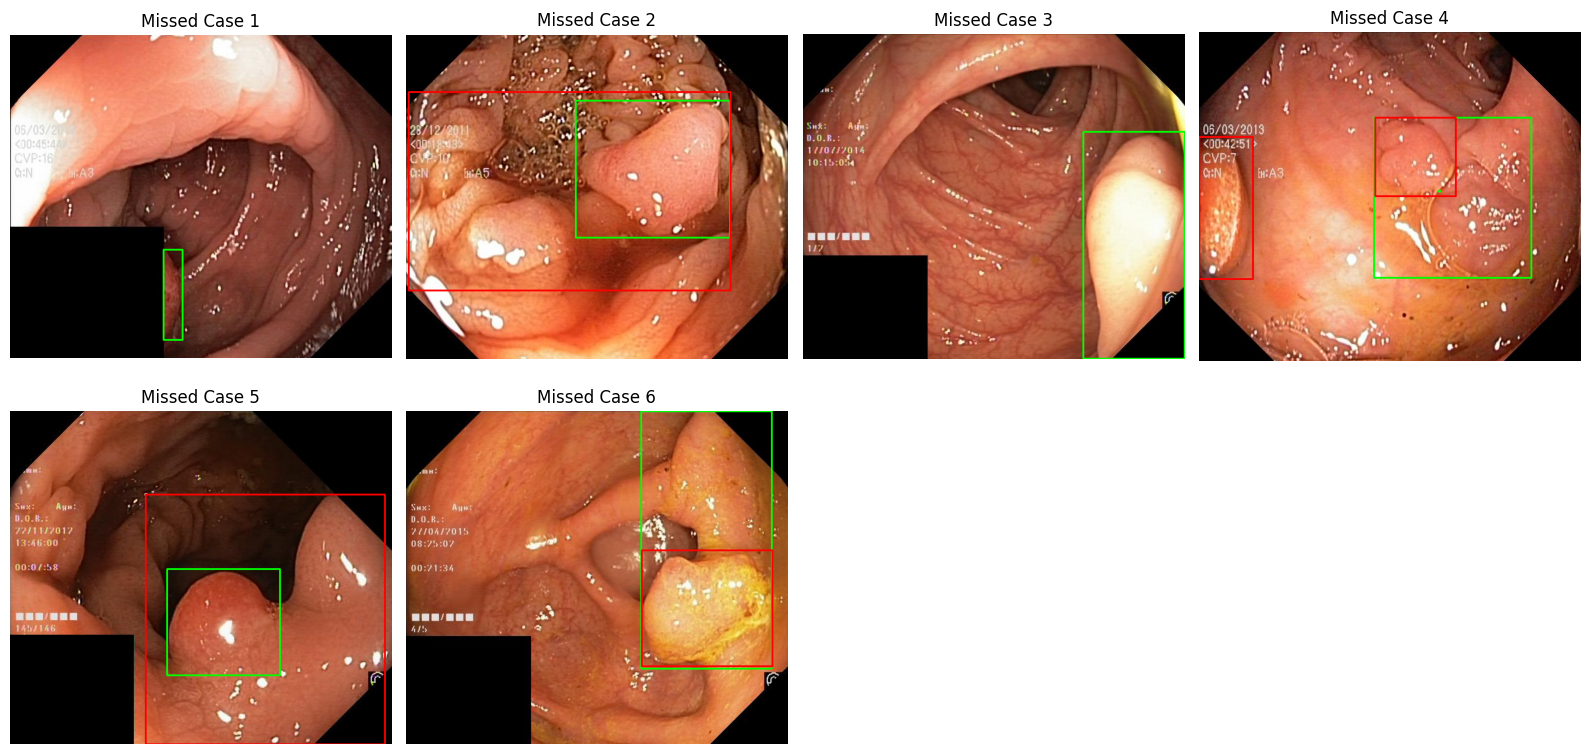

In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from ultralytics import YOLO

# === Paths ===
test_image_dir = r"C:\Medical_image_analysis\yolov8_kvasir\2_neg\images\test"
test_label_dir = r"C:\Medical_image_analysis\yolov8_kvasir\2_neg\labels\test"
model_path = r"C:\Medical_image_analysis\yolov8_kvasir\results\YOLOv8\kvasir-seg_augmentation_20_percent_negative_yolov8\yolov8_s_kvasir_30_062\weights\best.pt"

# === Load Model ===
model = YOLO(model_path)

# === IoU Function ===
def compute_iou(box1, box2):
    x1, y1, x2, y2 = box1
    a1, b1, a2, b2 = box2
    inter_x1 = max(x1, a1)
    inter_y1 = max(y1, b1)
    inter_x2 = min(x2, a2)
    inter_y2 = min(y2, b2)
    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    area1 = (x2 - x1) * (y2 - y1)
    area2 = (a2 - a1) * (b2 - b1)
    union = area1 + area2 - inter_area
    return inter_area / union if union > 0 else 0

failed_images = []
test_images = sorted(glob(os.path.join(test_image_dir, "*.jpg")))

for img_path in test_images:
    label_path = os.path.join(
        test_label_dir,
        os.path.basename(img_path).replace(".jpg", ".txt")
    )

    if not os.path.exists(label_path):
        continue

    image = cv2.imread(img_path)
    h, w = image.shape[:2]

    # === Ground Truth ===
    gt = np.loadtxt(label_path).reshape(-1, 5)[:, 1:]
    gt[:, [0, 2]] *= w
    gt[:, [1, 3]] *= h
    gt_xyxy = np.hstack([
        gt[:, :2] - gt[:, 2:] / 2,
        gt[:, :2] + gt[:, 2:] / 2
    ])

    # === Predictions ===
    results = model.predict(
        source=img_path,
        conf=0.25,
        iou=0.5,
        save=False,
        verbose=False
    )
    pred_boxes = results[0].boxes.xyxy.cpu().numpy()

    matched = False
    for pb in pred_boxes:
        for gb in gt_xyxy:
            if compute_iou(pb, gb) >= 0.5:
                matched = True
                break
        if matched:
            break

    # === Failed case ===
    if not matched:
        for x1, y1, x2, y2 in gt_xyxy.astype(int):
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

        for x1, y1, x2, y2 in pred_boxes.astype(int):
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 0, 255), 2)

        failed_images.append(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

# === Display only ===
cols = 4
rows = (len(failed_images) + cols - 1) // cols

plt.figure(figsize=(16, 4 * rows))
for i, img in enumerate(failed_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Missed Case {i+1}")
plt.tight_layout()
plt.show()


# BKAI-IGH Neopolyp Dataset